<a href="https://colab.research.google.com/github/PromitMukherjee/Machine_learning_Algorithm/blob/main/Supervised_Learning/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

KNN BINARY CLASSIFICATION RESULTS
K value              : 5
Training samples     : 800
Testing samples      : 200
------------------------------------------------------------
Training Accuracy    : 0.9788
Test Accuracy        : 0.9900
Precision            : 0.9907
Recall               : 0.9907
F1 Score             : 0.9907
ROC-AUC              : 0.9895
------------------------------------------------------------
Confusion Matrix
------------------------------
TN = 91
FP = 1
FN = 1
TP = 107


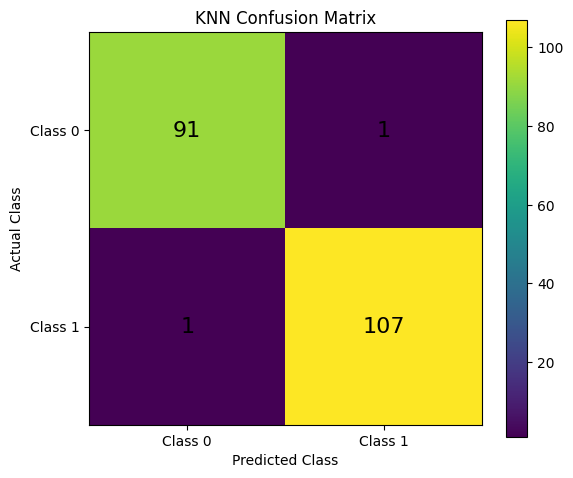

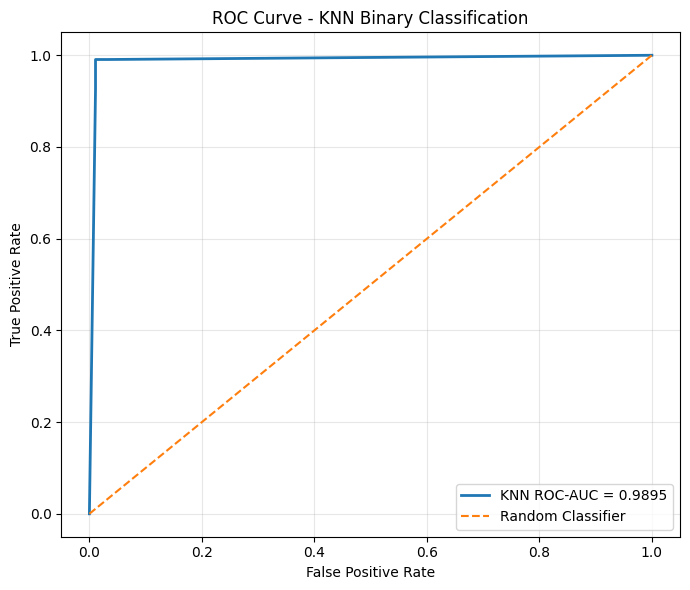

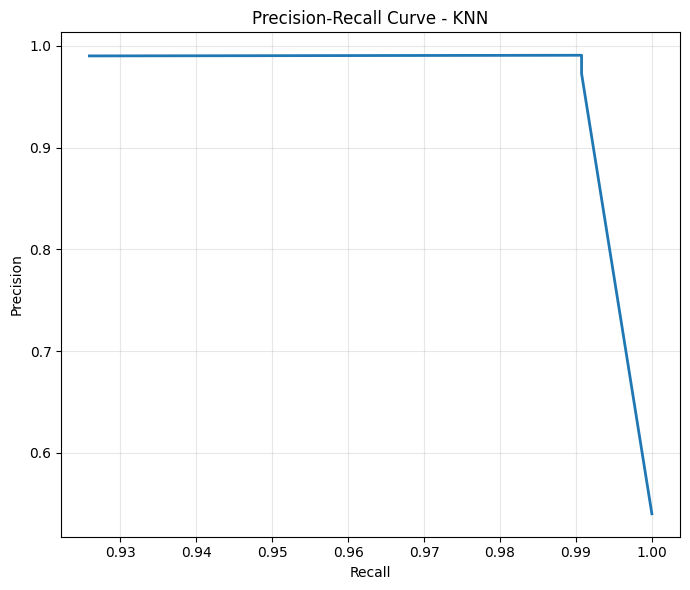

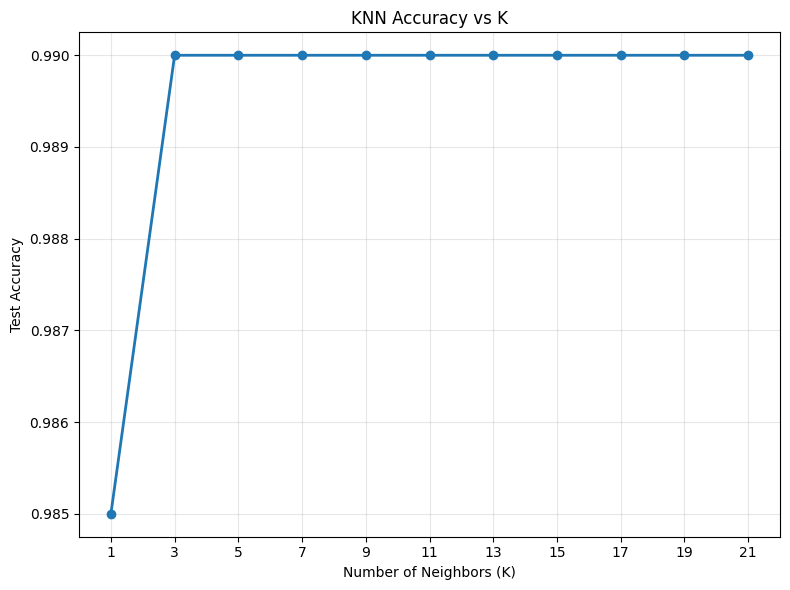

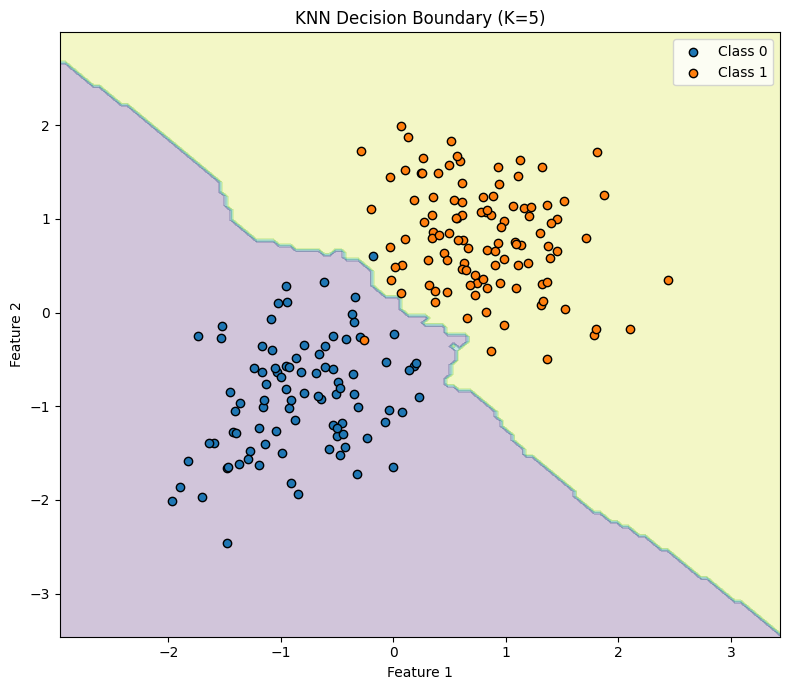

In [1]:
# ============================================================
# KNN BINARY CLASSIFICATION FROM SCRATCH
# NO SCIKIT-LEARN
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. GENERATE BINARY CLASSIFICATION DATASET
# ============================================================

np.random.seed(42)

n_samples = 1000

# Class 0
n_class0 = n_samples // 2
X0 = np.random.multivariate_normal(
    mean=[2, 2],
    cov=[[1.2, 0.3],
         [0.3, 1.0]],
    size=n_class0
)

# Class 1
n_class1 = n_samples - n_class0
X1 = np.random.multivariate_normal(
    mean=[5, 5],
    cov=[[1.2, -0.2],
         [-0.2, 1.0]],
    size=n_class1
)

# Combine features
X = np.vstack((X0, X1))

# Labels
y = np.hstack((
    np.zeros(n_class0, dtype=int),
    np.ones(n_class1, dtype=int)
))


# ============================================================
# 2. SHUFFLE DATASET
# ============================================================

indices = np.random.permutation(n_samples)

X = X[indices]
y = y[indices]


# ============================================================
# 3. TRAIN-TEST SPLIT FROM SCRATCH
# ============================================================

test_size = 0.20

split_index = int(n_samples * (1 - test_size))

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]


# ============================================================
# 4. STANDARDIZATION FROM SCRATCH
# ============================================================

mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

# Prevent division by zero
std[std == 0] = 1

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std


# ============================================================
# 5. KNN CLASSIFIER FROM SCRATCH
# ============================================================

class KNNClassifier:

    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None

    # --------------------------------------------------------
    # FIT
    # --------------------------------------------------------

    def fit(self, X, y):

        self.X_train = X
        self.y_train = y

        return self

    # --------------------------------------------------------
    # EUCLIDEAN DISTANCE
    # --------------------------------------------------------

    def _euclidean_distance(self, x1, x2):

        return np.sqrt(np.sum((x1 - x2) ** 2))

    # --------------------------------------------------------
    # PREDICT PROBABILITY
    # --------------------------------------------------------

    def predict_proba(self, X):

        probabilities = []

        for x in X:

            # Calculate distances from x to every training sample
            distances = np.sqrt(
                np.sum(
                    (self.X_train - x) ** 2,
                    axis=1
                )
            )

            # Get indices of k nearest neighbors
            nearest_indices = np.argsort(distances)[:self.k]

            # Get labels of nearest neighbors
            nearest_labels = self.y_train[nearest_indices]

            # Probability of class 1
            probability_class_1 = np.mean(nearest_labels)

            probabilities.append(probability_class_1)

        return np.array(probabilities)

    # --------------------------------------------------------
    # PREDICT CLASS
    # --------------------------------------------------------

    def predict(self, X):

        probabilities = self.predict_proba(X)

        predictions = (probabilities >= 0.5).astype(int)

        return predictions


# ============================================================
# 6. TRAIN KNN MODEL
# ============================================================

k = 5

model = KNNClassifier(k=k)

model.fit(
    X_train_scaled,
    y_train
)


# ============================================================
# 7. MAKE PREDICTIONS
# ============================================================

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

y_test_proba = model.predict_proba(X_test_scaled)


# ============================================================
# 8. CONFUSION MATRIX FROM SCRATCH
# ============================================================

def confusion_matrix_binary(y_true, y_pred):

    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    return TN, FP, FN, TP


TN, FP, FN, TP = confusion_matrix_binary(
    y_test,
    y_test_pred
)


# ============================================================
# 9. EVALUATION METRICS
# ============================================================

def accuracy_score(y_true, y_pred):

    return np.mean(y_true == y_pred)


def precision_score(y_true, y_pred):

    TP = np.sum((y_true == 1) & (y_pred == 1))
    FP = np.sum((y_true == 0) & (y_pred == 1))

    if TP + FP == 0:
        return 0.0

    return TP / (TP + FP)


def recall_score(y_true, y_pred):

    TP = np.sum((y_true == 1) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    if TP + FN == 0:
        return 0.0

    return TP / (TP + FN)


def f1_score(y_true, y_pred):

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)

    if precision + recall == 0:
        return 0.0

    return 2 * (
        precision * recall
    ) / (
        precision + recall
    )


# ============================================================
# 10. CALCULATE METRICS
# ============================================================

train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

precision = precision_score(
    y_test,
    y_test_pred
)

recall = recall_score(
    y_test,
    y_test_pred
)

f1 = f1_score(
    y_test,
    y_test_pred
)


# ============================================================
# 11. ROC-AUC FROM SCRATCH
# ============================================================

def roc_curve_from_scratch(y_true, y_scores):

    thresholds = np.sort(
        np.unique(y_scores)
    )[::-1]

    thresholds = np.concatenate((
        [np.inf],
        thresholds,
        [-np.inf]
    ))

    TPR = []
    FPR = []

    P = np.sum(y_true == 1)
    N = np.sum(y_true == 0)

    for threshold in thresholds:

        y_pred = (
            y_scores >= threshold
        ).astype(int)

        TP = np.sum(
            (y_true == 1) &
            (y_pred == 1)
        )

        FP = np.sum(
            (y_true == 0) &
            (y_pred == 1)
        )

        TPR.append(
            TP / P if P > 0 else 0
        )

        FPR.append(
            FP / N if N > 0 else 0
        )

    return np.array(FPR), np.array(TPR)


def auc_trapezoidal(x, y):

    order = np.argsort(x)

    x_sorted = x[order]
    y_sorted = y[order]

    return np.trapezoid(
        y_sorted,
        x_sorted
    )


fpr, tpr = roc_curve_from_scratch(
    y_test,
    y_test_proba
)

roc_auc = auc_trapezoidal(
    fpr,
    tpr
)


# ============================================================
# 12. PRINT EVALUATION RESULTS
# ============================================================

print("=" * 60)
print("KNN BINARY CLASSIFICATION RESULTS")
print("=" * 60)

print(f"K value              : {k}")

print(f"Training samples     : {len(X_train)}")
print(f"Testing samples      : {len(X_test)}")

print("-" * 60)

print(f"Training Accuracy    : {train_accuracy:.4f}")
print(f"Test Accuracy        : {test_accuracy:.4f}")
print(f"Precision            : {precision:.4f}")
print(f"Recall               : {recall:.4f}")
print(f"F1 Score             : {f1:.4f}")
print(f"ROC-AUC              : {roc_auc:.4f}")

print("-" * 60)

print("Confusion Matrix")
print("-" * 30)

print(f"TN = {TN}")
print(f"FP = {FP}")
print(f"FN = {FN}")
print(f"TP = {TP}")

print("=" * 60)


# ============================================================
# 13. CONFUSION MATRIX PLOT
# ============================================================

cm = np.array([
    [TN, FP],
    [FN, TP]
])

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("KNN Confusion Matrix")

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0, 1],
    ["Class 0", "Class 1"]
)

plt.yticks(
    [0, 1],
    ["Class 0", "Class 1"]
)

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=16
        )

plt.colorbar()

plt.tight_layout()
plt.show()


# ============================================================
# 14. ROC CURVE
# ============================================================

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"KNN ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - KNN Binary Classification")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 15. PRECISION-RECALL CURVE
# ============================================================

def precision_recall_curve_from_scratch(
    y_true,
    y_scores
):

    thresholds = np.sort(
        np.unique(y_scores)
    )[::-1]

    precisions = []
    recalls = []

    for threshold in thresholds:

        y_pred = (
            y_scores >= threshold
        ).astype(int)

        precision_value = precision_score(
            y_true,
            y_pred
        )

        recall_value = recall_score(
            y_true,
            y_pred
        )

        precisions.append(
            precision_value
        )

        recalls.append(
            recall_value
        )

    return (
        np.array(recalls),
        np.array(precisions)
    )


pr_recall, pr_precision = (
    precision_recall_curve_from_scratch(
        y_test,
        y_test_proba
    )
)


plt.figure(figsize=(7, 6))

plt.plot(
    pr_recall,
    pr_precision,
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve - KNN"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 16. ACCURACY VS K
# ============================================================

k_values = range(1, 22, 2)

accuracy_values = []

for current_k in k_values:

    temp_model = KNNClassifier(
        k=current_k
    )

    temp_model.fit(
        X_train_scaled,
        y_train
    )

    temp_pred = temp_model.predict(
        X_test_scaled
    )

    current_accuracy = accuracy_score(
        y_test,
        temp_pred
    )

    accuracy_values.append(
        current_accuracy
    )


plt.figure(figsize=(8, 6))

plt.plot(
    list(k_values),
    accuracy_values,
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Test Accuracy")

plt.title(
    "KNN Accuracy vs K"
)

plt.xticks(
    list(k_values)
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 17. DECISION BOUNDARY
# ============================================================

def plot_decision_boundary(
    model,
    X,
    y,
    title
):

    x_min = X[:, 0].min() - 1
    x_max = X[:, 0].max() + 1

    y_min = X[:, 1].min() - 1
    y_max = X[:, 1].max() + 1

    step = 0.05

    xx, yy = np.meshgrid(
        np.arange(
            x_min,
            x_max,
            step
        ),
        np.arange(
            y_min,
            y_max,
            step
        )
    )

    grid = np.c_[
        xx.ravel(),
        yy.ravel()
    ]

    predictions = model.predict(
        grid
    )

    predictions = predictions.reshape(
        xx.shape
    )

    plt.figure(figsize=(8, 7))

    plt.contourf(
        xx,
        yy,
        predictions,
        alpha=0.25
    )

    plt.scatter(
        X[y == 0, 0],
        X[y == 0, 1],
        label="Class 0",
        edgecolors="black"
    )

    plt.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        label="Class 1",
        edgecolors="black"
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    plt.title(title)

    plt.legend()

    plt.tight_layout()

    plt.show()


# ============================================================
# 18. PLOT TEST DATA DECISION BOUNDARY
# ============================================================

plot_decision_boundary(
    model,
    X_test_scaled,
    y_test,
    f"KNN Decision Boundary (K={k})"
)

KNN MULTICLASS CLASSIFICATION RESULTS
K value             : 5
Number of classes   : 4
Training samples    : 960
Testing samples     : 240
----------------------------------------------------------------------
Training Accuracy   : 0.9833
Test Accuracy       : 0.9833
Macro Precision     : 0.9831
Macro Recall        : 0.9838
Macro F1 Score      : 0.9834
Micro Precision     : 0.9833
Micro Recall        : 0.9833
Micro F1 Score      : 0.9833
Macro ROC-AUC       : 0.9996
----------------------------------------------------------------------
PER-CLASS METRICS
----------------------------------------------------------------------
Class 0: Precision = 1.0000, Recall = 0.9839, F1 = 0.9919, ROC-AUC = 1.0000
Class 1: Precision = 0.9828, Recall = 1.0000, F1 = 0.9913, ROC-AUC = 1.0000
Class 2: Precision = 0.9841, Recall = 0.9688, F1 = 0.9764, ROC-AUC = 0.9992
Class 3: Precision = 0.9655, Recall = 0.9825, F1 = 0.9739, ROC-AUC = 0.9990
------------------------------------------------------------------

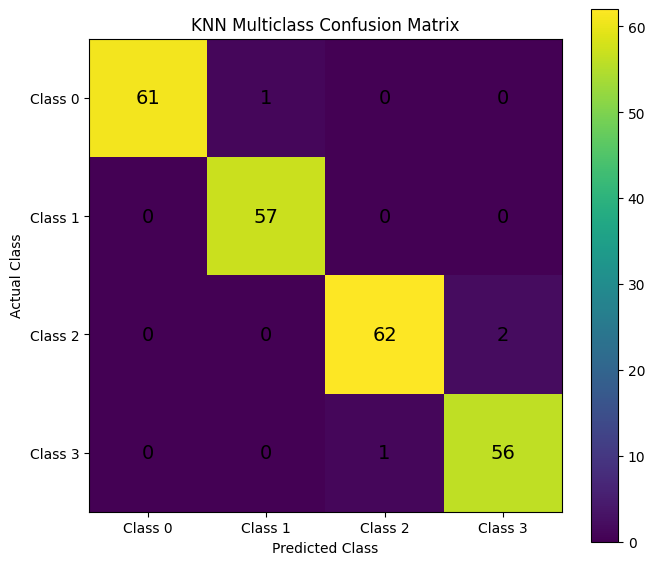

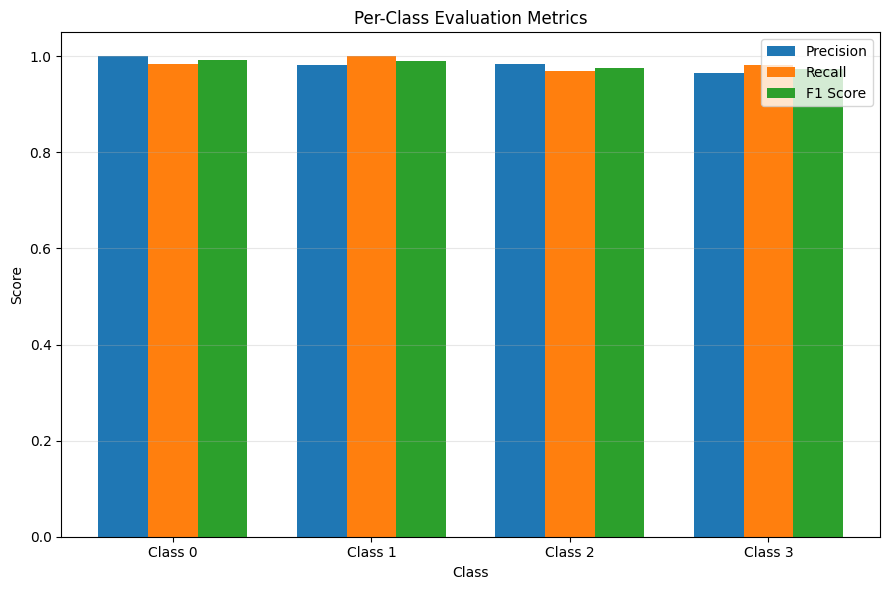

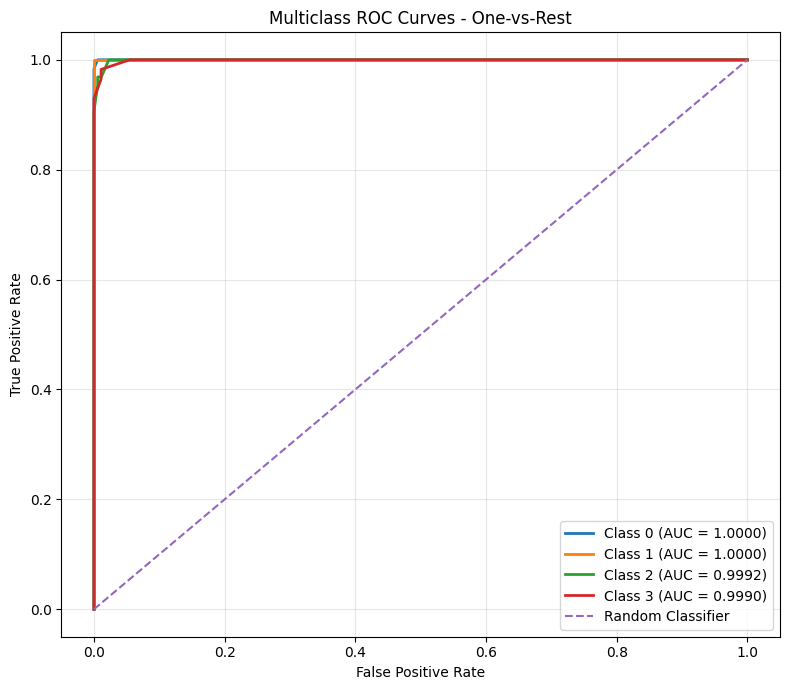

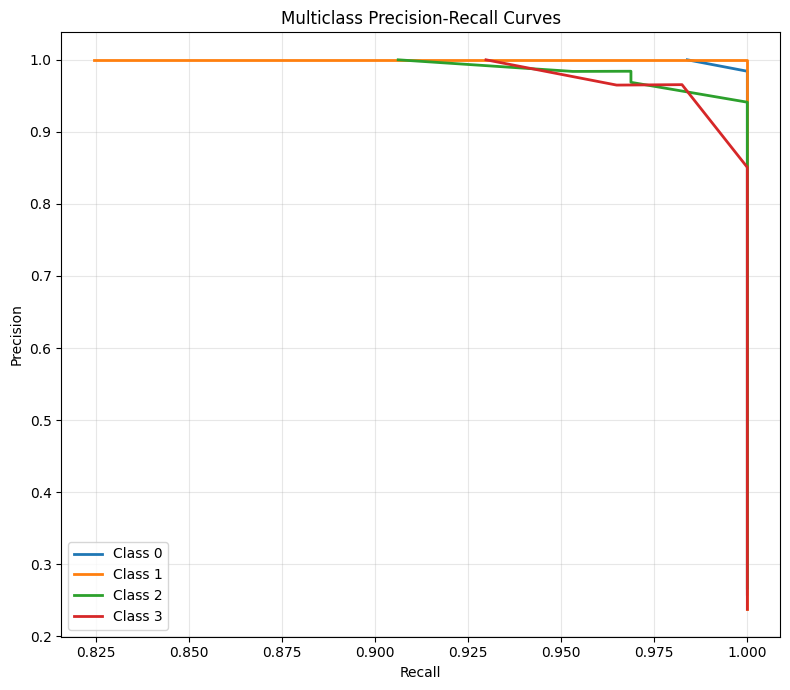

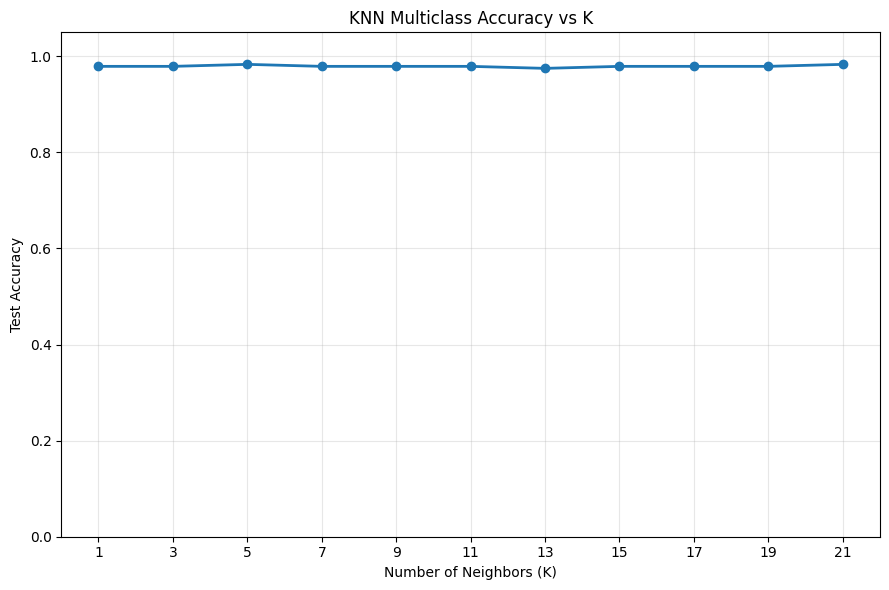

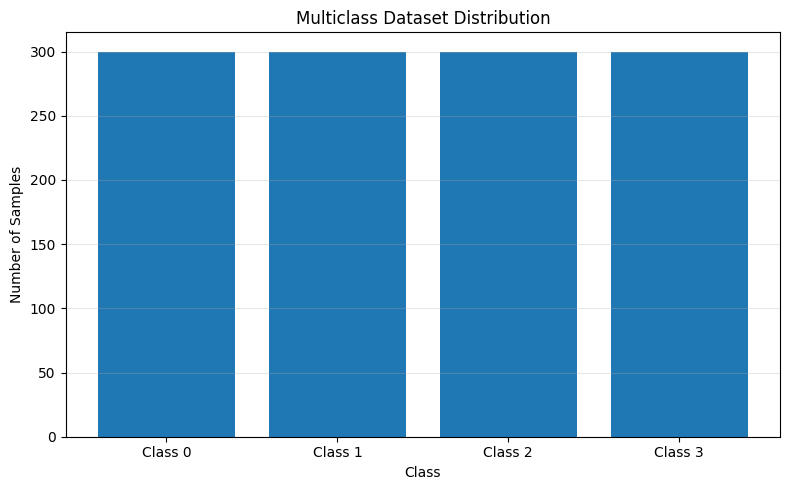

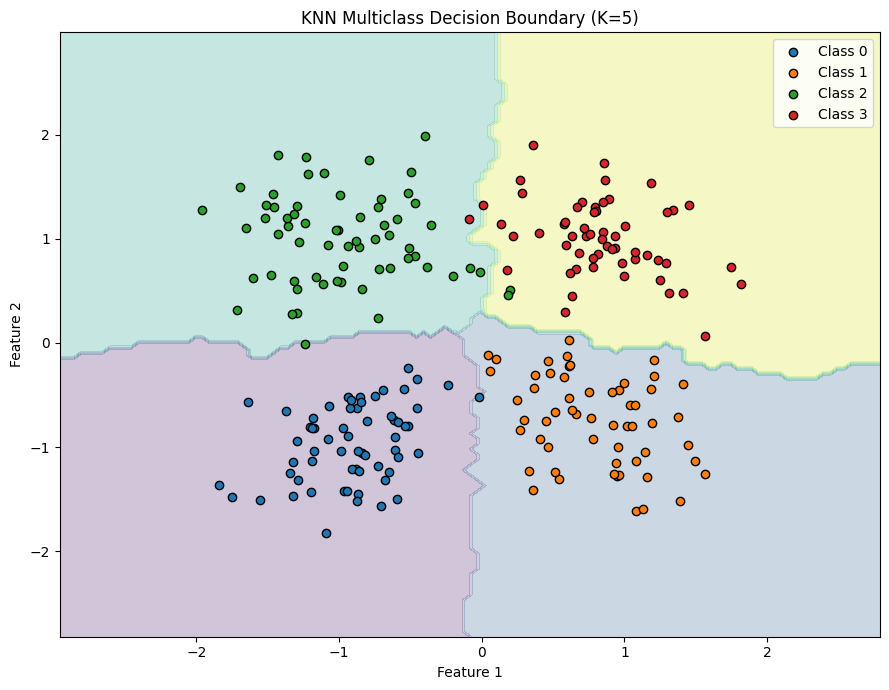

In [2]:
# ============================================================
# KNN MULTICLASS CLASSIFICATION FROM SCRATCH
# ============================================================
# NO SCIKIT-LEARN
# ONLY NUMPY + MATPLOTLIB
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. CREATE MULTICLASS DATASET
# ============================================================

np.random.seed(42)

n_samples_per_class = 300

# ------------------------------------------------------------
# Class 0
# ------------------------------------------------------------

X0 = np.random.multivariate_normal(
    mean=[2, 2],
    cov=[
        [0.8, 0.2],
        [0.2, 0.8]
    ],
    size=n_samples_per_class
)

y0 = np.zeros(
    n_samples_per_class,
    dtype=int
)


# ------------------------------------------------------------
# Class 1
# ------------------------------------------------------------

X1 = np.random.multivariate_normal(
    mean=[6, 2],
    cov=[
        [0.8, -0.2],
        [-0.2, 0.8]
    ],
    size=n_samples_per_class
)

y1 = np.ones(
    n_samples_per_class,
    dtype=int
)


# ------------------------------------------------------------
# Class 2
# ------------------------------------------------------------

X2 = np.random.multivariate_normal(
    mean=[2, 6],
    cov=[
        [0.8, 0.1],
        [0.1, 0.8]
    ],
    size=n_samples_per_class
)

y2 = np.full(
    n_samples_per_class,
    2,
    dtype=int
)


# ------------------------------------------------------------
# Class 3
# ------------------------------------------------------------

X3 = np.random.multivariate_normal(
    mean=[6, 6],
    cov=[
        [0.8, -0.1],
        [-0.1, 0.8]
    ],
    size=n_samples_per_class
)

y3 = np.full(
    n_samples_per_class,
    3,
    dtype=int
)


# ============================================================
# 2. COMBINE DATA
# ============================================================

X = np.vstack([
    X0,
    X1,
    X2,
    X3
])

y = np.concatenate([
    y0,
    y1,
    y2,
    y3
])


# ============================================================
# 3. SHUFFLE DATASET
# ============================================================

indices = np.random.permutation(
    len(X)
)

X = X[indices]
y = y[indices]


# ============================================================
# 4. TRAIN / TEST SPLIT FROM SCRATCH
# ============================================================

test_size = 0.20

split_index = int(
    len(X) * (1 - test_size)
)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]


# ============================================================
# 5. STANDARDIZATION FROM SCRATCH
# ============================================================

train_mean = np.mean(
    X_train,
    axis=0
)

train_std = np.std(
    X_train,
    axis=0
)

# Avoid division by zero
train_std[train_std == 0] = 1

X_train_scaled = (
    X_train - train_mean
) / train_std

X_test_scaled = (
    X_test - train_mean
) / train_std


# ============================================================
# 6. KNN MULTICLASS CLASSIFIER FROM SCRATCH
# ============================================================

class KNNMulticlassClassifier:

    def __init__(
        self,
        k=5
    ):

        self.k = k
        self.X_train = None
        self.y_train = None
        self.classes_ = None


    # ========================================================
    # FIT
    # ========================================================

    def fit(
        self,
        X,
        y
    ):

        self.X_train = X
        self.y_train = y

        self.classes_ = np.unique(y)

        return self


    # ========================================================
    # EUCLIDEAN DISTANCE
    # ========================================================

    def _euclidean_distance(
        self,
        x
    ):

        distances = np.sqrt(
            np.sum(
                (
                    self.X_train - x
                ) ** 2,
                axis=1
            )
        )

        return distances


    # ========================================================
    # PREDICT PROBABILITY
    # ========================================================

    def predict_proba(
        self,
        X
    ):

        probabilities = []

        for x in X:

            # Calculate distance
            distances = self._euclidean_distance(
                x
            )

            # Find K nearest samples
            nearest_indices = np.argsort(
                distances
            )[:self.k]

            # Labels of nearest samples
            nearest_labels = (
                self.y_train[
                    nearest_indices
                ]
            )

            # Count class occurrences
            class_probabilities = []

            for class_label in self.classes_:

                count = np.sum(
                    nearest_labels == class_label
                )

                probability = (
                    count / self.k
                )

                class_probabilities.append(
                    probability
                )

            probabilities.append(
                class_probabilities
            )

        return np.array(
            probabilities
        )


    # ========================================================
    # PREDICT
    # ========================================================

    def predict(
        self,
        X
    ):

        probabilities = self.predict_proba(
            X
        )

        predictions = self.classes_[
            np.argmax(
                probabilities,
                axis=1
            )
        ]

        return predictions


# ============================================================
# 7. TRAIN KNN
# ============================================================

k = 5

model = KNNMulticlassClassifier(
    k=k
)

model.fit(
    X_train_scaled,
    y_train
)


# ============================================================
# 8. PREDICTIONS
# ============================================================

y_train_pred = model.predict(
    X_train_scaled
)

y_test_pred = model.predict(
    X_test_scaled
)

y_test_proba = model.predict_proba(
    X_test_scaled
)


# ============================================================
# 9. MULTICLASS CONFUSION MATRIX
# ============================================================

def confusion_matrix_multiclass(
    y_true,
    y_pred,
    classes
):

    n_classes = len(classes)

    cm = np.zeros(
        (n_classes, n_classes),
        dtype=int
    )

    for actual, predicted in zip(
        y_true,
        y_pred
    ):

        actual_index = np.where(
            classes == actual
        )[0][0]

        predicted_index = np.where(
            classes == predicted
        )[0][0]

        cm[
            actual_index,
            predicted_index
        ] += 1

    return cm


classes = np.unique(y)

cm = confusion_matrix_multiclass(
    y_test,
    y_test_pred,
    classes
)


# ============================================================
# 10. ACCURACY
# ============================================================

def accuracy_score(
    y_true,
    y_pred
):

    return np.mean(
        y_true == y_pred
    )


# ============================================================
# 11. PER-CLASS PRECISION
# ============================================================

def precision_per_class(
    y_true,
    y_pred,
    classes
):

    precision_values = []

    for class_label in classes:

        TP = np.sum(
            (y_true == class_label) &
            (y_pred == class_label)
        )

        FP = np.sum(
            (y_true != class_label) &
            (y_pred == class_label)
        )

        if TP + FP == 0:

            precision = 0.0

        else:

            precision = (
                TP / (TP + FP)
            )

        precision_values.append(
            precision
        )

    return np.array(
        precision_values
    )


# ============================================================
# 12. PER-CLASS RECALL
# ============================================================

def recall_per_class(
    y_true,
    y_pred,
    classes
):

    recall_values = []

    for class_label in classes:

        TP = np.sum(
            (y_true == class_label) &
            (y_pred == class_label)
        )

        FN = np.sum(
            (y_true == class_label) &
            (y_pred != class_label)
        )

        if TP + FN == 0:

            recall = 0.0

        else:

            recall = (
                TP / (TP + FN)
            )

        recall_values.append(
            recall
        )

    return np.array(
        recall_values
    )


# ============================================================
# 13. PER-CLASS F1
# ============================================================

def f1_per_class(
    precision,
    recall
):

    f1_values = []

    for p, r in zip(
        precision,
        recall
    ):

        if p + r == 0:

            f1 = 0.0

        else:

            f1 = (
                2 * p * r
            ) / (p + r)

        f1_values.append(
            f1
        )

    return np.array(
        f1_values
    )


# ============================================================
# 14. CALCULATE METRICS
# ============================================================

train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

precision_values = precision_per_class(
    y_test,
    y_test_pred,
    classes
)

recall_values = recall_per_class(
    y_test,
    y_test_pred,
    classes
)

f1_values = f1_per_class(
    precision_values,
    recall_values
)


# ============================================================
# 15. MACRO METRICS
# ============================================================

macro_precision = np.mean(
    precision_values
)

macro_recall = np.mean(
    recall_values
)

macro_f1 = np.mean(
    f1_values
)


# ============================================================
# 16. MICRO METRICS
# ============================================================

def micro_precision(
    y_true,
    y_pred,
    classes
):

    TP_total = 0
    FP_total = 0

    for class_label in classes:

        TP = np.sum(
            (y_true == class_label) &
            (y_pred == class_label)
        )

        FP = np.sum(
            (y_true != class_label) &
            (y_pred == class_label)
        )

        TP_total += TP
        FP_total += FP

    if TP_total + FP_total == 0:

        return 0.0

    return TP_total / (
        TP_total + FP_total
    )


def micro_recall(
    y_true,
    y_pred,
    classes
):

    TP_total = 0
    FN_total = 0

    for class_label in classes:

        TP = np.sum(
            (y_true == class_label) &
            (y_pred == class_label)
        )

        FN = np.sum(
            (y_true == class_label) &
            (y_pred != class_label)
        )

        TP_total += TP
        FN_total += FN

    if TP_total + FN_total == 0:

        return 0.0

    return TP_total / (
        TP_total + FN_total
    )


micro_p = micro_precision(
    y_test,
    y_test_pred,
    classes
)

micro_r = micro_recall(
    y_test,
    y_test_pred,
    classes
)

if micro_p + micro_r == 0:

    micro_f1 = 0.0

else:

    micro_f1 = (
        2 * micro_p * micro_r
    ) / (
        micro_p + micro_r
    )


# ============================================================
# 17. ROC CURVE FOR MULTICLASS
# ============================================================
# One-vs-Rest (OvR)
# ============================================================

def binary_roc_curve(
    y_true_binary,
    scores
):

    thresholds = np.unique(
        scores
    )

    thresholds = np.sort(
        thresholds
    )[::-1]

    thresholds = np.concatenate([
        [np.inf],
        thresholds,
        [-np.inf]
    ])

    tpr_values = []
    fpr_values = []

    P = np.sum(
        y_true_binary == 1
    )

    N = np.sum(
        y_true_binary == 0
    )

    for threshold in thresholds:

        predictions = (
            scores >= threshold
        ).astype(int)

        TP = np.sum(
            (y_true_binary == 1) &
            (predictions == 1)
        )

        FP = np.sum(
            (y_true_binary == 0) &
            (predictions == 1)
        )

        if P > 0:

            TPR = TP / P

        else:

            TPR = 0.0

        if N > 0:

            FPR = FP / N

        else:

            FPR = 0.0

        tpr_values.append(TPR)
        fpr_values.append(FPR)

    return (
        np.array(fpr_values),
        np.array(tpr_values)
    )


# ============================================================
# 18. AUC FROM SCRATCH
# ============================================================

def calculate_auc(
    fpr,
    tpr
):

    order = np.argsort(
        fpr
    )

    fpr_sorted = fpr[
        order
    ]

    tpr_sorted = tpr[
        order
    ]

    return np.trapezoid(
        tpr_sorted,
        fpr_sorted
    )


# ============================================================
# 19. MULTICLASS ROC-AUC
# ============================================================

roc_data = {}

auc_values = []

for i, class_label in enumerate(
    classes
):

    y_binary = (
        y_test == class_label
    ).astype(int)

    class_scores = (
        y_test_proba[:, i]
    )

    fpr_class, tpr_class = (
        binary_roc_curve(
            y_binary,
            class_scores
        )
    )

    auc_class = calculate_auc(
        fpr_class,
        tpr_class
    )

    roc_data[
        class_label
    ] = (
        fpr_class,
        tpr_class
    )

    auc_values.append(
        auc_class
    )


macro_auc = np.mean(
    auc_values
)


# ============================================================
# 20. PRINT RESULTS
# ============================================================

print("=" * 70)
print("KNN MULTICLASS CLASSIFICATION RESULTS")
print("=" * 70)

print(f"K value             : {k}")

print(
    f"Number of classes   : {len(classes)}"
)

print(
    f"Training samples    : {len(X_train)}"
)

print(
    f"Testing samples     : {len(X_test)}"
)

print("-" * 70)

print(
    f"Training Accuracy   : "
    f"{train_accuracy:.4f}"
)

print(
    f"Test Accuracy       : "
    f"{test_accuracy:.4f}"
)

print(
    f"Macro Precision     : "
    f"{macro_precision:.4f}"
)

print(
    f"Macro Recall        : "
    f"{macro_recall:.4f}"
)

print(
    f"Macro F1 Score      : "
    f"{macro_f1:.4f}"
)

print(
    f"Micro Precision     : "
    f"{micro_p:.4f}"
)

print(
    f"Micro Recall        : "
    f"{micro_r:.4f}"
)

print(
    f"Micro F1 Score      : "
    f"{micro_f1:.4f}"
)

print(
    f"Macro ROC-AUC       : "
    f"{macro_auc:.4f}"
)

print("-" * 70)

print("PER-CLASS METRICS")
print("-" * 70)

for i, class_label in enumerate(
    classes
):

    print(
        f"Class {class_label}: "
        f"Precision = "
        f"{precision_values[i]:.4f}, "
        f"Recall = "
        f"{recall_values[i]:.4f}, "
        f"F1 = "
        f"{f1_values[i]:.4f}, "
        f"ROC-AUC = "
        f"{auc_values[i]:.4f}"
    )

print("-" * 70)

print("CONFUSION MATRIX")
print("-" * 70)

print(cm)

print("=" * 70)


# ============================================================
# 21. CONFUSION MATRIX PLOT
# ============================================================

plt.figure(
    figsize=(7, 6)
)

plt.imshow(cm)

plt.title(
    "KNN Multiclass Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.xticks(
    range(len(classes)),
    [f"Class {c}" for c in classes]
)

plt.yticks(
    range(len(classes)),
    [f"Class {c}" for c in classes]
)

for i in range(
    len(classes)
):

    for j in range(
        len(classes)
    ):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=14
        )

plt.colorbar()

plt.tight_layout()

plt.show()


# ============================================================
# 22. PER-CLASS METRICS PLOT
# ============================================================

x = np.arange(
    len(classes)
)

width = 0.25

plt.figure(
    figsize=(9, 6)
)

plt.bar(
    x - width,
    precision_values,
    width,
    label="Precision"
)

plt.bar(
    x,
    recall_values,
    width,
    label="Recall"
)

plt.bar(
    x + width,
    f1_values,
    width,
    label="F1 Score"
)

plt.xlabel(
    "Class"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Per-Class Evaluation Metrics"
)

plt.xticks(
    x,
    [f"Class {c}" for c in classes]
)

plt.ylim(
    0,
    1.05
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 23. ROC CURVES - ONE VS REST
# ============================================================

plt.figure(
    figsize=(8, 7)
)

for i, class_label in enumerate(
    classes
):

    fpr_class, tpr_class = (
        roc_data[class_label]
    )

    plt.plot(
        fpr_class,
        tpr_class,
        linewidth=2,
        label=(
            f"Class {class_label} "
            f"(AUC = {auc_values[i]:.4f})"
        )
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Multiclass ROC Curves - One-vs-Rest"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 24. PRECISION-RECALL CURVE
# ============================================================

def precision_recall_curve_binary(
    y_true_binary,
    scores
):

    thresholds = np.unique(
        scores
    )

    thresholds = np.sort(
        thresholds
    )[::-1]

    precision_values = []
    recall_values = []

    for threshold in thresholds:

        predictions = (
            scores >= threshold
        ).astype(int)

        TP = np.sum(
            (y_true_binary == 1) &
            (predictions == 1)
        )

        FP = np.sum(
            (y_true_binary == 0) &
            (predictions == 1)
        )

        FN = np.sum(
            (y_true_binary == 1) &
            (predictions == 0)
        )

        if TP + FP == 0:

            precision = 1.0

        else:

            precision = (
                TP / (TP + FP)
            )

        if TP + FN == 0:

            recall = 0.0

        else:

            recall = (
                TP / (TP + FN)
            )

        precision_values.append(
            precision
        )

        recall_values.append(
            recall
        )

    return (
        np.array(recall_values),
        np.array(precision_values)
    )


plt.figure(
    figsize=(8, 7)
)

for i, class_label in enumerate(
    classes
):

    y_binary = (
        y_test == class_label
    ).astype(int)

    scores = (
        y_test_proba[:, i]
    )

    recall_curve, precision_curve = (
        precision_recall_curve_binary(
            y_binary,
            scores
        )
    )

    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=f"Class {class_label}"
    )


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Multiclass Precision-Recall Curves"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 25. ACCURACY VS K
# ============================================================

k_values = range(
    1,
    22,
    2
)

accuracy_values = []

for current_k in k_values:

    temp_model = (
        KNNMulticlassClassifier(
            k=current_k
        )
    )

    temp_model.fit(
        X_train_scaled,
        y_train
    )

    temp_pred = temp_model.predict(
        X_test_scaled
    )

    acc = accuracy_score(
        y_test,
        temp_pred
    )

    accuracy_values.append(
        acc
    )


plt.figure(
    figsize=(9, 6)
)

plt.plot(
    list(k_values),
    accuracy_values,
    marker="o",
    linewidth=2
)

plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "Test Accuracy"
)

plt.title(
    "KNN Multiclass Accuracy vs K"
)

plt.xticks(
    list(k_values)
)

plt.ylim(
    0,
    1.05
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 26. CLASS DISTRIBUTION
# ============================================================

unique_classes, counts = np.unique(
    y,
    return_counts=True
)

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    [f"Class {c}" for c in unique_classes],
    counts
)

plt.xlabel(
    "Class"
)

plt.ylabel(
    "Number of Samples"
)

plt.title(
    "Multiclass Dataset Distribution"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 27. DECISION BOUNDARY FUNCTION
# ============================================================

def plot_decision_boundary(
    model,
    X,
    y,
    title
):

    x_min = X[:, 0].min() - 1
    x_max = X[:, 0].max() + 1

    y_min = X[:, 1].min() - 1
    y_max = X[:, 1].max() + 1

    step = 0.05

    xx, yy = np.meshgrid(
        np.arange(
            x_min,
            x_max,
            step
        ),
        np.arange(
            y_min,
            y_max,
            step
        )
    )

    grid = np.c_[
        xx.ravel(),
        yy.ravel()
    ]

    predictions = model.predict(
        grid
    )

    predictions = predictions.reshape(
        xx.shape
    )

    plt.figure(
        figsize=(9, 7)
    )

    plt.contourf(
        xx,
        yy,
        predictions,
        alpha=0.25
    )

    for class_label in np.unique(y):

        mask = (
            y == class_label
        )

        plt.scatter(
            X[mask, 0],
            X[mask, 1],
            label=f"Class {class_label}",
            edgecolors="black"
        )

    plt.xlabel(
        "Feature 1"
    )

    plt.ylabel(
        "Feature 2"
    )

    plt.title(
        title
    )

    plt.legend()

    plt.tight_layout()

    plt.show()


# ============================================================
# 28. PLOT DECISION BOUNDARY
# ============================================================

plot_decision_boundary(
    model,
    X_test_scaled,
    y_test,
    f"KNN Multiclass Decision Boundary (K={k})"
)

KNN MULTILABEL CLASSIFICATION RESULTS
K value                  : 7
Classification threshold  : 0.5
Number of features        : 4
Number of labels          : 4
Training samples          : 1200
Testing samples           : 300
---------------------------------------------------------------------------
Training Subset Accuracy  : 0.7092
Test Subset Accuracy      : 0.6267
Hamming Loss              : 0.1100
Hamming Accuracy          : 0.8900
Macro Precision           : 0.9060
Macro Recall              : 0.8859
Macro F1                  : 0.8956
Micro Precision           : 0.9058
Micro Recall              : 0.8859
Micro F1                  : 0.8957
Jaccard Score             : 0.8133
---------------------------------------------------------------------------
PER-LABEL METRICS
---------------------------------------------------------------------------
Label 0: Precision = 0.9187, Recall = 0.8802, F1 = 0.8991
Label 1: Precision = 0.9184, Recall = 0.8710, F1 = 0.8940
Label 2: Precision = 0.8961, 

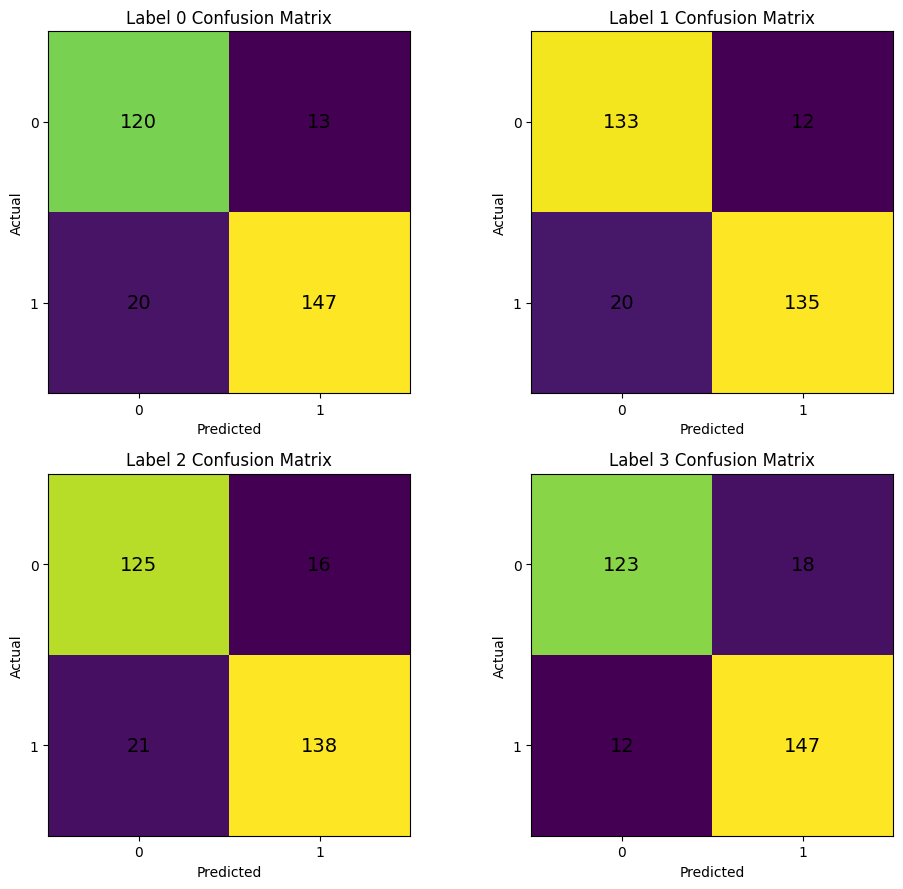

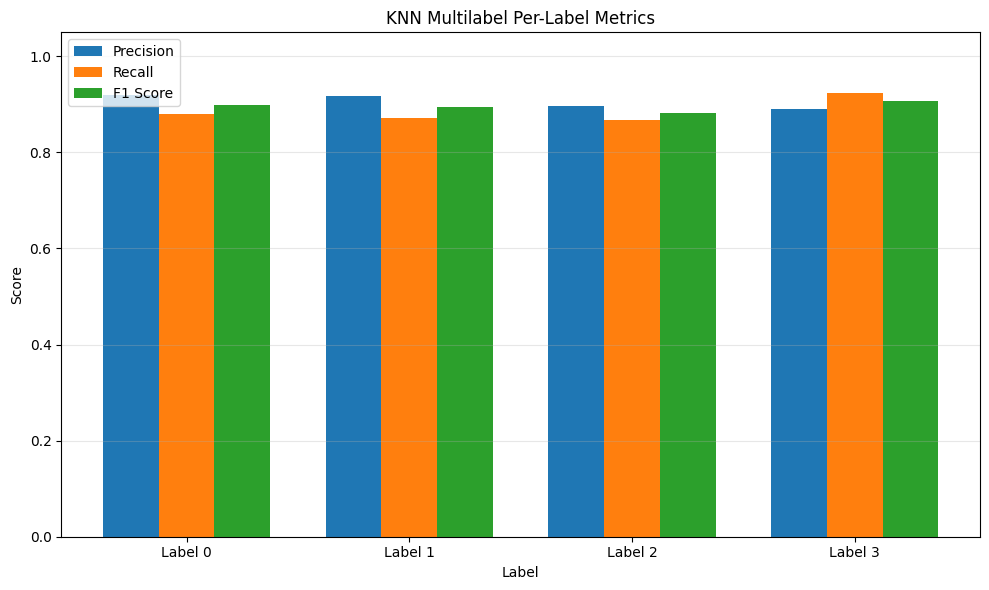

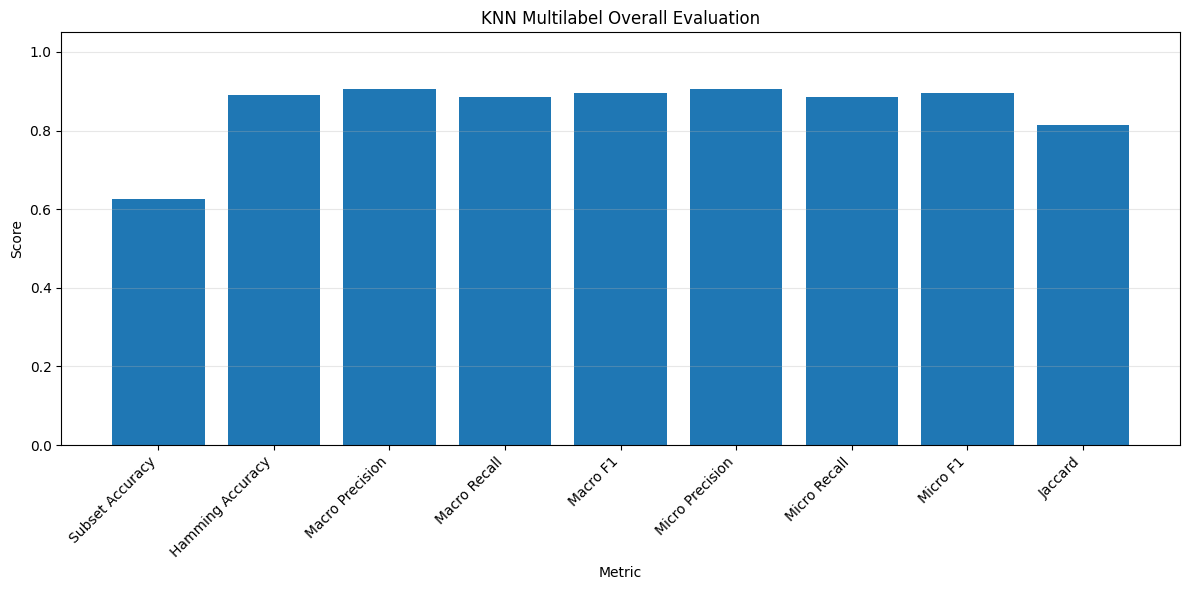

MULTILABEL ROC-AUC
Label 0 ROC-AUC : 0.9481
Label 1 ROC-AUC : 0.9392
Label 2 ROC-AUC : 0.9225
Label 3 ROC-AUC : 0.9455
------------------------------------------------------------
Macro ROC-AUC     : 0.9388


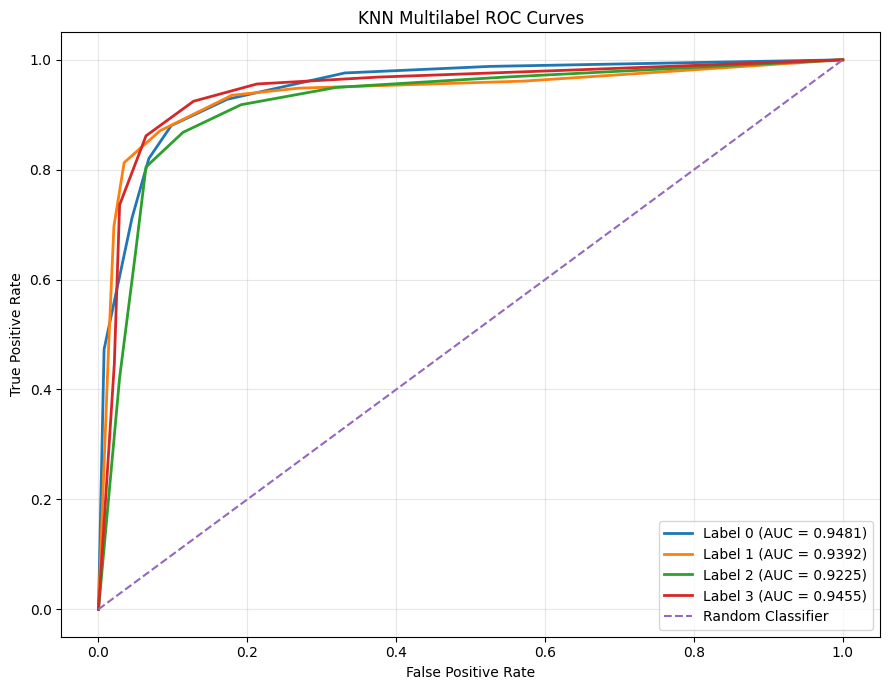

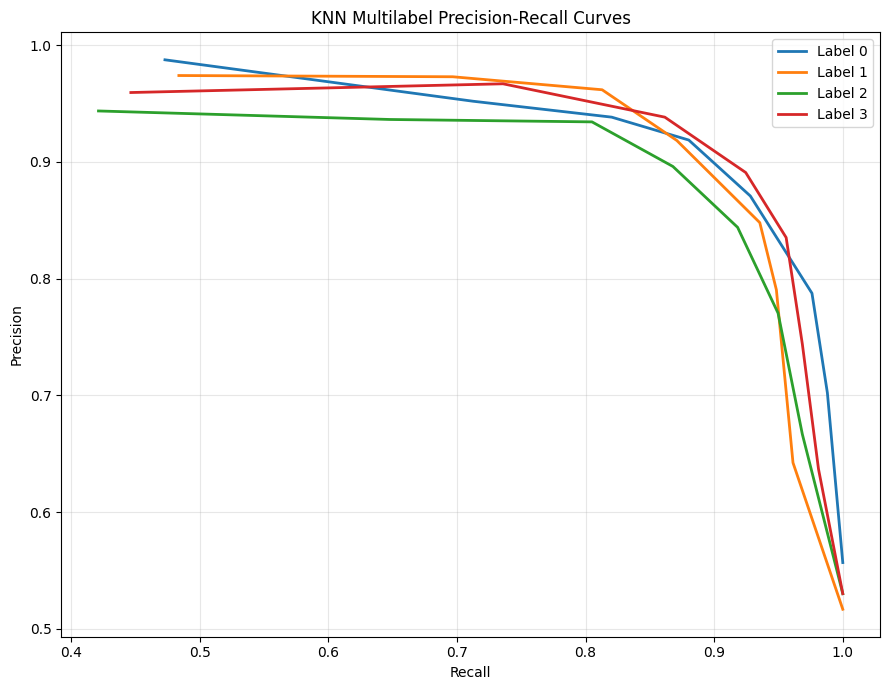

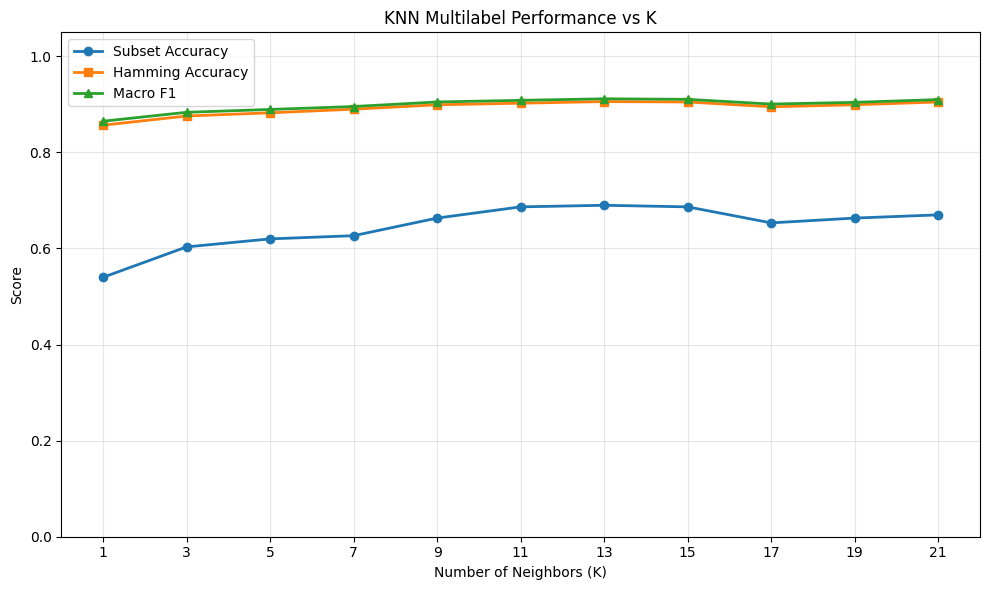

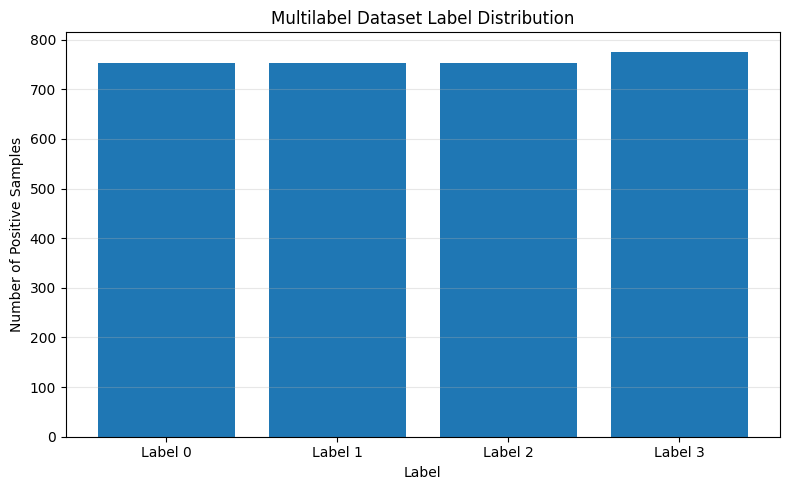

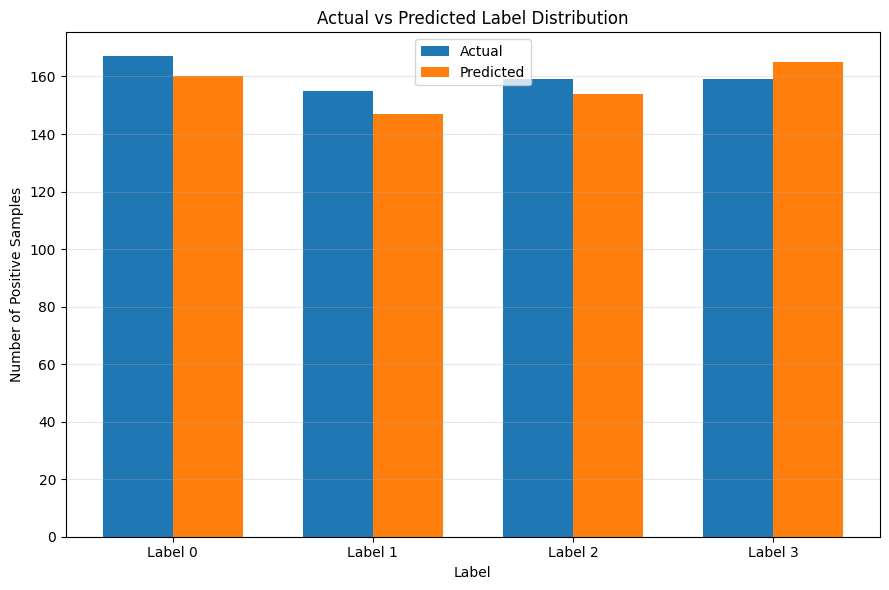

SAMPLE MULTILABEL PREDICTIONS
Sample 1
Actual     : [1 1 0 0]
Probability: [1.    1.    0.714 0.429]
Predicted  : [1 1 1 0]
---------------------------------------------------------------------------
Sample 2
Actual     : [0 0 0 0]
Probability: [0.857 0.571 0.    0.286]
Predicted  : [1 1 0 0]
---------------------------------------------------------------------------
Sample 3
Actual     : [1 0 0 0]
Probability: [0.143 0.429 0.    0.143]
Predicted  : [0 0 0 0]
---------------------------------------------------------------------------
Sample 4
Actual     : [0 1 0 0]
Probability: [0.286 0.571 0.143 0.   ]
Predicted  : [0 1 0 0]
---------------------------------------------------------------------------
Sample 5
Actual     : [1 0 1 1]
Probability: [1. 0. 1. 1.]
Predicted  : [1 0 1 1]
---------------------------------------------------------------------------
Sample 6
Actual     : [1 0 1 0]
Probability: [1.    0.143 0.286 0.   ]
Predicted  : [1 0 0 0]
--------------------------------------

In [3]:
# ============================================================
# KNN MULTILABEL CLASSIFICATION FROM SCRATCH
# ============================================================
# NO SCIKIT-LEARN
# ONLY NUMPY + MATPLOTLIB
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. CREATE MULTILABEL DATASET
# ============================================================

np.random.seed(42)

n_samples = 1500
n_features = 4
n_labels = 4


# ------------------------------------------------------------
# Generate features
# ------------------------------------------------------------

X = np.random.normal(
    loc=0.0,
    scale=1.0,
    size=(n_samples, n_features)
)


# ============================================================
# 2. CREATE MULTILABEL TARGET
# ============================================================
#
# Each sample can have multiple labels.
#
# Example:
#
# [1, 0, 1, 0]
#
# means:
# Label 0 -> present
# Label 1 -> absent
# Label 2 -> present
# Label 3 -> absent
#
# ============================================================


# ------------------------------------------------------------
# Label 0
# ------------------------------------------------------------

score_0 = (
    1.5 * X[:, 0]
    + 0.8 * X[:, 1]
    + 0.3 * X[:, 2]
)

threshold_0 = np.median(score_0)

y0 = (
    score_0 > threshold_0
).astype(int)


# ------------------------------------------------------------
# Label 1
# ------------------------------------------------------------

score_1 = (
    -1.2 * X[:, 0]
    + 1.4 * X[:, 2]
    + 0.4 * X[:, 3]
)

threshold_1 = np.median(score_1)

y1 = (
    score_1 > threshold_1
).astype(int)


# ------------------------------------------------------------
# Label 2
# ------------------------------------------------------------

score_2 = (
    0.7 * X[:, 1]
    - 1.3 * X[:, 2]
    + 1.1 * X[:, 3]
)

threshold_2 = np.median(score_2)

y2 = (
    score_2 > threshold_2
).astype(int)


# ------------------------------------------------------------
# Label 3
# ------------------------------------------------------------

score_3 = (
    1.0 * X[:, 0]
    - 0.8 * X[:, 1]
    + 1.5 * X[:, 3]
)

threshold_3 = np.median(score_3)

y3 = (
    score_3 > threshold_3
).astype(int)


# ============================================================
# 3. COMBINE LABELS
# ============================================================

Y = np.column_stack([
    y0,
    y1,
    y2,
    y3
])


# ============================================================
# 4. ADD SOME LABEL NOISE
# ============================================================

noise_probability = 0.05

noise_mask = (
    np.random.rand(
        n_samples,
        n_labels
    )
    < noise_probability
)

Y = np.logical_xor(
    Y,
    noise_mask
).astype(int)


# ============================================================
# 5. SHUFFLE DATA
# ============================================================

indices = np.random.permutation(
    n_samples
)

X = X[indices]
Y = Y[indices]


# ============================================================
# 6. TRAIN / TEST SPLIT FROM SCRATCH
# ============================================================

test_size = 0.20

split_index = int(
    n_samples * (1 - test_size)
)

X_train = X[:split_index]
X_test = X[split_index:]

Y_train = Y[:split_index]
Y_test = Y[split_index:]


# ============================================================
# 7. STANDARDIZATION FROM SCRATCH
# ============================================================

train_mean = np.mean(
    X_train,
    axis=0
)

train_std = np.std(
    X_train,
    axis=0
)

# Avoid division by zero
train_std[
    train_std == 0
] = 1


X_train_scaled = (
    X_train - train_mean
) / train_std


X_test_scaled = (
    X_test - train_mean
) / train_std


# ============================================================
# 8. KNN MULTILABEL CLASSIFIER
# ============================================================

class KNNMultilabelClassifier:

    def __init__(
        self,
        k=5,
        threshold=0.5
    ):

        self.k = k
        self.threshold = threshold

        self.X_train = None
        self.Y_train = None

        self.n_labels = None


    # ========================================================
    # FIT
    # ========================================================

    def fit(
        self,
        X,
        Y
    ):

        self.X_train = X
        self.Y_train = Y

        self.n_labels = Y.shape[1]

        return self


    # ========================================================
    # EUCLIDEAN DISTANCE
    # ========================================================

    def _euclidean_distance(
        self,
        x
    ):

        distances = np.sqrt(
            np.sum(
                (
                    self.X_train - x
                ) ** 2,
                axis=1
            )
        )

        return distances


    # ========================================================
    # PREDICT PROBABILITIES
    # ========================================================

    def predict_proba(
        self,
        X
    ):

        probabilities = []

        for x in X:

            # ----------------------------------------------
            # Calculate distance to every training sample
            # ----------------------------------------------

            distances = self._euclidean_distance(
                x
            )


            # ----------------------------------------------
            # Find K nearest neighbors
            # ----------------------------------------------

            nearest_indices = np.argsort(
                distances
            )[:self.k]


            # ----------------------------------------------
            # Get multilabel targets
            # ----------------------------------------------

            nearest_labels = (
                self.Y_train[
                    nearest_indices
                ]
            )


            # ----------------------------------------------
            # Average labels
            # ----------------------------------------------
            #
            # Example:
            #
            # Neighbor labels:
            #
            # [1,0,1]
            # [1,1,0]
            # [1,0,1]
            # [0,1,1]
            # [1,0,1]
            #
            # Probability:
            #
            # [0.8,0.4,0.8]
            #
            # ----------------------------------------------

            label_probabilities = np.mean(
                nearest_labels,
                axis=0
            )

            probabilities.append(
                label_probabilities
            )

        return np.array(
            probabilities
        )


    # ========================================================
    # PREDICT
    # ========================================================

    def predict(
        self,
        X
    ):

        probabilities = self.predict_proba(
            X
        )

        predictions = (
            probabilities >= self.threshold
        ).astype(int)

        return predictions


# ============================================================
# 9. TRAIN MODEL
# ============================================================

k = 7
threshold = 0.5

model = KNNMultilabelClassifier(
    k=k,
    threshold=threshold
)

model.fit(
    X_train_scaled,
    Y_train
)


# ============================================================
# 10. MAKE PREDICTIONS
# ============================================================

Y_train_proba = model.predict_proba(
    X_train_scaled
)

Y_test_proba = model.predict_proba(
    X_test_scaled
)


Y_train_pred = (
    Y_train_proba >= threshold
).astype(int)


Y_test_pred = (
    Y_test_proba >= threshold
).astype(int)


# ============================================================
# 11. SUBSET ACCURACY
# ============================================================
#
# A prediction is correct only when ALL labels
# are correct for that sample.
#
# Example:
#
# Actual     = [1,0,1,1]
# Prediction = [1,0,1,1]
#
# Correct
#
# But:
#
# Actual     = [1,0,1,1]
# Prediction = [1,0,0,1]
#
# Incorrect
#
# ============================================================

def subset_accuracy(
    Y_true,
    Y_pred
):

    exact_matches = np.all(
        Y_true == Y_pred,
        axis=1
    )

    return np.mean(
        exact_matches
    )


# ============================================================
# 12. HAMMING LOSS
# ============================================================
#
# Fraction of incorrectly predicted labels.
#
# ============================================================

def hamming_loss(
    Y_true,
    Y_pred
):

    return np.mean(
        Y_true != Y_pred
    )


# ============================================================
# 13. HAMMING ACCURACY
# ============================================================

def hamming_accuracy(
    Y_true,
    Y_pred
):

    return 1.0 - hamming_loss(
        Y_true,
        Y_pred
    )


# ============================================================
# 14. PER-LABEL PRECISION
# ============================================================

def multilabel_precision(
    Y_true,
    Y_pred
):

    n_labels = Y_true.shape[1]

    precision_values = []

    for j in range(n_labels):

        TP = np.sum(
            (Y_true[:, j] == 1)
            &
            (Y_pred[:, j] == 1)
        )

        FP = np.sum(
            (Y_true[:, j] == 0)
            &
            (Y_pred[:, j] == 1)
        )

        if TP + FP == 0:

            precision = 0.0

        else:

            precision = (
                TP / (TP + FP)
            )

        precision_values.append(
            precision
        )

    return np.array(
        precision_values
    )


# ============================================================
# 15. PER-LABEL RECALL
# ============================================================

def multilabel_recall(
    Y_true,
    Y_pred
):

    n_labels = Y_true.shape[1]

    recall_values = []

    for j in range(n_labels):

        TP = np.sum(
            (Y_true[:, j] == 1)
            &
            (Y_pred[:, j] == 1)
        )

        FN = np.sum(
            (Y_true[:, j] == 1)
            &
            (Y_pred[:, j] == 0)
        )

        if TP + FN == 0:

            recall = 0.0

        else:

            recall = (
                TP / (TP + FN)
            )

        recall_values.append(
            recall
        )

    return np.array(
        recall_values
    )


# ============================================================
# 16. PER-LABEL F1 SCORE
# ============================================================

def multilabel_f1(
    precision,
    recall
):

    f1_values = []

    for p, r in zip(
        precision,
        recall
    ):

        if p + r == 0:

            f1 = 0.0

        else:

            f1 = (
                2 * p * r
            ) / (p + r)

        f1_values.append(
            f1
        )

    return np.array(
        f1_values
    )


# ============================================================
# 17. MACRO METRICS
# ============================================================

def macro_average(
    values
):

    return np.mean(
        values
    )


# ============================================================
# 18. MICRO METRICS
# ============================================================

def micro_metrics(
    Y_true,
    Y_pred
):

    TP = np.sum(
        (Y_true == 1)
        &
        (Y_pred == 1)
    )

    FP = np.sum(
        (Y_true == 0)
        &
        (Y_pred == 1)
    )

    FN = np.sum(
        (Y_true == 1)
        &
        (Y_pred == 0)
    )

    if TP + FP == 0:

        precision = 0.0

    else:

        precision = (
            TP / (TP + FP)
        )


    if TP + FN == 0:

        recall = 0.0

    else:

        recall = (
            TP / (TP + FN)
        )


    if precision + recall == 0:

        f1 = 0.0

    else:

        f1 = (
            2 * precision * recall
        ) / (
            precision + recall
        )


    return (
        precision,
        recall,
        f1
    )


# ============================================================
# 19. JACCARD SCORE
# ============================================================
#
# Jaccard for multilabel predictions:
#
# intersection / union
#
# ============================================================

def jaccard_score_multilabel(
    Y_true,
    Y_pred
):

    scores = []

    for i in range(
        len(Y_true)
    ):

        true_labels = set(
            np.where(
                Y_true[i] == 1
            )[0]
        )

        predicted_labels = set(
            np.where(
                Y_pred[i] == 1
            )[0]
        )

        intersection = len(
            true_labels &
            predicted_labels
        )

        union = len(
            true_labels |
            predicted_labels
        )

        if union == 0:

            score = 1.0

        else:

            score = (
                intersection /
                union
            )

        scores.append(
            score
        )

    return np.mean(
        scores
    )


# ============================================================
# 20. CALCULATE ALL METRICS
# ============================================================

train_subset_accuracy = subset_accuracy(
    Y_train,
    Y_train_pred
)

test_subset_accuracy = subset_accuracy(
    Y_test,
    Y_test_pred
)


test_hamming_loss = hamming_loss(
    Y_test,
    Y_test_pred
)


test_hamming_accuracy = hamming_accuracy(
    Y_test,
    Y_test_pred
)


precision_values = multilabel_precision(
    Y_test,
    Y_test_pred
)


recall_values = multilabel_recall(
    Y_test,
    Y_test_pred
)


f1_values = multilabel_f1(
    precision_values,
    recall_values
)


macro_precision = macro_average(
    precision_values
)


macro_recall = macro_average(
    recall_values
)


macro_f1 = macro_average(
    f1_values
)


micro_precision, micro_recall, micro_f1 = (
    micro_metrics(
        Y_test,
        Y_test_pred
    )
)


jaccard = jaccard_score_multilabel(
    Y_test,
    Y_test_pred
)


# ============================================================
# 21. PRINT EVALUATION RESULTS
# ============================================================

print("=" * 75)
print("KNN MULTILABEL CLASSIFICATION RESULTS")
print("=" * 75)

print(
    f"K value                  : {k}"
)

print(
    f"Classification threshold  : {threshold}"
)

print(
    f"Number of features        : {n_features}"
)

print(
    f"Number of labels          : {n_labels}"
)

print(
    f"Training samples          : {len(X_train)}"
)

print(
    f"Testing samples           : {len(X_test)}"
)

print("-" * 75)

print(
    f"Training Subset Accuracy  : "
    f"{train_subset_accuracy:.4f}"
)

print(
    f"Test Subset Accuracy      : "
    f"{test_subset_accuracy:.4f}"
)

print(
    f"Hamming Loss              : "
    f"{test_hamming_loss:.4f}"
)

print(
    f"Hamming Accuracy          : "
    f"{test_hamming_accuracy:.4f}"
)

print(
    f"Macro Precision           : "
    f"{macro_precision:.4f}"
)

print(
    f"Macro Recall              : "
    f"{macro_recall:.4f}"
)

print(
    f"Macro F1                  : "
    f"{macro_f1:.4f}"
)

print(
    f"Micro Precision           : "
    f"{micro_precision:.4f}"
)

print(
    f"Micro Recall              : "
    f"{micro_recall:.4f}"
)

print(
    f"Micro F1                  : "
    f"{micro_f1:.4f}"
)

print(
    f"Jaccard Score             : "
    f"{jaccard:.4f}"
)

print("-" * 75)

print("PER-LABEL METRICS")

print("-" * 75)

for i in range(n_labels):

    print(
        f"Label {i}: "
        f"Precision = "
        f"{precision_values[i]:.4f}, "
        f"Recall = "
        f"{recall_values[i]:.4f}, "
        f"F1 = "
        f"{f1_values[i]:.4f}"
    )

print("=" * 75)


# ============================================================
# 22. MULTILABEL CONFUSION MATRICES
# ============================================================
#
# Each label has its own binary confusion matrix:
#
#              Predicted
#
#             0       1
#
# Actual 0   TN      FP
#
# Actual 1   FN      TP
#
# ============================================================

confusion_matrices = []

for j in range(n_labels):

    TN = np.sum(
        (Y_test[:, j] == 0)
        &
        (Y_test_pred[:, j] == 0)
    )

    FP = np.sum(
        (Y_test[:, j] == 0)
        &
        (Y_test_pred[:, j] == 1)
    )

    FN = np.sum(
        (Y_test[:, j] == 1)
        &
        (Y_test_pred[:, j] == 0)
    )

    TP = np.sum(
        (Y_test[:, j] == 1)
        &
        (Y_test_pred[:, j] == 1)
    )

    cm = np.array([
        [TN, FP],
        [FN, TP]
    ])

    confusion_matrices.append(
        cm
    )


# ============================================================
# 23. PLOT CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 9)
)

axes = axes.ravel()

for j in range(n_labels):

    cm = confusion_matrices[j]

    axes[j].imshow(cm)

    axes[j].set_title(
        f"Label {j} Confusion Matrix"
    )

    axes[j].set_xlabel(
        "Predicted"
    )

    axes[j].set_ylabel(
        "Actual"
    )

    axes[j].set_xticks(
        [0, 1]
    )

    axes[j].set_yticks(
        [0, 1]
    )

    axes[j].set_xticklabels(
        ["0", "1"]
    )

    axes[j].set_yticklabels(
        ["0", "1"]
    )

    for row in range(2):

        for col in range(2):

            axes[j].text(
                col,
                row,
                cm[row, col],
                ha="center",
                va="center",
                fontsize=14
            )

plt.tight_layout()

plt.show()


# ============================================================
# 24. PER-LABEL METRICS PLOT
# ============================================================

label_indices = np.arange(
    n_labels
)

width = 0.25

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    label_indices - width,
    precision_values,
    width,
    label="Precision"
)

plt.bar(
    label_indices,
    recall_values,
    width,
    label="Recall"
)

plt.bar(
    label_indices + width,
    f1_values,
    width,
    label="F1 Score"
)

plt.xlabel(
    "Label"
)

plt.ylabel(
    "Score"
)

plt.title(
    "KNN Multilabel Per-Label Metrics"
)

plt.xticks(
    label_indices,
    [
        f"Label {i}"
        for i in range(n_labels)
    ]
)

plt.ylim(
    0,
    1.05
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 25. OVERALL METRICS PLOT
# ============================================================

metric_names = [
    "Subset Accuracy",
    "Hamming Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Micro Precision",
    "Micro Recall",
    "Micro F1",
    "Jaccard"
]

metric_values = [
    test_subset_accuracy,
    test_hamming_accuracy,
    macro_precision,
    macro_recall,
    macro_f1,
    micro_precision,
    micro_recall,
    micro_f1,
    jaccard
]

plt.figure(
    figsize=(12, 6)
)

plt.bar(
    metric_names,
    metric_values
)

plt.xlabel(
    "Metric"
)

plt.ylabel(
    "Score"
)

plt.title(
    "KNN Multilabel Overall Evaluation"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylim(
    0,
    1.05
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 26. ROC CURVE FROM SCRATCH
# ============================================================

def roc_curve_binary(
    y_true,
    scores
):

    thresholds = np.unique(
        scores
    )

    thresholds = np.sort(
        thresholds
    )[::-1]

    thresholds = np.concatenate([
        [np.inf],
        thresholds,
        [-np.inf]
    ])


    TPR_values = []
    FPR_values = []


    P = np.sum(
        y_true == 1
    )

    N = np.sum(
        y_true == 0
    )


    for threshold in thresholds:

        y_pred = (
            scores >= threshold
        ).astype(int)


        TP = np.sum(
            (y_true == 1)
            &
            (y_pred == 1)
        )


        FP = np.sum(
            (y_true == 0)
            &
            (y_pred == 1)
        )


        if P > 0:

            TPR = TP / P

        else:

            TPR = 0.0


        if N > 0:

            FPR = FP / N

        else:

            FPR = 0.0


        TPR_values.append(
            TPR
        )

        FPR_values.append(
            FPR
        )


    return (
        np.array(FPR_values),
        np.array(TPR_values)
    )


# ============================================================
# 27. AUC FROM SCRATCH
# ============================================================

def calculate_auc(
    fpr,
    tpr
):

    order = np.argsort(
        fpr
    )

    fpr_sorted = fpr[
        order
    ]

    tpr_sorted = tpr[
        order
    ]

    return np.trapezoid(
        tpr_sorted,
        fpr_sorted
    )


# ============================================================
# 28. CALCULATE ROC-AUC FOR EACH LABEL
# ============================================================

roc_results = {}

auc_values = []

for j in range(n_labels):

    y_true_label = (
        Y_test[:, j]
    )

    scores_label = (
        Y_test_proba[:, j]
    )


    fpr_label, tpr_label = (
        roc_curve_binary(
            y_true_label,
            scores_label
        )
    )


    auc_label = calculate_auc(
        fpr_label,
        tpr_label
    )


    roc_results[j] = (
        fpr_label,
        tpr_label
    )


    auc_values.append(
        auc_label
    )


macro_auc = np.mean(
    auc_values
)


# ============================================================
# 29. PRINT ROC-AUC
# ============================================================

print("=" * 60)
print("MULTILABEL ROC-AUC")
print("=" * 60)

for j in range(n_labels):

    print(
        f"Label {j} ROC-AUC : "
        f"{auc_values[j]:.4f}"
    )

print("-" * 60)

print(
    f"Macro ROC-AUC     : "
    f"{macro_auc:.4f}"
)

print("=" * 60)


# ============================================================
# 30. ROC CURVES
# ============================================================

plt.figure(
    figsize=(9, 7)
)

for j in range(n_labels):

    fpr_label, tpr_label = (
        roc_results[j]
    )

    plt.plot(
        fpr_label,
        tpr_label,
        linewidth=2,
        label=(
            f"Label {j} "
            f"(AUC = {auc_values[j]:.4f})"
        )
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "KNN Multilabel ROC Curves"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 31. PRECISION-RECALL CURVE FROM SCRATCH
# ============================================================

def precision_recall_curve_binary(
    y_true,
    scores
):

    thresholds = np.unique(
        scores
    )

    thresholds = np.sort(
        thresholds
    )[::-1]


    precision_values = []
    recall_values = []


    for threshold in thresholds:

        y_pred = (
            scores >= threshold
        ).astype(int)


        TP = np.sum(
            (y_true == 1)
            &
            (y_pred == 1)
        )


        FP = np.sum(
            (y_true == 0)
            &
            (y_pred == 1)
        )


        FN = np.sum(
            (y_true == 1)
            &
            (y_pred == 0)
        )


        if TP + FP == 0:

            precision = 1.0

        else:

            precision = (
                TP / (TP + FP)
            )


        if TP + FN == 0:

            recall = 0.0

        else:

            recall = (
                TP / (TP + FN)
            )


        precision_values.append(
            precision
        )

        recall_values.append(
            recall
        )


    return (
        np.array(recall_values),
        np.array(precision_values)
    )


# ============================================================
# 32. PRECISION-RECALL PLOTS
# ============================================================

plt.figure(
    figsize=(9, 7)
)

for j in range(n_labels):

    y_true_label = (
        Y_test[:, j]
    )

    scores_label = (
        Y_test_proba[:, j]
    )


    recall_curve, precision_curve = (
        precision_recall_curve_binary(
            y_true_label,
            scores_label
        )
    )


    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=f"Label {j}"
    )


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "KNN Multilabel Precision-Recall Curves"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 33. ACCURACY VS K
# ============================================================

k_values = range(
    1,
    22,
    2
)

subset_accuracy_values = []
hamming_accuracy_values = []
macro_f1_values = []


for current_k in k_values:

    temp_model = (
        KNNMultilabelClassifier(
            k=current_k,
            threshold=threshold
        )
    )


    temp_model.fit(
        X_train_scaled,
        Y_train
    )


    temp_proba = (
        temp_model.predict_proba(
            X_test_scaled
        )
    )


    temp_pred = (
        temp_proba >= threshold
    ).astype(int)


    # Subset Accuracy

    temp_subset_accuracy = (
        subset_accuracy(
            Y_test,
            temp_pred
        )
    )


    # Hamming Accuracy

    temp_hamming_accuracy = (
        hamming_accuracy(
            Y_test,
            temp_pred
        )
    )


    # Macro F1

    temp_precision = (
        multilabel_precision(
            Y_test,
            temp_pred
        )
    )


    temp_recall = (
        multilabel_recall(
            Y_test,
            temp_pred
        )
    )


    temp_f1 = (
        multilabel_f1(
            temp_precision,
            temp_recall
        )
    )


    temp_macro_f1 = np.mean(
        temp_f1
    )


    subset_accuracy_values.append(
        temp_subset_accuracy
    )


    hamming_accuracy_values.append(
        temp_hamming_accuracy
    )


    macro_f1_values.append(
        temp_macro_f1
    )


# ============================================================
# 34. PLOT K VS METRICS
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    list(k_values),
    subset_accuracy_values,
    marker="o",
    linewidth=2,
    label="Subset Accuracy"
)

plt.plot(
    list(k_values),
    hamming_accuracy_values,
    marker="s",
    linewidth=2,
    label="Hamming Accuracy"
)

plt.plot(
    list(k_values),
    macro_f1_values,
    marker="^",
    linewidth=2,
    label="Macro F1"
)

plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "Score"
)

plt.title(
    "KNN Multilabel Performance vs K"
)

plt.xticks(
    list(k_values)
)

plt.ylim(
    0,
    1.05
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 35. LABEL DISTRIBUTION
# ============================================================

label_counts = np.sum(
    Y,
    axis=0
)


plt.figure(
    figsize=(8, 5)
)

plt.bar(
    [
        f"Label {i}"
        for i in range(n_labels)
    ],
    label_counts
)

plt.xlabel(
    "Label"
)

plt.ylabel(
    "Number of Positive Samples"
)

plt.title(
    "Multilabel Dataset Label Distribution"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 36. ACTUAL VS PREDICTED LABEL COUNTS
# ============================================================

actual_counts = np.sum(
    Y_test,
    axis=0
)

predicted_counts = np.sum(
    Y_test_pred,
    axis=0
)


x = np.arange(
    n_labels
)

width = 0.35


plt.figure(
    figsize=(9, 6)
)

plt.bar(
    x - width / 2,
    actual_counts,
    width,
    label="Actual"
)

plt.bar(
    x + width / 2,
    predicted_counts,
    width,
    label="Predicted"
)

plt.xlabel(
    "Label"
)

plt.ylabel(
    "Number of Positive Samples"
)

plt.title(
    "Actual vs Predicted Label Distribution"
)

plt.xticks(
    x,
    [
        f"Label {i}"
        for i in range(n_labels)
    ]
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 37. MULTILABEL PREDICTION EXAMPLES
# ============================================================

print("=" * 75)
print("SAMPLE MULTILABEL PREDICTIONS")
print("=" * 75)

for i in range(10):

    print(
        f"Sample {i + 1}"
    )

    print(
        "Actual     :",
        Y_test[i]
    )

    print(
        "Probability:",
        np.round(
            Y_test_proba[i],
            3
        )
    )

    print(
        "Predicted  :",
        Y_test_pred[i]
    )

    print("-" * 75)

KNN ORDINAL CLASSIFICATION RESULTS
K value                  : 7
Number of classes        : 4
Training samples         : 1120
Testing samples          : 280
---------------------------------------------------------------------------
Training Accuracy        : 0.9107
Test Accuracy            : 0.9250
Ordinal MAE              : 0.0750
Ordinal RMSE             : 0.2739
Within-1 Accuracy        : 1.0000
Macro Precision          : 0.9202
Macro Recall             : 0.9230
Macro F1                 : 0.9213
Quadratic Weighted Kappa : 0.9699
---------------------------------------------------------------------------
PER-CLASS METRICS
---------------------------------------------------------------------------
Class 0: Precision = 0.9180, Recall = 0.9333, F1 = 0.9256
Class 1: Precision = 0.8621, Recall = 0.8929, F1 = 0.8772
Class 2: Precision = 0.9487, Recall = 0.9024, F1 = 0.9250
Class 3: Precision = 0.9518, Recall = 0.9634, F1 = 0.9576
------------------------------------------------------------

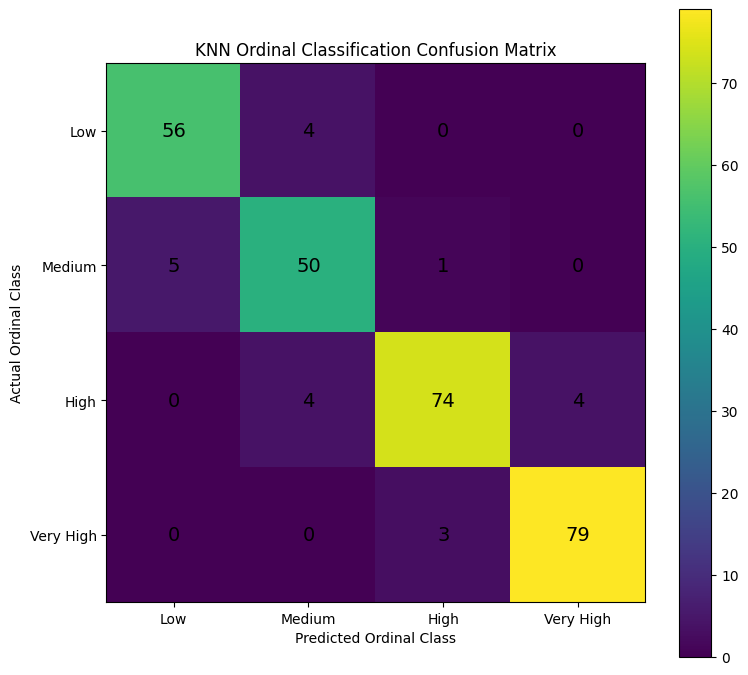

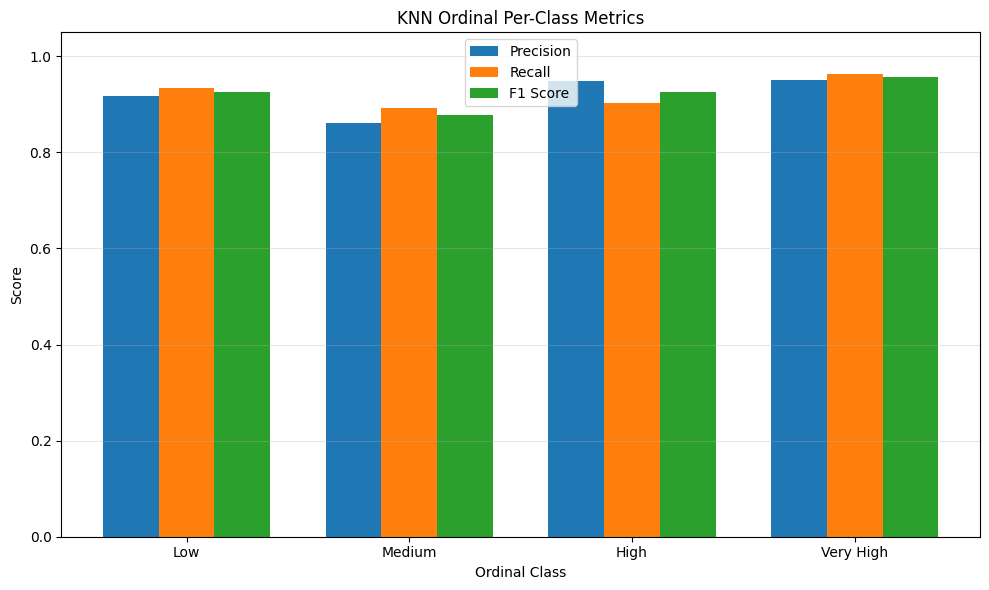

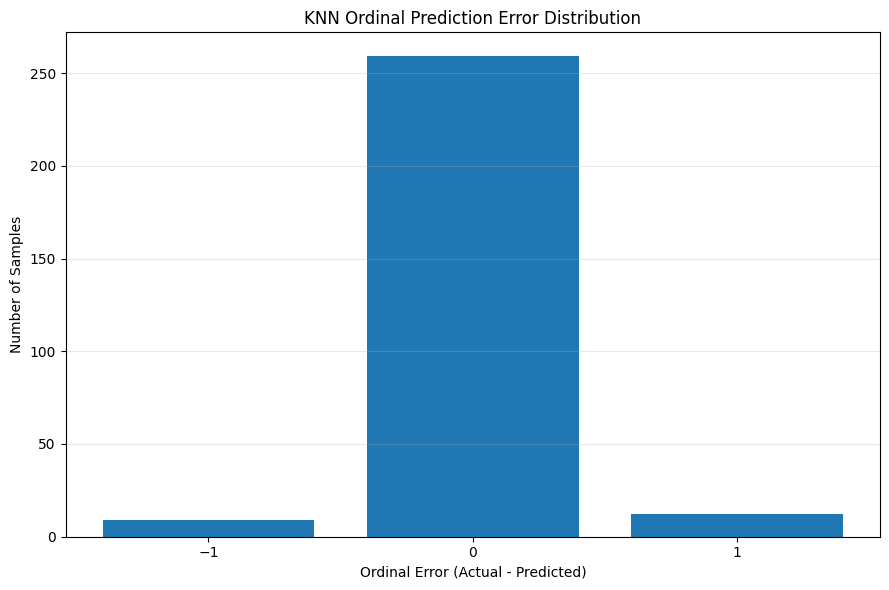

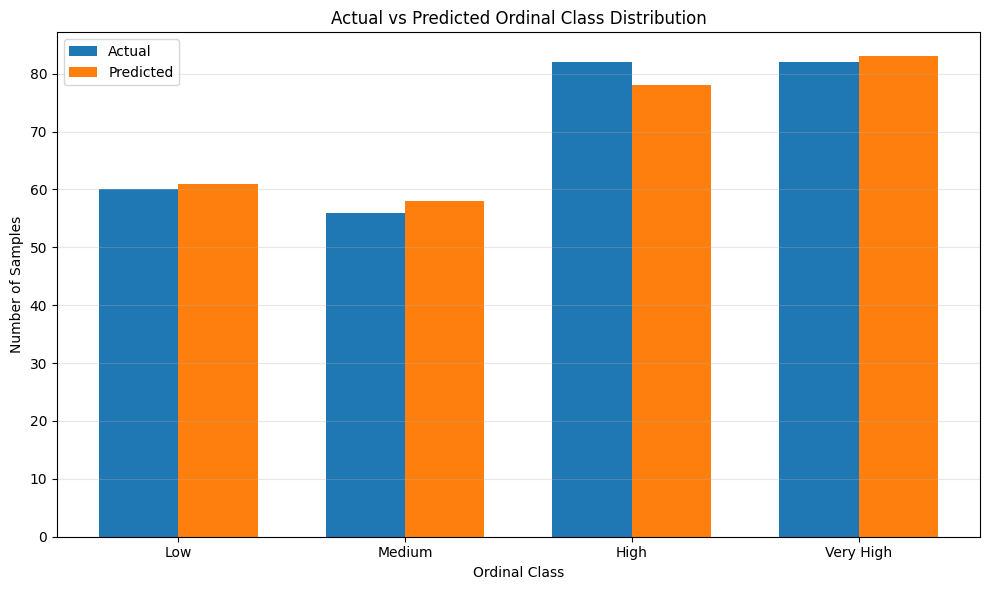

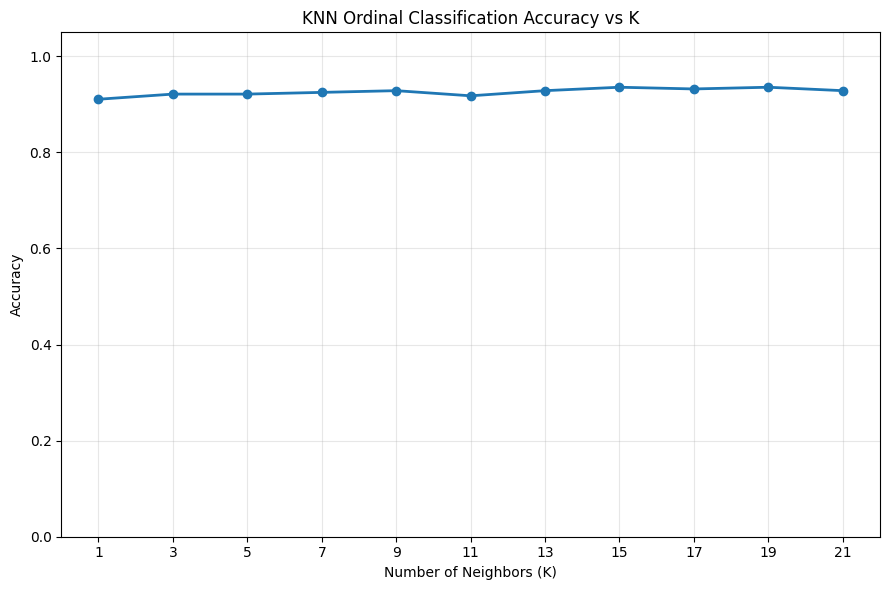

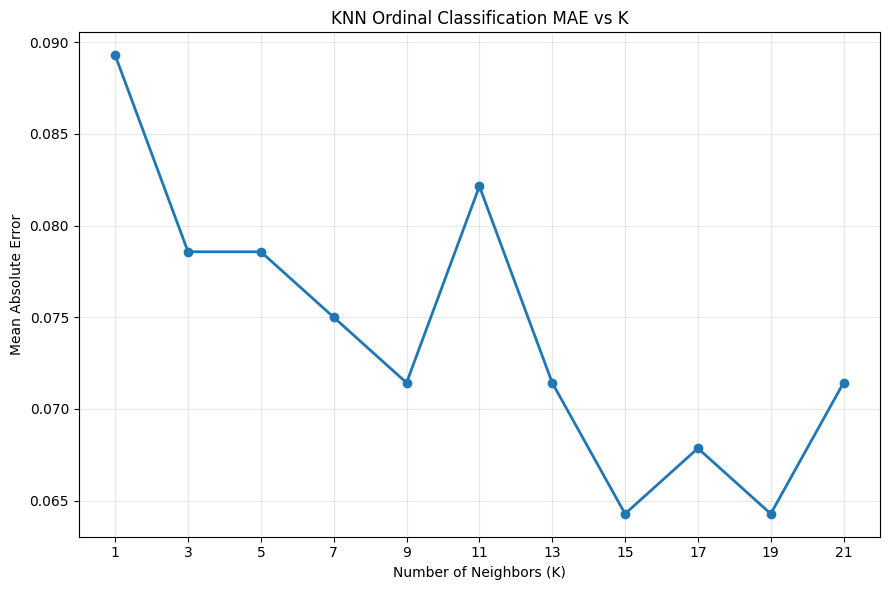

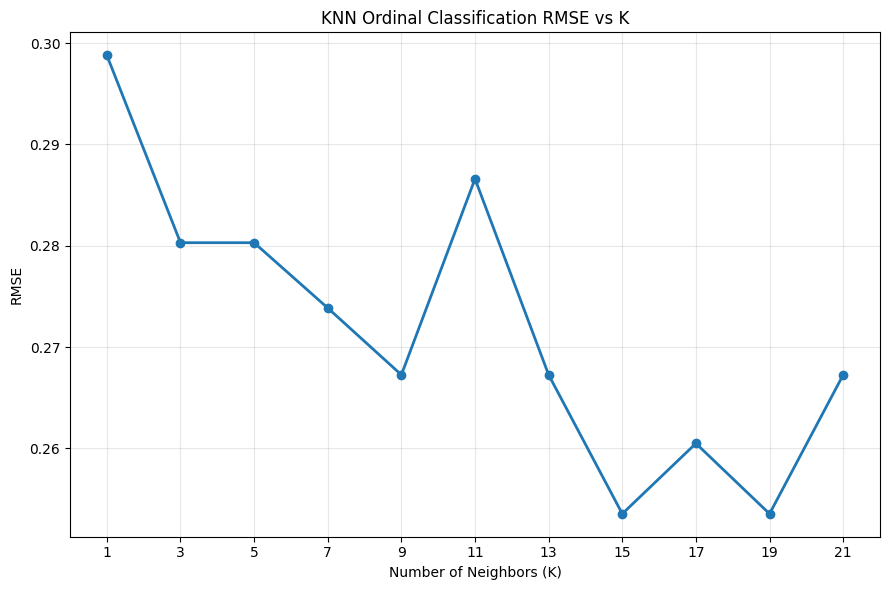

BEST K VALUES
Best K by Accuracy : 15
Best K by MAE      : 15
Best K by RMSE     : 15


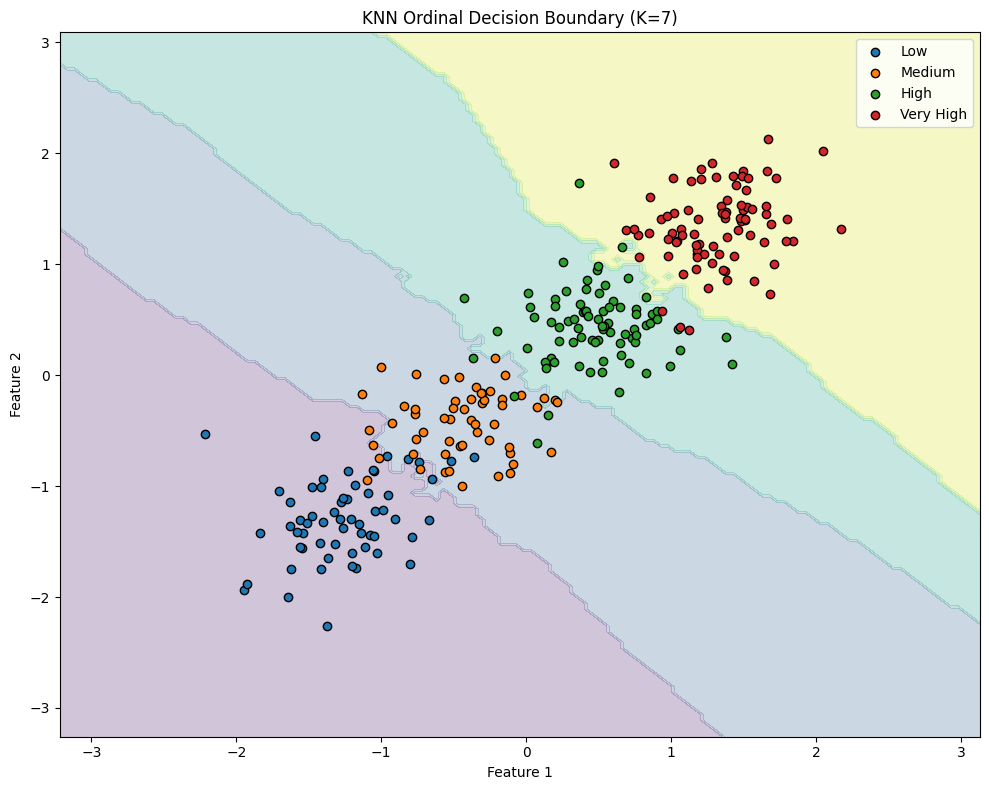

SAMPLE ORDINAL PREDICTIONS
Sample 1
Actual Class     : High
Predicted Class  : High
Ordinal Score    : 2.000
Probabilities    : [0. 0. 1. 0.]
---------------------------------------------------------------------------
Sample 2
Actual Class     : Very High
Predicted Class  : Very High
Ordinal Score    : 3.000
Probabilities    : [0. 0. 0. 1.]
---------------------------------------------------------------------------
Sample 3
Actual Class     : Low
Predicted Class  : Low
Ordinal Score    : 0.000
Probabilities    : [1. 0. 0. 0.]
---------------------------------------------------------------------------
Sample 4
Actual Class     : Very High
Predicted Class  : Very High
Ordinal Score    : 2.857
Probabilities    : [0.    0.    0.143 0.857]
---------------------------------------------------------------------------
Sample 5
Actual Class     : High
Predicted Class  : High
Ordinal Score    : 2.143
Probabilities    : [0.    0.    0.857 0.143]
----------------------------------------------------

In [4]:
# ============================================================
# KNN ORDINAL CLASSIFICATION FROM SCRATCH
# ============================================================
# NO SCIKIT-LEARN
# ONLY NUMPY + MATPLOTLIB
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. CREATE ORDINAL CLASSIFICATION DATASET
# ============================================================
#
# Four ordered classes:
#
# 0 = Low
# 1 = Medium
# 2 = High
# 3 = Very High
#
# The order is:
#
# 0 < 1 < 2 < 3
#
# ============================================================

np.random.seed(42)

n_samples_per_class = 350

# ------------------------------------------------------------
# Class 0 - Low
# ------------------------------------------------------------

X0 = np.random.multivariate_normal(
    mean=[1.5, 1.5],
    cov=[
        [0.7, 0.15],
        [0.15, 0.7]
    ],
    size=n_samples_per_class
)

y0 = np.zeros(
    n_samples_per_class,
    dtype=int
)


# ------------------------------------------------------------
# Class 1 - Medium
# ------------------------------------------------------------

X1 = np.random.multivariate_normal(
    mean=[3.5, 3.5],
    cov=[
        [0.7, 0.15],
        [0.15, 0.7]
    ],
    size=n_samples_per_class
)

y1 = np.ones(
    n_samples_per_class,
    dtype=int
)


# ------------------------------------------------------------
# Class 2 - High
# ------------------------------------------------------------

X2 = np.random.multivariate_normal(
    mean=[5.5, 5.5],
    cov=[
        [0.7, 0.15],
        [0.15, 0.7]
    ],
    size=n_samples_per_class
)

y2 = np.full(
    n_samples_per_class,
    2,
    dtype=int
)


# ------------------------------------------------------------
# Class 3 - Very High
# ------------------------------------------------------------

X3 = np.random.multivariate_normal(
    mean=[7.5, 7.5],
    cov=[
        [0.7, 0.15],
        [0.15, 0.7]
    ],
    size=n_samples_per_class
)

y3 = np.full(
    n_samples_per_class,
    3,
    dtype=int
)


# ============================================================
# 2. COMBINE DATA
# ============================================================

X = np.vstack([
    X0,
    X1,
    X2,
    X3
])

y = np.concatenate([
    y0,
    y1,
    y2,
    y3
])


# ============================================================
# 3. SHUFFLE DATASET
# ============================================================

indices = np.random.permutation(
    len(X)
)

X = X[indices]
y = y[indices]


# ============================================================
# 4. TRAIN / TEST SPLIT FROM SCRATCH
# ============================================================

test_size = 0.20

split_index = int(
    len(X) * (1 - test_size)
)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]


# ============================================================
# 5. STANDARDIZATION FROM SCRATCH
# ============================================================

train_mean = np.mean(
    X_train,
    axis=0
)

train_std = np.std(
    X_train,
    axis=0
)

# Prevent division by zero
train_std[
    train_std == 0
] = 1


X_train_scaled = (
    X_train - train_mean
) / train_std


X_test_scaled = (
    X_test - train_mean
) / train_std


# ============================================================
# 6. KNN ORDINAL CLASSIFIER
# ============================================================

class KNNOrdinalClassifier:

    def __init__(
        self,
        k=7
    ):

        self.k = k

        self.X_train = None
        self.y_train = None

        self.classes_ = None


    # ========================================================
    # FIT
    # ========================================================

    def fit(
        self,
        X,
        y
    ):

        self.X_train = X
        self.y_train = y

        # Ordered classes
        self.classes_ = np.sort(
            np.unique(y)
        )

        return self


    # ========================================================
    # EUCLIDEAN DISTANCE
    # ========================================================

    def _euclidean_distance(
        self,
        x
    ):

        distances = np.sqrt(
            np.sum(
                (
                    self.X_train - x
                ) ** 2,
                axis=1
            )
        )

        return distances


    # ========================================================
    # PREDICT PROBABILITY
    # ========================================================

    def predict_proba(
        self,
        X
    ):

        probabilities = []

        for x in X:

            # Calculate distance
            distances = (
                self._euclidean_distance(x)
            )

            # Get K nearest neighbors
            nearest_indices = np.argsort(
                distances
            )[:self.k]

            # Get their class labels
            nearest_labels = (
                self.y_train[
                    nearest_indices
                ]
            )

            # Calculate class probabilities
            class_probabilities = []

            for class_label in self.classes_:

                count = np.sum(
                    nearest_labels == class_label
                )

                probability = (
                    count / self.k
                )

                class_probabilities.append(
                    probability
                )

            probabilities.append(
                class_probabilities
            )

        return np.array(
            probabilities
        )


    # ========================================================
    # ORDINAL SCORE
    # ========================================================
    #
    # Instead of only counting the most frequent class,
    # calculate the weighted ordinal expectation.
    #
    # Example:
    #
    # probabilities = [0.0, 0.2, 0.6, 0.2]
    #
    # expected class =
    #
    # 0(0.0) + 1(0.2) + 2(0.6) + 3(0.2)
    #
    # = 2.0
    #
    # ========================================================

    def predict_ordinal_score(
        self,
        X
    ):

        probabilities = (
            self.predict_proba(X)
        )

        ordinal_scores = (
            probabilities @ self.classes_
        )

        return ordinal_scores


    # ========================================================
    # PREDICT
    # ========================================================

    def predict(
        self,
        X
    ):

        ordinal_scores = (
            self.predict_ordinal_score(X)
        )

        # Round to nearest ordinal class
        predictions = np.rint(
            ordinal_scores
        ).astype(int)

        # Keep predictions within valid range
        predictions = np.clip(
            predictions,
            self.classes_.min(),
            self.classes_.max()
        )

        return predictions


# ============================================================
# 7. TRAIN MODEL
# ============================================================

k = 7

model = KNNOrdinalClassifier(
    k=k
)

model.fit(
    X_train_scaled,
    y_train
)


# ============================================================
# 8. MAKE PREDICTIONS
# ============================================================

y_train_proba = model.predict_proba(
    X_train_scaled
)

y_test_proba = model.predict_proba(
    X_test_scaled
)


y_train_pred = model.predict(
    X_train_scaled
)

y_test_pred = model.predict(
    X_test_scaled
)


# ============================================================
# 9. ACCURACY
# ============================================================

def accuracy_score(
    y_true,
    y_pred
):

    return np.mean(
        y_true == y_pred
    )


train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)


# ============================================================
# 10. ORDINAL MAE
# ============================================================
#
# Mean Absolute Error is especially important for ordinal
# classification.
#
# MAE = average |actual - predicted|
#
# Example:
#
# Actual = 3
# Predicted = 1
#
# Error = |3 - 1| = 2
#
# ============================================================

def ordinal_mae(
    y_true,
    y_pred
):

    return np.mean(
        np.abs(
            y_true - y_pred
        )
    )


# ============================================================
# 11. ORDINAL RMSE
# ============================================================

def ordinal_rmse(
    y_true,
    y_pred
):

    return np.sqrt(
        np.mean(
            (
                y_true - y_pred
            ) ** 2
        )
    )


# ============================================================
# 12. WITHIN-ONE ACCURACY
# ============================================================
#
# Prediction is considered acceptable if it is:
#
# exact
# OR
# one ordinal level away.
#
# Example:
#
# Actual = 3
# Predicted = 2
#
# Correct within one level.
#
# ============================================================

def within_one_accuracy(
    y_true,
    y_pred
):

    difference = np.abs(
        y_true - y_pred
    )

    return np.mean(
        difference <= 1
    )


test_mae = ordinal_mae(
    y_test,
    y_test_pred
)

test_rmse = ordinal_rmse(
    y_test,
    y_test_pred
)

test_within_one = within_one_accuracy(
    y_test,
    y_test_pred
)


# ============================================================
# 13. MULTICLASS CONFUSION MATRIX
# ============================================================

def confusion_matrix_ordinal(
    y_true,
    y_pred,
    classes
):

    n_classes = len(classes)

    cm = np.zeros(
        (
            n_classes,
            n_classes
        ),
        dtype=int
    )

    for actual, predicted in zip(
        y_true,
        y_pred
    ):

        actual_index = np.where(
            classes == actual
        )[0][0]

        predicted_index = np.where(
            classes == predicted
        )[0][0]

        cm[
            actual_index,
            predicted_index
        ] += 1

    return cm


classes = np.sort(
    np.unique(y)
)

cm = confusion_matrix_ordinal(
    y_test,
    y_test_pred,
    classes
)


# ============================================================
# 14. PER-CLASS PRECISION
# ============================================================

def precision_per_class(
    y_true,
    y_pred,
    classes
):

    precision_values = []

    for class_label in classes:

        TP = np.sum(
            (y_true == class_label)
            &
            (y_pred == class_label)
        )

        FP = np.sum(
            (y_true != class_label)
            &
            (y_pred == class_label)
        )

        if TP + FP == 0:

            precision = 0.0

        else:

            precision = (
                TP / (TP + FP)
            )

        precision_values.append(
            precision
        )

    return np.array(
        precision_values
    )


# ============================================================
# 15. PER-CLASS RECALL
# ============================================================

def recall_per_class(
    y_true,
    y_pred,
    classes
):

    recall_values = []

    for class_label in classes:

        TP = np.sum(
            (y_true == class_label)
            &
            (y_pred == class_label)
        )

        FN = np.sum(
            (y_true == class_label)
            &
            (y_pred != class_label)
        )

        if TP + FN == 0:

            recall = 0.0

        else:

            recall = (
                TP / (TP + FN)
            )

        recall_values.append(
            recall
        )

    return np.array(
        recall_values
    )


# ============================================================
# 16. PER-CLASS F1
# ============================================================

def f1_per_class(
    precision,
    recall
):

    f1_values = []

    for p, r in zip(
        precision,
        recall
    ):

        if p + r == 0:

            f1 = 0.0

        else:

            f1 = (
                2 * p * r
            ) / (
                p + r
            )

        f1_values.append(
            f1
        )

    return np.array(
        f1_values
    )


# ============================================================
# 17. CALCULATE CLASSIFICATION METRICS
# ============================================================

precision_values = precision_per_class(
    y_test,
    y_test_pred,
    classes
)

recall_values = recall_per_class(
    y_test,
    y_test_pred,
    classes
)

f1_values = f1_per_class(
    precision_values,
    recall_values
)


macro_precision = np.mean(
    precision_values
)

macro_recall = np.mean(
    recall_values
)

macro_f1 = np.mean(
    f1_values
)


# ============================================================
# 18. QUADRATIC WEIGHTED KAPPA
# ============================================================
#
# Important for ordinal classification.
#
# A prediction one class away receives a smaller penalty
# than a prediction several classes away.
#
# ============================================================

def quadratic_weighted_kappa(
    y_true,
    y_pred,
    classes
):

    n_classes = len(classes)

    # --------------------------------------------------------
    # Observed confusion matrix
    # --------------------------------------------------------

    O = confusion_matrix_ordinal(
        y_true,
        y_pred,
        classes
    ).astype(float)


    # --------------------------------------------------------
    # Actual class counts
    # --------------------------------------------------------

    actual_histogram = np.sum(
        O,
        axis=1
    )


    # --------------------------------------------------------
    # Predicted class counts
    # --------------------------------------------------------

    predicted_histogram = np.sum(
        O,
        axis=0
    )


    # --------------------------------------------------------
    # Expected matrix
    # --------------------------------------------------------

    N = np.sum(O)

    E = np.outer(
        actual_histogram,
        predicted_histogram
    ) / N


    # --------------------------------------------------------
    # Quadratic weight matrix
    # --------------------------------------------------------

    W = np.zeros(
        (
            n_classes,
            n_classes
        )
    )

    for i in range(n_classes):

        for j in range(n_classes):

            W[i, j] = (
                (i - j) ** 2
                /
                (n_classes - 1) ** 2
            )


    # --------------------------------------------------------
    # Kappa
    # --------------------------------------------------------

    observed_disagreement = np.sum(
        W * O
    )

    expected_disagreement = np.sum(
        W * E
    )

    if expected_disagreement == 0:

        return 1.0

    kappa = (
        1
        -
        observed_disagreement
        /
        expected_disagreement
    )

    return kappa


qwk = quadratic_weighted_kappa(
    y_test,
    y_test_pred,
    classes
)


# ============================================================
# 19. PRINT FINAL EVALUATION
# ============================================================

print("=" * 75)
print("KNN ORDINAL CLASSIFICATION RESULTS")
print("=" * 75)

print(
    f"K value                  : {k}"
)

print(
    f"Number of classes        : {len(classes)}"
)

print(
    f"Training samples         : {len(X_train)}"
)

print(
    f"Testing samples          : {len(X_test)}"
)

print("-" * 75)

print(
    f"Training Accuracy        : "
    f"{train_accuracy:.4f}"
)

print(
    f"Test Accuracy            : "
    f"{test_accuracy:.4f}"
)

print(
    f"Ordinal MAE              : "
    f"{test_mae:.4f}"
)

print(
    f"Ordinal RMSE             : "
    f"{test_rmse:.4f}"
)

print(
    f"Within-1 Accuracy        : "
    f"{test_within_one:.4f}"
)

print(
    f"Macro Precision          : "
    f"{macro_precision:.4f}"
)

print(
    f"Macro Recall             : "
    f"{macro_recall:.4f}"
)

print(
    f"Macro F1                 : "
    f"{macro_f1:.4f}"
)

print(
    f"Quadratic Weighted Kappa : "
    f"{qwk:.4f}"
)

print("-" * 75)

print("PER-CLASS METRICS")

print("-" * 75)

for i, class_label in enumerate(classes):

    print(
        f"Class {class_label}: "
        f"Precision = "
        f"{precision_values[i]:.4f}, "
        f"Recall = "
        f"{recall_values[i]:.4f}, "
        f"F1 = "
        f"{f1_values[i]:.4f}"
    )

print("-" * 75)

print("CONFUSION MATRIX")

print("-" * 75)

print(cm)

print("=" * 75)


# ============================================================
# 20. CONFUSION MATRIX PLOT
# ============================================================

plt.figure(
    figsize=(8, 7)
)

plt.imshow(cm)

plt.title(
    "KNN Ordinal Classification Confusion Matrix"
)

plt.xlabel(
    "Predicted Ordinal Class"
)

plt.ylabel(
    "Actual Ordinal Class"
)

plt.xticks(
    range(len(classes)),
    [
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

plt.yticks(
    range(len(classes)),
    [
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

for i in range(len(classes)):

    for j in range(len(classes)):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=14
        )

plt.colorbar()

plt.tight_layout()

plt.show()


# ============================================================
# 21. PER-CLASS METRICS PLOT
# ============================================================

x = np.arange(
    len(classes)
)

width = 0.25

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    x - width,
    precision_values,
    width,
    label="Precision"
)

plt.bar(
    x,
    recall_values,
    width,
    label="Recall"
)

plt.bar(
    x + width,
    f1_values,
    width,
    label="F1 Score"
)

plt.xlabel(
    "Ordinal Class"
)

plt.ylabel(
    "Score"
)

plt.title(
    "KNN Ordinal Per-Class Metrics"
)

plt.xticks(
    x,
    [
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

plt.ylim(
    0,
    1.05
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 22. ORDINAL ERROR DISTRIBUTION
# ============================================================
#
# Shows:
#
# Actual - Predicted
#
# Negative -> model predicted too high
# Positive -> model predicted too low
#
# ============================================================

ordinal_errors = (
    y_test - y_test_pred
)

unique_errors, error_counts = np.unique(
    ordinal_errors,
    return_counts=True
)

plt.figure(
    figsize=(9, 6)
)

plt.bar(
    unique_errors,
    error_counts
)

plt.xlabel(
    "Ordinal Error (Actual - Predicted)"
)

plt.ylabel(
    "Number of Samples"
)

plt.title(
    "KNN Ordinal Prediction Error Distribution"
)

plt.xticks(
    unique_errors
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 23. ACTUAL VS PREDICTED CLASS DISTRIBUTION
# ============================================================

actual_counts = []

predicted_counts = []

for class_label in classes:

    actual_counts.append(
        np.sum(
            y_test == class_label
        )
    )

    predicted_counts.append(
        np.sum(
            y_test_pred == class_label
        )
    )


x = np.arange(
    len(classes)
)

width = 0.35

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    x - width / 2,
    actual_counts,
    width,
    label="Actual"
)

plt.bar(
    x + width / 2,
    predicted_counts,
    width,
    label="Predicted"
)

plt.xlabel(
    "Ordinal Class"
)

plt.ylabel(
    "Number of Samples"
)

plt.title(
    "Actual vs Predicted Ordinal Class Distribution"
)

plt.xticks(
    x,
    [
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 24. ACCURACY / MAE / RMSE VS K
# ============================================================

k_values = range(
    1,
    22,
    2
)

accuracy_values = []
mae_values = []
rmse_values = []


for current_k in k_values:

    temp_model = KNNOrdinalClassifier(
        k=current_k
    )

    temp_model.fit(
        X_train_scaled,
        y_train
    )

    temp_pred = temp_model.predict(
        X_test_scaled
    )


    # Accuracy

    acc = accuracy_score(
        y_test,
        temp_pred
    )


    # MAE

    mae = ordinal_mae(
        y_test,
        temp_pred
    )


    # RMSE

    rmse = ordinal_rmse(
        y_test,
        temp_pred
    )


    accuracy_values.append(
        acc
    )

    mae_values.append(
        mae
    )

    rmse_values.append(
        rmse
    )


# ============================================================
# 25. ACCURACY VS K PLOT
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    list(k_values),
    accuracy_values,
    marker="o",
    linewidth=2
)

plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "KNN Ordinal Classification Accuracy vs K"
)

plt.xticks(
    list(k_values)
)

plt.ylim(
    0,
    1.05
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 26. MAE VS K PLOT
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    list(k_values),
    mae_values,
    marker="o",
    linewidth=2
)

plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "Mean Absolute Error"
)

plt.title(
    "KNN Ordinal Classification MAE vs K"
)

plt.xticks(
    list(k_values)
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 27. RMSE VS K PLOT
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    list(k_values),
    rmse_values,
    marker="o",
    linewidth=2
)

plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "RMSE"
)

plt.title(
    "KNN Ordinal Classification RMSE vs K"
)

plt.xticks(
    list(k_values)
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 28. FIND BEST K
# ============================================================

best_accuracy_index = np.argmax(
    accuracy_values
)

best_accuracy_k = list(
    k_values
)[best_accuracy_index]


best_mae_index = np.argmin(
    mae_values
)

best_mae_k = list(
    k_values
)[best_mae_index]


best_rmse_index = np.argmin(
    rmse_values
)

best_rmse_k = list(
    k_values
)[best_rmse_index]


print("=" * 60)
print("BEST K VALUES")
print("=" * 60)

print(
    f"Best K by Accuracy : "
    f"{best_accuracy_k}"
)

print(
    f"Best K by MAE      : "
    f"{best_mae_k}"
)

print(
    f"Best K by RMSE     : "
    f"{best_rmse_k}"
)

print("=" * 60)


# ============================================================
# 29. DECISION BOUNDARY
# ============================================================

def plot_decision_boundary(
    model,
    X,
    y,
    title
):

    x_min = X[:, 0].min() - 1
    x_max = X[:, 0].max() + 1

    y_min = X[:, 1].min() - 1
    y_max = X[:, 1].max() + 1

    step = 0.05

    xx, yy = np.meshgrid(
        np.arange(
            x_min,
            x_max,
            step
        ),
        np.arange(
            y_min,
            y_max,
            step
        )
    )

    grid = np.c_[
        xx.ravel(),
        yy.ravel()
    ]

    predictions = model.predict(
        grid
    )

    predictions = predictions.reshape(
        xx.shape
    )


    plt.figure(
        figsize=(10, 8)
    )

    plt.contourf(
        xx,
        yy,
        predictions,
        alpha=0.25
    )


    class_names = [
        "Low",
        "Medium",
        "High",
        "Very High"
    ]


    for class_label in np.unique(y):

        mask = (
            y == class_label
        )

        plt.scatter(
            X[mask, 0],
            X[mask, 1],
            label=class_names[class_label],
            edgecolors="black"
        )


    plt.xlabel(
        "Feature 1"
    )

    plt.ylabel(
        "Feature 2"
    )

    plt.title(
        title
    )

    plt.legend()

    plt.tight_layout()

    plt.show()


# ============================================================
# 30. PLOT DECISION BOUNDARY
# ============================================================

plot_decision_boundary(
    model,
    X_test_scaled,
    y_test,
    f"KNN Ordinal Decision Boundary (K={k})"
)


# ============================================================
# 31. SAMPLE PREDICTIONS
# ============================================================

class_names = [
    "Low",
    "Medium",
    "High",
    "Very High"
]


print("=" * 75)
print("SAMPLE ORDINAL PREDICTIONS")
print("=" * 75)


for i in range(15):

    ordinal_score = (
        model.predict_ordinal_score(
            X_test_scaled[i:i+1]
        )[0]
    )

    print(
        f"Sample {i + 1}"
    )

    print(
        f"Actual Class     : "
        f"{class_names[y_test[i]]}"
    )

    print(
        f"Predicted Class  : "
        f"{class_names[y_test_pred[i]]}"
    )

    print(
        f"Ordinal Score    : "
        f"{ordinal_score:.3f}"
    )

    print(
        f"Probabilities    : "
        f"{np.round(y_test_proba[i], 3)}"
    )

    print("-" * 75)

X shape: (1000, 2)
y shape: (1000,)

Train samples: 800
Test samples : 200

MEAN KNN REGRESSION EVALUATION

K = 7

TRAINING PERFORMANCE
----------------------------------------
MAE  : 2.6556
MSE  : 11.1246
RMSE : 3.3354
R²   : 0.9850
MAPE : 98.66%

TEST PERFORMANCE
----------------------------------------
MAE  : 2.9630
MSE  : 13.8270
RMSE : 3.7185
R²   : 0.9832
MAPE : 109.85%


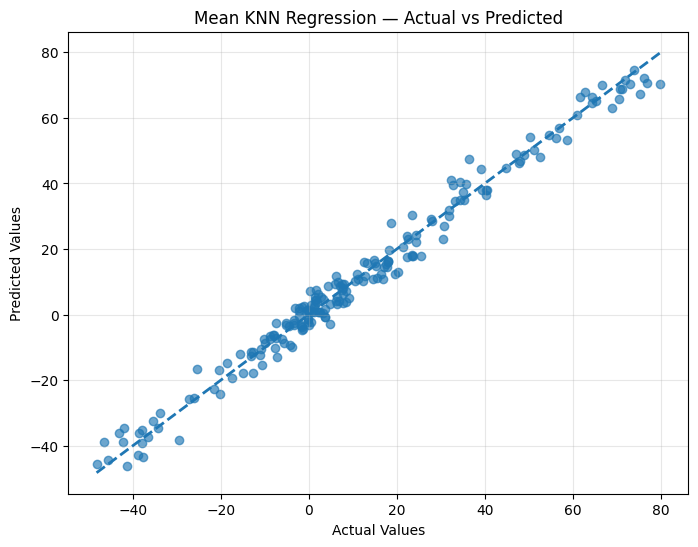

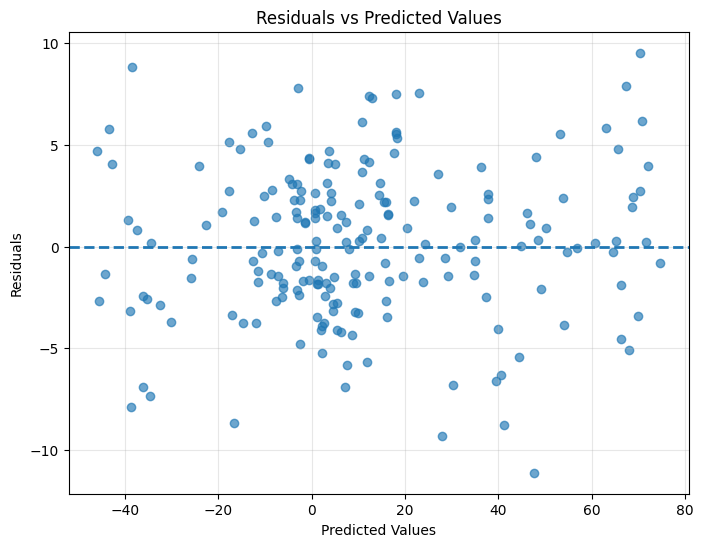

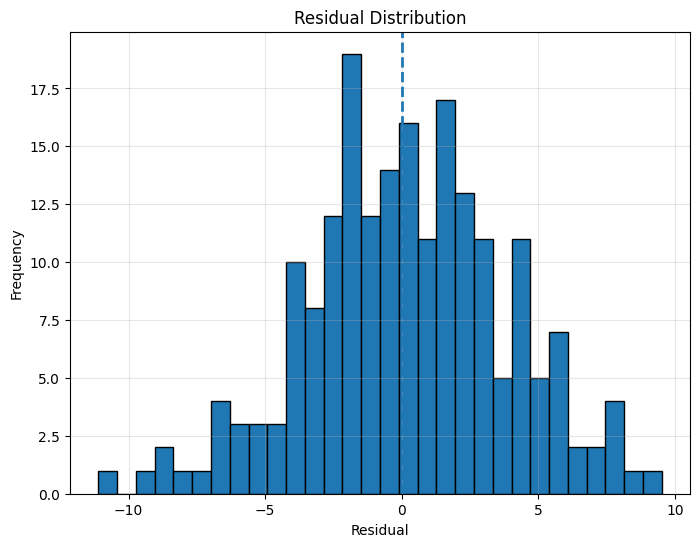

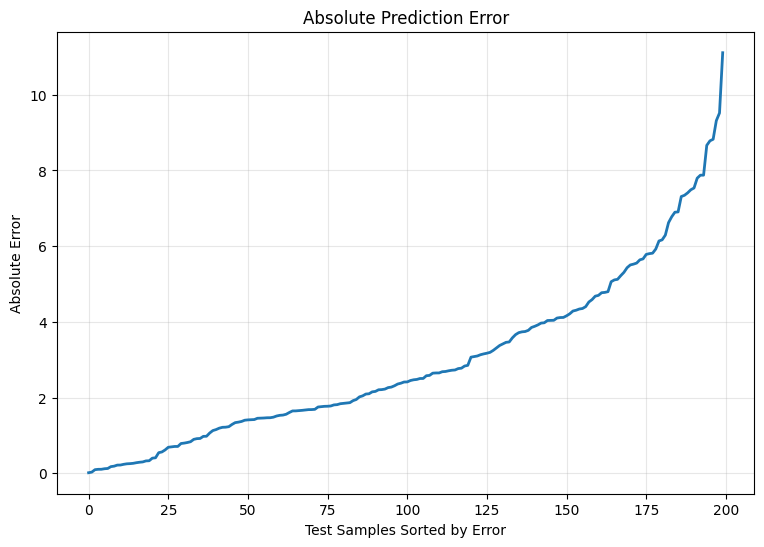


BEST K ANALYSIS
Best K according to MAE  : 4
Best K according to RMSE : 4
Best K according to R²   : 4


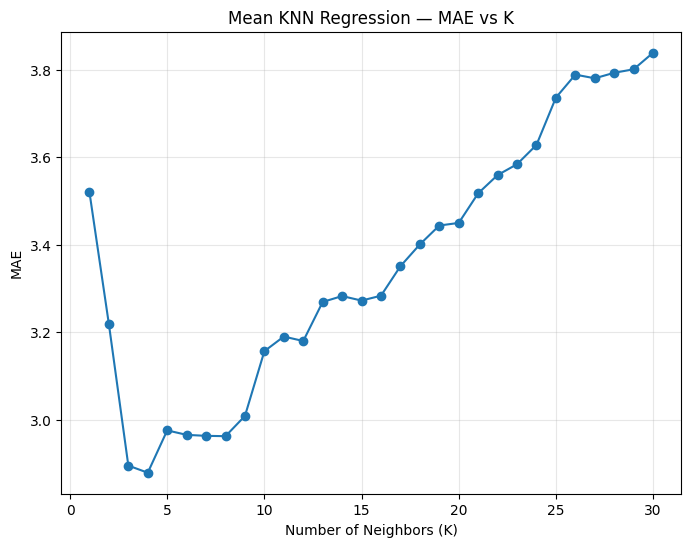

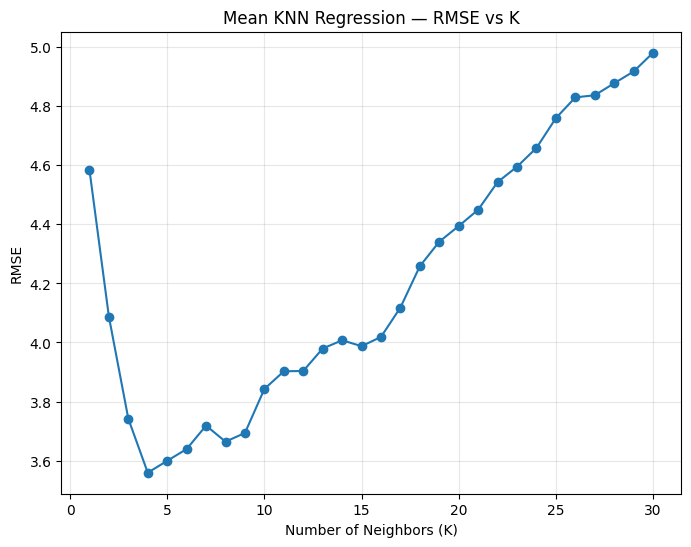

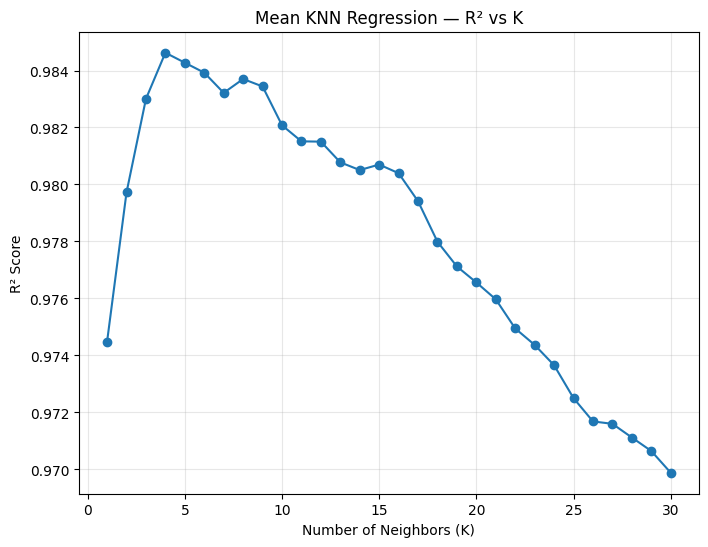

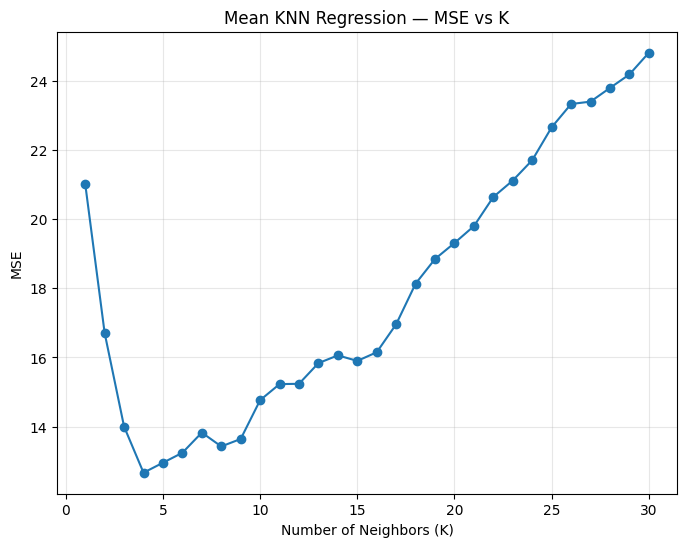

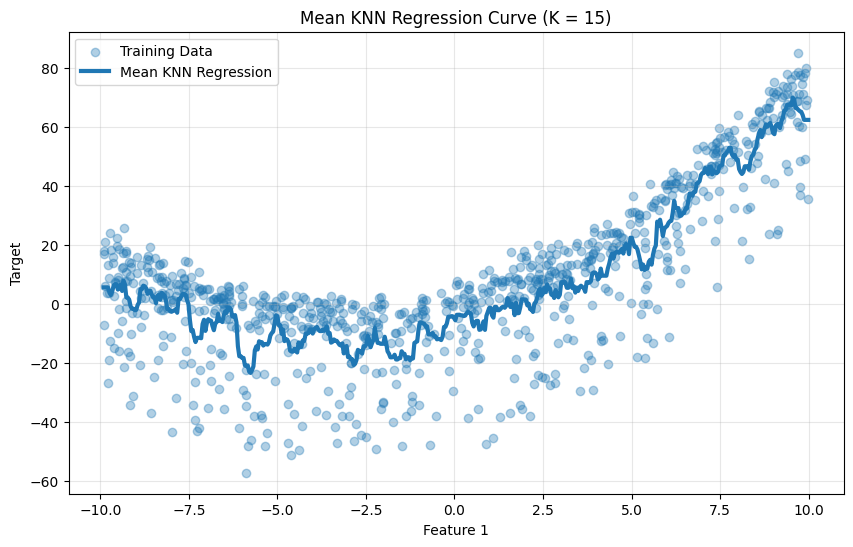


SAMPLE TEST PREDICTIONS
Sample  1 | Actual =   -7.665 | Predicted =  -10.170 | Error =    2.505
Sample  2 | Actual =  -37.732 | Predicted =  -43.516 | Error =    5.784
Sample  3 | Actual =   14.880 | Predicted =   16.571 | Error =   -1.691
Sample  4 | Actual =   17.599 | Predicted =   15.392 | Error =    2.207
Sample  5 | Actual =   70.674 | Predicted =   68.723 | Error =    1.950
Sample  6 | Actual =   -7.516 | Predicted =   -7.298 | Error =   -0.218
Sample  7 | Actual =    6.819 | Predicted =    4.173 | Error =    2.646
Sample  8 | Actual =   12.290 | Predicted =   10.188 | Error =    2.102
Sample  9 | Actual =   71.238 | Predicted =   68.786 | Error =    2.452
Sample 10 | Actual =   73.899 | Predicted =   74.698 | Error =   -0.799
Sample 11 | Actual =   32.383 | Predicted =   41.166 | Error =   -8.783
Sample 12 | Actual =    3.262 | Predicted =    0.610 | Error =    2.652
Sample 13 | Actual =   68.958 | Predicted =   63.143 | Error =    5.816
Sample 14 | Actual =   -5.221 | Predict

In [5]:
# ============================================================
# MEAN KNN REGRESSION FROM SCRATCH
# NO SCIKIT-LEARN
# ONLY NUMPY + MATPLOTLIB
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

np.random.seed(42)


# ============================================================
# 2. GENERATE SYNTHETIC REGRESSION DATA
# ============================================================

n_samples = 1000

X = np.random.uniform(-10, 10, size=(n_samples, 2))

# Non-linear regression relationship
y = (
    3.0 * X[:, 0]
    + 2.0 * X[:, 1]
    + 0.5 * X[:, 0]**2
    - 0.3 * X[:, 1]**2
    + np.sin(X[:, 0])
    + np.random.normal(0, 3, n_samples)
)

print("X shape:", X.shape)
print("y shape:", y.shape)


# ============================================================
# 3. TRAIN-TEST SPLIT FROM SCRATCH
# ============================================================

indices = np.random.permutation(n_samples)

train_size = int(0.80 * n_samples)

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

print("\nTrain samples:", len(X_train))
print("Test samples :", len(X_test))


# ============================================================
# 4. STANDARDIZATION FROM SCRATCH
# ============================================================
# IMPORTANT:
# Mean and standard deviation are calculated ONLY from
# training data to avoid data leakage.
# ============================================================

X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)

# Prevent division by zero
X_std[X_std == 0] = 1.0

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std


# ============================================================
# 5. MEAN KNN REGRESSOR
# ============================================================

class MeanKNNRegressor:

    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors

    # --------------------------------------------------------
    # FIT
    # --------------------------------------------------------

    def fit(self, X, y):

        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        if X.ndim != 2:
            raise ValueError("X must be a 2D array.")

        if y.ndim != 1:
            raise ValueError("y must be a 1D array.")

        if len(X) != len(y):
            raise ValueError(
                "X and y must contain the same number of samples."
            )

        if self.n_neighbors <= 0:
            raise ValueError(
                "n_neighbors must be greater than 0."
            )

        if self.n_neighbors > len(X):
            raise ValueError(
                "n_neighbors cannot be greater than training samples."
            )

        self.X_train = X
        self.y_train = y

        return self

    # --------------------------------------------------------
    # EUCLIDEAN DISTANCE
    # --------------------------------------------------------

    def _euclidean_distance(self, X_query):

        distances = np.sqrt(
            np.sum(
                (self.X_train - X_query) ** 2,
                axis=1
            )
        )

        return distances

    # --------------------------------------------------------
    # PREDICT
    # --------------------------------------------------------

    def predict(self, X):

        X = np.asarray(X, dtype=float)

        predictions = []

        for x in X:

            # Calculate distance from x to every training sample
            distances = self._euclidean_distance(x)

            # Get indices of K nearest neighbors
            nearest_indices = np.argsort(distances)[
                :self.n_neighbors
            ]

            # Get target values of K nearest neighbors
            nearest_y = self.y_train[nearest_indices]

            # ------------------------------------------------
            # MEAN KNN REGRESSION
            # ------------------------------------------------
            prediction = np.mean(nearest_y)

            predictions.append(prediction)

        return np.array(predictions)


# ============================================================
# 6. CREATE MODEL
# ============================================================

K = 7

model = MeanKNNRegressor(
    n_neighbors=K
)


# ============================================================
# 7. TRAIN MODEL
# ============================================================

model.fit(
    X_train_scaled,
    y_train
)


# ============================================================
# 8. MAKE PREDICTIONS
# ============================================================

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)


# ============================================================
# 9. EVALUATION METRICS FROM SCRATCH
# ============================================================

def mean_absolute_error(y_true, y_pred):

    return np.mean(
        np.abs(y_true - y_pred)
    )


def mean_squared_error(y_true, y_pred):

    return np.mean(
        (y_true - y_pred) ** 2
    )


def root_mean_squared_error(y_true, y_pred):

    return np.sqrt(
        mean_squared_error(y_true, y_pred)
    )


def r2_score(y_true, y_pred):

    ss_res = np.sum(
        (y_true - y_pred) ** 2
    )

    ss_tot = np.sum(
        (y_true - np.mean(y_true)) ** 2
    )

    if ss_tot == 0:
        return 0.0

    return 1 - (ss_res / ss_tot)


def mean_absolute_percentage_error(y_true, y_pred):

    # Avoid division by zero
    denominator = np.where(
        np.abs(y_true) < 1e-10,
        1e-10,
        np.abs(y_true)
    )

    return np.mean(
        np.abs(
            (y_true - y_pred) / denominator
        )
    ) * 100


# ============================================================
# 10. CALCULATE TRAINING METRICS
# ============================================================

train_mae = mean_absolute_error(
    y_train,
    y_train_pred
)

train_mse = mean_squared_error(
    y_train,
    y_train_pred
)

train_rmse = root_mean_squared_error(
    y_train,
    y_train_pred
)

train_r2 = r2_score(
    y_train,
    y_train_pred
)

train_mape = mean_absolute_percentage_error(
    y_train,
    y_train_pred
)


# ============================================================
# 11. CALCULATE TEST METRICS
# ============================================================

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

test_mse = mean_squared_error(
    y_test,
    y_test_pred
)

test_rmse = root_mean_squared_error(
    y_test,
    y_test_pred
)

test_r2 = r2_score(
    y_test,
    y_test_pred
)

test_mape = mean_absolute_percentage_error(
    y_test,
    y_test_pred
)


# ============================================================
# 12. PRINT EVALUATION RESULTS
# ============================================================

print("\n" + "=" * 60)
print("MEAN KNN REGRESSION EVALUATION")
print("=" * 60)

print("\nK =", K)

print("\nTRAINING PERFORMANCE")
print("-" * 40)
print(f"MAE  : {train_mae:.4f}")
print(f"MSE  : {train_mse:.4f}")
print(f"RMSE : {train_rmse:.4f}")
print(f"R²   : {train_r2:.4f}")
print(f"MAPE : {train_mape:.2f}%")

print("\nTEST PERFORMANCE")
print("-" * 40)
print(f"MAE  : {test_mae:.4f}")
print(f"MSE  : {test_mse:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"R²   : {test_r2:.4f}")
print(f"MAPE : {test_mape:.2f}%")


# ============================================================
# 13. RESIDUAL CALCULATION
# ============================================================

residuals = y_test - y_test_pred

absolute_errors = np.abs(
    y_test - y_test_pred
)


# ============================================================
# 14. PLOT 1 — ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.65
)

min_value = min(
    np.min(y_test),
    np.min(y_test_pred)
)

max_value = max(
    np.max(y_test),
    np.max(y_test_pred)
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title(
    "Mean KNN Regression — Actual vs Predicted"
)

plt.grid(True, alpha=0.3)

plt.show()


# ============================================================
# 15. PLOT 2 — RESIDUALS VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.65
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title(
    "Residuals vs Predicted Values"
)

plt.grid(True, alpha=0.3)

plt.show()


# ============================================================
# 16. PLOT 3 — RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 6))

plt.hist(
    residuals,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.title(
    "Residual Distribution"
)

plt.grid(True, alpha=0.3)

plt.show()


# ============================================================
# 17. PLOT 4 — ABSOLUTE PREDICTION ERROR
# ============================================================

sorted_errors = np.sort(
    absolute_errors
)

plt.figure(figsize=(9, 6))

plt.plot(
    sorted_errors,
    linewidth=2
)

plt.xlabel("Test Samples Sorted by Error")
plt.ylabel("Absolute Error")

plt.title(
    "Absolute Prediction Error"
)

plt.grid(True, alpha=0.3)

plt.show()


# ============================================================
# 18. EVALUATE DIFFERENT K VALUES
# ============================================================

k_values = np.arange(
    1,
    31
)

mae_values = []
mse_values = []
rmse_values = []
r2_values = []

for k in k_values:

    temp_model = MeanKNNRegressor(
        n_neighbors=k
    )

    temp_model.fit(
        X_train_scaled,
        y_train
    )

    temp_pred = temp_model.predict(
        X_test_scaled
    )

    mae_values.append(
        mean_absolute_error(
            y_test,
            temp_pred
        )
    )

    mse_values.append(
        mean_squared_error(
            y_test,
            temp_pred
        )
    )

    rmse_values.append(
        root_mean_squared_error(
            y_test,
            temp_pred
        )
    )

    r2_values.append(
        r2_score(
            y_test,
            temp_pred
        )
    )


mae_values = np.array(mae_values)
mse_values = np.array(mse_values)
rmse_values = np.array(rmse_values)
r2_values = np.array(r2_values)


# ============================================================
# 19. FIND BEST K
# ============================================================

best_k_mae = k_values[
    np.argmin(mae_values)
]

best_k_rmse = k_values[
    np.argmin(rmse_values)
]

best_k_r2 = k_values[
    np.argmax(r2_values)
]

print("\n" + "=" * 60)
print("BEST K ANALYSIS")
print("=" * 60)

print(
    f"Best K according to MAE  : {best_k_mae}"
)

print(
    f"Best K according to RMSE : {best_k_rmse}"
)

print(
    f"Best K according to R²   : {best_k_r2}"
)


# ============================================================
# 20. PLOT 5 — MAE VS K
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    k_values,
    mae_values,
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("MAE")

plt.title(
    "Mean KNN Regression — MAE vs K"
)

plt.grid(True, alpha=0.3)

plt.show()


# ============================================================
# 21. PLOT 6 — RMSE VS K
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    k_values,
    rmse_values,
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("RMSE")

plt.title(
    "Mean KNN Regression — RMSE vs K"
)

plt.grid(True, alpha=0.3)

plt.show()


# ============================================================
# 22. PLOT 7 — R² VS K
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    k_values,
    r2_values,
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("R² Score")

plt.title(
    "Mean KNN Regression — R² vs K"
)

plt.grid(True, alpha=0.3)

plt.show()


# ============================================================
# 23. PLOT 8 — MSE VS K
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    k_values,
    mse_values,
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("MSE")

plt.title(
    "Mean KNN Regression — MSE vs K"
)

plt.grid(True, alpha=0.3)

plt.show()


# ============================================================
# 24. KNN REGRESSION CURVE
# ============================================================
# For visualization, we use only the first feature.
# The model itself above uses BOTH features.
# ============================================================

X_1d = X[:, 0].reshape(-1, 1)

indices_1d = np.random.permutation(
    len(X_1d)
)

train_size_1d = int(
    0.80 * len(X_1d)
)

idx_train_1d = indices_1d[
    :train_size_1d
]

idx_test_1d = indices_1d[
    train_size_1d:
]

X_train_1d = X_1d[idx_train_1d]
X_test_1d = X_1d[idx_test_1d]

y_train_1d = y[idx_train_1d]
y_test_1d = y[idx_test_1d]

# Scale 1D feature
mean_1d = np.mean(
    X_train_1d,
    axis=0
)

std_1d = np.std(
    X_train_1d,
    axis=0
)

std_1d[std_1d == 0] = 1.0

X_train_1d_scaled = (
    X_train_1d - mean_1d
) / std_1d

X_test_1d_scaled = (
    X_test_1d - mean_1d
) / std_1d

curve_model = MeanKNNRegressor(
    n_neighbors=15
)

curve_model.fit(
    X_train_1d_scaled,
    y_train_1d
)

x_grid = np.linspace(
    np.min(X_train_1d),
    np.max(X_train_1d),
    500
).reshape(-1, 1)

x_grid_scaled = (
    x_grid - mean_1d
) / std_1d

y_grid_pred = curve_model.predict(
    x_grid_scaled
)


# ============================================================
# 25. PLOT 9 — KNN REGRESSION CURVE
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    X_train_1d,
    y_train_1d,
    alpha=0.35,
    label="Training Data"
)

plt.plot(
    x_grid,
    y_grid_pred,
    linewidth=3,
    label="Mean KNN Regression"
)

plt.xlabel("Feature 1")
plt.ylabel("Target")

plt.title(
    "Mean KNN Regression Curve (K = 15)"
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()


# ============================================================
# 26. SAMPLE PREDICTIONS
# ============================================================

print("\n" + "=" * 60)
print("SAMPLE TEST PREDICTIONS")
print("=" * 60)

for i in range(15):

    print(
        f"Sample {i+1:2d} | "
        f"Actual = {y_test[i]:8.3f} | "
        f"Predicted = {y_test_pred[i]:8.3f} | "
        f"Error = {residuals[i]:8.3f}"
    )


# ============================================================
# 27. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)

print(f"K                    : {K}")
print(f"Training Samples     : {len(X_train)}")
print(f"Testing Samples      : {len(X_test)}")
print(f"Number of Features   : {X_train.shape[1]}")

print("\nTest Metrics:")
print(f"MAE                  : {test_mae:.4f}")
print(f"MSE                  : {test_mse:.4f}")
print(f"RMSE                 : {test_rmse:.4f}")
print(f"R²                   : {test_r2:.4f}")
print(f"MAPE                 : {test_mape:.2f}%")

print("\nBest K:")
print(f"Best K by MAE        : {best_k_mae}")
print(f"Best K by RMSE       : {best_k_rmse}")
print(f"Best K by R²         : {best_k_r2}")

print("\n" + "=" * 60)
print("DONE")
print("=" * 60)

DATASET
X shape: (1000, 2)
y shape: (1000,)

TRAIN / TEST SPLIT
-----------------------------------------------------------------
Training samples: 800
Testing samples : 200


MEDIAN KNN REGRESSION — EVALUATION

K = 7

TRAINING PERFORMANCE
---------------------------------------------
MAE  : 3.0375
MSE  : 41.6849
RMSE : 6.4564
R²   : 0.9490
MAPE : 75.54%

TEST PERFORMANCE
---------------------------------------------
MAE  : 4.5823
MSE  : 73.1387
RMSE : 8.5521
R²   : 0.8949
MAPE : 91.13%


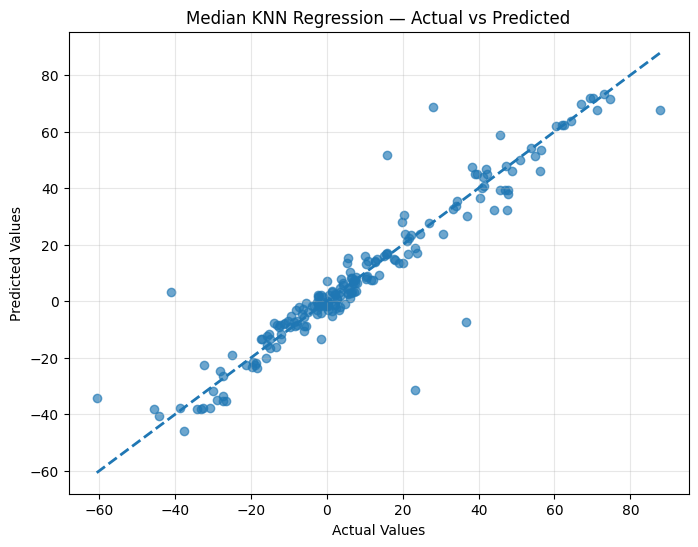

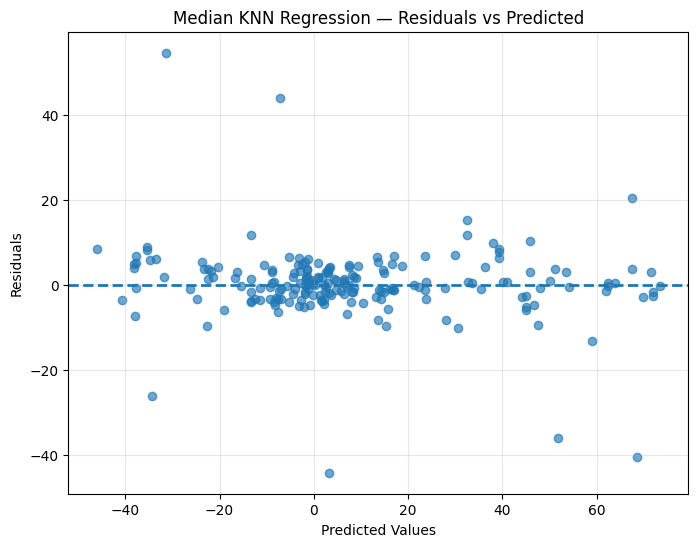

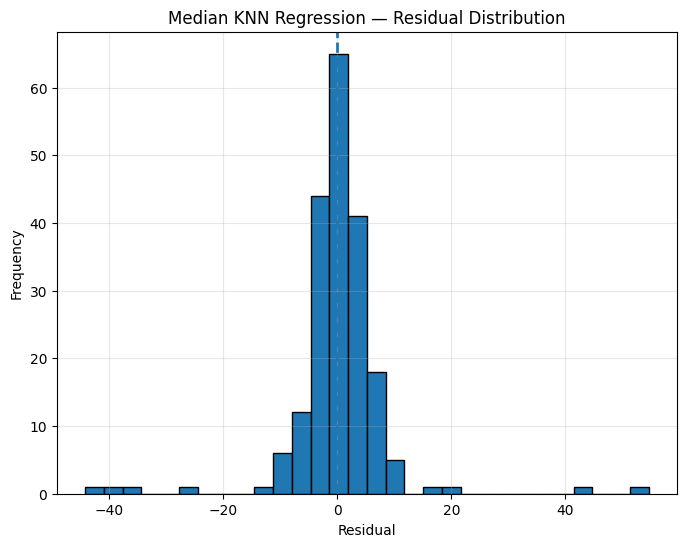

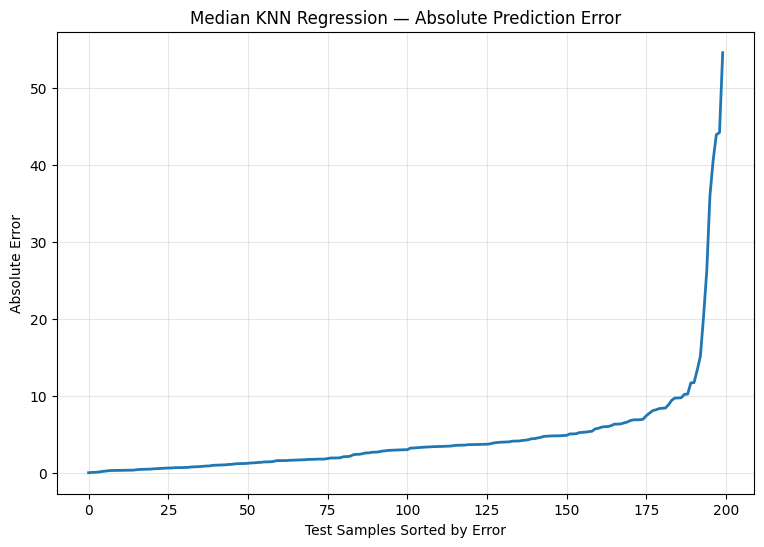



BEST K ANALYSIS
Best K according to MAE  : 4
Best K according to MSE  : 4
Best K according to RMSE : 4
Best K according to R²   : 4
Best K according to MAPE : 4


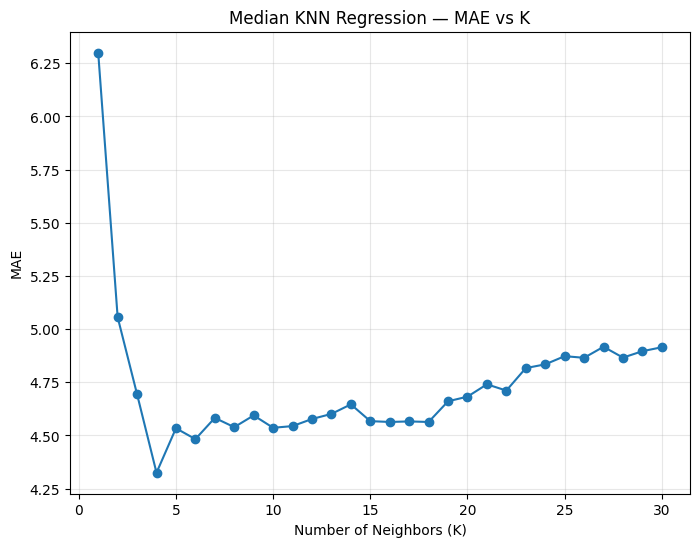

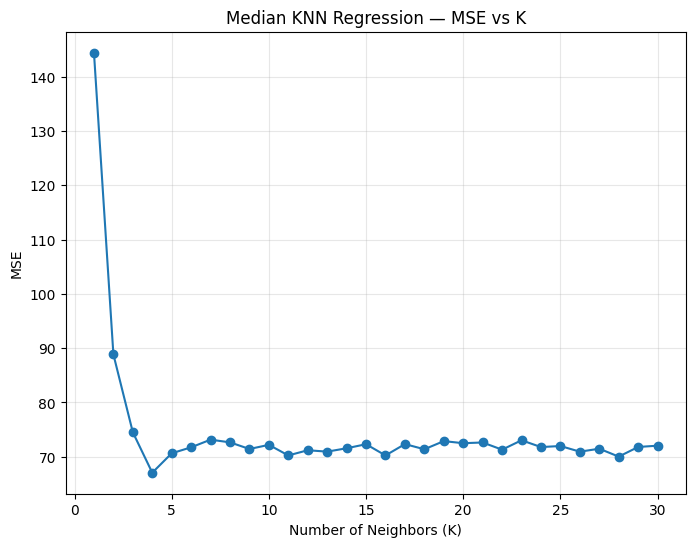

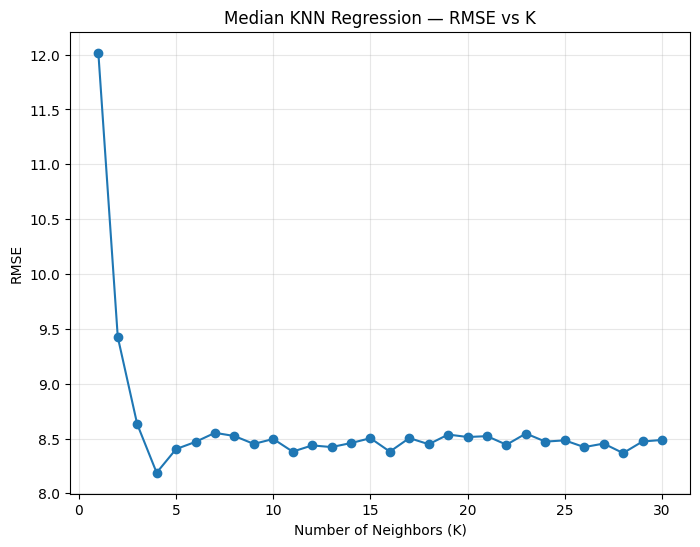

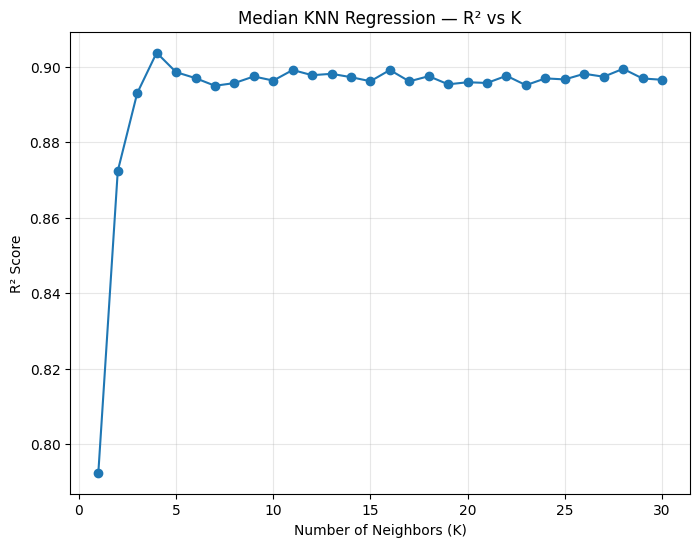

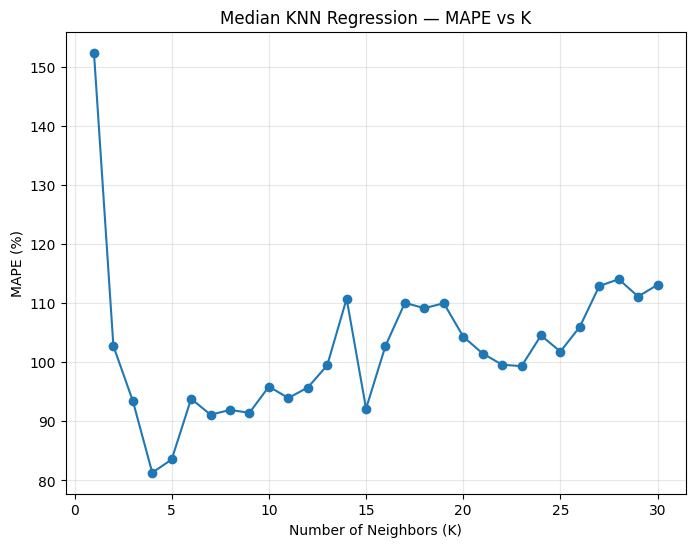

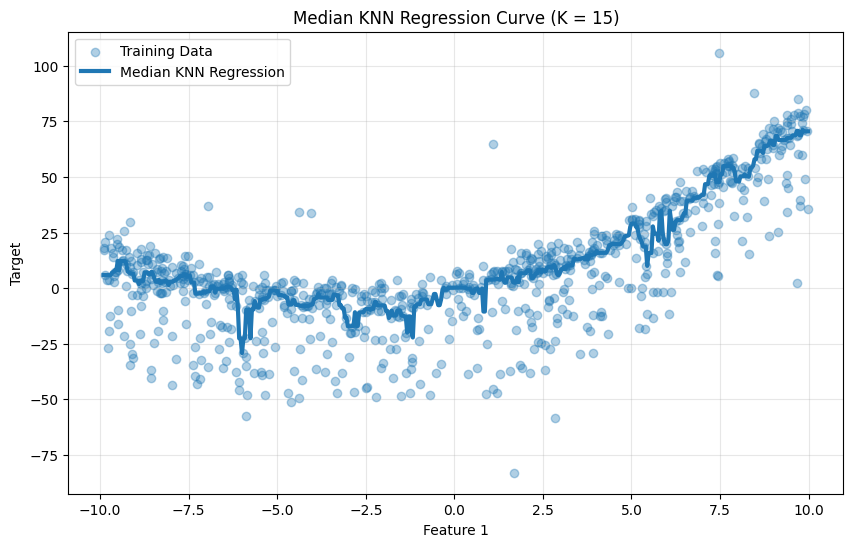



SAMPLE TEST PREDICTIONS
Sample  1 | Actual =    12.290 | Predicted =     7.540 | Error =     4.750
Sample  2 | Actual =    -6.016 | Predicted =    -5.724 | Error =    -0.292
Sample  3 | Actual =    -2.357 | Predicted =     2.061 | Error =    -4.418
Sample  4 | Actual =    23.809 | Predicted =    17.030 | Error =     6.779
Sample  5 | Actual =     6.305 | Predicted =     2.952 | Error =     3.354
Sample  6 | Actual =     2.307 | Predicted =    -2.496 | Error =     4.803
Sample  7 | Actual =    -6.245 | Predicted =    -2.688 | Error =    -3.557
Sample  8 | Actual =    42.310 | Predicted =    44.887 | Error =    -2.577
Sample  9 | Actual =    45.596 | Predicted =    39.264 | Error =     6.332
Sample 10 | Actual =     0.313 | Predicted =    -0.708 | Error =     1.021
Sample 11 | Actual =    56.451 | Predicted =    53.458 | Error =     2.993
Sample 12 | Actual =    -1.570 | Predicted =    -4.278 | Error =     2.707
Sample 13 | Actual =   -19.700 | Predicted =   -23.398 | Error =     3.698

In [6]:
# ============================================================
# MEDIAN KNN REGRESSION FROM SCRATCH
# ============================================================
# No Scikit-Learn
# Only NumPy + Matplotlib
#
# Prediction:
#       y_hat = median(y of K nearest neighbors)
#
# Evaluation:
#       MAE
#       MSE
#       RMSE
#       R²
#       MAPE
#
# Plots:
#       1. Actual vs Predicted
#       2. Residuals vs Predicted
#       3. Residual Distribution
#       4. Absolute Error
#       5. MAE vs K
#       6. MSE vs K
#       7. RMSE vs K
#       8. R² vs K
#       9. KNN Regression Curve
# ============================================================


import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

np.random.seed(42)


# ============================================================
# 2. GENERATE SYNTHETIC REGRESSION DATA
# ============================================================

n_samples = 1000

# Two input features
X = np.random.uniform(-10, 10, size=(n_samples, 2))

# Non-linear regression relationship
y = (
    3.0 * X[:, 0]
    + 2.0 * X[:, 1]
    + 0.5 * X[:, 0] ** 2
    - 0.3 * X[:, 1] ** 2
    + np.sin(X[:, 0])
    + np.random.normal(0, 3, n_samples)
)


print("=" * 65)
print("DATASET")
print("=" * 65)

print("X shape:", X.shape)
print("y shape:", y.shape)


# ============================================================
# 3. ADD SOME TARGET OUTLIERS
# ============================================================
# This makes Median KNN especially interesting because
# median is robust against extreme target values.
# ============================================================

n_outliers = 20

outlier_indices = np.random.choice(
    n_samples,
    size=n_outliers,
    replace=False
)

y[outlier_indices] += np.random.choice(
    [-1, 1],
    size=n_outliers
) * np.random.uniform(
    30,
    60,
    size=n_outliers
)


# ============================================================
# 4. TRAIN-TEST SPLIT FROM SCRATCH
# ============================================================

indices = np.random.permutation(
    n_samples
)

train_size = int(
    0.80 * n_samples
)

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]


print("\nTRAIN / TEST SPLIT")
print("-" * 65)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


# ============================================================
# 5. STANDARDIZATION FROM SCRATCH
# ============================================================
# IMPORTANT:
# Mean and standard deviation are calculated only from
# training data.
# ============================================================

X_mean = np.mean(
    X_train,
    axis=0
)

X_std = np.std(
    X_train,
    axis=0
)

# Avoid division by zero
X_std[X_std == 0] = 1.0


X_train_scaled = (
    X_train - X_mean
) / X_std


X_test_scaled = (
    X_test - X_mean
) / X_std


# ============================================================
# 6. MEDIAN KNN REGRESSOR
# ============================================================

class MedianKNNRegressor:

    def __init__(self, n_neighbors=5):

        self.n_neighbors = n_neighbors

        self.X_train = None
        self.y_train = None


    # ========================================================
    # FIT
    # ========================================================

    def fit(self, X, y):

        X = np.asarray(
            X,
            dtype=float
        )

        y = np.asarray(
            y,
            dtype=float
        )


        # Check X dimensions
        if X.ndim != 2:

            raise ValueError(
                "X must be a 2D array."
            )


        # Check y dimensions
        if y.ndim != 1:

            raise ValueError(
                "y must be a 1D array."
            )


        # Check number of samples
        if len(X) != len(y):

            raise ValueError(
                "X and y must contain "
                "the same number of samples."
            )


        # Check K
        if self.n_neighbors <= 0:

            raise ValueError(
                "n_neighbors must be greater than 0."
            )


        if self.n_neighbors > len(X):

            raise ValueError(
                "n_neighbors cannot be greater "
                "than number of training samples."
            )


        # Store training data
        self.X_train = X
        self.y_train = y


        return self


    # ========================================================
    # EUCLIDEAN DISTANCE
    # ========================================================

    def _euclidean_distance(self, X_query):

        distances = np.sqrt(
            np.sum(
                (self.X_train - X_query) ** 2,
                axis=1
            )
        )

        return distances


    # ========================================================
    # PREDICT
    # ========================================================

    def predict(self, X):

        X = np.asarray(
            X,
            dtype=float
        )


        predictions = []


        # Process every query point
        for x in X:

            # ------------------------------------------------
            # STEP 1:
            # Calculate distance to every training sample
            # ------------------------------------------------

            distances = self._euclidean_distance(
                x
            )


            # ------------------------------------------------
            # STEP 2:
            # Find K nearest neighbors
            # ------------------------------------------------

            nearest_indices = np.argsort(
                distances
            )[:self.n_neighbors]


            # ------------------------------------------------
            # STEP 3:
            # Obtain target values of neighbors
            # ------------------------------------------------

            nearest_y = self.y_train[
                nearest_indices
            ]


            # ------------------------------------------------
            # STEP 4:
            # MEDIAN PREDICTION
            # ------------------------------------------------

            prediction = np.median(
                nearest_y
            )


            predictions.append(
                prediction
            )


        return np.array(
            predictions
        )


# ============================================================
# 7. CREATE MODEL
# ============================================================

K = 7

model = MedianKNNRegressor(
    n_neighbors=K
)


# ============================================================
# 8. FIT MODEL
# ============================================================

model.fit(
    X_train_scaled,
    y_train
)


# ============================================================
# 9. PREDICTIONS
# ============================================================

y_train_pred = model.predict(
    X_train_scaled
)

y_test_pred = model.predict(
    X_test_scaled
)


# ============================================================
# 10. EVALUATION METRICS FROM SCRATCH
# ============================================================

def mean_absolute_error(y_true, y_pred):

    return np.mean(
        np.abs(
            y_true - y_pred
        )
    )


def mean_squared_error(y_true, y_pred):

    return np.mean(
        (y_true - y_pred) ** 2
    )


def root_mean_squared_error(y_true, y_pred):

    return np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )


def r2_score(y_true, y_pred):

    ss_res = np.sum(
        (y_true - y_pred) ** 2
    )

    ss_tot = np.sum(
        (y_true - np.mean(y_true)) ** 2
    )

    if ss_tot == 0:

        return 0.0

    return 1 - (
        ss_res / ss_tot
    )


def mean_absolute_percentage_error(
    y_true,
    y_pred
):

    # Avoid division by zero
    denominator = np.where(
        np.abs(y_true) < 1e-10,
        1e-10,
        np.abs(y_true)
    )

    return np.mean(
        np.abs(
            (y_true - y_pred)
            / denominator
        )
    ) * 100


# ============================================================
# 11. TRAINING METRICS
# ============================================================

train_mae = mean_absolute_error(
    y_train,
    y_train_pred
)

train_mse = mean_squared_error(
    y_train,
    y_train_pred
)

train_rmse = root_mean_squared_error(
    y_train,
    y_train_pred
)

train_r2 = r2_score(
    y_train,
    y_train_pred
)

train_mape = mean_absolute_percentage_error(
    y_train,
    y_train_pred
)


# ============================================================
# 12. TEST METRICS
# ============================================================

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

test_mse = mean_squared_error(
    y_test,
    y_test_pred
)

test_rmse = root_mean_squared_error(
    y_test,
    y_test_pred
)

test_r2 = r2_score(
    y_test,
    y_test_pred
)

test_mape = mean_absolute_percentage_error(
    y_test,
    y_test_pred
)


# ============================================================
# 13. PRINT EVALUATION RESULTS
# ============================================================

print("\n")
print("=" * 65)
print("MEDIAN KNN REGRESSION — EVALUATION")
print("=" * 65)

print("\nK =", K)

print("\nTRAINING PERFORMANCE")
print("-" * 45)

print(f"MAE  : {train_mae:.4f}")
print(f"MSE  : {train_mse:.4f}")
print(f"RMSE : {train_rmse:.4f}")
print(f"R²   : {train_r2:.4f}")
print(f"MAPE : {train_mape:.2f}%")


print("\nTEST PERFORMANCE")
print("-" * 45)

print(f"MAE  : {test_mae:.4f}")
print(f"MSE  : {test_mse:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"R²   : {test_r2:.4f}")
print(f"MAPE : {test_mape:.2f}%")


# ============================================================
# 14. RESIDUALS
# ============================================================

residuals = (
    y_test - y_test_pred
)

absolute_errors = np.abs(
    residuals
)


# ============================================================
# 15. PLOT 1 — ACTUAL VS PREDICTED
# ============================================================

plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.65
)


min_value = min(
    np.min(y_test),
    np.min(y_test_pred)
)

max_value = max(
    np.max(y_test),
    np.max(y_test_pred)
)


plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)


plt.xlabel(
    "Actual Values"
)

plt.ylabel(
    "Predicted Values"
)

plt.title(
    "Median KNN Regression — Actual vs Predicted"
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()


# ============================================================
# 16. PLOT 2 — RESIDUALS VS PREDICTED
# ============================================================

plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.65
)


plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)


plt.xlabel(
    "Predicted Values"
)

plt.ylabel(
    "Residuals"
)

plt.title(
    "Median KNN Regression — Residuals vs Predicted"
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()


# ============================================================
# 17. PLOT 3 — RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(8, 6)
)

plt.hist(
    residuals,
    bins=30,
    edgecolor="black"
)


plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)


plt.xlabel(
    "Residual"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Median KNN Regression — Residual Distribution"
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()


# ============================================================
# 18. PLOT 4 — ABSOLUTE PREDICTION ERROR
# ============================================================

sorted_errors = np.sort(
    absolute_errors
)


plt.figure(
    figsize=(9, 6)
)

plt.plot(
    sorted_errors,
    linewidth=2
)


plt.xlabel(
    "Test Samples Sorted by Error"
)

plt.ylabel(
    "Absolute Error"
)

plt.title(
    "Median KNN Regression — Absolute Prediction Error"
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()


# ============================================================
# 19. EVALUATE DIFFERENT K VALUES
# ============================================================

k_values = np.arange(
    1,
    31
)


mae_values = []
mse_values = []
rmse_values = []
r2_values = []
mape_values = []


for k in k_values:

    temp_model = MedianKNNRegressor(
        n_neighbors=k
    )


    temp_model.fit(
        X_train_scaled,
        y_train
    )


    temp_pred = temp_model.predict(
        X_test_scaled
    )


    # MAE
    mae_values.append(
        mean_absolute_error(
            y_test,
            temp_pred
        )
    )


    # MSE
    mse_values.append(
        mean_squared_error(
            y_test,
            temp_pred
        )
    )


    # RMSE
    rmse_values.append(
        root_mean_squared_error(
            y_test,
            temp_pred
        )
    )


    # R²
    r2_values.append(
        r2_score(
            y_test,
            temp_pred
        )
    )


    # MAPE
    mape_values.append(
        mean_absolute_percentage_error(
            y_test,
            temp_pred
        )
    )


mae_values = np.array(
    mae_values
)

mse_values = np.array(
    mse_values
)

rmse_values = np.array(
    rmse_values
)

r2_values = np.array(
    r2_values
)

mape_values = np.array(
    mape_values
)


# ============================================================
# 20. FIND BEST K
# ============================================================

best_k_mae = k_values[
    np.argmin(
        mae_values
    )
]


best_k_mse = k_values[
    np.argmin(
        mse_values
    )
]


best_k_rmse = k_values[
    np.argmin(
        rmse_values
    )
]


best_k_r2 = k_values[
    np.argmax(
        r2_values
    )
]


best_k_mape = k_values[
    np.argmin(
        mape_values
    )
]


# ============================================================
# 21. PRINT BEST K RESULTS
# ============================================================

print("\n")
print("=" * 65)
print("BEST K ANALYSIS")
print("=" * 65)

print(
    f"Best K according to MAE  : {best_k_mae}"
)

print(
    f"Best K according to MSE  : {best_k_mse}"
)

print(
    f"Best K according to RMSE : {best_k_rmse}"
)

print(
    f"Best K according to R²   : {best_k_r2}"
)

print(
    f"Best K according to MAPE : {best_k_mape}"
)


# ============================================================
# 22. PLOT 5 — MAE VS K
# ============================================================

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    k_values,
    mae_values,
    marker="o"
)

plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "MAE"
)

plt.title(
    "Median KNN Regression — MAE vs K"
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()


# ============================================================
# 23. PLOT 6 — MSE VS K
# ============================================================

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    k_values,
    mse_values,
    marker="o"
)

plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "MSE"
)

plt.title(
    "Median KNN Regression — MSE vs K"
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()


# ============================================================
# 24. PLOT 7 — RMSE VS K
# ============================================================

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    k_values,
    rmse_values,
    marker="o"
)

plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "RMSE"
)

plt.title(
    "Median KNN Regression — RMSE vs K"
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()


# ============================================================
# 25. PLOT 8 — R² VS K
# ============================================================

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    k_values,
    r2_values,
    marker="o"
)

plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "R² Score"
)

plt.title(
    "Median KNN Regression — R² vs K"
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()


# ============================================================
# 26. PLOT 9 — MAPE VS K
# ============================================================

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    k_values,
    mape_values,
    marker="o"
)

plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "MAPE (%)"
)

plt.title(
    "Median KNN Regression — MAPE vs K"
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()


# ============================================================
# 27. 1-D DATA FOR KNN REGRESSION CURVE
# ============================================================
# This visualization uses only Feature 1.
#
# The main model above uses BOTH features.
# ============================================================

X_1d = X[:, 0].reshape(
    -1,
    1
)


indices_1d = np.random.permutation(
    len(X_1d)
)


train_size_1d = int(
    0.80 * len(X_1d)
)


idx_train_1d = indices_1d[
    :train_size_1d
]

idx_test_1d = indices_1d[
    train_size_1d:
]


X_train_1d = X_1d[
    idx_train_1d
]

X_test_1d = X_1d[
    idx_test_1d
]

y_train_1d = y[
    idx_train_1d
]

y_test_1d = y[
    idx_test_1d
]


# ============================================================
# 28. SCALE 1-D FEATURE
# ============================================================

mean_1d = np.mean(
    X_train_1d,
    axis=0
)

std_1d = np.std(
    X_train_1d,
    axis=0
)

std_1d[
    std_1d == 0
] = 1.0


X_train_1d_scaled = (
    X_train_1d - mean_1d
) / std_1d


X_test_1d_scaled = (
    X_test_1d - mean_1d
) / std_1d


# ============================================================
# 29. TRAIN 1-D MEDIAN KNN
# ============================================================

curve_model = MedianKNNRegressor(
    n_neighbors=15
)


curve_model.fit(
    X_train_1d_scaled,
    y_train_1d
)


# ============================================================
# 30. CREATE PREDICTION GRID
# ============================================================

x_grid = np.linspace(
    np.min(X_train_1d),
    np.max(X_train_1d),
    500
).reshape(
    -1,
    1
)


x_grid_scaled = (
    x_grid - mean_1d
) / std_1d


y_grid_pred = curve_model.predict(
    x_grid_scaled
)


# ============================================================
# 31. PLOT 10 — MEDIAN KNN REGRESSION CURVE
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.scatter(
    X_train_1d,
    y_train_1d,
    alpha=0.35,
    label="Training Data"
)


plt.plot(
    x_grid,
    y_grid_pred,
    linewidth=3,
    label="Median KNN Regression"
)


plt.xlabel(
    "Feature 1"
)

plt.ylabel(
    "Target"
)

plt.title(
    "Median KNN Regression Curve (K = 15)"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.show()


# ============================================================
# 32. SAMPLE PREDICTIONS
# ============================================================

print("\n")
print("=" * 65)
print("SAMPLE TEST PREDICTIONS")
print("=" * 65)


for i in range(
    min(15, len(y_test))
):

    print(
        f"Sample {i + 1:2d} | "
        f"Actual = {y_test[i]:9.3f} | "
        f"Predicted = {y_test_pred[i]:9.3f} | "
        f"Error = {residuals[i]:9.3f}"
    )


# ============================================================
# 33. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 65)
print("FINAL MEDIAN KNN REGRESSION SUMMARY")
print("=" * 65)

print(
    f"K                  : {K}"
)

print(
    f"Training Samples   : {len(X_train)}"
)

print(
    f"Testing Samples    : {len(X_test)}"
)

print(
    f"Number of Features : {X_train.shape[1]}"
)


print("\nTEST METRICS")
print("-" * 45)

print(
    f"MAE                : {test_mae:.4f}"
)

print(
    f"MSE                : {test_mse:.4f}"
)

print(
    f"RMSE               : {test_rmse:.4f}"
)

print(
    f"R²                 : {test_r2:.4f}"
)

print(
    f"MAPE               : {test_mape:.2f}%"
)


print("\nBEST K VALUES")
print("-" * 45)

print(
    f"Best K by MAE      : {best_k_mae}"
)

print(
    f"Best K by MSE      : {best_k_mse}"
)

print(
    f"Best K by RMSE     : {best_k_rmse}"
)

print(
    f"Best K by R²       : {best_k_r2}"
)

print(
    f"Best K by MAPE     : {best_k_mape}"
)


print("\n")
print("=" * 65)
print("DONE")
print("=" * 65)

DATASET
X shape: (1000, 2)
y shape: (1000,)

TRAIN / TEST SPLIT
----------------------------------------------------------------------
Training samples: 800
Testing samples : 200


WEIGHTED KNN REGRESSION — EVALUATION

Model Parameters
--------------------------------------------------
K       : 7
Power   : 1
Weight  : 1 / distance^power

TRAINING PERFORMANCE
--------------------------------------------------
MAE  : 0.0000
MSE  : 0.0000
RMSE : 0.0000
R²   : 1.0000
MAPE : 0.00%

TEST PERFORMANCE
--------------------------------------------------
MAE  : 2.8218
MSE  : 12.5837
RMSE : 3.5473
R²   : 0.9847
MAPE : 112.22%


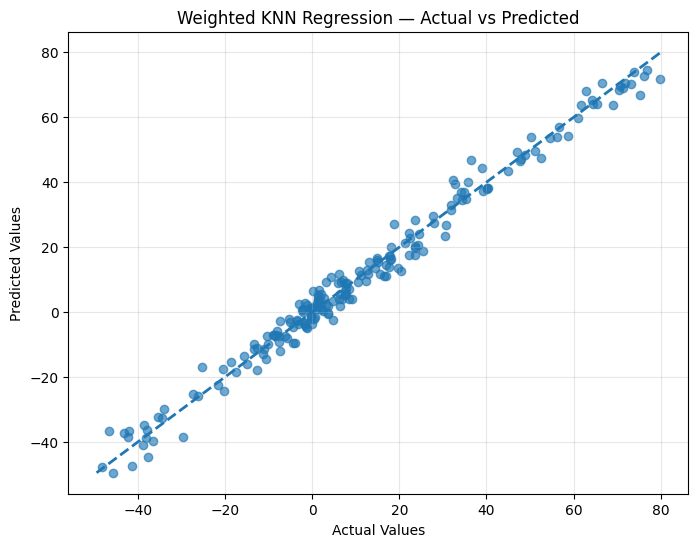

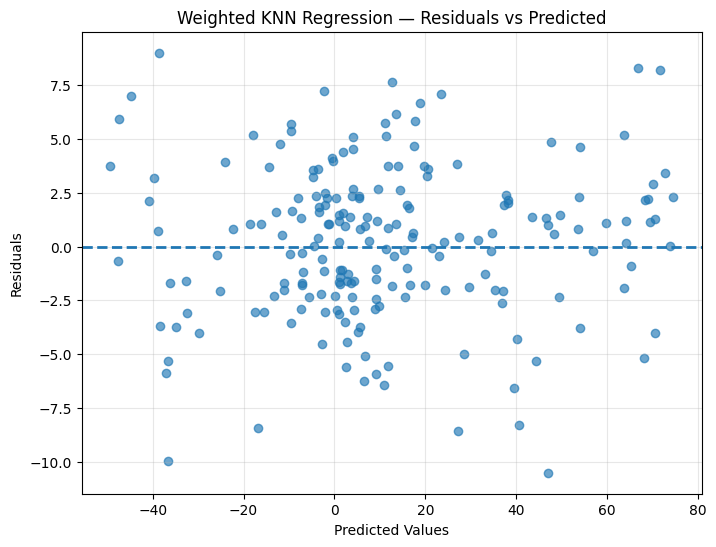

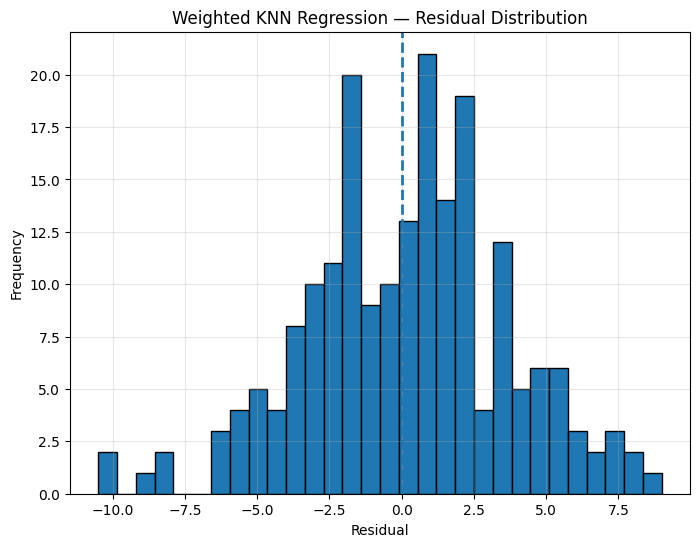

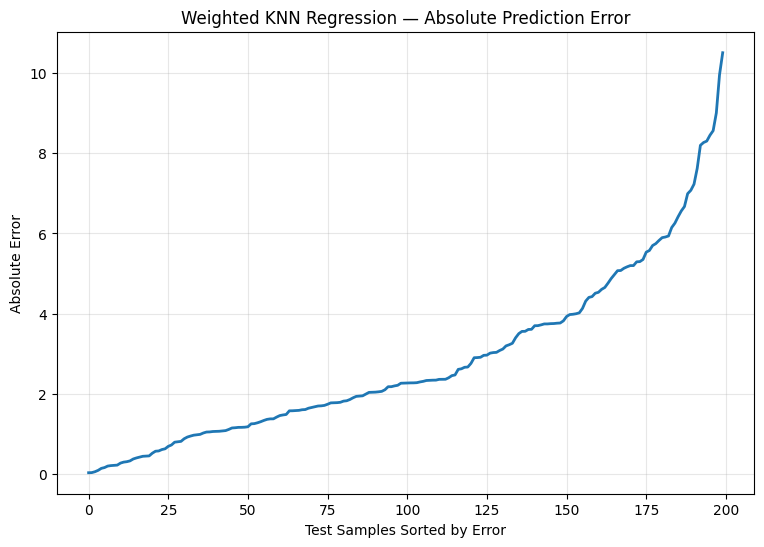



BEST K ANALYSIS
Best K according to MAE  : 8
Best K according to MSE  : 6
Best K according to RMSE : 6
Best K according to R²   : 6
Best K according to MAPE : 26


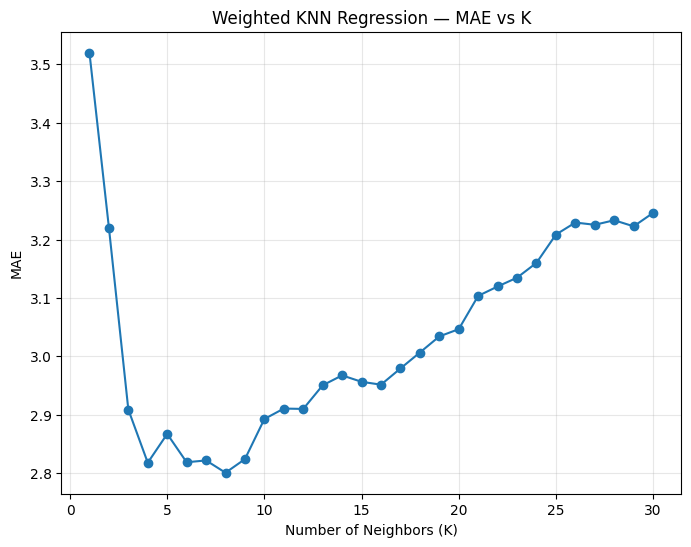

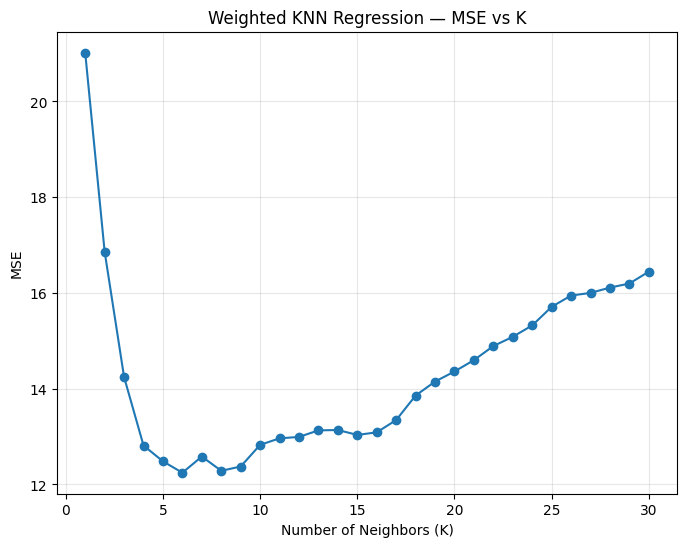

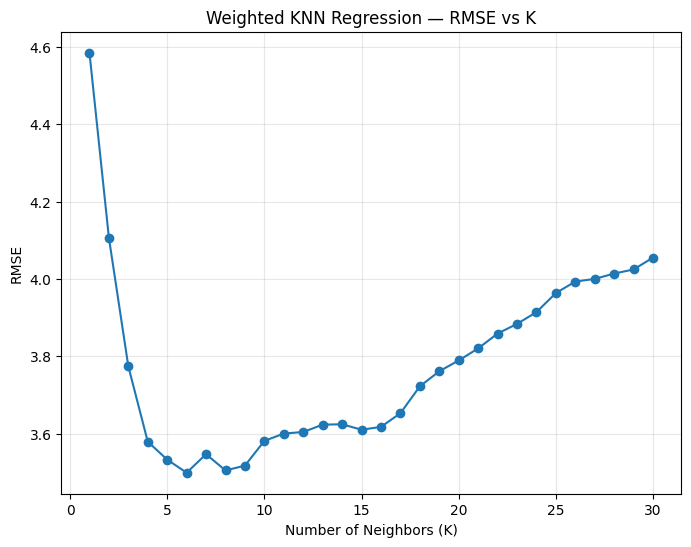

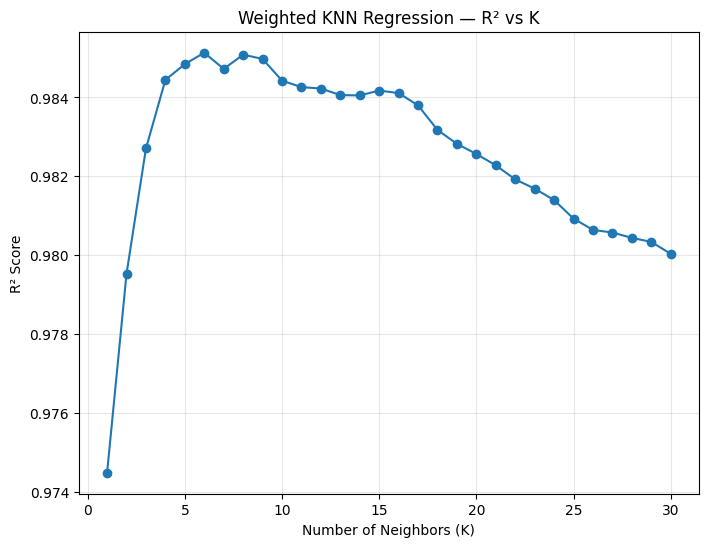

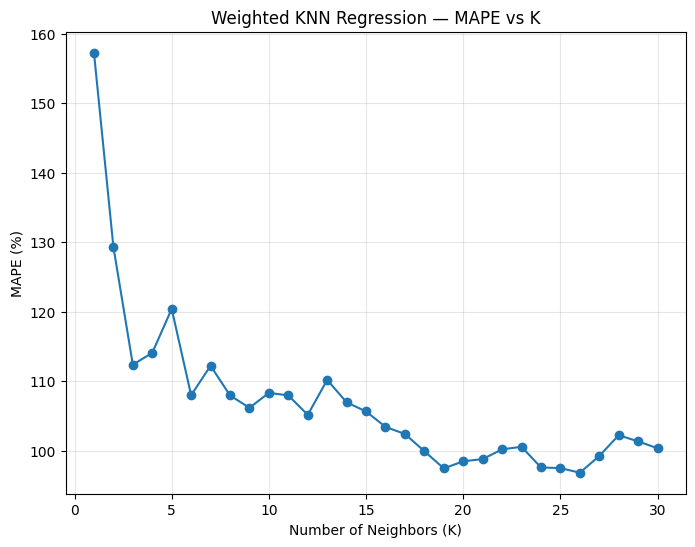

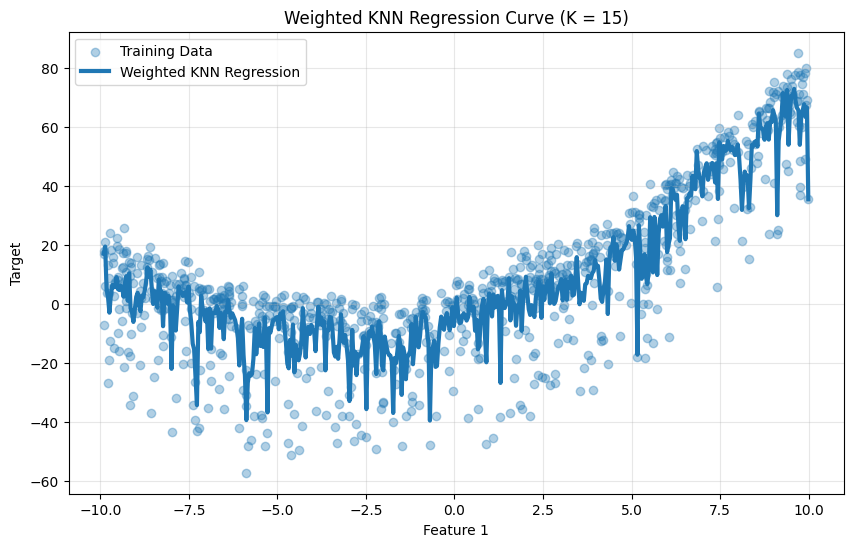



SAMPLE NEIGHBOR ANALYSIS
Test Sample Index : 0
Actual Target     : -7.6646

Nearest Neighbors
----------------------------------------------------------------------
Rank    Distance       Target         Weight         Normalized     
1       0.057434       -7.249793      17.411298      0.318443       
2       0.101523       -6.570964      9.850025       0.180151       
3       0.114731       -12.943793     8.716007       0.159411       
4       0.191989       -9.245291      5.208636       0.095263       
5       0.213763       -13.416973     4.678083       0.085559       
6       0.219277       -8.804262      4.560442       0.083408       
7       0.235189       -12.956611     4.251891       0.077765       

Weighted Prediction:
-9.326388

Model Prediction: -9.326388


SAMPLE TEST PREDICTIONS
Sample  1 | Actual =    -7.665 | Predicted =    -9.326 | Error =     1.662
Sample  2 | Actual =   -37.732 | Predicted =   -44.723 | Error =     6.990
Sample  3 | Actual =    14.880 | Predicted =

In [7]:
# ============================================================
# WEIGHTED KNN REGRESSION FROM SCRATCH
# ============================================================
# No Scikit-Learn
# No Pandas
#
# Libraries:
#   NumPy
#   Matplotlib
#
# Weighted KNN:
#
#       y_hat =
#       sum(weight_i * y_i)
#       -------------------
#          sum(weight_i)
#
# Inverse-distance weighting:
#
#       weight_i = 1 / (distance_i + epsilon)
#
# Evaluation:
#   MAE
#   MSE
#   RMSE
#   R²
#   MAPE
#
# Plots:
#   1. Actual vs Predicted
#   2. Residuals vs Predicted
#   3. Residual Distribution
#   4. Absolute Error
#   5. MAE vs K
#   6. MSE vs K
#   7. RMSE vs K
#   8. R² vs K
#   9. MAPE vs K
#  10. Weighted KNN Regression Curve
# ============================================================


import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

np.random.seed(42)


# ============================================================
# 2. GENERATE SYNTHETIC REGRESSION DATA
# ============================================================

n_samples = 1000

# Two input features
X = np.random.uniform(
    -10,
    10,
    size=(n_samples, 2)
)


# Non-linear target relationship
y = (
    3.0 * X[:, 0]
    + 2.0 * X[:, 1]
    + 0.5 * X[:, 0] ** 2
    - 0.3 * X[:, 1] ** 2
    + np.sin(X[:, 0])
    + np.random.normal(
        0,
        3,
        n_samples
    )
)


print("=" * 70)
print("DATASET")
print("=" * 70)

print("X shape:", X.shape)
print("y shape:", y.shape)


# ============================================================
# 3. TRAIN-TEST SPLIT FROM SCRATCH
# ============================================================

indices = np.random.permutation(
    n_samples
)

train_size = int(
    0.80 * n_samples
)

train_indices = indices[
    :train_size
]

test_indices = indices[
    train_size:
]


X_train = X[
    train_indices
]

X_test = X[
    test_indices
]


y_train = y[
    train_indices
]

y_test = y[
    test_indices
]


print("\nTRAIN / TEST SPLIT")
print("-" * 70)

print(
    "Training samples:",
    len(X_train)
)

print(
    "Testing samples :",
    len(X_test)
)


# ============================================================
# 4. STANDARDIZATION FROM SCRATCH
# ============================================================
# IMPORTANT:
# Statistics are calculated only from training data.
# ============================================================

X_mean = np.mean(
    X_train,
    axis=0
)

X_std = np.std(
    X_train,
    axis=0
)


# Prevent division by zero
X_std[
    X_std == 0
] = 1.0


X_train_scaled = (
    X_train - X_mean
) / X_std


X_test_scaled = (
    X_test - X_mean
) / X_std


# ============================================================
# 5. WEIGHTED KNN REGRESSOR
# ============================================================

class WeightedKNNRegressor:

    def __init__(
        self,
        n_neighbors=5,
        power=1,
        epsilon=1e-10
    ):

        self.n_neighbors = n_neighbors
        self.power = power
        self.epsilon = epsilon

        self.X_train = None
        self.y_train = None


    # ========================================================
    # FIT
    # ========================================================

    def fit(self, X, y):

        X = np.asarray(
            X,
            dtype=float
        )

        y = np.asarray(
            y,
            dtype=float
        )


        # ----------------------------------------------------
        # Check X
        # ----------------------------------------------------

        if X.ndim != 2:

            raise ValueError(
                "X must be a 2D array."
            )


        # ----------------------------------------------------
        # Check y
        # ----------------------------------------------------

        if y.ndim != 1:

            raise ValueError(
                "y must be a 1D array."
            )


        # ----------------------------------------------------
        # Check number of samples
        # ----------------------------------------------------

        if len(X) != len(y):

            raise ValueError(
                "X and y must contain "
                "the same number of samples."
            )


        # ----------------------------------------------------
        # Check K
        # ----------------------------------------------------

        if self.n_neighbors <= 0:

            raise ValueError(
                "n_neighbors must be greater than 0."
            )


        if self.n_neighbors > len(X):

            raise ValueError(
                "n_neighbors cannot be greater "
                "than number of training samples."
            )


        # ----------------------------------------------------
        # Check power
        # ----------------------------------------------------

        if self.power <= 0:

            raise ValueError(
                "power must be greater than 0."
            )


        # ----------------------------------------------------
        # Store training data
        # ----------------------------------------------------

        self.X_train = X
        self.y_train = y


        return self


    # ========================================================
    # EUCLIDEAN DISTANCE
    # ========================================================

    def _euclidean_distance(
        self,
        X_query
    ):

        distances = np.sqrt(
            np.sum(
                (
                    self.X_train
                    - X_query
                ) ** 2,
                axis=1
            )
        )

        return distances


    # ========================================================
    # PREDICT
    # ========================================================

    def predict(self, X):

        X = np.asarray(
            X,
            dtype=float
        )


        predictions = []


        # ----------------------------------------------------
        # Predict each query sample
        # ----------------------------------------------------

        for x in X:

            # =================================================
            # STEP 1:
            # Calculate distance to every training sample
            # =================================================

            distances = self._euclidean_distance(
                x
            )


            # =================================================
            # STEP 2:
            # Find K nearest neighbors
            # =================================================

            nearest_indices = np.argsort(
                distances
            )[
                :self.n_neighbors
            ]


            # =================================================
            # STEP 3:
            # Obtain nearest distances
            # =================================================

            nearest_distances = distances[
                nearest_indices
            ]


            # =================================================
            # STEP 4:
            # Obtain target values
            # =================================================

            nearest_y = self.y_train[
                nearest_indices
            ]


            # =================================================
            # STEP 5:
            # Calculate inverse-distance weights
            #
            # weight = 1 / distance^power
            # =================================================

            weights = 1.0 / (
                nearest_distances ** self.power
                + self.epsilon
            )


            # =================================================
            # STEP 6:
            # Weighted average
            # =================================================

            prediction = np.sum(
                weights * nearest_y
            ) / np.sum(
                weights
            )


            predictions.append(
                prediction
            )


        return np.array(
            predictions
        )


    # ========================================================
    # GET NEIGHBOR INFORMATION
    # ========================================================

    def get_neighbors(self, X_query):

        X_query = np.asarray(
            X_query,
            dtype=float
        )


        distances = self._euclidean_distance(
            X_query
        )


        nearest_indices = np.argsort(
            distances
        )[
            :self.n_neighbors
        ]


        nearest_distances = distances[
            nearest_indices
        ]


        nearest_y = self.y_train[
            nearest_indices
        ]


        weights = 1.0 / (
            nearest_distances ** self.power
            + self.epsilon
        )


        return (
            nearest_indices,
            nearest_distances,
            nearest_y,
            weights
        )


# ============================================================
# 6. CREATE MODEL
# ============================================================

K = 7

model = WeightedKNNRegressor(
    n_neighbors=K,
    power=1
)


# ============================================================
# 7. TRAIN MODEL
# ============================================================

model.fit(
    X_train_scaled,
    y_train
)


# ============================================================
# 8. MAKE PREDICTIONS
# ============================================================

y_train_pred = model.predict(
    X_train_scaled
)

y_test_pred = model.predict(
    X_test_scaled
)


# ============================================================
# 9. EVALUATION METRICS FROM SCRATCH
# ============================================================

def mean_absolute_error(
    y_true,
    y_pred
):

    return np.mean(
        np.abs(
            y_true - y_pred
        )
    )


def mean_squared_error(
    y_true,
    y_pred
):

    return np.mean(
        (
            y_true - y_pred
        ) ** 2
    )


def root_mean_squared_error(
    y_true,
    y_pred
):

    return np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )


def r2_score(
    y_true,
    y_pred
):

    ss_res = np.sum(
        (
            y_true - y_pred
        ) ** 2
    )


    ss_tot = np.sum(
        (
            y_true - np.mean(y_true)
        ) ** 2
    )


    if ss_tot == 0:

        return 0.0


    return 1 - (
        ss_res / ss_tot
    )


def mean_absolute_percentage_error(
    y_true,
    y_pred
):

    # Avoid division by zero
    denominator = np.where(
        np.abs(y_true) < 1e-10,
        1e-10,
        np.abs(y_true)
    )


    return np.mean(
        np.abs(
            (
                y_true - y_pred
            )
            / denominator
        )
    ) * 100


# ============================================================
# 10. TRAINING METRICS
# ============================================================

train_mae = mean_absolute_error(
    y_train,
    y_train_pred
)

train_mse = mean_squared_error(
    y_train,
    y_train_pred
)

train_rmse = root_mean_squared_error(
    y_train,
    y_train_pred
)

train_r2 = r2_score(
    y_train,
    y_train_pred
)

train_mape = mean_absolute_percentage_error(
    y_train,
    y_train_pred
)


# ============================================================
# 11. TEST METRICS
# ============================================================

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

test_mse = mean_squared_error(
    y_test,
    y_test_pred
)

test_rmse = root_mean_squared_error(
    y_test,
    y_test_pred
)

test_r2 = r2_score(
    y_test,
    y_test_pred
)

test_mape = mean_absolute_percentage_error(
    y_test,
    y_test_pred
)


# ============================================================
# 12. PRINT EVALUATION RESULTS
# ============================================================

print("\n")
print("=" * 70)
print("WEIGHTED KNN REGRESSION — EVALUATION")
print("=" * 70)

print("\nModel Parameters")
print("-" * 50)

print(
    "K       :",
    K
)

print(
    "Power   :",
    model.power
)

print(
    "Weight  : 1 / distance^power"
)


print("\nTRAINING PERFORMANCE")
print("-" * 50)

print(
    f"MAE  : {train_mae:.4f}"
)

print(
    f"MSE  : {train_mse:.4f}"
)

print(
    f"RMSE : {train_rmse:.4f}"
)

print(
    f"R²   : {train_r2:.4f}"
)

print(
    f"MAPE : {train_mape:.2f}%"
)


print("\nTEST PERFORMANCE")
print("-" * 50)

print(
    f"MAE  : {test_mae:.4f}"
)

print(
    f"MSE  : {test_mse:.4f}"
)

print(
    f"RMSE : {test_rmse:.4f}"
)

print(
    f"R²   : {test_r2:.4f}"
)

print(
    f"MAPE : {test_mape:.2f}%"
)


# ============================================================
# 13. RESIDUALS
# ============================================================

residuals = (
    y_test - y_test_pred
)


absolute_errors = np.abs(
    residuals
)


# ============================================================
# 14. PLOT 1 — ACTUAL VS PREDICTED
# ============================================================

plt.figure(
    figsize=(8, 6)
)


plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.65
)


min_value = min(
    np.min(y_test),
    np.min(y_test_pred)
)


max_value = max(
    np.max(y_test),
    np.max(y_test_pred)
)


plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)


plt.xlabel(
    "Actual Values"
)

plt.ylabel(
    "Predicted Values"
)

plt.title(
    "Weighted KNN Regression — Actual vs Predicted"
)


plt.grid(
    True,
    alpha=0.3
)


plt.show()


# ============================================================
# 15. PLOT 2 — RESIDUALS VS PREDICTED
# ============================================================

plt.figure(
    figsize=(8, 6)
)


plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.65
)


plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)


plt.xlabel(
    "Predicted Values"
)

plt.ylabel(
    "Residuals"
)

plt.title(
    "Weighted KNN Regression — Residuals vs Predicted"
)


plt.grid(
    True,
    alpha=0.3
)


plt.show()


# ============================================================
# 16. PLOT 3 — RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(8, 6)
)


plt.hist(
    residuals,
    bins=30,
    edgecolor="black"
)


plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)


plt.xlabel(
    "Residual"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Weighted KNN Regression — Residual Distribution"
)


plt.grid(
    True,
    alpha=0.3
)


plt.show()


# ============================================================
# 17. PLOT 4 — ABSOLUTE PREDICTION ERROR
# ============================================================

sorted_errors = np.sort(
    absolute_errors
)


plt.figure(
    figsize=(9, 6)
)


plt.plot(
    sorted_errors,
    linewidth=2
)


plt.xlabel(
    "Test Samples Sorted by Error"
)

plt.ylabel(
    "Absolute Error"
)

plt.title(
    "Weighted KNN Regression — Absolute Prediction Error"
)


plt.grid(
    True,
    alpha=0.3
)


plt.show()


# ============================================================
# 18. TEST DIFFERENT K VALUES
# ============================================================

k_values = np.arange(
    1,
    31
)


mae_values = []
mse_values = []
rmse_values = []
r2_values = []
mape_values = []


for k in k_values:

    temp_model = WeightedKNNRegressor(
        n_neighbors=k,
        power=1
    )


    temp_model.fit(
        X_train_scaled,
        y_train
    )


    temp_pred = temp_model.predict(
        X_test_scaled
    )


    # --------------------------------------------------------
    # MAE
    # --------------------------------------------------------

    mae_values.append(
        mean_absolute_error(
            y_test,
            temp_pred
        )
    )


    # --------------------------------------------------------
    # MSE
    # --------------------------------------------------------

    mse_values.append(
        mean_squared_error(
            y_test,
            temp_pred
        )
    )


    # --------------------------------------------------------
    # RMSE
    # --------------------------------------------------------

    rmse_values.append(
        root_mean_squared_error(
            y_test,
            temp_pred
        )
    )


    # --------------------------------------------------------
    # R²
    # --------------------------------------------------------

    r2_values.append(
        r2_score(
            y_test,
            temp_pred
        )
    )


    # --------------------------------------------------------
    # MAPE
    # --------------------------------------------------------

    mape_values.append(
        mean_absolute_percentage_error(
            y_test,
            temp_pred
        )
    )


mae_values = np.array(
    mae_values
)

mse_values = np.array(
    mse_values
)

rmse_values = np.array(
    rmse_values
)

r2_values = np.array(
    r2_values
)

mape_values = np.array(
    mape_values
)


# ============================================================
# 19. FIND BEST K
# ============================================================

best_k_mae = k_values[
    np.argmin(
        mae_values
    )
]


best_k_mse = k_values[
    np.argmin(
        mse_values
    )
]


best_k_rmse = k_values[
    np.argmin(
        rmse_values
    )
]


best_k_r2 = k_values[
    np.argmax(
        r2_values
    )
]


best_k_mape = k_values[
    np.argmin(
        mape_values
    )
]


# ============================================================
# 20. PRINT BEST K
# ============================================================

print("\n")
print("=" * 70)
print("BEST K ANALYSIS")
print("=" * 70)


print(
    f"Best K according to MAE  : {best_k_mae}"
)

print(
    f"Best K according to MSE  : {best_k_mse}"
)

print(
    f"Best K according to RMSE : {best_k_rmse}"
)

print(
    f"Best K according to R²   : {best_k_r2}"
)

print(
    f"Best K according to MAPE : {best_k_mape}"
)


# ============================================================
# 21. PLOT 5 — MAE VS K
# ============================================================

plt.figure(
    figsize=(8, 6)
)


plt.plot(
    k_values,
    mae_values,
    marker="o"
)


plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "MAE"
)

plt.title(
    "Weighted KNN Regression — MAE vs K"
)


plt.grid(
    True,
    alpha=0.3
)


plt.show()


# ============================================================
# 22. PLOT 6 — MSE VS K
# ============================================================

plt.figure(
    figsize=(8, 6)
)


plt.plot(
    k_values,
    mse_values,
    marker="o"
)


plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "MSE"
)

plt.title(
    "Weighted KNN Regression — MSE vs K"
)


plt.grid(
    True,
    alpha=0.3
)


plt.show()


# ============================================================
# 23. PLOT 7 — RMSE VS K
# ============================================================

plt.figure(
    figsize=(8, 6)
)


plt.plot(
    k_values,
    rmse_values,
    marker="o"
)


plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "RMSE"
)

plt.title(
    "Weighted KNN Regression — RMSE vs K"
)


plt.grid(
    True,
    alpha=0.3
)


plt.show()


# ============================================================
# 24. PLOT 8 — R² VS K
# ============================================================

plt.figure(
    figsize=(8, 6)
)


plt.plot(
    k_values,
    r2_values,
    marker="o"
)


plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "R² Score"
)

plt.title(
    "Weighted KNN Regression — R² vs K"
)


plt.grid(
    True,
    alpha=0.3
)


plt.show()


# ============================================================
# 25. PLOT 9 — MAPE VS K
# ============================================================

plt.figure(
    figsize=(8, 6)
)


plt.plot(
    k_values,
    mape_values,
    marker="o"
)


plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "MAPE (%)"
)

plt.title(
    "Weighted KNN Regression — MAPE vs K"
)


plt.grid(
    True,
    alpha=0.3
)


plt.show()


# ============================================================
# 26. CREATE 1-D DATA FOR REGRESSION CURVE
# ============================================================
# This visualization uses Feature 1 only.
#
# The main model above uses both features.
# ============================================================

X_1d = X[
    :,
    0
].reshape(
    -1,
    1
)


indices_1d = np.random.permutation(
    len(X_1d)
)


train_size_1d = int(
    0.80 * len(X_1d)
)


idx_train_1d = indices_1d[
    :train_size_1d
]

idx_test_1d = indices_1d[
    train_size_1d:
]


X_train_1d = X_1d[
    idx_train_1d
]

X_test_1d = X_1d[
    idx_test_1d
]


y_train_1d = y[
    idx_train_1d
]

y_test_1d = y[
    idx_test_1d
]


# ============================================================
# 27. SCALE 1-D FEATURE
# ============================================================

mean_1d = np.mean(
    X_train_1d,
    axis=0
)


std_1d = np.std(
    X_train_1d,
    axis=0
)


std_1d[
    std_1d == 0
] = 1.0


X_train_1d_scaled = (
    X_train_1d - mean_1d
) / std_1d


X_test_1d_scaled = (
    X_test_1d - mean_1d
) / std_1d


# ============================================================
# 28. TRAIN 1-D WEIGHTED KNN
# ============================================================

curve_model = WeightedKNNRegressor(
    n_neighbors=15,
    power=1
)


curve_model.fit(
    X_train_1d_scaled,
    y_train_1d
)


# ============================================================
# 29. CREATE PREDICTION GRID
# ============================================================

x_grid = np.linspace(
    np.min(X_train_1d),
    np.max(X_train_1d),
    500
).reshape(
    -1,
    1
)


x_grid_scaled = (
    x_grid - mean_1d
) / std_1d


y_grid_pred = curve_model.predict(
    x_grid_scaled
)


# ============================================================
# 30. PLOT 10 — WEIGHTED KNN REGRESSION CURVE
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.scatter(
    X_train_1d,
    y_train_1d,
    alpha=0.35,
    label="Training Data"
)


plt.plot(
    x_grid,
    y_grid_pred,
    linewidth=3,
    label="Weighted KNN Regression"
)


plt.xlabel(
    "Feature 1"
)

plt.ylabel(
    "Target"
)

plt.title(
    "Weighted KNN Regression Curve (K = 15)"
)


plt.legend()

plt.grid(
    True,
    alpha=0.3
)


plt.show()


# ============================================================
# 31. DISPLAY ONE SAMPLE'S NEIGHBORS AND WEIGHTS
# ============================================================

sample_index = 0

(
    neighbor_indices,
    neighbor_distances,
    neighbor_y,
    neighbor_weights
) = model.get_neighbors(
    X_test_scaled[sample_index]
)


# Normalize weights for display
normalized_weights = (
    neighbor_weights
    / np.sum(neighbor_weights)
)


print("\n")
print("=" * 70)
print("SAMPLE NEIGHBOR ANALYSIS")
print("=" * 70)


print(
    f"Test Sample Index : {sample_index}"
)


print(
    f"Actual Target     : "
    f"{y_test[sample_index]:.4f}"
)


print("\nNearest Neighbors")
print("-" * 70)


print(
    f"{'Rank':<8}"
    f"{'Distance':<15}"
    f"{'Target':<15}"
    f"{'Weight':<15}"
    f"{'Normalized':<15}"
)


for i in range(
    len(neighbor_indices)
):

    print(
        f"{i + 1:<8}"
        f"{neighbor_distances[i]:<15.6f}"
        f"{neighbor_y[i]:<15.6f}"
        f"{neighbor_weights[i]:<15.6f}"
        f"{normalized_weights[i]:<15.6f}"
    )


print("\nWeighted Prediction:")

weighted_prediction = (
    np.sum(
        normalized_weights
        * neighbor_y
    )
)


print(
    f"{weighted_prediction:.6f}"
)


print(
    f"\nModel Prediction:"
    f" {y_test_pred[sample_index]:.6f}"
)


# ============================================================
# 32. SAMPLE TEST PREDICTIONS
# ============================================================

print("\n")
print("=" * 70)
print("SAMPLE TEST PREDICTIONS")
print("=" * 70)


for i in range(
    min(15, len(y_test))
):

    print(
        f"Sample {i + 1:2d} | "
        f"Actual = {y_test[i]:9.3f} | "
        f"Predicted = {y_test_pred[i]:9.3f} | "
        f"Error = {residuals[i]:9.3f}"
    )


# ============================================================
# 33. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("FINAL WEIGHTED KNN REGRESSION SUMMARY")
print("=" * 70)


print(
    f"K                  : {K}"
)

print(
    f"Weight Power       : {model.power}"
)

print(
    f"Training Samples   : {len(X_train)}"
)

print(
    f"Testing Samples    : {len(X_test)}"
)

print(
    f"Number of Features : "
    f"{X_train.shape[1]}"
)


print("\nTEST METRICS")
print("-" * 50)


print(
    f"MAE                : "
    f"{test_mae:.4f}"
)

print(
    f"MSE                : "
    f"{test_mse:.4f}"
)

print(
    f"RMSE               : "
    f"{test_rmse:.4f}"
)

print(
    f"R²                 : "
    f"{test_r2:.4f}"
)

print(
    f"MAPE               : "
    f"{test_mape:.2f}%"
)


print("\nBEST K VALUES")
print("-" * 50)


print(
    f"Best K by MAE      : "
    f"{best_k_mae}"
)

print(
    f"Best K by MSE      : "
    f"{best_k_mse}"
)

print(
    f"Best K by RMSE     : "
    f"{best_k_rmse}"
)

print(
    f"Best K by R²       : "
    f"{best_k_r2}"
)

print(
    f"Best K by MAPE     : "
    f"{best_k_mape}"
)


print("\n")
print("=" * 70)
print("DONE")
print("=" * 70)

KERNEL KNN REGRESSION - EVALUATION

Model Parameters
-----------------------------------------------------------------
Kernel       : gaussian
K Neighbors  : 10
Bandwidth    : 1.0

Training Performance
-----------------------------------------------------------------
MAE          : 0.480169
MSE          : 0.374423
RMSE         : 0.611901
R²           : 0.984448
MAPE         : 77.64%

Testing Performance
-----------------------------------------------------------------
MAE          : 0.569373
MSE          : 0.523435
RMSE         : 0.723488
R²           : 0.980849
MAPE         : 104.36%


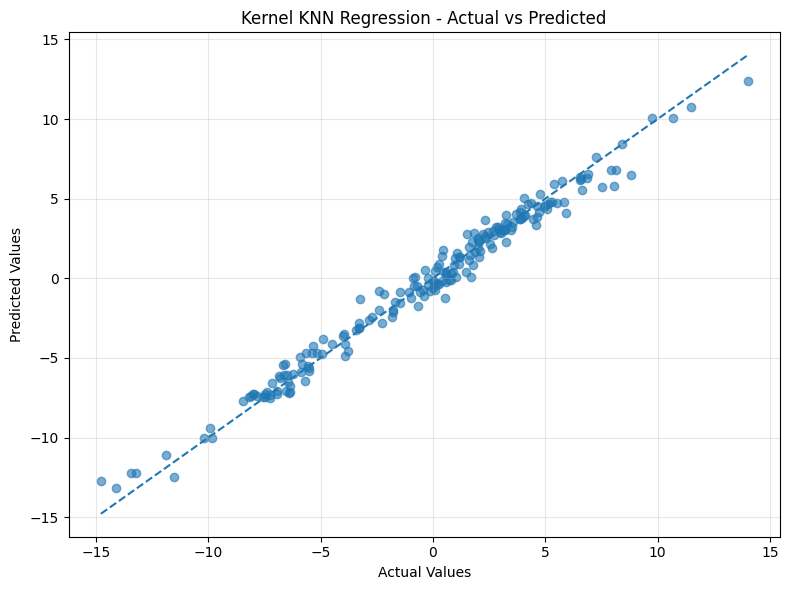

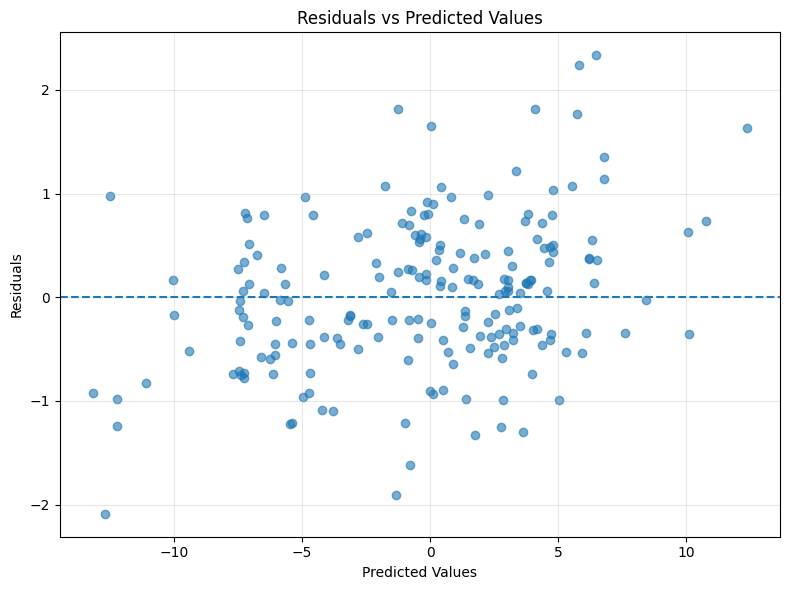

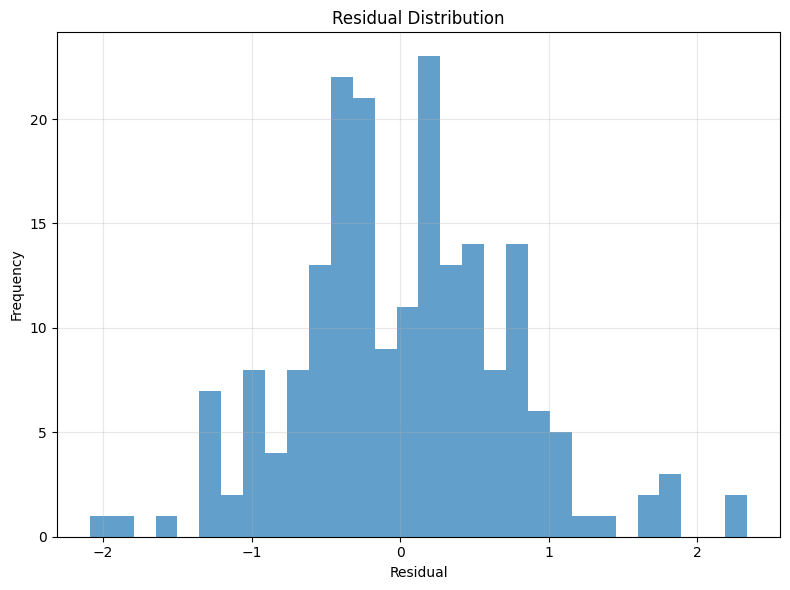

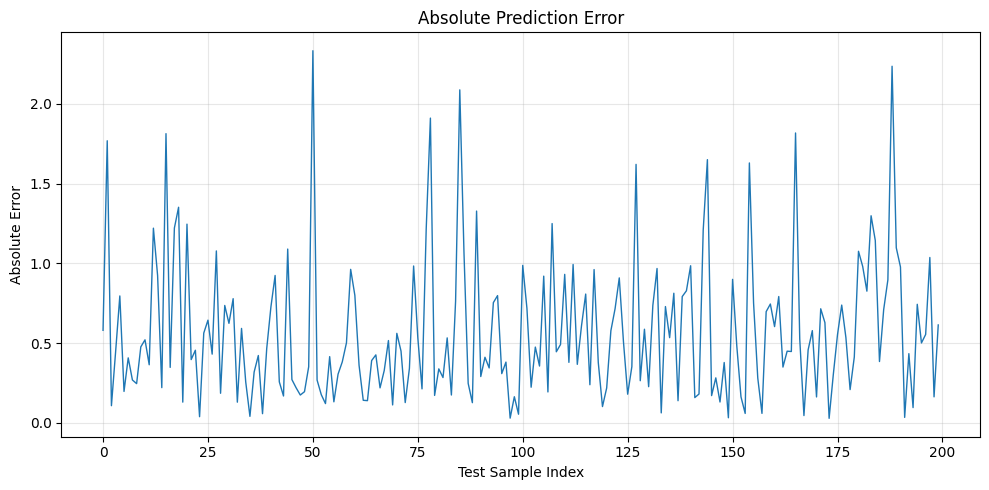

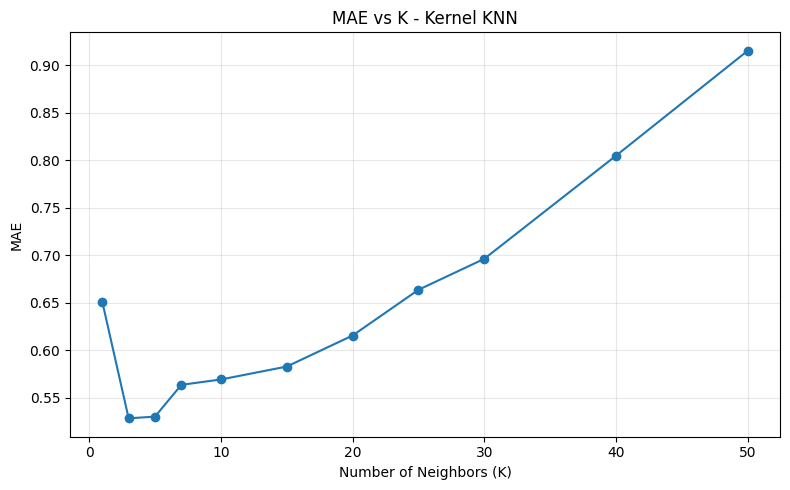

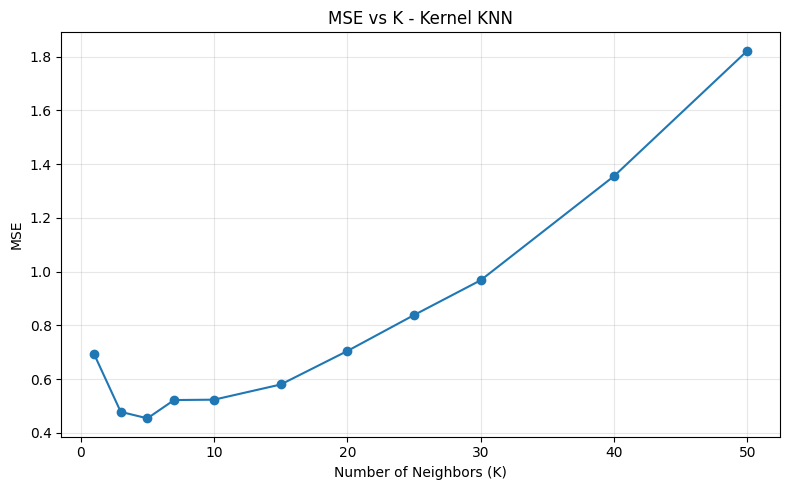

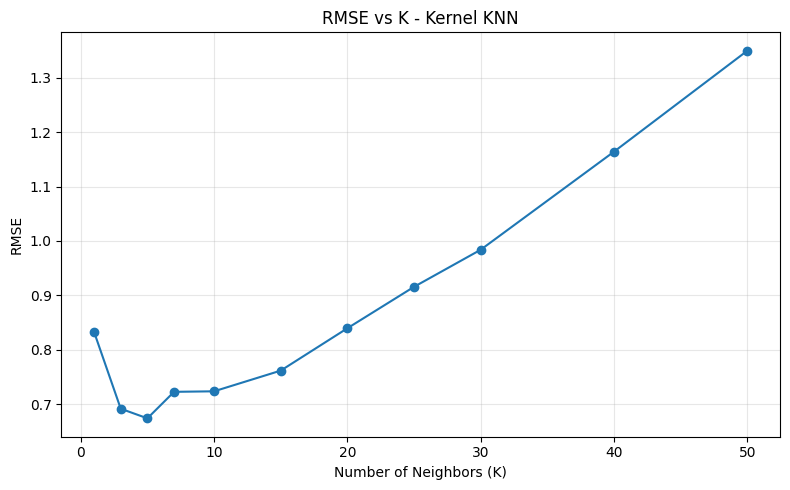

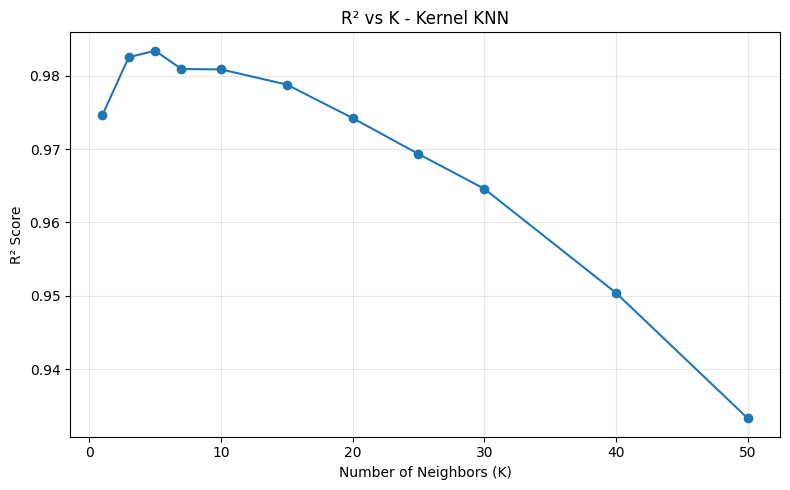

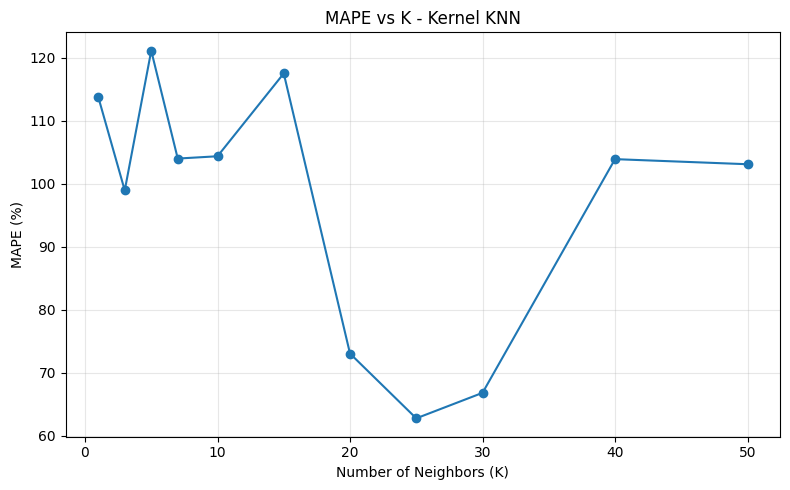


BEST K ANALYSIS
Best K based on MAE  : 3
Best K based on MSE  : 5
Best K based on RMSE : 5
Best K based on R²   : 5
Best K based on MAPE : 25

KERNEL COMPARISON
Kernel            MAE         MSE         RMSE        R²          MAPE        
-------------------------------------------------------------------------------------
gaussian          0.569373    0.523435    0.723488    0.980849    104.36      %
epanechnikov      0.567703    0.519737    0.720928    0.980985    104.14      %
uniform           0.570892    0.526786    0.725800    0.980727    104.57      %
triangular        0.560297    0.504749    0.710457    0.981533    103.29      %
quartic           0.564477    0.512793    0.716096    0.981239    103.72      %


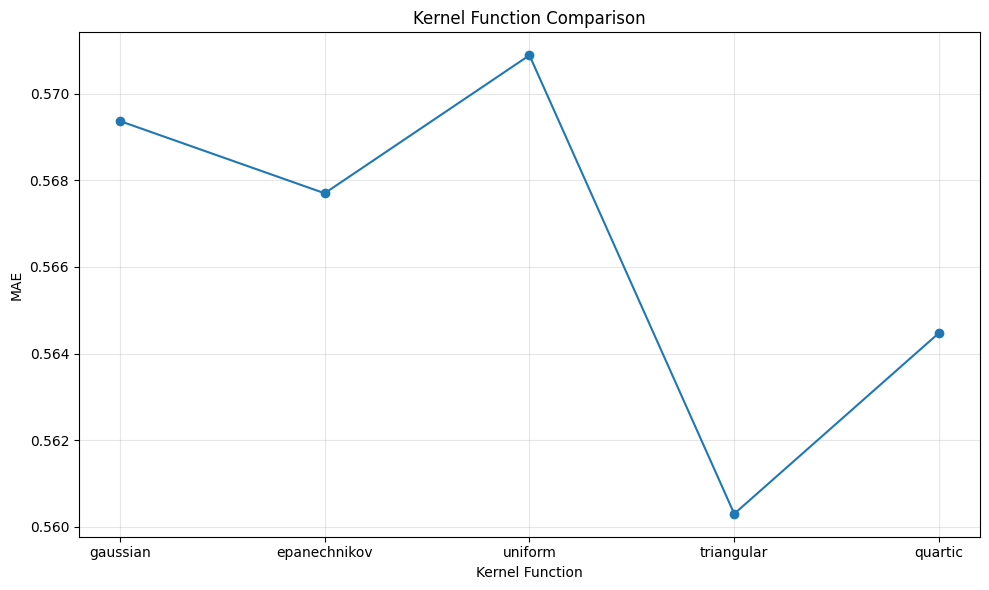

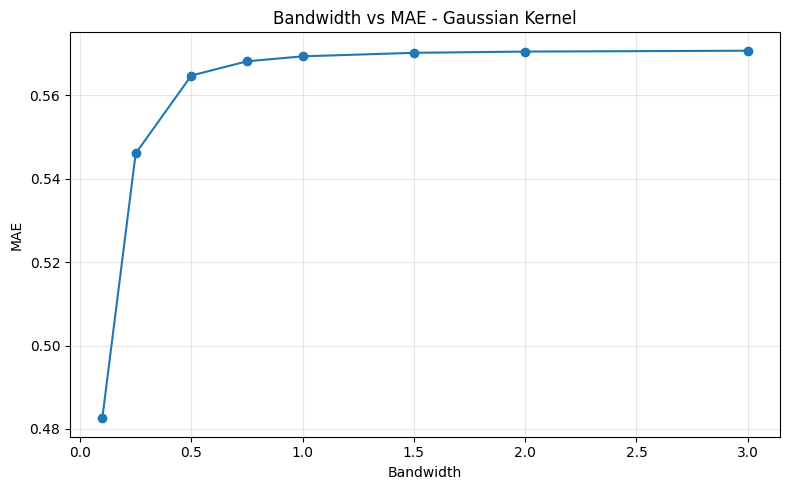

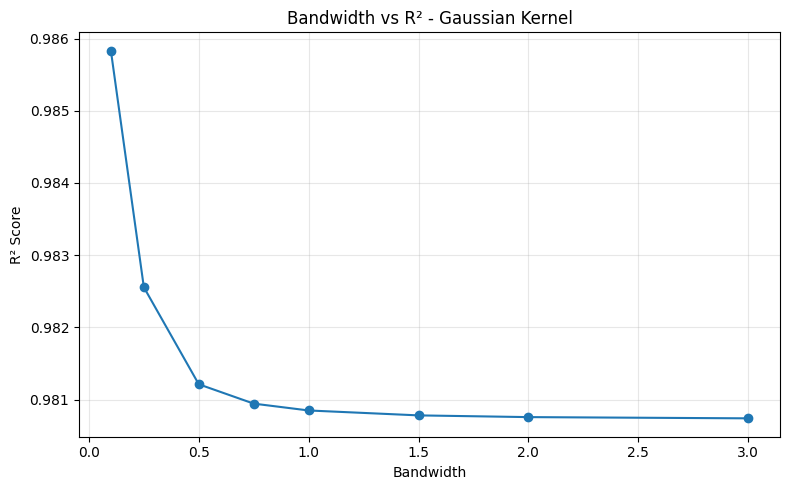


BEST BANDWIDTH
Best bandwidth based on MAE : 0.1
Best bandwidth based on R²  : 0.1


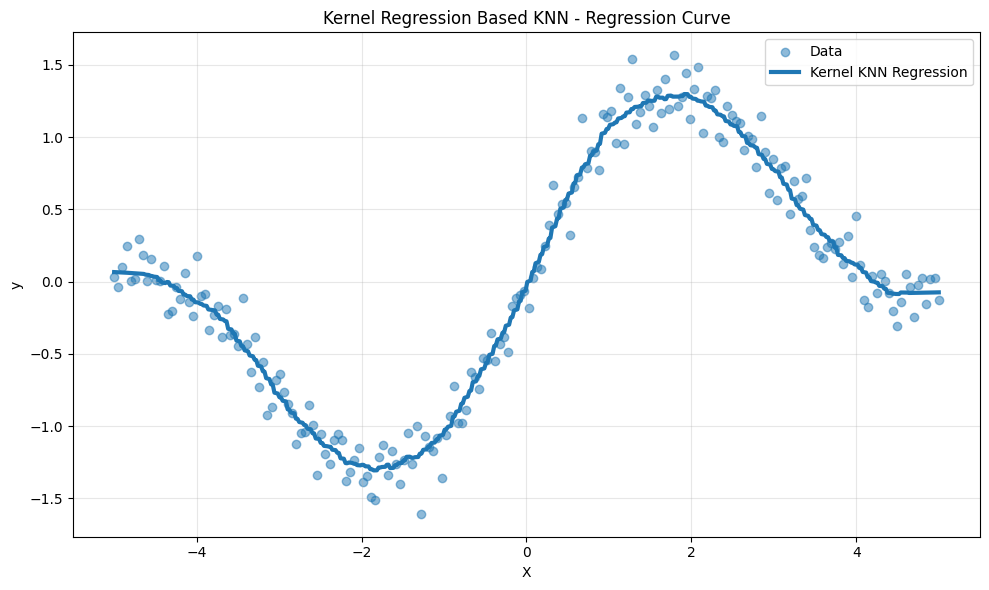


KERNEL NEIGHBOR WEIGHT ANALYSIS
Neighbor    Distance       Target         Weight         Normalized     
---------------------------------------------------------------------------
1           0.057434       -2.944885      0.998352       0.101837       
2           0.101523       -3.354813      0.994860       0.101481       
3           0.114731       -2.271616      0.993440       0.101336       
4           0.191989       -5.024752      0.981739       0.100143       
5           0.213763       -4.288587      0.977412       0.099701       
6           0.219277       -4.693961      0.976245       0.099582       
7           0.235189       -6.026202      0.972722       0.099223       
8           0.235913       1.155668       0.972556       0.099206       
9           0.237703       1.021032       0.972144       0.099164       
10          0.271072       -1.802836      0.963927       0.098326       
---------------------------------------------------------------------------
Kernel Weigh

In [8]:
# ============================================================
# KERNEL REGRESSION BASED KNN REGRESSION
# FROM SCRATCH - NO SCIKIT-LEARN
# NUMPY + MATPLOTLIB ONLY
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)


# ============================================================
# 1. GENERATE SYNTHETIC REGRESSION DATA
# ============================================================

n_samples = 1000

# Two input features
X = np.random.uniform(-5, 5, size=(n_samples, 2))

# Non-linear target function
y = (
    3 * np.sin(X[:, 0])
    + 2 * np.cos(X[:, 1])
    + 0.5 * X[:, 0] * X[:, 1]
    + np.random.normal(0, 0.5, n_samples)
)


# ============================================================
# 2. TRAIN-TEST SPLIT FROM SCRATCH
# ============================================================

train_ratio = 0.8

indices = np.random.permutation(n_samples)

train_size = int(train_ratio * n_samples)

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]


# ============================================================
# 3. STANDARDIZATION FROM SCRATCH
# ============================================================

X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)

# Prevent division by zero
X_std[X_std == 0] = 1

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std


# ============================================================
# 4. KERNEL KNN REGRESSOR
# ============================================================

class KernelKNNRegressor:

    def __init__(
        self,
        n_neighbors=10,
        bandwidth=1.0,
        kernel="gaussian"
    ):
        self.n_neighbors = n_neighbors
        self.bandwidth = bandwidth
        self.kernel = kernel

        self.X_train = None
        self.y_train = None


    # --------------------------------------------------------
    # FIT
    # --------------------------------------------------------

    def fit(self, X, y):

        self.X_train = np.asarray(X, dtype=float)
        self.y_train = np.asarray(y, dtype=float)

        if len(self.X_train) != len(self.y_train):
            raise ValueError(
                "X and y must contain the same number of samples."
            )

        if self.n_neighbors <= 0:
            raise ValueError(
                "n_neighbors must be greater than 0."
            )

        if self.n_neighbors > len(self.X_train):
            raise ValueError(
                "n_neighbors cannot be greater than training samples."
            )

        if self.bandwidth <= 0:
            raise ValueError(
                "bandwidth must be greater than 0."
            )

        return self


    # --------------------------------------------------------
    # EUCLIDEAN DISTANCE
    # --------------------------------------------------------

    def _euclidean_distance(self, x):

        distances = np.sqrt(
            np.sum(
                (self.X_train - x) ** 2,
                axis=1
            )
        )

        return distances


    # --------------------------------------------------------
    # KERNEL FUNCTIONS
    # --------------------------------------------------------

    def _kernel_function(self, u):

        # ---------------------------------------------
        # Gaussian Kernel
        # ---------------------------------------------
        if self.kernel == "gaussian":

            return np.exp(-0.5 * u ** 2)


        # ---------------------------------------------
        # Epanechnikov Kernel
        # ---------------------------------------------
        elif self.kernel == "epanechnikov":

            weights = np.zeros_like(u)

            mask = np.abs(u) <= 1

            weights[mask] = (
                0.75 * (1 - u[mask] ** 2)
            )

            return weights


        # ---------------------------------------------
        # Uniform Kernel
        # ---------------------------------------------
        elif self.kernel == "uniform":

            weights = np.zeros_like(u)

            mask = np.abs(u) <= 1

            weights[mask] = 0.5

            return weights


        # ---------------------------------------------
        # Triangular Kernel
        # ---------------------------------------------
        elif self.kernel == "triangular":

            return np.maximum(
                1 - np.abs(u),
                0
            )


        # ---------------------------------------------
        # Quartic / Biweight Kernel
        # ---------------------------------------------
        elif self.kernel == "quartic":

            weights = np.zeros_like(u)

            mask = np.abs(u) <= 1

            weights[mask] = (
                (15 / 16)
                * (1 - u[mask] ** 2) ** 2
            )

            return weights


        else:

            raise ValueError(
                "Unknown kernel. Use: "
                "'gaussian', "
                "'epanechnikov', "
                "'uniform', "
                "'triangular', "
                "or 'quartic'."
            )


    # --------------------------------------------------------
    # PREDICT
    # --------------------------------------------------------

    def predict(self, X):

        X = np.asarray(X, dtype=float)

        predictions = []

        for x in X:

            # -----------------------------------------
            # Calculate distances
            # -----------------------------------------

            distances = self._euclidean_distance(x)


            # -----------------------------------------
            # Find K nearest neighbors
            # -----------------------------------------

            neighbor_indices = np.argsort(
                distances
            )[:self.n_neighbors]


            neighbor_distances = distances[
                neighbor_indices
            ]

            neighbor_targets = self.y_train[
                neighbor_indices
            ]


            # -----------------------------------------
            # Scale distances by bandwidth
            # -----------------------------------------

            u = (
                neighbor_distances
                / self.bandwidth
            )


            # -----------------------------------------
            # Calculate kernel weights
            # -----------------------------------------

            weights = self._kernel_function(u)


            # -----------------------------------------
            # Handle zero weights
            # -----------------------------------------

            weight_sum = np.sum(weights)

            if weight_sum <= 1e-12:

                # Fall back to nearest neighbor
                prediction = neighbor_targets[0]

            else:

                # -------------------------------------
                # Kernel weighted prediction
                # -------------------------------------

                prediction = (
                    np.sum(
                        weights * neighbor_targets
                    )
                    / weight_sum
                )


            predictions.append(prediction)


        return np.asarray(predictions)


    # --------------------------------------------------------
    # GET NEIGHBORS
    # --------------------------------------------------------

    def get_neighbors(self, x):

        distances = self._euclidean_distance(x)

        neighbor_indices = np.argsort(
            distances
        )[:self.n_neighbors]

        neighbor_distances = distances[
            neighbor_indices
        ]

        neighbor_targets = self.y_train[
            neighbor_indices
        ]

        u = (
            neighbor_distances
            / self.bandwidth
        )

        weights = self._kernel_function(u)

        return (
            neighbor_indices,
            neighbor_distances,
            neighbor_targets,
            weights
        )


# ============================================================
# 5. EVALUATION METRICS FROM SCRATCH
# ============================================================

def mae(y_true, y_pred):

    return np.mean(
        np.abs(y_true - y_pred)
    )


def mse(y_true, y_pred):

    return np.mean(
        (y_true - y_pred) ** 2
    )


def rmse(y_true, y_pred):

    return np.sqrt(
        mse(y_true, y_pred)
    )


def r2_score(y_true, y_pred):

    ss_res = np.sum(
        (y_true - y_pred) ** 2
    )

    ss_tot = np.sum(
        (y_true - np.mean(y_true)) ** 2
    )

    if ss_tot == 0:
        return 0.0

    return 1 - (
        ss_res / ss_tot
    )


def mape(y_true, y_pred):

    denominator = np.maximum(
        np.abs(y_true),
        1e-10
    )

    return np.mean(
        np.abs(
            (y_true - y_pred)
            / denominator
        )
    ) * 100


# ============================================================
# 6. CREATE KERNEL KNN MODEL
# ============================================================

model = KernelKNNRegressor(
    n_neighbors=10,
    bandwidth=1.0,
    kernel="gaussian"
)


# ============================================================
# 7. TRAIN MODEL
# ============================================================

model.fit(
    X_train_scaled,
    y_train
)


# ============================================================
# 8. PREDICTIONS
# ============================================================

y_train_pred = model.predict(
    X_train_scaled
)

y_test_pred = model.predict(
    X_test_scaled
)


# ============================================================
# 9. EVALUATION
# ============================================================

train_mae = mae(
    y_train,
    y_train_pred
)

train_mse = mse(
    y_train,
    y_train_pred
)

train_rmse = rmse(
    y_train,
    y_train_pred
)

train_r2 = r2_score(
    y_train,
    y_train_pred
)

train_mape = mape(
    y_train,
    y_train_pred
)


test_mae = mae(
    y_test,
    y_test_pred
)

test_mse = mse(
    y_test,
    y_test_pred
)

test_rmse = rmse(
    y_test,
    y_test_pred
)

test_r2 = r2_score(
    y_test,
    y_test_pred
)

test_mape = mape(
    y_test,
    y_test_pred
)


# ============================================================
# 10. PRINT EVALUATION RESULTS
# ============================================================

print("=" * 65)
print("KERNEL KNN REGRESSION - EVALUATION")
print("=" * 65)

print("\nModel Parameters")
print("-" * 65)
print("Kernel       :", model.kernel)
print("K Neighbors  :", model.n_neighbors)
print("Bandwidth    :", model.bandwidth)

print("\nTraining Performance")
print("-" * 65)
print(f"MAE          : {train_mae:.6f}")
print(f"MSE          : {train_mse:.6f}")
print(f"RMSE         : {train_rmse:.6f}")
print(f"R²           : {train_r2:.6f}")
print(f"MAPE         : {train_mape:.2f}%")

print("\nTesting Performance")
print("-" * 65)
print(f"MAE          : {test_mae:.6f}")
print(f"MSE          : {test_mse:.6f}")
print(f"RMSE         : {test_rmse:.6f}")
print(f"R²           : {test_r2:.6f}")
print(f"MAPE         : {test_mape:.2f}%")

print("=" * 65)


# ============================================================
# 11. PLOT 1 - ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.6
)

min_value = min(
    np.min(y_test),
    np.min(y_test_pred)
)

max_value = max(
    np.max(y_test),
    np.max(y_test_pred)
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Kernel KNN Regression - Actual vs Predicted")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 12. PLOT 2 - RESIDUALS VS PREDICTED
# ============================================================

residuals = (
    y_test - y_test_pred
)

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 13. PLOT 3 - RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 6))

plt.hist(
    residuals,
    bins=30,
    alpha=0.7
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 14. PLOT 4 - ABSOLUTE ERROR
# ============================================================

absolute_errors = np.abs(
    y_test - y_test_pred
)

plt.figure(figsize=(10, 5))

plt.plot(
    absolute_errors,
    linewidth=1
)

plt.xlabel("Test Sample Index")
plt.ylabel("Absolute Error")
plt.title("Absolute Prediction Error")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 15. EVALUATE DIFFERENT K VALUES
# ============================================================

k_values = [
    1, 3, 5, 7, 10,
    15, 20, 25, 30,
    40, 50
]

mae_values = []
mse_values = []
rmse_values = []
r2_values = []
mape_values = []


for k in k_values:

    temp_model = KernelKNNRegressor(
        n_neighbors=k,
        bandwidth=1.0,
        kernel="gaussian"
    )

    temp_model.fit(
        X_train_scaled,
        y_train
    )

    predictions = temp_model.predict(
        X_test_scaled
    )

    mae_values.append(
        mae(y_test, predictions)
    )

    mse_values.append(
        mse(y_test, predictions)
    )

    rmse_values.append(
        rmse(y_test, predictions)
    )

    r2_values.append(
        r2_score(y_test, predictions)
    )

    mape_values.append(
        mape(y_test, predictions)
    )


# ============================================================
# 16. PLOT 5 - MAE VS K
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    mae_values,
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("MAE")
plt.title("MAE vs K - Kernel KNN")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 17. PLOT 6 - MSE VS K
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    mse_values,
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("MSE")
plt.title("MSE vs K - Kernel KNN")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 18. PLOT 7 - RMSE VS K
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    rmse_values,
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("RMSE")
plt.title("RMSE vs K - Kernel KNN")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 19. PLOT 8 - R² VS K
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    r2_values,
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("R² Score")
plt.title("R² vs K - Kernel KNN")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 20. PLOT 9 - MAPE VS K
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    mape_values,
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("MAPE (%)")
plt.title("MAPE vs K - Kernel KNN")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 21. FIND BEST K
# ============================================================

best_k_mae = k_values[
    np.argmin(mae_values)
]

best_k_mse = k_values[
    np.argmin(mse_values)
]

best_k_rmse = k_values[
    np.argmin(rmse_values)
]

best_k_r2 = k_values[
    np.argmax(r2_values)
]

best_k_mape = k_values[
    np.argmin(mape_values)
]


print("\n" + "=" * 65)
print("BEST K ANALYSIS")
print("=" * 65)

print(
    f"Best K based on MAE  : {best_k_mae}"
)

print(
    f"Best K based on MSE  : {best_k_mse}"
)

print(
    f"Best K based on RMSE : {best_k_rmse}"
)

print(
    f"Best K based on R²   : {best_k_r2}"
)

print(
    f"Best K based on MAPE : {best_k_mape}"
)

print("=" * 65)


# ============================================================
# 22. COMPARE DIFFERENT KERNEL FUNCTIONS
# ============================================================

kernels = [
    "gaussian",
    "epanechnikov",
    "uniform",
    "triangular",
    "quartic"
]

kernel_mae = []
kernel_mse = []
kernel_rmse = []
kernel_r2 = []
kernel_mape = []


for kernel_name in kernels:

    temp_model = KernelKNNRegressor(
        n_neighbors=10,
        bandwidth=1.0,
        kernel=kernel_name
    )

    temp_model.fit(
        X_train_scaled,
        y_train
    )

    predictions = temp_model.predict(
        X_test_scaled
    )

    kernel_mae.append(
        mae(y_test, predictions)
    )

    kernel_mse.append(
        mse(y_test, predictions)
    )

    kernel_rmse.append(
        rmse(y_test, predictions)
    )

    kernel_r2.append(
        r2_score(y_test, predictions)
    )

    kernel_mape.append(
        mape(y_test, predictions)
    )


# ============================================================
# 23. PRINT KERNEL COMPARISON
# ============================================================

print("\n" + "=" * 85)
print("KERNEL COMPARISON")
print("=" * 85)

print(
    f"{'Kernel':<18}"
    f"{'MAE':<12}"
    f"{'MSE':<12}"
    f"{'RMSE':<12}"
    f"{'R²':<12}"
    f"{'MAPE':<12}"
)

print("-" * 85)

for i, kernel_name in enumerate(kernels):

    print(
        f"{kernel_name:<18}"
        f"{kernel_mae[i]:<12.6f}"
        f"{kernel_mse[i]:<12.6f}"
        f"{kernel_rmse[i]:<12.6f}"
        f"{kernel_r2[i]:<12.6f}"
        f"{kernel_mape[i]:<12.2f}%"
    )

print("=" * 85)


# ============================================================
# 24. PLOT 10 - KERNEL COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    kernels,
    kernel_mae,
    marker="o"
)

plt.xlabel("Kernel Function")
plt.ylabel("MAE")
plt.title("Kernel Function Comparison")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 25. BANDWIDTH COMPARISON
# ============================================================

bandwidth_values = [
    0.1,
    0.25,
    0.5,
    0.75,
    1.0,
    1.5,
    2.0,
    3.0
]

bandwidth_mae = []
bandwidth_mse = []
bandwidth_rmse = []
bandwidth_r2 = []


for bandwidth in bandwidth_values:

    temp_model = KernelKNNRegressor(
        n_neighbors=10,
        bandwidth=bandwidth,
        kernel="gaussian"
    )

    temp_model.fit(
        X_train_scaled,
        y_train
    )

    predictions = temp_model.predict(
        X_test_scaled
    )

    bandwidth_mae.append(
        mae(y_test, predictions)
    )

    bandwidth_mse.append(
        mse(y_test, predictions)
    )

    bandwidth_rmse.append(
        rmse(y_test, predictions)
    )

    bandwidth_r2.append(
        r2_score(y_test, predictions)
    )


# ============================================================
# 26. PLOT 11 - BANDWIDTH VS MAE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    bandwidth_values,
    bandwidth_mae,
    marker="o"
)

plt.xlabel("Bandwidth")
plt.ylabel("MAE")
plt.title("Bandwidth vs MAE - Gaussian Kernel")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 27. PLOT 12 - BANDWIDTH VS R²
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    bandwidth_values,
    bandwidth_r2,
    marker="o"
)

plt.xlabel("Bandwidth")
plt.ylabel("R² Score")
plt.title("Bandwidth vs R² - Gaussian Kernel")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 28. BEST BANDWIDTH
# ============================================================

best_bandwidth_mae = bandwidth_values[
    np.argmin(bandwidth_mae)
]

best_bandwidth_r2 = bandwidth_values[
    np.argmax(bandwidth_r2)
]


print("\n" + "=" * 65)
print("BEST BANDWIDTH")
print("=" * 65)

print(
    f"Best bandwidth based on MAE : "
    f"{best_bandwidth_mae}"
)

print(
    f"Best bandwidth based on R²  : "
    f"{best_bandwidth_r2}"
)

print("=" * 65)


# ============================================================
# 29. 1-D KERNEL KNN REGRESSION VISUALIZATION
# ============================================================

# Create a simple one-dimensional dataset
np.random.seed(42)

X_1d = np.linspace(
    -5,
    5,
    200
).reshape(-1, 1)

y_1d = (
    np.sin(X_1d[:, 0])
    + 0.2 * X_1d[:, 0]
    + np.random.normal(
        0,
        0.15,
        200
    )
)


# ------------------------------------------------------------
# Train 1-D model
# ------------------------------------------------------------

kernel_1d = KernelKNNRegressor(
    n_neighbors=15,
    bandwidth=0.5,
    kernel="gaussian"
)

kernel_1d.fit(
    X_1d,
    y_1d
)


# ------------------------------------------------------------
# Prediction grid
# ------------------------------------------------------------

X_grid = np.linspace(
    -5,
    5,
    500
).reshape(-1, 1)

y_grid_pred = kernel_1d.predict(
    X_grid
)


# ============================================================
# 30. PLOT 13 - KERNEL REGRESSION CURVE
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    X_1d[:, 0],
    y_1d,
    alpha=0.5,
    label="Data"
)

plt.plot(
    X_grid[:, 0],
    y_grid_pred,
    linewidth=3,
    label="Kernel KNN Regression"
)

plt.xlabel("X")
plt.ylabel("y")

plt.title(
    "Kernel Regression Based KNN - Regression Curve"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 31. NEIGHBOR WEIGHT ANALYSIS
# ============================================================

sample_index = 0

sample = X_test_scaled[
    sample_index
]

(
    neighbor_indices,
    neighbor_distances,
    neighbor_targets,
    neighbor_weights
) = model.get_neighbors(
    sample
)


# Normalize weights for interpretation
weight_sum = np.sum(
    neighbor_weights
)

if weight_sum > 0:

    normalized_weights = (
        neighbor_weights
        / weight_sum
    )

else:

    normalized_weights = (
        np.zeros_like(neighbor_weights)
    )


print("\n" + "=" * 75)
print("KERNEL NEIGHBOR WEIGHT ANALYSIS")
print("=" * 75)

print(
    f"{'Neighbor':<12}"
    f"{'Distance':<15}"
    f"{'Target':<15}"
    f"{'Weight':<15}"
    f"{'Normalized':<15}"
)

print("-" * 75)

for i in range(
    len(neighbor_indices)
):

    print(
        f"{i + 1:<12}"
        f"{neighbor_distances[i]:<15.6f}"
        f"{neighbor_targets[i]:<15.6f}"
        f"{neighbor_weights[i]:<15.6f}"
        f"{normalized_weights[i]:<15.6f}"
    )

print("-" * 75)

weighted_prediction = (
    np.sum(
        normalized_weights
        * neighbor_targets
    )
)

print(
    f"Kernel Weighted Prediction: "
    f"{weighted_prediction:.6f}"
)

print(
    f"Actual Target: "
    f"{y_test[sample_index]:.6f}"
)

print("=" * 75)

DATASET
Number of samples : 1000
Number of features: 2

k-NN DENSITY ESTIMATION
K neighbors : 10
Mean density: 0.07260000665952741
Min density : 0.003339128317937695
Max density : 0.32594583316376474

DENSITY STATISTICS
Mean   : 0.07260001
Median : 0.06096298
Std    : 0.05877336
Minimum: 0.00333913
Maximum: 0.32594583


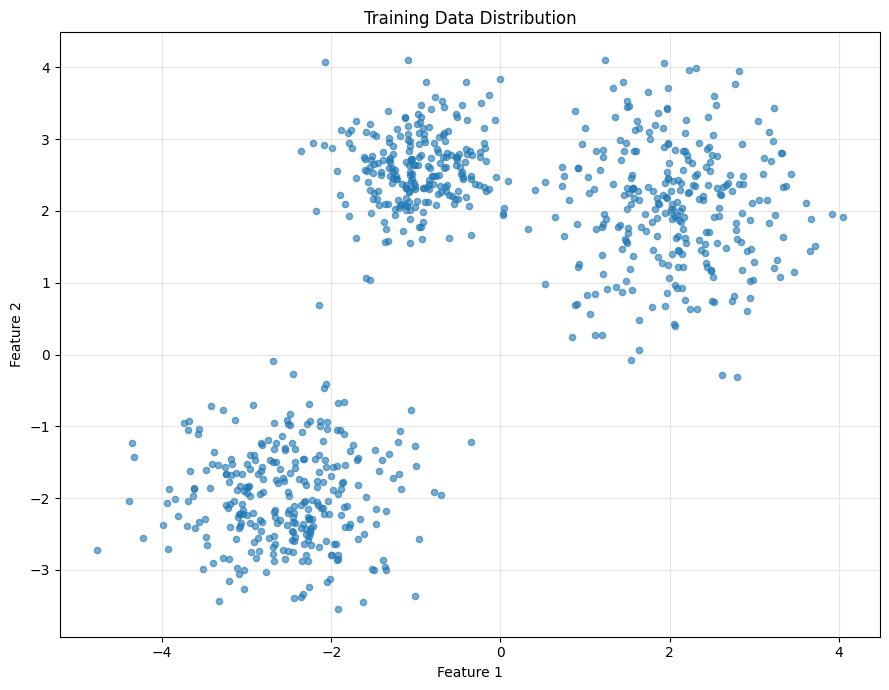

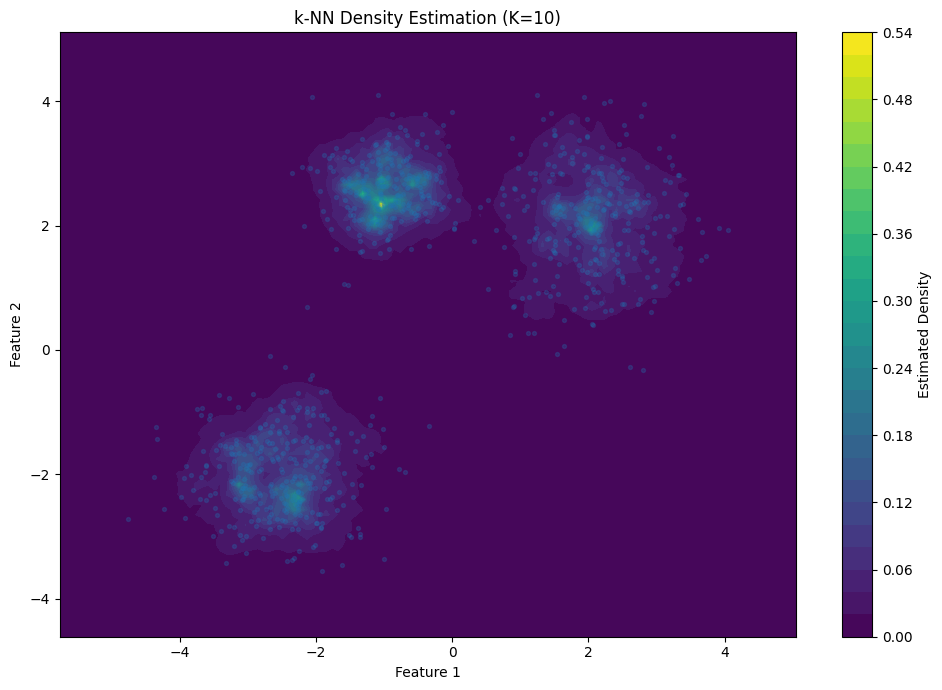

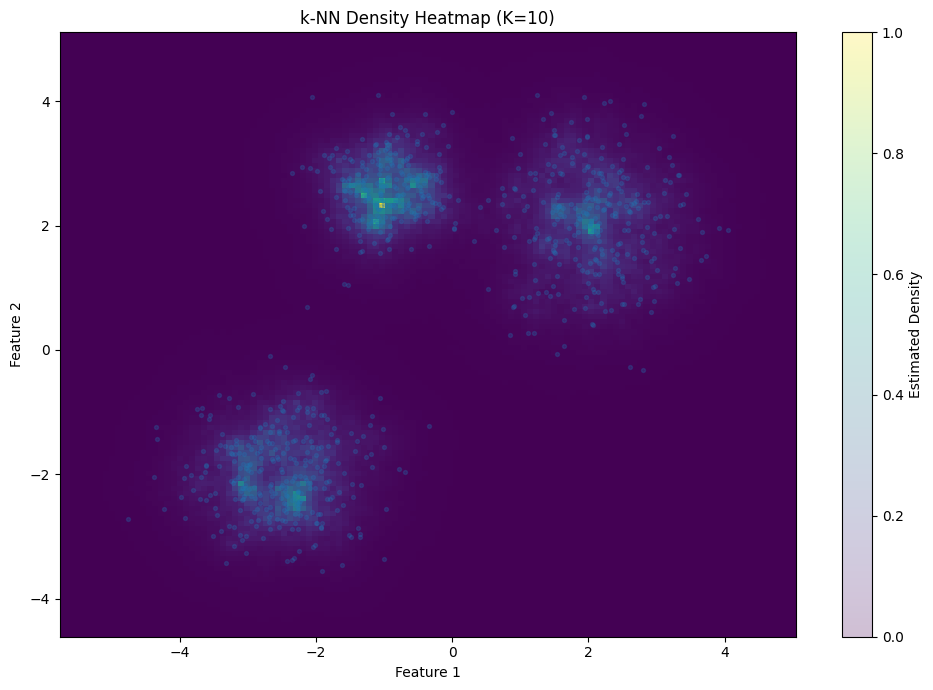

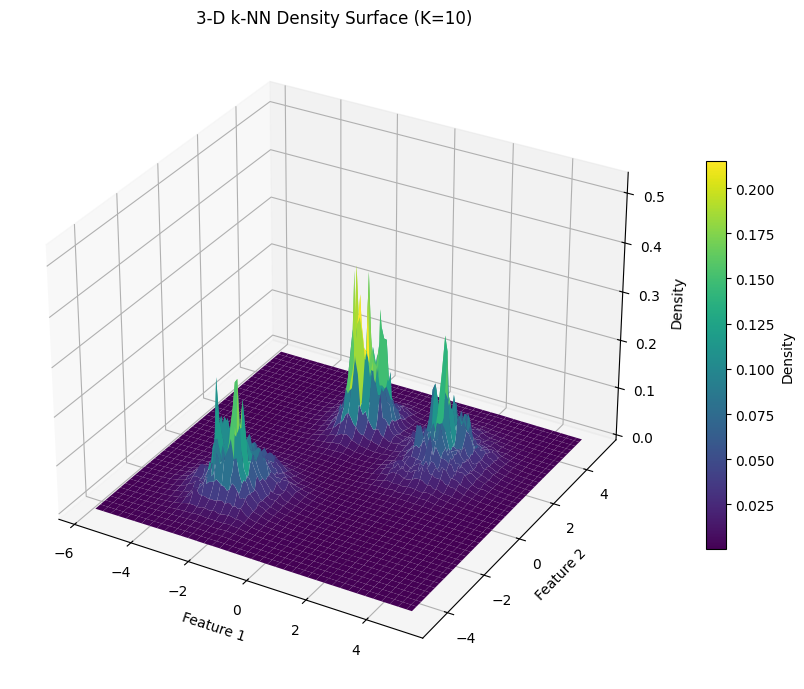

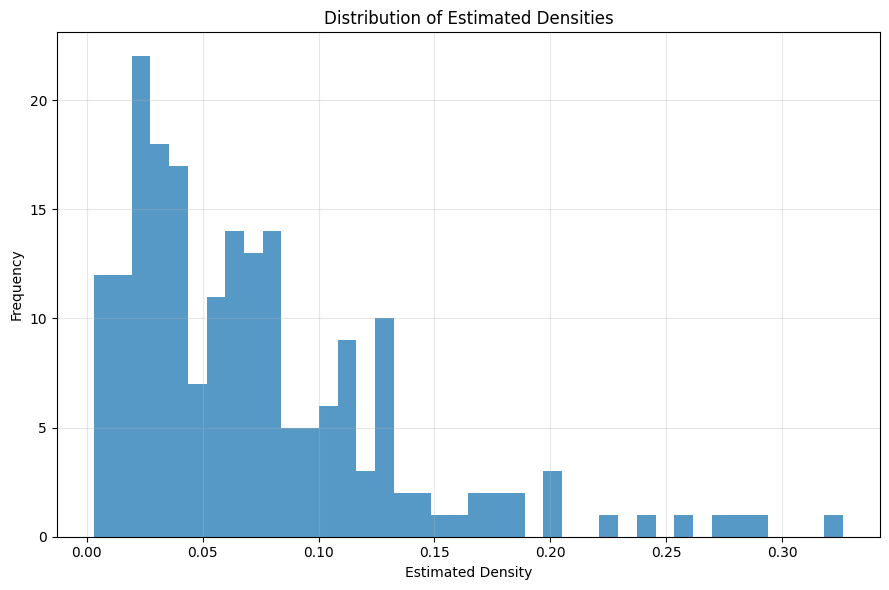

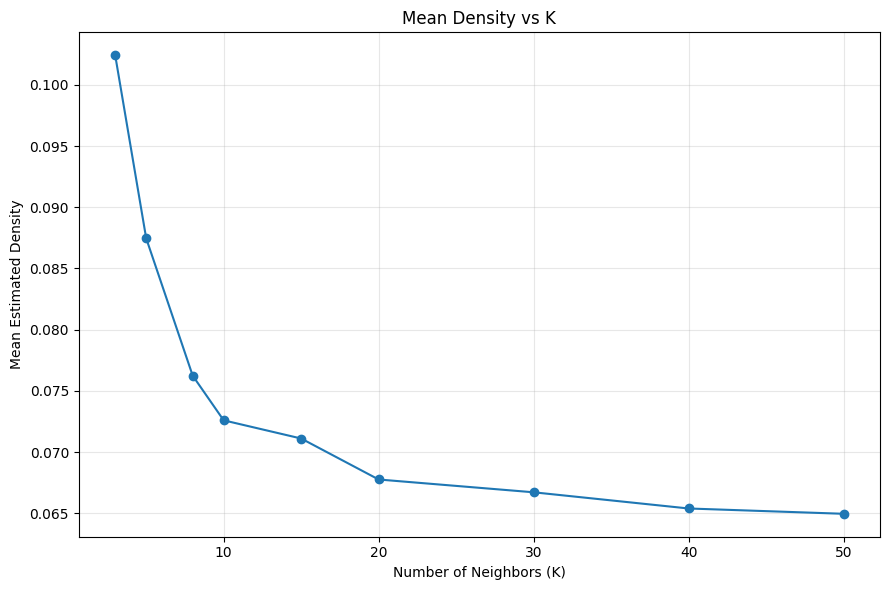

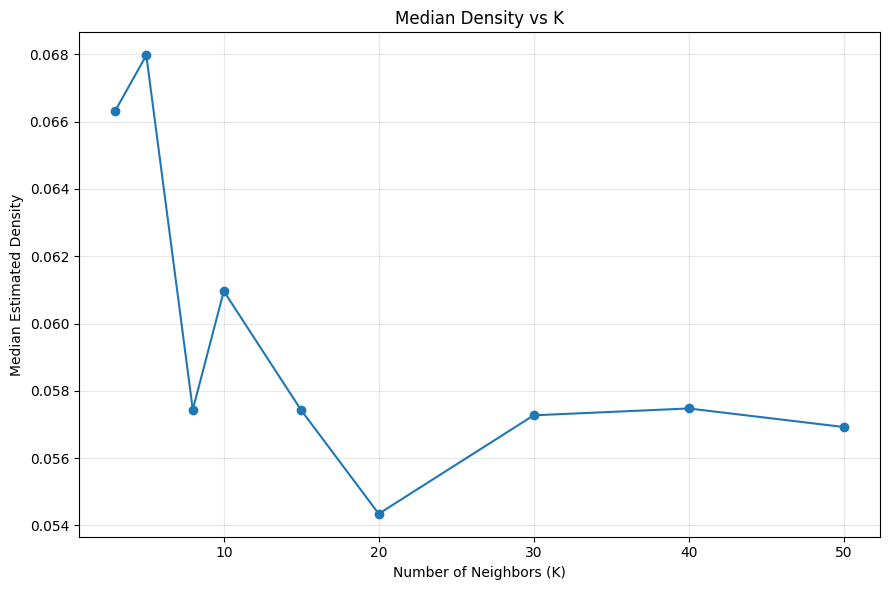

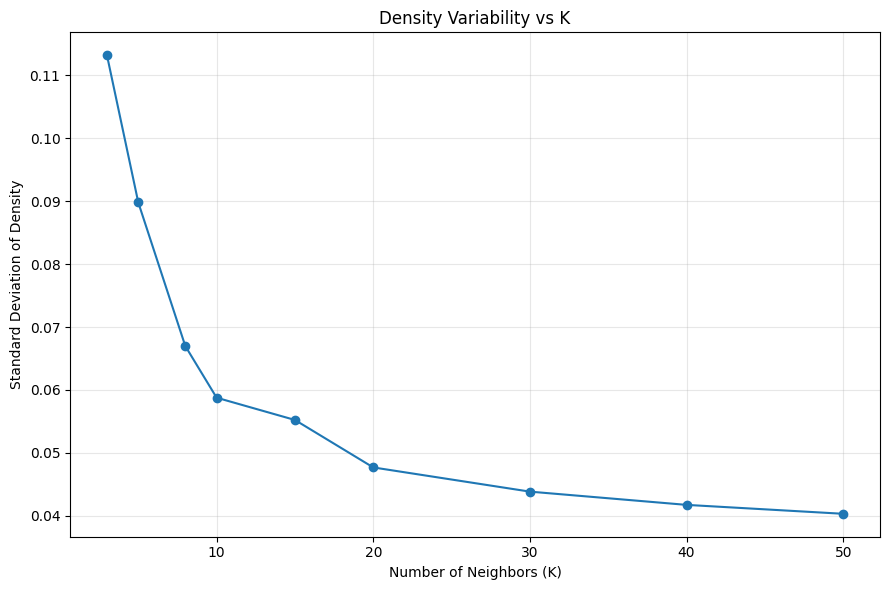


DENSITY AT SELECTED QUERY POINTS
Point                    Density             
----------------------------------------------------------------------
[-2.5 -2. ]              0.07405658          
[2. 2.]                  0.17444553          
[-1.   2.5]              0.17244138          
[0. 0.]                  0.00230584          
[5. 5.]                  0.00048272          

k-NN NEIGHBOR ANALYSIS
Query point       : [0. 0.]
K                 : 10
K-th neighbor dist: 1.3136069510959296
Estimated density : 0.002305840508561918

Nearest Neighbors
---------------------------------------------------------------------------
Neighbor    Index       Distance       X1             X2             
---------------------------------------------------------------------------
1           325         0.875403       0.841589       0.240955       
2           118         1.109632       0.527301       0.976338       
3           617         1.120969       0.888342       0.683681       
4           7

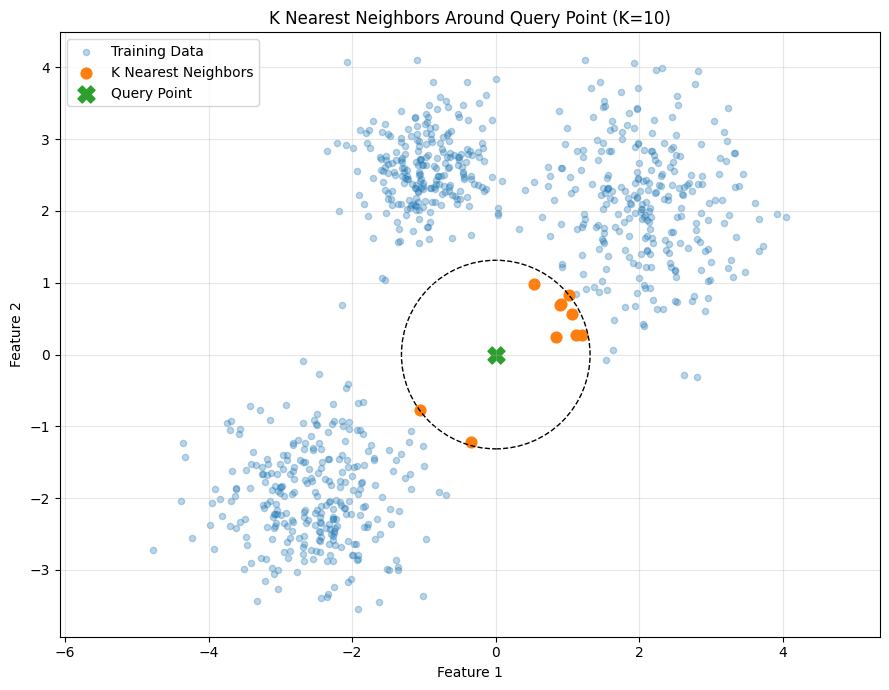


k-NN DENSITY ESTIMATION SUMMARY
Training samples : 800
Test samples     : 200
Dimensions       : 2
Selected K       : 10
Mean density     : 0.07260001
Median density   : 0.06096298
Std density      : 0.05877336
Minimum density  : 0.00333913
Maximum density  : 0.32594583


In [9]:
# ============================================================
# k-NN DENSITY ESTIMATION
# FROM SCRATCH
# NO SCIKIT-LEARN
# NUMPY + MATPLOTLIB ONLY
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


# ============================================================
# 1. GENERATE 2-D SYNTHETIC DATA
# ============================================================

n_samples = 1000

# ------------------------------------------------------------
# Create a mixture of 3 Gaussian clusters
# ------------------------------------------------------------

n1 = 350
n2 = 350
n3 = 300

cluster1 = np.random.normal(
    loc=[-2.5, -2.0],
    scale=[0.7, 0.7],
    size=(n1, 2)
)

cluster2 = np.random.normal(
    loc=[2.0, 2.0],
    scale=[0.8, 0.8],
    size=(n2, 2)
)

cluster3 = np.random.normal(
    loc=[-1.0, 2.5],
    scale=[0.5, 0.5],
    size=(n3, 2)
)

X = np.vstack([
    cluster1,
    cluster2,
    cluster3
])

print("=" * 65)
print("DATASET")
print("=" * 65)
print("Number of samples :", X.shape[0])
print("Number of features:", X.shape[1])
print("=" * 65)


# ============================================================
# 2. TRAIN-TEST SPLIT FROM SCRATCH
# ============================================================

train_ratio = 0.8

indices = np.random.permutation(
    len(X)
)

train_size = int(
    train_ratio * len(X)
)

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X[train_indices]
X_test = X[test_indices]


# ============================================================
# 3. k-NN DENSITY ESTIMATOR
# ============================================================

class KNNDensityEstimator:

    def __init__(
        self,
        n_neighbors=10,
        epsilon=1e-12
    ):

        self.n_neighbors = n_neighbors
        self.epsilon = epsilon

        self.X_train = None
        self.n_samples = None
        self.n_features = None


    # --------------------------------------------------------
    # FIT
    # --------------------------------------------------------

    def fit(self, X):

        X = np.asarray(
            X,
            dtype=float
        )

        if X.ndim != 2:
            raise ValueError(
                "X must be a 2-D array."
            )

        if self.n_neighbors <= 0:
            raise ValueError(
                "n_neighbors must be greater than 0."
            )

        if self.n_neighbors >= len(X):
            raise ValueError(
                "n_neighbors must be smaller than "
                "the number of training samples."
            )

        self.X_train = X

        self.n_samples = X.shape[0]

        self.n_features = X.shape[1]

        return self


    # --------------------------------------------------------
    # CALCULATE EUCLIDEAN DISTANCES
    # --------------------------------------------------------

    def _euclidean_distances(self, x):

        differences = (
            self.X_train - x
        )

        distances = np.sqrt(
            np.sum(
                differences ** 2,
                axis=1
            )
        )

        return distances


    # --------------------------------------------------------
    # K-TH NEAREST NEIGHBOR DISTANCE
    # --------------------------------------------------------

    def _kth_distance(self, x):

        distances = (
            self._euclidean_distances(x)
        )

        sorted_distances = np.sort(
            distances
        )

        # k-th neighbor
        radius = sorted_distances[
            self.n_neighbors - 1
        ]

        return radius


    # --------------------------------------------------------
    # HYPERSPHERE VOLUME
    # --------------------------------------------------------

    def _hypersphere_volume(self, radius):

        d = self.n_features

        # Volume of d-dimensional unit sphere:
        #
        # V_d = pi^(d/2) / Gamma(d/2 + 1)
        #
        # Since we do not use scipy,
        # implement Gamma for integer/half-integer
        # dimensions using math.gamma.

        import math

        unit_volume = (
            np.pi ** (d / 2)
            / math.gamma(
                d / 2 + 1
            )
        )

        volume = (
            unit_volume
            * radius ** d
        )

        return volume


    # --------------------------------------------------------
    # DENSITY ESTIMATION FOR ONE POINT
    # --------------------------------------------------------

    def _density_single(self, x):

        radius = self._kth_distance(x)

        volume = (
            self._hypersphere_volume(
                radius
            )
        )

        # Prevent division by zero
        volume = max(
            volume,
            self.epsilon
        )

        density = (
            self.n_neighbors
            / (
                self.n_samples
                * volume
            )
        )

        return density


    # --------------------------------------------------------
    # PREDICT DENSITY
    # --------------------------------------------------------

    def predict_density(self, X):

        X = np.asarray(
            X,
            dtype=float
        )

        densities = np.array([
            self._density_single(x)
            for x in X
        ])

        return densities


    # --------------------------------------------------------
    # GET K-NN INFORMATION
    # --------------------------------------------------------

    def get_neighbors(self, x):

        distances = (
            self._euclidean_distances(x)
        )

        neighbor_indices = np.argsort(
            distances
        )[:self.n_neighbors]

        neighbor_distances = (
            distances[
                neighbor_indices
            ]
        )

        kth_distance = (
            neighbor_distances[-1]
        )

        density = (
            self._density_single(x)
        )

        return (
            neighbor_indices,
            neighbor_distances,
            kth_distance,
            density
        )


# ============================================================
# 4. TRAIN k-NN DENSITY ESTIMATOR
# ============================================================

k = 10

density_model = KNNDensityEstimator(
    n_neighbors=k
)

density_model.fit(
    X_train
)


# ============================================================
# 5. ESTIMATE TEST-POINT DENSITIES
# ============================================================

test_density = (
    density_model.predict_density(
        X_test
    )
)


print("\n" + "=" * 65)
print("k-NN DENSITY ESTIMATION")
print("=" * 65)

print("K neighbors :", k)
print("Mean density:", np.mean(test_density))
print("Min density :", np.min(test_density))
print("Max density :", np.max(test_density))
print("=" * 65)


# ============================================================
# 6. DENSITY STATISTICS
# ============================================================

print("\n" + "=" * 65)
print("DENSITY STATISTICS")
print("=" * 65)

print(
    f"Mean   : {np.mean(test_density):.8f}"
)

print(
    f"Median : {np.median(test_density):.8f}"
)

print(
    f"Std    : {np.std(test_density):.8f}"
)

print(
    f"Minimum: {np.min(test_density):.8f}"
)

print(
    f"Maximum: {np.max(test_density):.8f}"
)

print("=" * 65)


# ============================================================
# 7. PLOT 1 - ORIGINAL DATA
# ============================================================

plt.figure(figsize=(9, 7))

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    s=20,
    alpha=0.6
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.title(
    "Training Data Distribution"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 8. CREATE 2-D GRID FOR DENSITY ESTIMATION
# ============================================================

x_min = X[:, 0].min() - 1
x_max = X[:, 0].max() + 1

y_min = X[:, 1].min() - 1
y_max = X[:, 1].max() + 1

grid_size = 120

x_grid = np.linspace(
    x_min,
    x_max,
    grid_size
)

y_grid = np.linspace(
    y_min,
    y_max,
    grid_size
)

xx, yy = np.meshgrid(
    x_grid,
    y_grid
)

grid_points = np.column_stack([
    xx.ravel(),
    yy.ravel()
])


# ============================================================
# 9. ESTIMATE DENSITY ON GRID
# ============================================================

grid_density = (
    density_model.predict_density(
        grid_points
    )
)

density_surface = (
    grid_density.reshape(
        xx.shape
    )
)


# ============================================================
# 10. PLOT 2 - DENSITY CONTOUR
# ============================================================

plt.figure(figsize=(10, 7))

contour = plt.contourf(
    xx,
    yy,
    density_surface,
    levels=30
)

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    s=8,
    alpha=0.25
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.title(
    f"k-NN Density Estimation "
    f"(K={k})"
)

plt.colorbar(
    contour,
    label="Estimated Density"
)

plt.tight_layout()
plt.show()


# ============================================================
# 11. PLOT 3 - DENSITY HEATMAP
# ============================================================

plt.figure(figsize=(10, 7))

plt.imshow(
    density_surface,
    extent=[
        x_min,
        x_max,
        y_min,
        y_max
    ],
    origin="lower",
    aspect="auto"
)

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    s=8,
    alpha=0.25
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.title(
    f"k-NN Density Heatmap "
    f"(K={k})"
)

plt.colorbar(
    label="Estimated Density"
)

plt.tight_layout()
plt.show()


# ============================================================
# 12. PLOT 4 - 3-D DENSITY SURFACE
# ============================================================

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(
    figsize=(10, 7)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

surface = ax.plot_surface(
    xx,
    yy,
    density_surface,
    cmap="viridis",
    linewidth=0,
    antialiased=True
)

ax.set_xlabel(
    "Feature 1"
)

ax.set_ylabel(
    "Feature 2"
)

ax.set_zlabel(
    "Density"
)

ax.set_title(
    f"3-D k-NN Density Surface "
    f"(K={k})"
)

fig.colorbar(
    surface,
    ax=ax,
    shrink=0.6,
    label="Density"
)

plt.tight_layout()
plt.show()


# ============================================================
# 13. PLOT 5 - DENSITY DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 6))

plt.hist(
    test_density,
    bins=40,
    alpha=0.75
)

plt.xlabel(
    "Estimated Density"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Distribution of Estimated Densities"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 14. K-VALUE EVALUATION
# ============================================================

k_values = [
    3,
    5,
    8,
    10,
    15,
    20,
    30,
    40,
    50
]

mean_densities = []
median_densities = []
std_densities = []


for current_k in k_values:

    temp_model = KNNDensityEstimator(
        n_neighbors=current_k
    )

    temp_model.fit(
        X_train
    )

    densities = (
        temp_model.predict_density(
            X_test
        )
    )

    mean_densities.append(
        np.mean(densities)
    )

    median_densities.append(
        np.median(densities)
    )

    std_densities.append(
        np.std(densities)
    )


# ============================================================
# 15. PLOT 6 - MEAN DENSITY VS K
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    k_values,
    mean_densities,
    marker="o"
)

plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "Mean Estimated Density"
)

plt.title(
    "Mean Density vs K"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 16. PLOT 7 - MEDIAN DENSITY VS K
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    k_values,
    median_densities,
    marker="o"
)

plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "Median Estimated Density"
)

plt.title(
    "Median Density vs K"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 17. PLOT 8 - DENSITY VARIABILITY VS K
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    k_values,
    std_densities,
    marker="o"
)

plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "Standard Deviation of Density"
)

plt.title(
    "Density Variability vs K"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 18. DENSITY AT SELECTED POINTS
# ============================================================

query_points = np.array([
    [-2.5, -2.0],
    [2.0, 2.0],
    [-1.0, 2.5],
    [0.0, 0.0],
    [5.0, 5.0]
])

query_density = (
    density_model.predict_density(
        query_points
    )
)


print("\n" + "=" * 70)
print("DENSITY AT SELECTED QUERY POINTS")
print("=" * 70)

print(
    f"{'Point':<25}"
    f"{'Density':<20}"
)

print("-" * 70)

for point, density in zip(
    query_points,
    query_density
):

    print(
        f"{str(point):<25}"
        f"{density:<20.8f}"
    )

print("=" * 70)


# ============================================================
# 19. NEIGHBOR ANALYSIS FOR ONE QUERY POINT
# ============================================================

query_point = np.array([
    0.0,
    0.0
])

(
    neighbor_indices,
    neighbor_distances,
    kth_distance,
    query_density_value
) = density_model.get_neighbors(
    query_point
)


print("\n" + "=" * 75)
print("k-NN NEIGHBOR ANALYSIS")
print("=" * 75)

print(
    "Query point       :",
    query_point
)

print(
    "K                 :",
    k
)

print(
    "K-th neighbor dist:",
    kth_distance
)

print(
    "Estimated density :",
    query_density_value
)

print("\nNearest Neighbors")

print("-" * 75)

print(
    f"{'Neighbor':<12}"
    f"{'Index':<12}"
    f"{'Distance':<15}"
    f"{'X1':<15}"
    f"{'X2':<15}"
)

print("-" * 75)

for i, (
    index,
    distance
) in enumerate(
    zip(
        neighbor_indices,
        neighbor_distances
    )
):

    point = X_train[index]

    print(
        f"{i + 1:<12}"
        f"{index:<12}"
        f"{distance:<15.6f}"
        f"{point[0]:<15.6f}"
        f"{point[1]:<15.6f}"
    )

print("=" * 75)


# ============================================================
# 20. VISUALIZE K NEAREST NEIGHBORS
# ============================================================

plt.figure(figsize=(9, 7))

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    s=20,
    alpha=0.3,
    label="Training Data"
)

nearest_points = X_train[
    neighbor_indices
]

plt.scatter(
    nearest_points[:, 0],
    nearest_points[:, 1],
    s=60,
    label="K Nearest Neighbors"
)

plt.scatter(
    query_point[0],
    query_point[1],
    s=150,
    marker="X",
    label="Query Point"
)

# Draw circle around query point
circle = plt.Circle(
    query_point,
    kth_distance,
    fill=False,
    linestyle="--"
)

plt.gca().add_patch(
    circle
)

plt.xlabel(
    "Feature 1"
)

plt.ylabel(
    "Feature 2"
)

plt.title(
    f"K Nearest Neighbors Around Query Point "
    f"(K={k})"
)

plt.legend()

plt.grid(alpha=0.3)

plt.axis("equal")

plt.tight_layout()
plt.show()


# ============================================================
# 21. DENSITY ESTIMATION SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("k-NN DENSITY ESTIMATION SUMMARY")
print("=" * 70)

print(
    "Training samples :", len(X_train)
)

print(
    "Test samples     :", len(X_test)
)

print(
    "Dimensions       :", X_train.shape[1]
)

print(
    "Selected K       :", k
)

print(
    "Mean density     :",
    f"{np.mean(test_density):.8f}"
)

print(
    "Median density   :",
    f"{np.median(test_density):.8f}"
)

print(
    "Std density      :",
    f"{np.std(test_density):.8f}"
)

print(
    "Minimum density  :",
    f"{np.min(test_density):.8f}"
)

print(
    "Maximum density  :",
    f"{np.max(test_density):.8f}"
)

print("=" * 70)

DATASET INFORMATION
Total samples : 1500
Features      : 2

Training samples : 1200
Testing samples  : 300


ADAPTIVE k-NN DENSITY ESTIMATION - EVALUATION
Metric                        Fixed K                  Adaptive K               
------------------------------------------------------------------------------------------
MAE                           0.02156396               0.01701477               
MSE                           0.00139187               0.00062227               
RMSE                          0.03730780               0.02494542               
Relative Error                0.38105518               0.25104578               
Negative Log-Likelihood       2.49912817               2.54804233               


ADAPTIVE K STATISTICS
Minimum K : 5
Maximum K : 44
Mean K    : 19.99
Median K  : 18.0
Std K     : 9.345403504753909


INTEGRATED SQUARED ERROR
Fixed K ISE     : 0.0082022511
Adaptive K ISE  : 0.0045319150


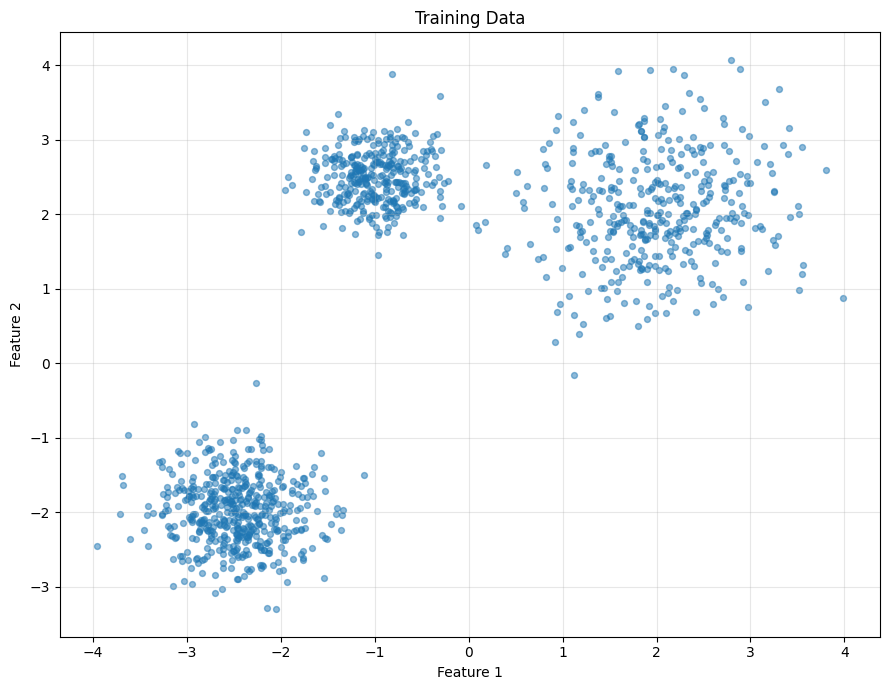

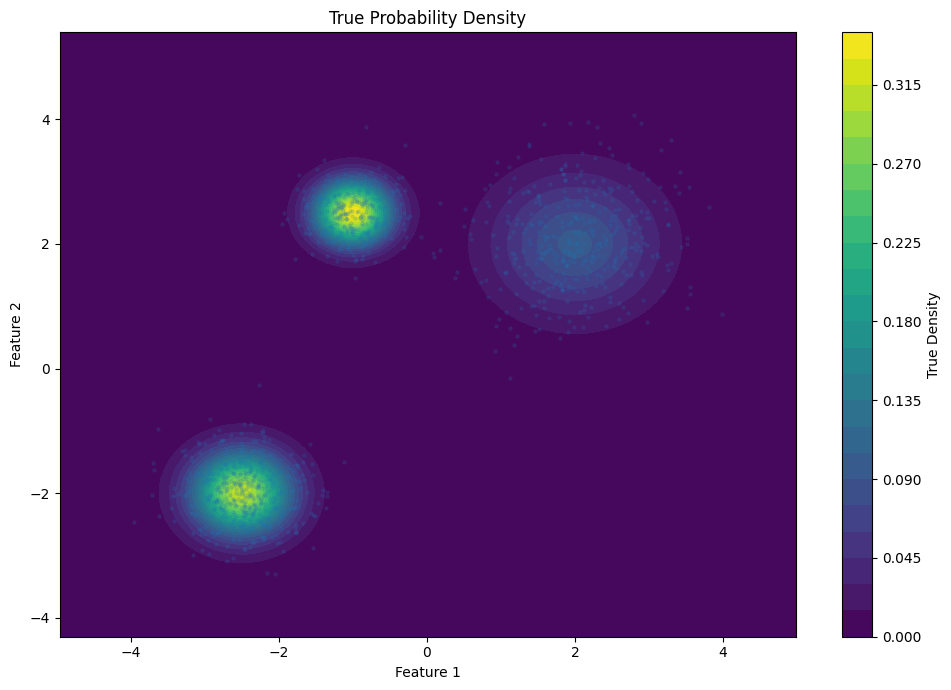

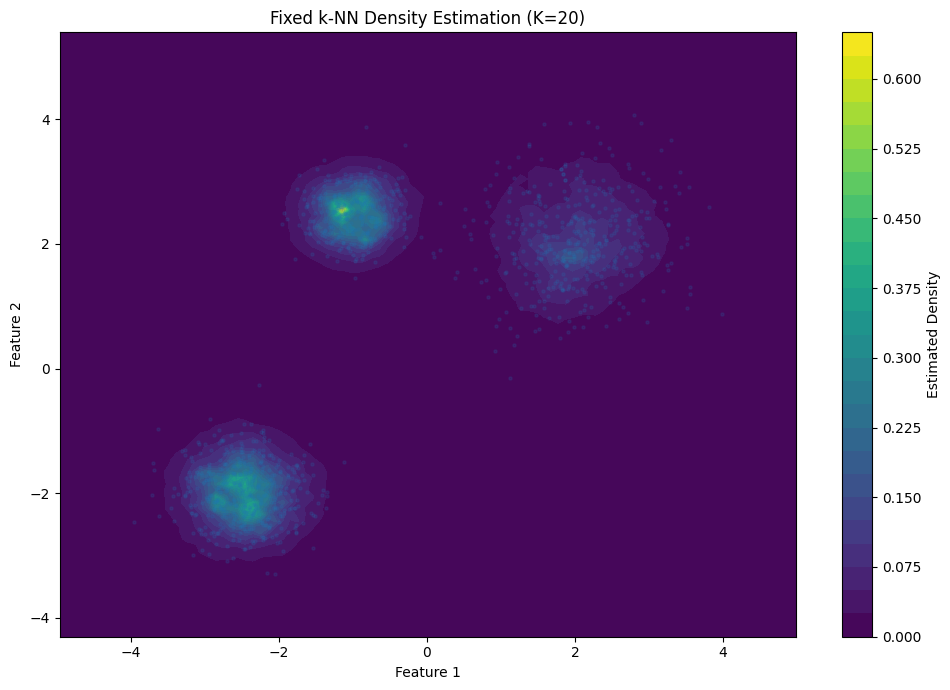

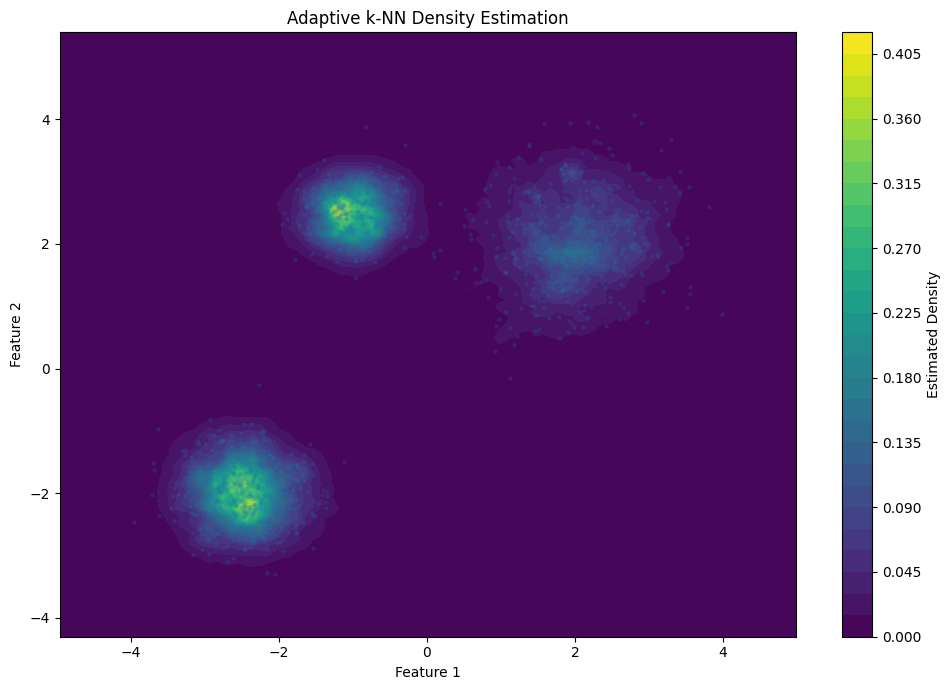

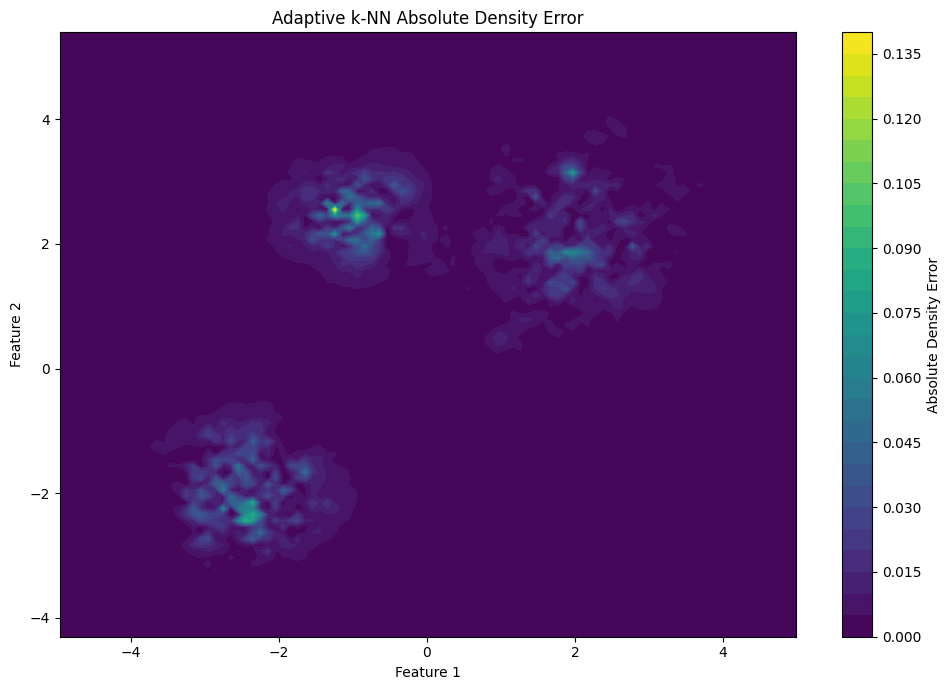

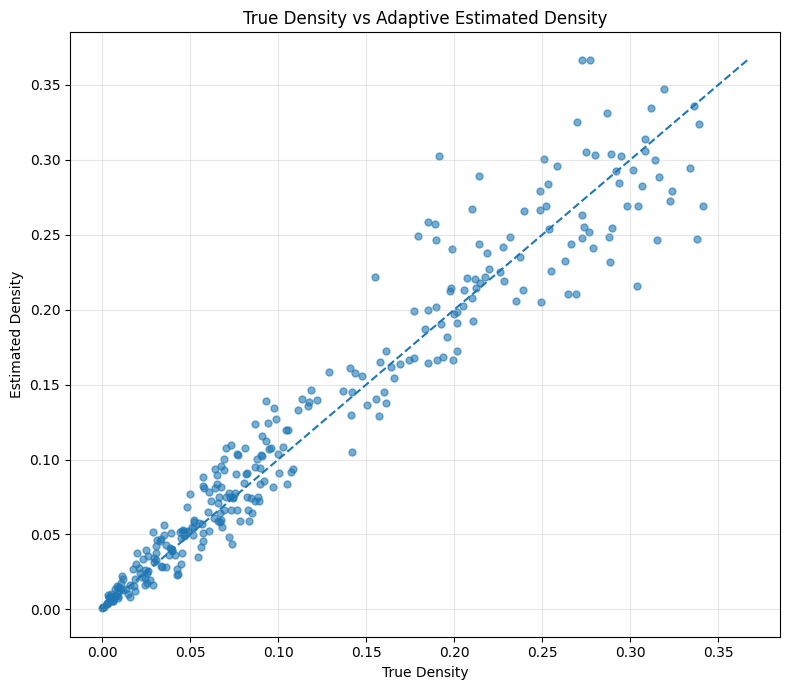

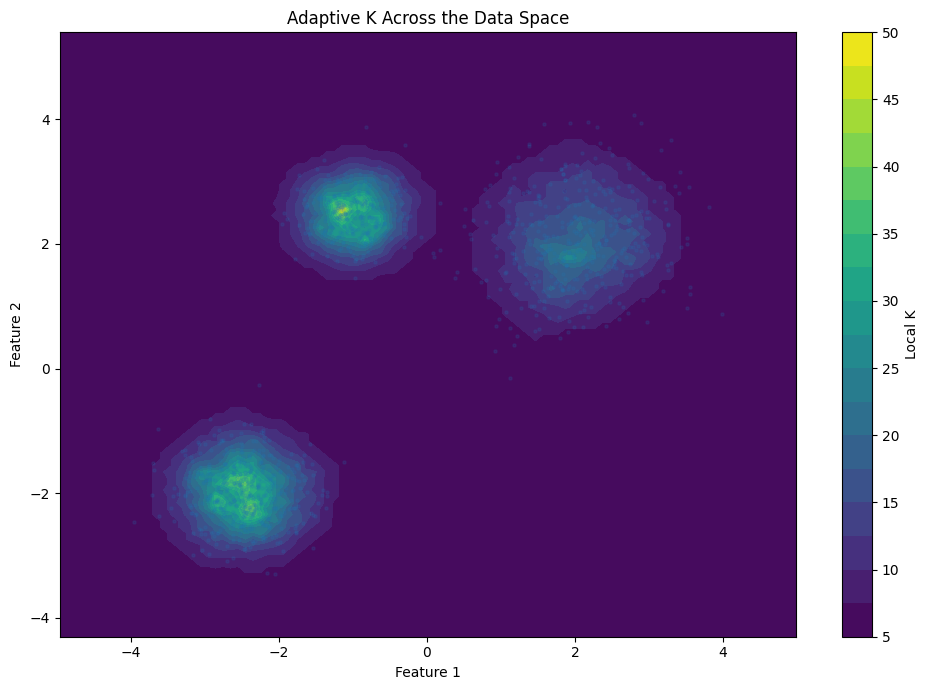

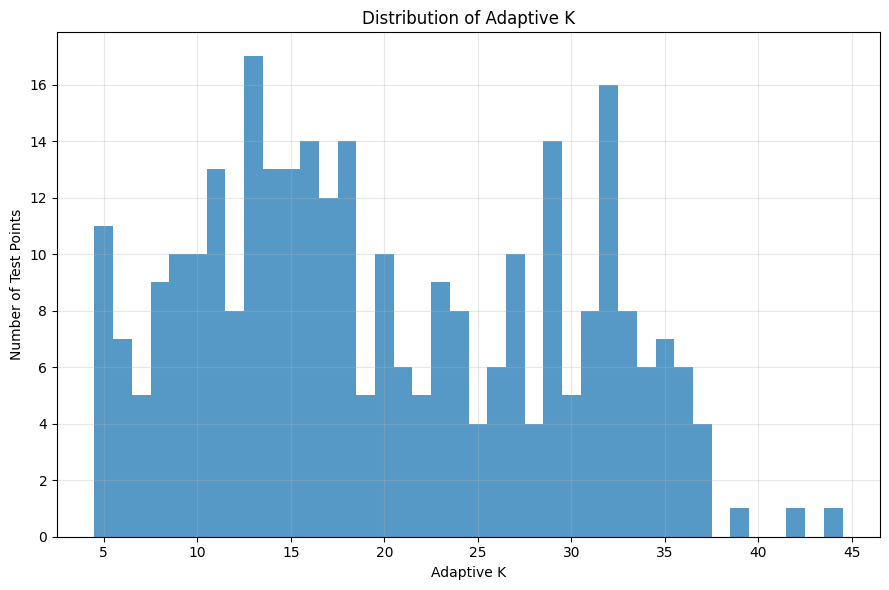

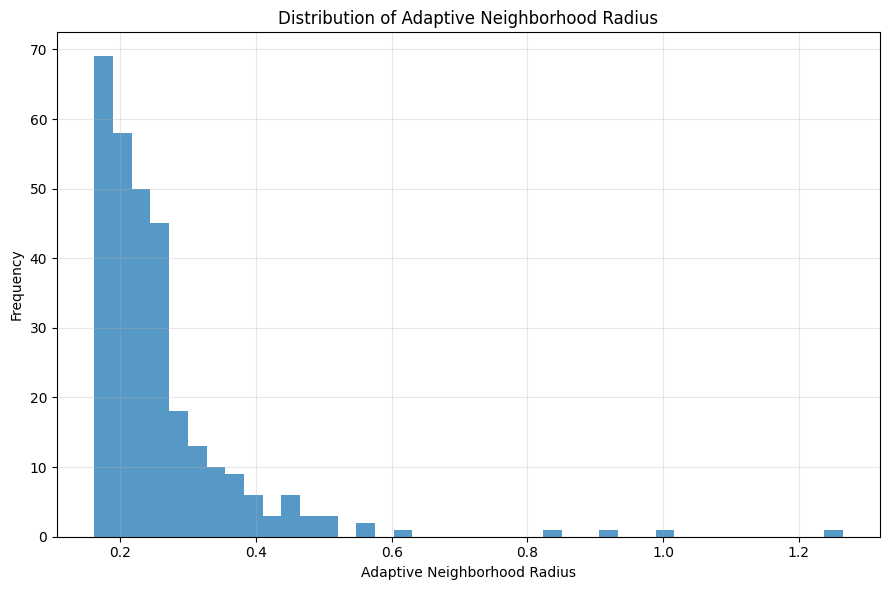

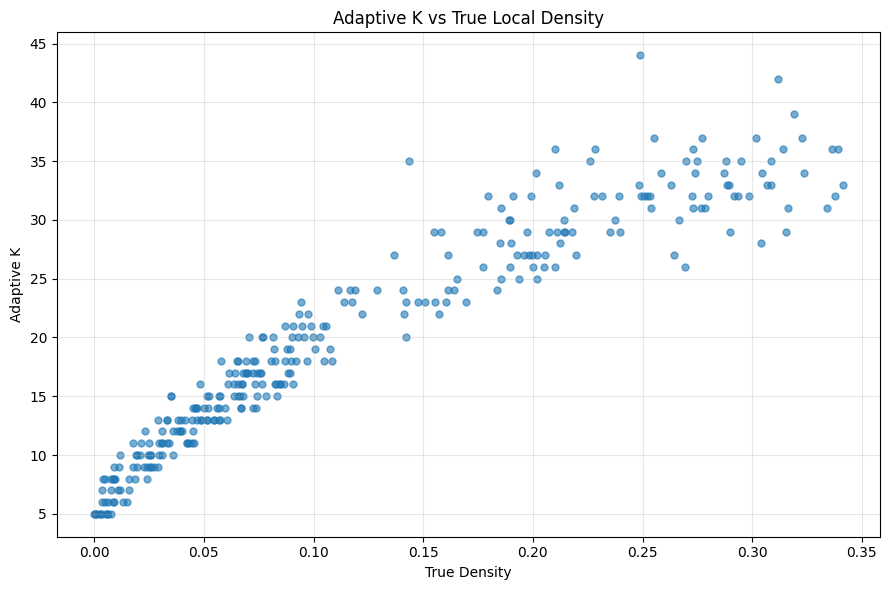



FIXED-K vs ADAPTIVE-K COMPARISON
K         MAE               MSE               RMSE              NLL               ISE               
----------------------------------------------------------------------------------------------------
5         0.05513379        0.01131106        0.10635347        2.45880360        0.0881499206      
10        0.03247233        0.00328814        0.05734230        2.48920077        0.0219645959      
15        0.02304409        0.00150739        0.03882506        2.50500863        0.0127750013      
20        0.02156396        0.00139187        0.03730780        2.49912817        0.0082022511      
30        0.01647231        0.00070554        0.02656193        2.50391356        0.0062193702      
40        0.01405010        0.00049154        0.02217076        2.49776138        0.0053403098      
50        0.01391506        0.00040796        0.02019791        2.48875619        0.0053766390      
60        0.01266372        0.00031956        0.01787633

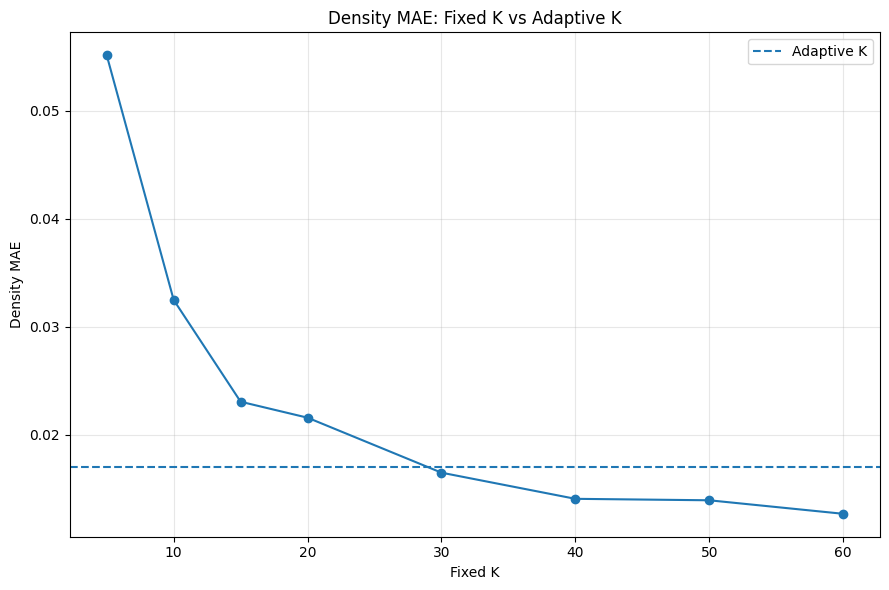

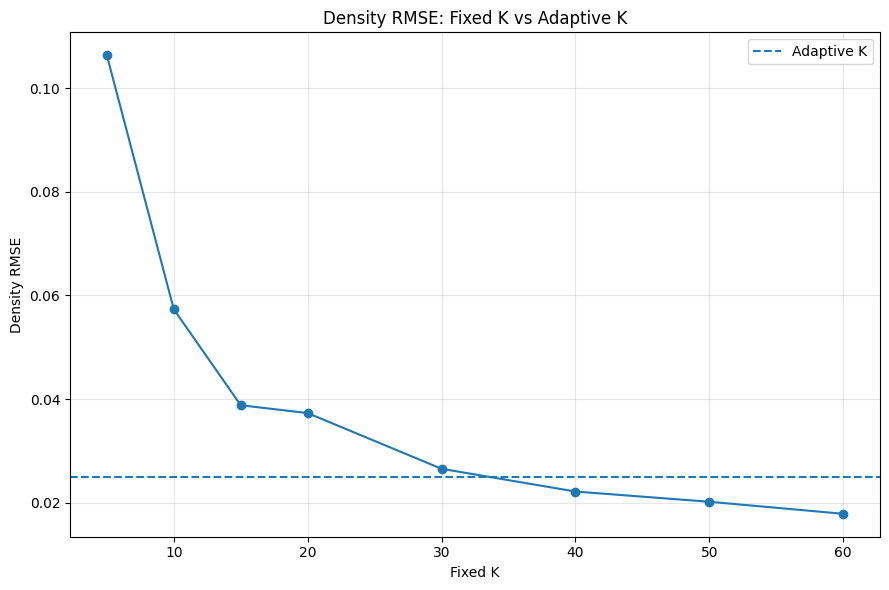

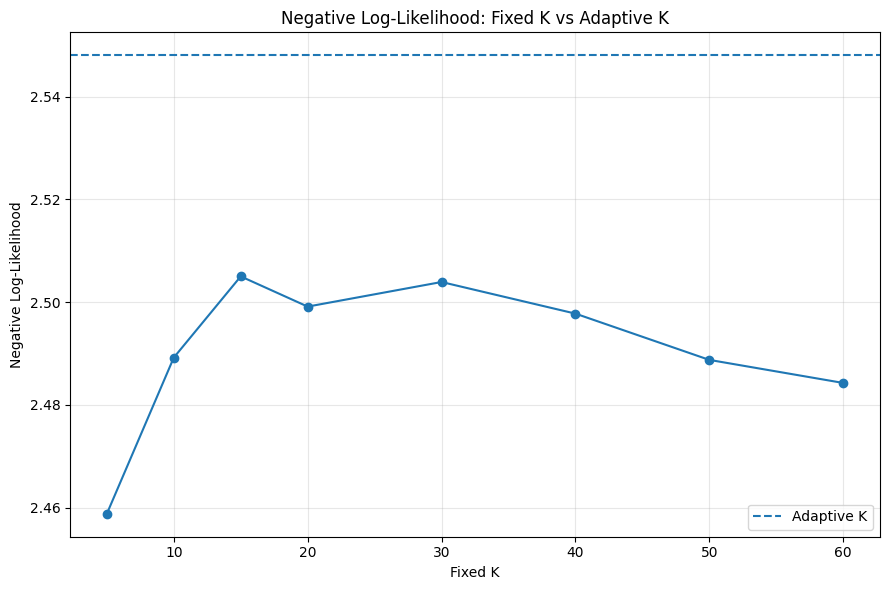

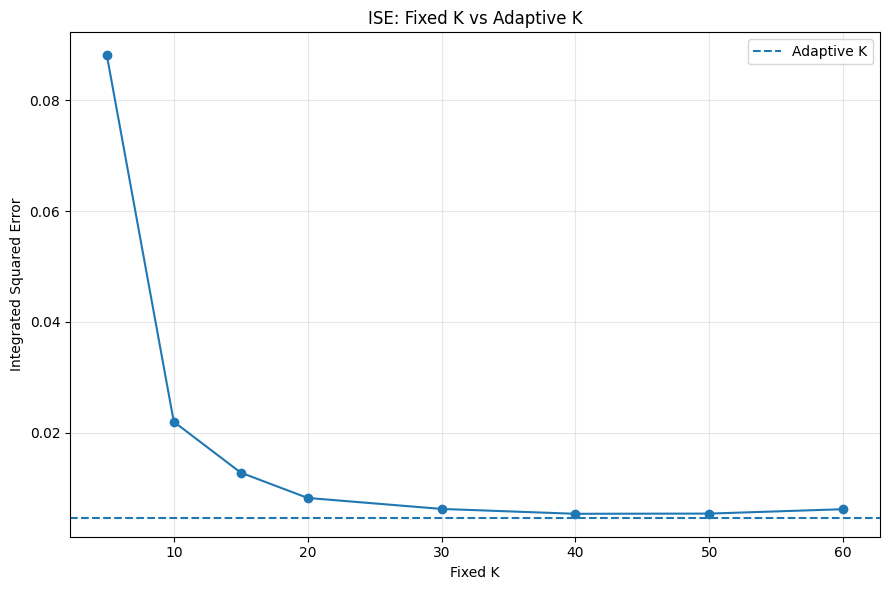



SINGLE QUERY POINT ANALYSIS
Query point       : [0. 0.]
True density      : 7.695911285812984e-05
Adaptive K        : 5
Adaptive radius   : 1.2517247155789704
Estimated density : 0.0008464888276853511
Absolute error    : 0.0007695297148272212

Nearest Neighbors
--------------------------------------------------------------------------------
Neighbor    Index       Distance          
--------------------------------------------------------------------------------
1           914         0.95827829        
2           773         1.13310321        
3           254         1.15676011        
4           548         1.23417119        
5           94          1.25172472        


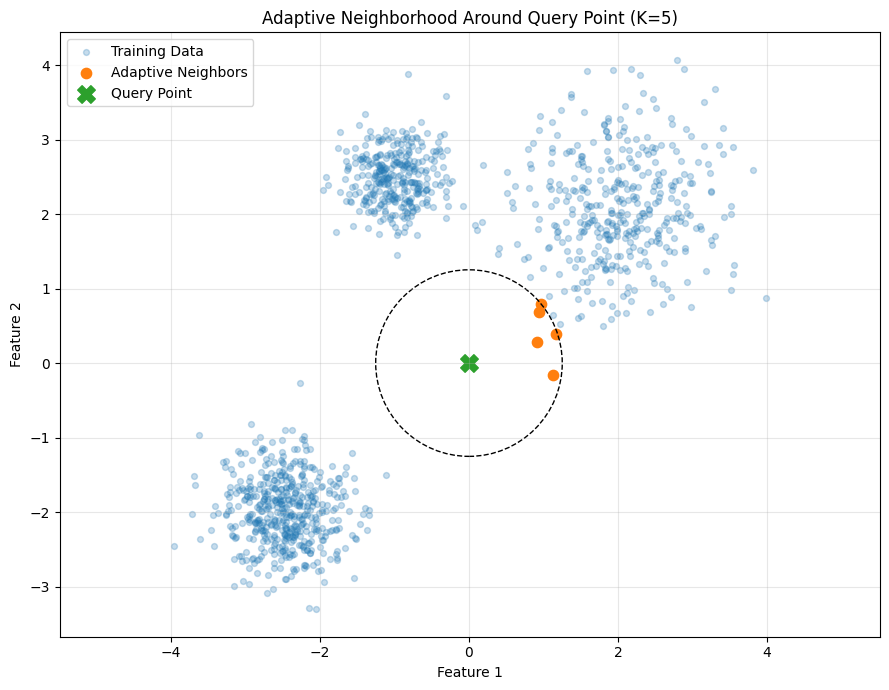



FINAL ADAPTIVE k-NN DENSITY ESTIMATION SUMMARY
Training samples              : 1200
Testing samples               : 300
Number of dimensions          : 2
Pilot K                       : 20
Minimum adaptive K            : 5
Maximum adaptive K            : 60
Mean adaptive K               : 19.9900
Median adaptive K             : 18.0000
Adaptive Density MAE          : 0.0170147710
Adaptive Density MSE          : 0.0006222741
Adaptive Density RMSE         : 0.0249454215
Adaptive Relative Error       : 0.2510457780
Adaptive Negative Log-Lik.    : 2.5480423325
Adaptive Integrated Sq. Error : 0.0045319150


In [10]:
# ============================================================
# ADAPTIVE k-NN DENSITY ESTIMATION
# ============================================================
# FROM SCRATCH
# NO SCIKIT-LEARN
# NUMPY + MATPLOTLIB ONLY
#
# Adaptive idea:
#
# 1. Estimate pilot density using a fixed K0.
# 2. Determine local K(x) from the pilot density.
# 3. Dense regions  -> larger K
# 4. Sparse regions -> smaller K
# 5. Estimate final density using the local K(x)
#
# Evaluation:
#   - MAE
#   - MSE
#   - RMSE
#   - Relative Error
#   - Negative Log-Likelihood
#   - Integrated Squared Error
#   - Fixed-K vs Adaptive-K
#
# Visualization:
#   - Original data
#   - True density
#   - Fixed-K density
#   - Adaptive-K density
#   - Density error
#   - True vs estimated density
#   - Adaptive K map
#   - K distribution
#   - Radius distribution
# ============================================================


import numpy as np
import matplotlib.pyplot as plt
import math


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

np.random.seed(42)


# ============================================================
# 2. GENERATE SYNTHETIC DATA
# ============================================================
#
# We generate a mixture of 3 Gaussian distributions.
#
# This is useful because we know the TRUE probability density.
# Therefore, we can properly evaluate our density estimator.
# ============================================================


n_samples = 1500


# ------------------------------------------------------------
# Cluster sizes
# ------------------------------------------------------------

n1 = 600
n2 = 500
n3 = 400


# ------------------------------------------------------------
# Cluster 1
# Dense cluster
# ------------------------------------------------------------

cluster1 = np.random.normal(
    loc=[-2.5, -2.0],
    scale=[0.45, 0.45],
    size=(n1, 2)
)


# ------------------------------------------------------------
# Cluster 2
# Medium-density cluster
# ------------------------------------------------------------

cluster2 = np.random.normal(
    loc=[2.0, 2.0],
    scale=[0.75, 0.75],
    size=(n2, 2)
)


# ------------------------------------------------------------
# Cluster 3
# Another dense cluster
# ------------------------------------------------------------

cluster3 = np.random.normal(
    loc=[-1.0, 2.5],
    scale=[0.35, 0.35],
    size=(n3, 2)
)


# ------------------------------------------------------------
# Combine data
# ------------------------------------------------------------

X = np.vstack([
    cluster1,
    cluster2,
    cluster3
])


print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("Total samples :", X.shape[0])
print("Features      :", X.shape[1])

print("=" * 70)


# ============================================================
# 3. TRAIN-TEST SPLIT FROM SCRATCH
# ============================================================

indices = np.random.permutation(
    len(X)
)


train_ratio = 0.80

train_size = int(
    train_ratio * len(X)
)


train_indices = indices[:train_size]

test_indices = indices[train_size:]


X_train = X[train_indices]

X_test = X[test_indices]


print("\nTraining samples :", len(X_train))
print("Testing samples  :", len(X_test))


# ============================================================
# 4. TRUE GAUSSIAN PDF
# ============================================================
#
# For a 2-D Gaussian:
#
# p(x) =
# 1 / (2*pi*sigma_x*sigma_y)
# *
# exp(
#     -0.5 *
#     [
#       ((x-mu_x)/sigma_x)^2
#       +
#       ((y-mu_y)/sigma_y)^2
#     ]
# )
#
# We use this to calculate the TRUE density.
# ============================================================


def gaussian_pdf(
    X,
    mean,
    std
):

    X = np.asarray(
        X,
        dtype=float
    )

    mean = np.asarray(
        mean,
        dtype=float
    )

    std = np.asarray(
        std,
        dtype=float
    )


    coefficient = (
        1.0
        /
        (
            2.0
            * np.pi
            * std[0]
            * std[1]
        )
    )


    exponent = -0.5 * (
        (
            (X[:, 0] - mean[0])
            / std[0]
        ) ** 2
        +
        (
            (X[:, 1] - mean[1])
            / std[1]
        ) ** 2
    )


    return (
        coefficient
        * np.exp(exponent)
    )


# ============================================================
# 5. TRUE MIXTURE DENSITY
# ============================================================
#
# p(x) =
# w1*p1(x)
# +
# w2*p2(x)
# +
# w3*p3(x)
# ============================================================


weight1 = n1 / n_samples
weight2 = n2 / n_samples
weight3 = n3 / n_samples


def true_density(X):

    p1 = gaussian_pdf(
        X,
        mean=[-2.5, -2.0],
        std=[0.45, 0.45]
    )


    p2 = gaussian_pdf(
        X,
        mean=[2.0, 2.0],
        std=[0.75, 0.75]
    )


    p3 = gaussian_pdf(
        X,
        mean=[-1.0, 2.5],
        std=[0.35, 0.35]
    )


    density = (
        weight1 * p1
        +
        weight2 * p2
        +
        weight3 * p3
    )


    return density


# ============================================================
# 6. ADAPTIVE k-NN DENSITY ESTIMATOR
# ============================================================


class AdaptiveKNNDensityEstimator:

    def __init__(
        self,
        pilot_k=20,
        min_k=5,
        max_k=60,
        adaptation_strength=0.5,
        epsilon=1e-12
    ):

        self.pilot_k = pilot_k

        self.min_k = min_k

        self.max_k = max_k

        self.adaptation_strength = (
            adaptation_strength
        )

        self.epsilon = epsilon

        self.X_train = None

        self.n_samples = None

        self.n_features = None

        self.pilot_densities = None

        self.reference_density = None


    # ========================================================
    # FIT
    # ========================================================

    def fit(self, X):

        X = np.asarray(
            X,
            dtype=float
        )


        if X.ndim != 2:

            raise ValueError(
                "X must be a 2-D array."
            )


        if self.pilot_k <= 0:

            raise ValueError(
                "pilot_k must be greater than 0."
            )


        if self.min_k <= 0:

            raise ValueError(
                "min_k must be greater than 0."
            )


        if self.max_k < self.min_k:

            raise ValueError(
                "max_k must be >= min_k."
            )


        if self.max_k >= len(X):

            raise ValueError(
                "max_k must be smaller than "
                "number of training samples."
            )


        self.X_train = X

        self.n_samples = X.shape[0]

        self.n_features = X.shape[1]


        # ----------------------------------------------------
        # Calculate pilot density at training samples
        # ----------------------------------------------------

        self.pilot_densities = (
            self._fixed_knn_density(
                X,
                self.pilot_k
            )
        )


        # ----------------------------------------------------
        # Reference density
        # ----------------------------------------------------

        self.reference_density = (
            np.median(
                self.pilot_densities
            )
        )


        return self


    # ========================================================
    # DISTANCE MATRIX
    # ========================================================

    def _distance_matrix(self, X):

        X = np.asarray(
            X,
            dtype=float
        )


        differences = (
            X[:, None, :]
            -
            self.X_train[None, :, :]
        )


        distances = np.sqrt(
            np.sum(
                differences ** 2,
                axis=2
            )
        )


        return distances


    # ========================================================
    # HYPERSPHERE VOLUME
    # ========================================================

    def _hypersphere_volume(
        self,
        radius
    ):

        d = self.n_features


        unit_volume = (
            np.pi ** (d / 2)
            /
            math.gamma(
                d / 2 + 1
            )
        )


        volume = (
            unit_volume
            * radius ** d
        )


        return volume


    # ========================================================
    # FIXED-K DENSITY
    # ========================================================

    def _fixed_knn_density(
        self,
        X,
        k
    ):

        distances = (
            self._distance_matrix(
                X
            )
        )


        densities = []


        for row in distances:

            sorted_distances = np.sort(
                row
            )


            radius = sorted_distances[
                k - 1
            ]


            radius = max(
                radius,
                self.epsilon
            )


            volume = (
                self._hypersphere_volume(
                    radius
                )
            )


            volume = max(
                volume,
                self.epsilon
            )


            density = (
                k
                /
                (
                    self.n_samples
                    * volume
                )
            )


            densities.append(
                density
            )


        return np.asarray(
            densities
        )


    # ========================================================
    # ADAPTIVE K CALCULATION
    # ========================================================
    #
    # k(x) =
    #
    # k0 *
    #
    # [p_pilot(x) / p_reference]
    # ^ adaptation_strength
    #
    # Dense region:
    #
    # p(x) > reference
    #
    # -> larger K
    #
    # Sparse region:
    #
    # p(x) < reference
    #
    # -> smaller K
    # ========================================================

    def _calculate_adaptive_k(
        self,
        pilot_density
    ):

        ratio = (
            pilot_density
            /
            max(
                self.reference_density,
                self.epsilon
            )
        )


        adaptive_k = (
            self.pilot_k
            *
            ratio
            **
            self.adaptation_strength
        )


        adaptive_k = np.clip(
            adaptive_k,
            self.min_k,
            self.max_k
        )


        adaptive_k = np.rint(
            adaptive_k
        ).astype(int)


        return adaptive_k


    # ========================================================
    # PREDICT DENSITY
    # ========================================================

    def predict_density(
        self,
        X
    ):

        X = np.asarray(
            X,
            dtype=float
        )


        distances = (
            self._distance_matrix(
                X
            )
        )


        # ----------------------------------------------------
        # Pilot density
        # ----------------------------------------------------

        pilot_density = (
            self._fixed_knn_density(
                X,
                self.pilot_k
            )
        )


        # ----------------------------------------------------
        # Calculate local K
        # ----------------------------------------------------

        adaptive_k = (
            self._calculate_adaptive_k(
                pilot_density
            )
        )


        final_densities = []

        radii = []


        # ----------------------------------------------------
        # Calculate density using local K
        # ----------------------------------------------------

        for i, row in enumerate(
            distances
        ):

            k_local = adaptive_k[i]


            sorted_distances = np.sort(
                row
            )


            radius = sorted_distances[
                k_local - 1
            ]


            radius = max(
                radius,
                self.epsilon
            )


            volume = (
                self._hypersphere_volume(
                    radius
                )
            )


            volume = max(
                volume,
                self.epsilon
            )


            density = (
                k_local
                /
                (
                    self.n_samples
                    * volume
                )
            )


            final_densities.append(
                density
            )


            radii.append(
                radius
            )


        return (
            np.asarray(
                final_densities
            ),
            adaptive_k,
            np.asarray(radii)
        )


    # ========================================================
    # GET NEIGHBOR INFORMATION
    # ========================================================

    def get_neighbors(
        self,
        x
    ):

        x = np.asarray(
            x,
            dtype=float
        ).reshape(1, -1)


        distances = (
            self._distance_matrix(
                x
            )[0]
        )


        sorted_indices = np.argsort(
            distances
        )


        pilot_radius = np.sort(
            distances
        )[self.pilot_k - 1]


        pilot_volume = (
            self._hypersphere_volume(
                max(
                    pilot_radius,
                    self.epsilon
                )
            )
        )


        pilot_density = (
            self.pilot_k
            /
            (
                self.n_samples
                *
                max(
                    pilot_volume,
                    self.epsilon
                )
            )
        )


        adaptive_k = (
            self._calculate_adaptive_k(
                np.array([
                    pilot_density
                ])
            )[0]
        )


        neighbor_indices = (
            sorted_indices[
                :adaptive_k
            ]
        )


        neighbor_distances = (
            distances[
                neighbor_indices
            ]
        )


        radius = neighbor_distances[-1]


        volume = (
            self._hypersphere_volume(
                max(
                    radius,
                    self.epsilon
                )
            )
        )


        density = (
            adaptive_k
            /
            (
                self.n_samples
                *
                max(
                    volume,
                    self.epsilon
                )
            )
        )


        return (
            neighbor_indices,
            neighbor_distances,
            adaptive_k,
            radius,
            density
        )


# ============================================================
# 7. CREATE ADAPTIVE MODEL
# ============================================================


adaptive_model = (
    AdaptiveKNNDensityEstimator(
        pilot_k=20,
        min_k=5,
        max_k=60,
        adaptation_strength=0.5
    )
)


# ============================================================
# 8. FIT MODEL
# ============================================================


adaptive_model.fit(
    X_train
)


# ============================================================
# 9. ADAPTIVE DENSITY PREDICTION
# ============================================================


adaptive_density, adaptive_k, adaptive_radius = (
    adaptive_model.predict_density(
        X_test
    )
)


# ============================================================
# 10. FIXED-K BASELINE
# ============================================================


fixed_k = 20


fixed_model = (
    AdaptiveKNNDensityEstimator(
        pilot_k=fixed_k,
        min_k=fixed_k,
        max_k=fixed_k
    )
)


fixed_model.fit(
    X_train
)


fixed_density, _, fixed_radius = (
    fixed_model.predict_density(
        X_test
    )
)


# ============================================================
# 11. TRUE TEST DENSITY
# ============================================================


true_test_density = (
    true_density(
        X_test
    )
)


# ============================================================
# 12. EVALUATION METRICS
# ============================================================


def density_mae(
    true_density_values,
    estimated_density_values
):

    return np.mean(
        np.abs(
            true_density_values
            -
            estimated_density_values
        )
    )


def density_mse(
    true_density_values,
    estimated_density_values
):

    return np.mean(
        (
            true_density_values
            -
            estimated_density_values
        ) ** 2
    )


def density_rmse(
    true_density_values,
    estimated_density_values
):

    return np.sqrt(
        density_mse(
            true_density_values,
            estimated_density_values
        )
    )


def relative_error(
    true_density_values,
    estimated_density_values
):

    denominator = np.maximum(
        np.abs(
            true_density_values
        ),
        1e-12
    )


    return np.mean(
        np.abs(
            (
                estimated_density_values
                -
                true_density_values
            )
            /
            denominator
        )
    )


def negative_log_likelihood(
    true_samples,
    estimated_density_values
):

    estimated_density_values = np.maximum(
        estimated_density_values,
        1e-12
    )


    return -np.mean(
        np.log(
            estimated_density_values
        )
    )


# ============================================================
# 13. TEST-POINT EVALUATION
# ============================================================


adaptive_mae = density_mae(
    true_test_density,
    adaptive_density
)


adaptive_mse = density_mse(
    true_test_density,
    adaptive_density
)


adaptive_rmse = density_rmse(
    true_test_density,
    adaptive_density
)


adaptive_relative_error = relative_error(
    true_test_density,
    adaptive_density
)


adaptive_nll = negative_log_likelihood(
    X_test,
    adaptive_density
)


fixed_mae = density_mae(
    true_test_density,
    fixed_density
)


fixed_mse = density_mse(
    true_test_density,
    fixed_density
)


fixed_rmse = density_rmse(
    true_test_density,
    fixed_density
)


fixed_relative_error = relative_error(
    true_test_density,
    fixed_density
)


fixed_nll = negative_log_likelihood(
    X_test,
    fixed_density
)


# ============================================================
# 14. PRINT EVALUATION
# ============================================================


print("\n")
print("=" * 90)
print("ADAPTIVE k-NN DENSITY ESTIMATION - EVALUATION")
print("=" * 90)


print(
    f"{'Metric':<30}"
    f"{'Fixed K':<25}"
    f"{'Adaptive K':<25}"
)


print("-" * 90)


print(
    f"{'MAE':<30}"
    f"{fixed_mae:<25.8f}"
    f"{adaptive_mae:<25.8f}"
)


print(
    f"{'MSE':<30}"
    f"{fixed_mse:<25.8f}"
    f"{adaptive_mse:<25.8f}"
)


print(
    f"{'RMSE':<30}"
    f"{fixed_rmse:<25.8f}"
    f"{adaptive_rmse:<25.8f}"
)


print(
    f"{'Relative Error':<30}"
    f"{fixed_relative_error:<25.8f}"
    f"{adaptive_relative_error:<25.8f}"
)


print(
    f"{'Negative Log-Likelihood':<30}"
    f"{fixed_nll:<25.8f}"
    f"{adaptive_nll:<25.8f}"
)


print("=" * 90)


# ============================================================
# 15. ADAPTIVE K STATISTICS
# ============================================================


print("\n")
print("=" * 70)
print("ADAPTIVE K STATISTICS")
print("=" * 70)


print(
    "Minimum K :",
    np.min(adaptive_k)
)


print(
    "Maximum K :",
    np.max(adaptive_k)
)


print(
    "Mean K    :",
    np.mean(adaptive_k)
)


print(
    "Median K  :",
    np.median(adaptive_k)
)


print(
    "Std K     :",
    np.std(adaptive_k)
)


print("=" * 70)


# ============================================================
# 16. CREATE DENSITY GRID
# ============================================================


x_min = X[:, 0].min() - 1
x_max = X[:, 0].max() + 1

y_min = X[:, 1].min() - 1
y_max = X[:, 1].max() + 1


grid_size = 100


x_grid = np.linspace(
    x_min,
    x_max,
    grid_size
)


y_grid = np.linspace(
    y_min,
    y_max,
    grid_size
)


xx, yy = np.meshgrid(
    x_grid,
    y_grid
)


grid_points = np.column_stack([
    xx.ravel(),
    yy.ravel()
])


# ============================================================
# 17. GRID DENSITY ESTIMATION
# ============================================================


adaptive_grid_density, adaptive_grid_k, adaptive_grid_radius = (
    adaptive_model.predict_density(
        grid_points
    )
)


fixed_grid_density, _, fixed_grid_radius = (
    fixed_model.predict_density(
        grid_points
    )
)


true_grid_density = (
    true_density(
        grid_points
    )
)


adaptive_grid_surface = (
    adaptive_grid_density.reshape(
        xx.shape
    )
)


fixed_grid_surface = (
    fixed_grid_density.reshape(
        xx.shape
    )
)


true_grid_surface = (
    true_grid_density.reshape(
        xx.shape
    )
)


adaptive_k_surface = (
    adaptive_grid_k.reshape(
        xx.shape
    )
)


adaptive_error_surface = (
    np.abs(
        adaptive_grid_surface
        -
        true_grid_surface
    )
)


# ============================================================
# 18. INTEGRATED SQUARED ERROR
# ============================================================
#
# ISE =
#
# integral[
#     (estimated_density - true_density)^2
# ] dx
#
# We approximate the integral numerically.
# ============================================================


dx = (
    x_grid[1]
    -
    x_grid[0]
)


dy = (
    y_grid[1]
    -
    y_grid[0]
)


adaptive_ise = np.sum(
    (
        adaptive_grid_surface
        -
        true_grid_surface
    ) ** 2
) * dx * dy


fixed_ise = np.sum(
    (
        fixed_grid_surface
        -
        true_grid_surface
    ) ** 2
) * dx * dy


# ============================================================
# 19. PRINT ISE
# ============================================================


print("\n")
print("=" * 70)
print("INTEGRATED SQUARED ERROR")
print("=" * 70)


print(
    f"Fixed K ISE     : {fixed_ise:.10f}"
)


print(
    f"Adaptive K ISE  : {adaptive_ise:.10f}"
)


print("=" * 70)


# ============================================================
# 20. PLOT 1 - ORIGINAL DATA
# ============================================================


plt.figure(
    figsize=(9, 7)
)


plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    s=18,
    alpha=0.5
)


plt.xlabel(
    "Feature 1"
)


plt.ylabel(
    "Feature 2"
)


plt.title(
    "Training Data"
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.show()


# ============================================================
# 21. PLOT 2 - TRUE DENSITY
# ============================================================


plt.figure(
    figsize=(10, 7)
)


contour = plt.contourf(
    xx,
    yy,
    true_grid_surface,
    levels=30
)


plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    s=5,
    alpha=0.15
)


plt.xlabel(
    "Feature 1"
)


plt.ylabel(
    "Feature 2"
)


plt.title(
    "True Probability Density"
)


plt.colorbar(
    contour,
    label="True Density"
)


plt.tight_layout()


plt.show()


# ============================================================
# 22. PLOT 3 - FIXED-K DENSITY
# ============================================================


plt.figure(
    figsize=(10, 7)
)


contour = plt.contourf(
    xx,
    yy,
    fixed_grid_surface,
    levels=30
)


plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    s=5,
    alpha=0.15
)


plt.xlabel(
    "Feature 1"
)


plt.ylabel(
    "Feature 2"
)


plt.title(
    f"Fixed k-NN Density Estimation (K={fixed_k})"
)


plt.colorbar(
    contour,
    label="Estimated Density"
)


plt.tight_layout()


plt.show()


# ============================================================
# 23. PLOT 4 - ADAPTIVE-K DENSITY
# ============================================================


plt.figure(
    figsize=(10, 7)
)


contour = plt.contourf(
    xx,
    yy,
    adaptive_grid_surface,
    levels=30
)


plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    s=5,
    alpha=0.15
)


plt.xlabel(
    "Feature 1"
)


plt.ylabel(
    "Feature 2"
)


plt.title(
    "Adaptive k-NN Density Estimation"
)


plt.colorbar(
    contour,
    label="Estimated Density"
)


plt.tight_layout()


plt.show()


# ============================================================
# 24. PLOT 5 - DENSITY ERROR
# ============================================================


plt.figure(
    figsize=(10, 7)
)


contour = plt.contourf(
    xx,
    yy,
    adaptive_error_surface,
    levels=30
)


plt.xlabel(
    "Feature 1"
)


plt.ylabel(
    "Feature 2"
)


plt.title(
    "Adaptive k-NN Absolute Density Error"
)


plt.colorbar(
    contour,
    label="Absolute Density Error"
)


plt.tight_layout()


plt.show()


# ============================================================
# 25. PLOT 6 - TRUE VS ESTIMATED DENSITY
# ============================================================


plt.figure(
    figsize=(8, 7)
)


plt.scatter(
    true_test_density,
    adaptive_density,
    alpha=0.6,
    s=25
)


min_density = min(
    np.min(true_test_density),
    np.min(adaptive_density)
)


max_density = max(
    np.max(true_test_density),
    np.max(adaptive_density)
)


plt.plot(
    [min_density, max_density],
    [min_density, max_density],
    linestyle="--"
)


plt.xlabel(
    "True Density"
)


plt.ylabel(
    "Estimated Density"
)


plt.title(
    "True Density vs Adaptive Estimated Density"
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.show()


# ============================================================
# 26. PLOT 7 - ADAPTIVE K MAP
# ============================================================


plt.figure(
    figsize=(10, 7)
)


contour = plt.contourf(
    xx,
    yy,
    adaptive_k_surface,
    levels=20
)


plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    s=5,
    alpha=0.15
)


plt.xlabel(
    "Feature 1"
)


plt.ylabel(
    "Feature 2"
)


plt.title(
    "Adaptive K Across the Data Space"
)


plt.colorbar(
    contour,
    label="Local K"
)


plt.tight_layout()


plt.show()


# ============================================================
# 27. PLOT 8 - ADAPTIVE K DISTRIBUTION
# ============================================================


plt.figure(
    figsize=(9, 6)
)


plt.hist(
    adaptive_k,
    bins=np.arange(
        adaptive_k.min() - 0.5,
        adaptive_k.max() + 1.5,
        1
    ),
    alpha=0.75
)


plt.xlabel(
    "Adaptive K"
)


plt.ylabel(
    "Number of Test Points"
)


plt.title(
    "Distribution of Adaptive K"
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.show()


# ============================================================
# 28. PLOT 9 - RADIUS DISTRIBUTION
# ============================================================


plt.figure(
    figsize=(9, 6)
)


plt.hist(
    adaptive_radius,
    bins=40,
    alpha=0.75
)


plt.xlabel(
    "Adaptive Neighborhood Radius"
)


plt.ylabel(
    "Frequency"
)


plt.title(
    "Distribution of Adaptive Neighborhood Radius"
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.show()


# ============================================================
# 29. PLOT 10 - ADAPTIVE K VS TRUE DENSITY
# ============================================================


plt.figure(
    figsize=(9, 6)
)


plt.scatter(
    true_test_density,
    adaptive_k,
    alpha=0.6,
    s=25
)


plt.xlabel(
    "True Density"
)


plt.ylabel(
    "Adaptive K"
)


plt.title(
    "Adaptive K vs True Local Density"
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.show()


# ============================================================
# 30. COMPARE MULTIPLE FIXED K VALUES
# ============================================================


comparison_k_values = [
    5,
    10,
    15,
    20,
    30,
    40,
    50,
    60
]


comparison_mae = []
comparison_mse = []
comparison_rmse = []
comparison_nll = []
comparison_ise = []


for current_k in comparison_k_values:

    temp_model = (
        AdaptiveKNNDensityEstimator(
            pilot_k=current_k,
            min_k=current_k,
            max_k=current_k
        )
    )


    temp_model.fit(
        X_train
    )


    temp_density, _, _ = (
        temp_model.predict_density(
            X_test
        )
    )


    temp_grid_density, _, _ = (
        temp_model.predict_density(
            grid_points
        )
    )


    temp_grid_surface = (
        temp_grid_density.reshape(
            xx.shape
        )
    )


    comparison_mae.append(
        density_mae(
            true_test_density,
            temp_density
        )
    )


    comparison_mse.append(
        density_mse(
            true_test_density,
            temp_density
        )
    )


    comparison_rmse.append(
        density_rmse(
            true_test_density,
            temp_density
        )
    )


    comparison_nll.append(
        negative_log_likelihood(
            X_test,
            temp_density
        )
    )


    temp_ise = np.sum(
        (
            temp_grid_surface
            -
            true_grid_surface
        ) ** 2
    ) * dx * dy


    comparison_ise.append(
        temp_ise
    )


# ============================================================
# 31. PRINT K COMPARISON
# ============================================================


print("\n")
print("=" * 100)
print("FIXED-K vs ADAPTIVE-K COMPARISON")
print("=" * 100)


print(
    f"{'K':<10}"
    f"{'MAE':<18}"
    f"{'MSE':<18}"
    f"{'RMSE':<18}"
    f"{'NLL':<18}"
    f"{'ISE':<18}"
)


print("-" * 100)


for i, current_k in enumerate(
    comparison_k_values
):

    print(
        f"{current_k:<10}"
        f"{comparison_mae[i]:<18.8f}"
        f"{comparison_mse[i]:<18.8f}"
        f"{comparison_rmse[i]:<18.8f}"
        f"{comparison_nll[i]:<18.8f}"
        f"{comparison_ise[i]:<18.10f}"
    )


print("-" * 100)


print(
    f"{'Adaptive':<10}"
    f"{adaptive_mae:<18.8f}"
    f"{adaptive_mse:<18.8f}"
    f"{adaptive_rmse:<18.8f}"
    f"{adaptive_nll:<18.8f}"
    f"{adaptive_ise:<18.10f}"
)


print("=" * 100)


# ============================================================
# 32. PLOT 11 - MAE VS K
# ============================================================


plt.figure(
    figsize=(9, 6)
)


plt.plot(
    comparison_k_values,
    comparison_mae,
    marker="o"
)


plt.axhline(
    adaptive_mae,
    linestyle="--",
    label="Adaptive K"
)


plt.xlabel(
    "Fixed K"
)


plt.ylabel(
    "Density MAE"
)


plt.title(
    "Density MAE: Fixed K vs Adaptive K"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.show()


# ============================================================
# 33. PLOT 12 - RMSE VS K
# ============================================================


plt.figure(
    figsize=(9, 6)
)


plt.plot(
    comparison_k_values,
    comparison_rmse,
    marker="o"
)


plt.axhline(
    adaptive_rmse,
    linestyle="--",
    label="Adaptive K"
)


plt.xlabel(
    "Fixed K"
)


plt.ylabel(
    "Density RMSE"
)


plt.title(
    "Density RMSE: Fixed K vs Adaptive K"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.show()


# ============================================================
# 34. PLOT 13 - NLL VS K
# ============================================================


plt.figure(
    figsize=(9, 6)
)


plt.plot(
    comparison_k_values,
    comparison_nll,
    marker="o"
)


plt.axhline(
    adaptive_nll,
    linestyle="--",
    label="Adaptive K"
)


plt.xlabel(
    "Fixed K"
)


plt.ylabel(
    "Negative Log-Likelihood"
)


plt.title(
    "Negative Log-Likelihood: Fixed K vs Adaptive K"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.show()


# ============================================================
# 35. PLOT 14 - ISE VS K
# ============================================================


plt.figure(
    figsize=(9, 6)
)


plt.plot(
    comparison_k_values,
    comparison_ise,
    marker="o"
)


plt.axhline(
    adaptive_ise,
    linestyle="--",
    label="Adaptive K"
)


plt.xlabel(
    "Fixed K"
)


plt.ylabel(
    "Integrated Squared Error"


)


plt.title(
    "ISE: Fixed K vs Adaptive K"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.show()


# ============================================================
# 36. SINGLE QUERY POINT ANALYSIS
# ============================================================


query_point = np.array([
    0.0,
    0.0
])


(
    neighbor_indices,
    neighbor_distances,
    query_k,
    query_radius,
    query_density
) = adaptive_model.get_neighbors(
    query_point
)


query_true_density = (
    true_density(
        query_point.reshape(1, -1)
    )[0]
)


print("\n")
print("=" * 80)
print("SINGLE QUERY POINT ANALYSIS")
print("=" * 80)


print(
    "Query point       :",
    query_point
)


print(
    "True density      :",
    query_true_density
)


print(
    "Adaptive K        :",
    query_k
)


print(
    "Adaptive radius   :",
    query_radius
)


print(
    "Estimated density :",
    query_density
)


print(
    "Absolute error    :",
    abs(
        query_density
        -
        query_true_density
    )
)


print("\nNearest Neighbors")


print("-" * 80)


print(
    f"{'Neighbor':<12}"
    f"{'Index':<12}"
    f"{'Distance':<18}"
)


print("-" * 80)


for i, (
    index,
    distance
) in enumerate(
    zip(
        neighbor_indices,
        neighbor_distances
    )
):

    print(
        f"{i + 1:<12}"
        f"{index:<12}"
        f"{distance:<18.8f}"
    )


print("=" * 80)


# ============================================================
# 37. VISUALIZE QUERY POINT
# ============================================================


plt.figure(
    figsize=(9, 7)
)


plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    s=18,
    alpha=0.25,
    label="Training Data"
)


nearest_points = (
    X_train[
        neighbor_indices
    ]
)


plt.scatter(
    nearest_points[:, 0],
    nearest_points[:, 1],
    s=55,
    label="Adaptive Neighbors"
)


plt.scatter(
    query_point[0],
    query_point[1],
    s=160,
    marker="X",
    label="Query Point"
)


circle = plt.Circle(
    query_point,
    query_radius,
    fill=False,
    linestyle="--"
)


plt.gca().add_patch(
    circle
)


plt.xlabel(
    "Feature 1"
)


plt.ylabel(
    "Feature 2"
)


plt.title(
    f"Adaptive Neighborhood Around Query Point "
    f"(K={query_k})"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.axis(
    "equal"
)


plt.tight_layout()


plt.show()


# ============================================================
# 38. FINAL SUMMARY
# ============================================================


print("\n")
print("=" * 85)
print("FINAL ADAPTIVE k-NN DENSITY ESTIMATION SUMMARY")
print("=" * 85)


print(
    "Training samples              :",
    len(X_train)
)


print(
    "Testing samples               :",
    len(X_test)
)


print(
    "Number of dimensions          :",
    X_train.shape[1]
)


print(
    "Pilot K                       :",
    adaptive_model.pilot_k
)


print(
    "Minimum adaptive K            :",
    adaptive_model.min_k
)


print(
    "Maximum adaptive K            :",
    adaptive_model.max_k
)


print(
    "Mean adaptive K               :",
    f"{np.mean(adaptive_k):.4f}"
)


print(
    "Median adaptive K             :",
    f"{np.median(adaptive_k):.4f}"
)


print(
    "Adaptive Density MAE          :",
    f"{adaptive_mae:.10f}"
)


print(
    "Adaptive Density MSE          :",
    f"{adaptive_mse:.10f}"
)


print(
    "Adaptive Density RMSE         :",
    f"{adaptive_rmse:.10f}"
)


print(
    "Adaptive Relative Error       :",
    f"{adaptive_relative_error:.10f}"
)


print(
    "Adaptive Negative Log-Lik.    :",
    f"{adaptive_nll:.10f}"
)


print(
    "Adaptive Integrated Sq. Error :",
    f"{adaptive_ise:.10f}"
)


print("=" * 85)

MISSING VALUE STATISTICS
Number of samples : 600
Number of features: 4
Total values      : 2400
Missing values    : 487
Missing percentage: 20.29 %

Missing values per feature:
Feature 1   : 111 (18.50%)
Feature 2   : 128 (21.33%)
Feature 3   : 120 (20.00%)
Feature 4   : 128 (21.33%)


KNN IMPUTATION EVALUATION
K                   : 5
Weighting           : distance
Missing test values : 127
----------------------------------------------------------------------
MAE                 : 12.525238
MSE                 : 252.988067
RMSE                : 15.905599
R²                  : 0.940465
MAPE                : 16.1032%


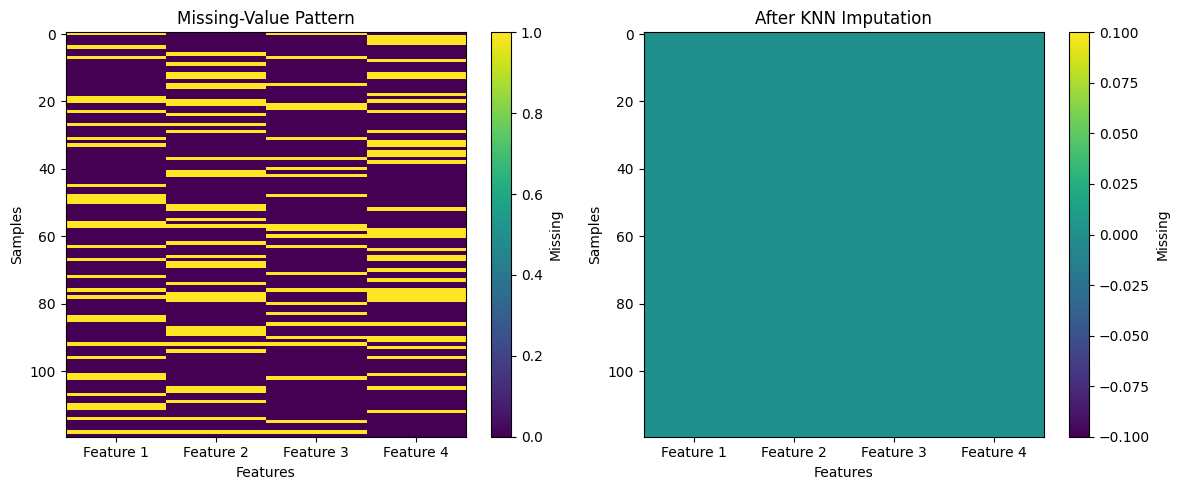

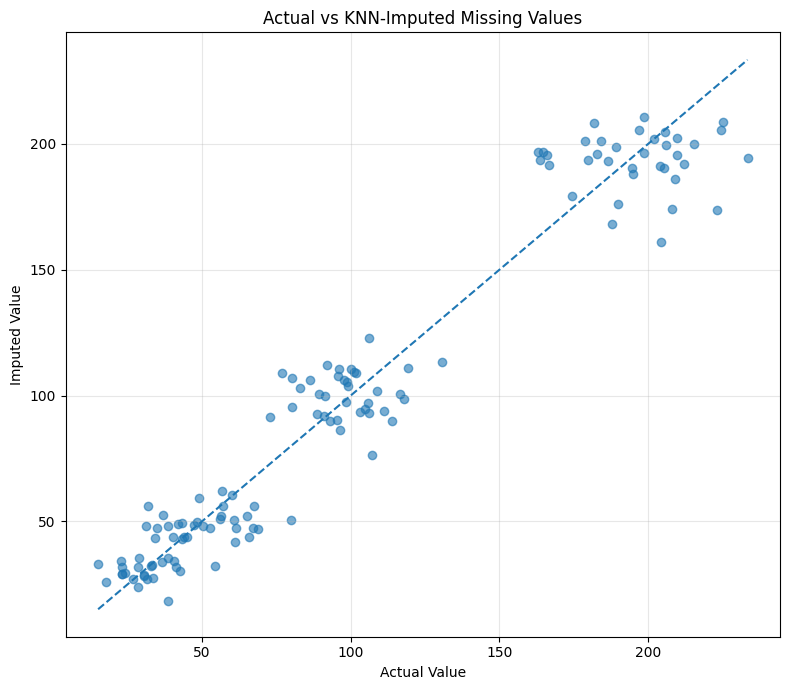

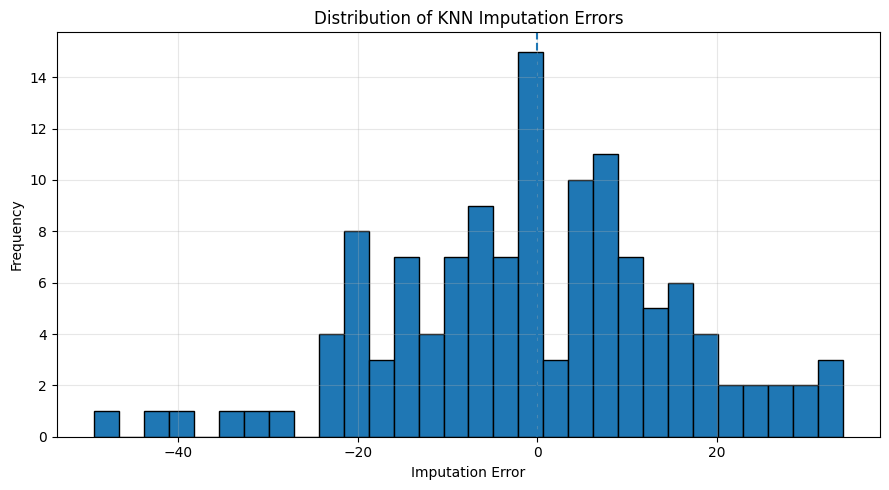

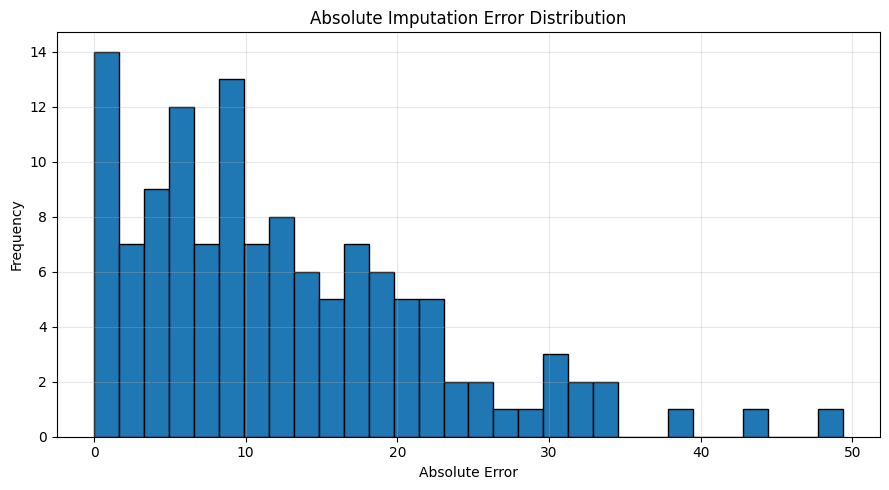

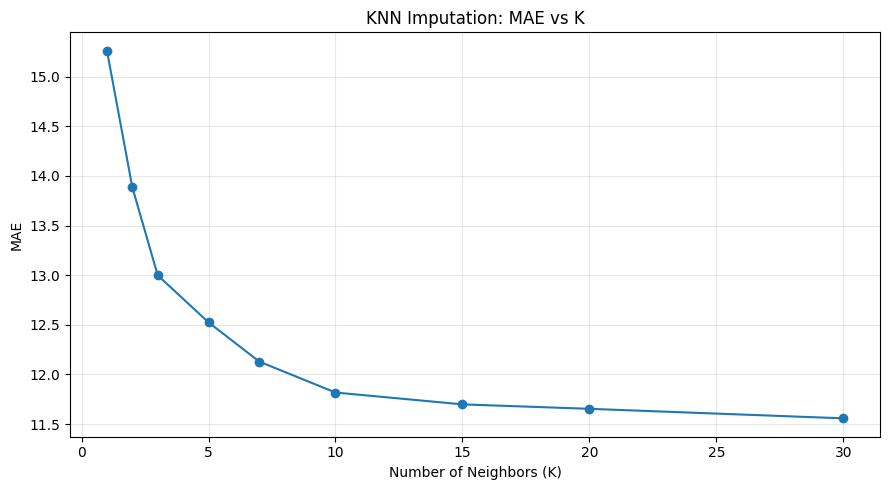

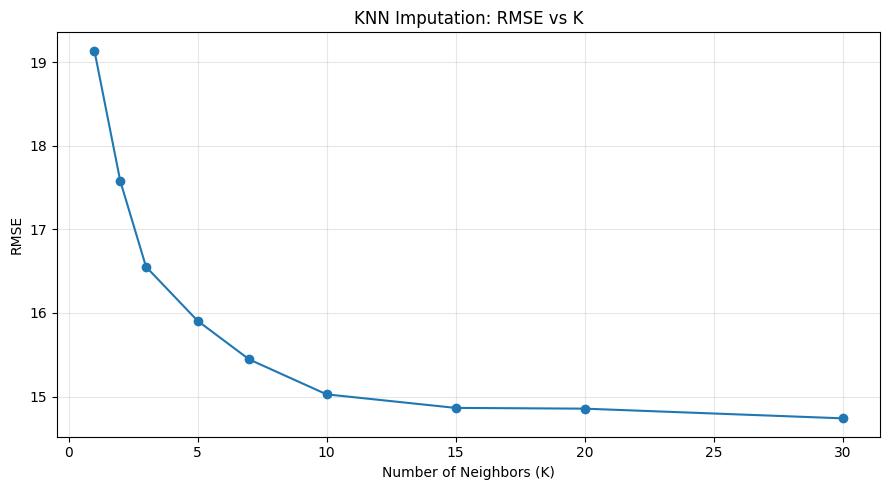

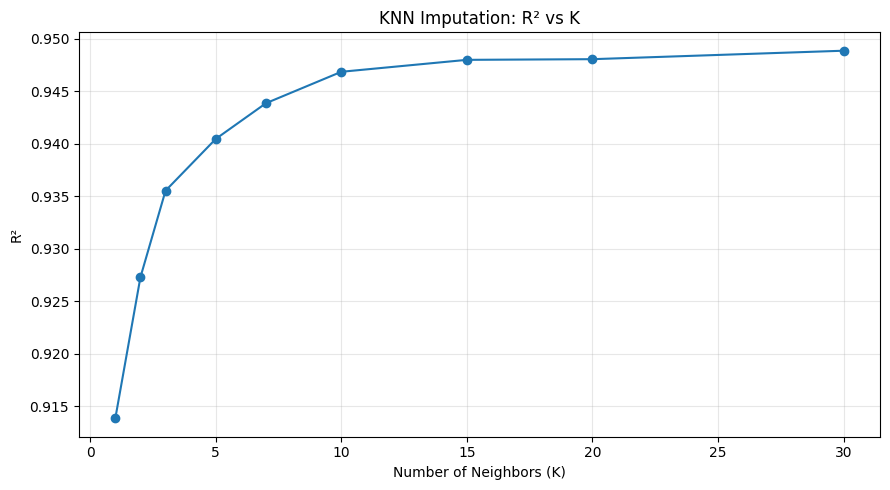

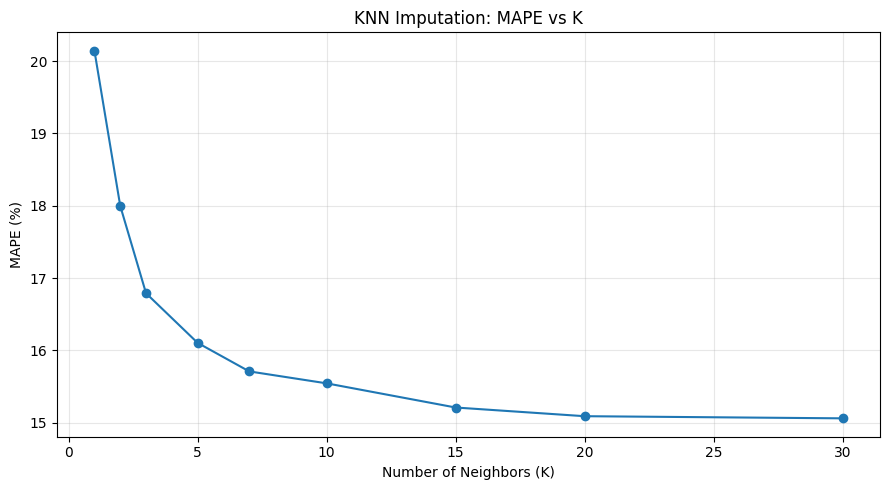



BEST K ANALYSIS
Best K according to MAE : 30
Best K according to RMSE: 30
Best K according to R²  : 30


FEATURE-WISE IMPUTATION PERFORMANCE
Feature 1    | MAE = 9.83754 | RMSE = 12.66817 | R² = -0.05942
Feature 2    | MAE = 12.97280 | RMSE = 15.08640 | R² = -0.47295
Feature 3    | MAE = 7.12600 | RMSE = 9.22146 | R² = -0.12796
Feature 4    | MAE = 17.99157 | RMSE = 21.67955 | R² = -0.38019


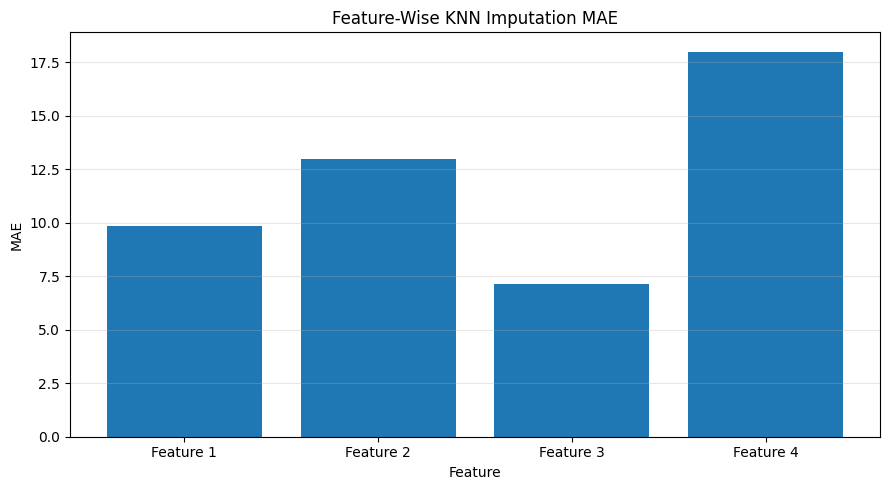

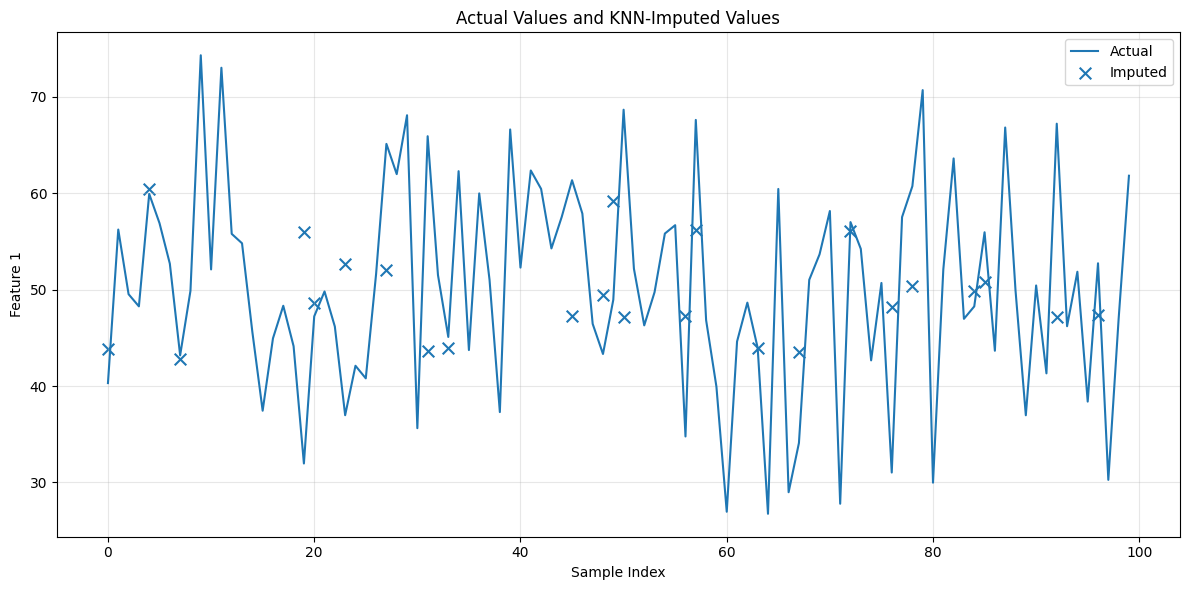



UNIFORM vs DISTANCE WEIGHTING
uniform    | MAE = 11.273456 | RMSE = 14.182003 | R² = 0.952669
distance   | MAE = 12.525238 | RMSE = 15.905599 | R² = 0.940465


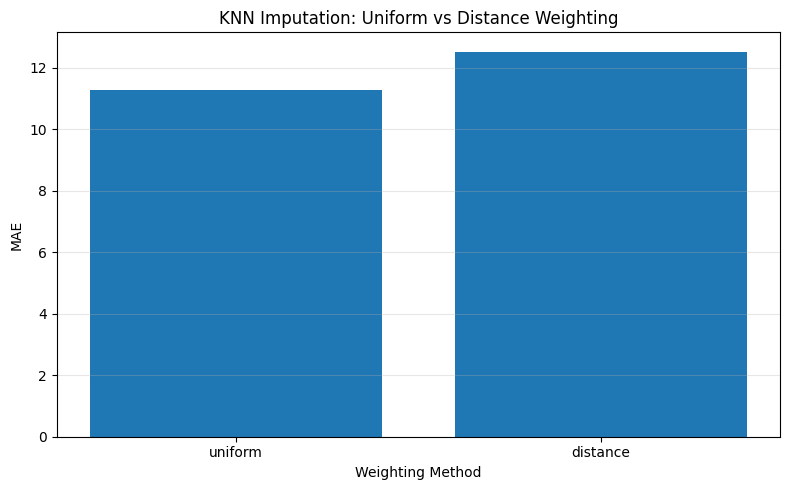



FINAL KNN IMPUTATION SUMMARY
Training samples       : 480
Testing samples        : 120
Features               : 4
Missing test values    : 127
----------------------------------------------------------------------
Selected K             : 5
Weighting              : distance
Standardization        : True
----------------------------------------------------------------------
MAE                    : 12.525238
MSE                    : 252.988067
RMSE                   : 15.905599
R²                     : 0.940465
MAPE                   : 16.1032%


In [11]:
# ============================================================
# KNN IMPUTATION FROM SCRATCH
# Missing-Value Imputation using K-Nearest Neighbors
# NO SCIKIT-LEARN
# ONLY NUMPY + MATPLOTLIB
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


# ============================================================
# 1. KNN IMPUTER FROM SCRATCH
# ============================================================

class KNNImputerScratch:

    def __init__(
        self,
        n_neighbors=5,
        weights="uniform",
        standardize=True,
        epsilon=1e-12
    ):
        self.n_neighbors = n_neighbors
        self.weights = weights
        self.standardize = standardize
        self.epsilon = epsilon

        self.X_train_ = None
        self.mean_ = None
        self.std_ = None

    # --------------------------------------------------------
    # FIT
    # --------------------------------------------------------

    def fit(self, X):

        X = np.asarray(X, dtype=float)

        self.X_train_ = X.copy()

        # Feature-wise mean/std ignoring NaN
        self.mean_ = np.nanmean(X, axis=0)
        self.std_ = np.nanstd(X, axis=0)

        # Avoid division by zero
        self.std_[self.std_ < self.epsilon] = 1.0

        return self

    # --------------------------------------------------------
    # STANDARDIZE
    # --------------------------------------------------------

    def _standardize(self, X):

        if not self.standardize:
            return X.copy()

        return (X - self.mean_) / self.std_

    # --------------------------------------------------------
    # DISTANCE BETWEEN TWO SAMPLES
    # Only common observed features are used
    # --------------------------------------------------------

    def _distance(self, x1, x2):

        valid = ~np.isnan(x1) & ~np.isnan(x2)

        if np.sum(valid) == 0:
            return np.inf

        diff = x1[valid] - x2[valid]

        distance = np.sqrt(np.sum(diff ** 2))

        # Scale distance according to number of observed features
        # so that samples with fewer common features are not
        # automatically favored.
        n_features = len(x1)

        n_valid = np.sum(valid)

        distance *= np.sqrt(n_features / n_valid)

        return distance

    # --------------------------------------------------------
    # FIND NEAREST NEIGHBORS
    # --------------------------------------------------------

    def _find_neighbors(self, X, row_index, feature_index):

        x = X[row_index]

        distances = []

        for i in range(len(X)):

            # Do not use the sample itself
            if i == row_index:
                continue

            # Neighbor must contain the value we want to impute
            if np.isnan(X[i, feature_index]):
                continue

            distance = self._distance(x, X[i])

            if np.isfinite(distance):
                distances.append((i, distance))

        # Sort by distance
        distances.sort(key=lambda z: z[1])

        neighbors = distances[:self.n_neighbors]

        return neighbors

    # --------------------------------------------------------
    # IMPUTE
    # --------------------------------------------------------

    def transform(self, X):

        X = np.asarray(X, dtype=float)

        X_imputed = X.copy()

        # Standardized copy used ONLY for distance calculation
        X_scaled = self._standardize(X)

        missing_positions = np.argwhere(np.isnan(X))

        for row_index, feature_index in missing_positions:

            neighbors = self._find_neighbors(
                X_scaled,
                row_index,
                feature_index
            )

            # If no neighbors are available,
            # use global feature mean
            if len(neighbors) == 0:

                X_imputed[row_index, feature_index] = \
                    self.mean_[feature_index]

                continue

            neighbor_indices = np.array(
                [n[0] for n in neighbors],
                dtype=int
            )

            distances = np.array(
                [n[1] for n in neighbors],
                dtype=float
            )

            values = X[
                neighbor_indices,
                feature_index
            ]

            # ------------------------------------------------
            # UNIFORM WEIGHT
            # ------------------------------------------------

            if self.weights == "uniform":

                imputed_value = np.mean(values)

            # ------------------------------------------------
            # DISTANCE WEIGHT
            # ------------------------------------------------

            elif self.weights == "distance":

                weights = 1.0 / (
                    distances + self.epsilon
                )

                imputed_value = np.sum(
                    weights * values
                ) / np.sum(weights)

            else:

                raise ValueError(
                    "weights must be 'uniform' or 'distance'"
                )

            X_imputed[row_index, feature_index] = \
                imputed_value

        return X_imputed

    # --------------------------------------------------------
    # FIT + TRANSFORM
    # --------------------------------------------------------

    def fit_transform(self, X):

        self.fit(X)

        return self.transform(X)


# ============================================================
# 2. GENERATE COMPLETE SYNTHETIC DATA
# ============================================================

n_samples = 600

n_features = 4

# Correlated features
mean = np.array([
    50,
    100,
    30,
    200
])

covariance = np.array([
    [100,  55,  25,  70],
    [55,  225, 45,  90],
    [25,  45,  64,  50],
    [70,  90,  50, 400]
])

X_complete = np.random.multivariate_normal(
    mean,
    covariance,
    size=n_samples
)

feature_names = [
    "Feature 1",
    "Feature 2",
    "Feature 3",
    "Feature 4"
]


# ============================================================
# 3. CREATE MISSING VALUES
# ============================================================

X_missing = X_complete.copy()

missing_rate = 0.20

missing_mask = (
    np.random.rand(*X_missing.shape)
    < missing_rate
)

X_missing[missing_mask] = np.nan


# ============================================================
# 4. SHOW MISSING-VALUE STATISTICS
# ============================================================

print("=" * 70)
print("MISSING VALUE STATISTICS")
print("=" * 70)

total_values = X_missing.size

total_missing = np.isnan(X_missing).sum()

print("Number of samples :", n_samples)
print("Number of features:", n_features)
print("Total values      :", total_values)
print("Missing values    :", total_missing)
print(
    "Missing percentage:",
    round(100 * total_missing / total_values, 2),
    "%"
)

print("\nMissing values per feature:")

for j in range(n_features):

    count = np.isnan(X_missing[:, j]).sum()

    percentage = 100 * count / n_samples

    print(
        f"{feature_names[j]:12s}: "
        f"{count:3d} "
        f"({percentage:.2f}%)"
    )


# ============================================================
# 5. TRAIN / TEST SPLIT
# ============================================================

indices = np.arange(n_samples)

np.random.shuffle(indices)

train_size = int(0.80 * n_samples)

train_indices = indices[:train_size]

test_indices = indices[train_size:]

X_train_complete = X_complete[train_indices]

X_test_complete = X_complete[test_indices]


# ============================================================
# 6. CREATE MISSING VALUES IN TEST DATA
# ============================================================

X_test_missing = X_test_complete.copy()

test_missing_rate = 0.25

test_missing_mask = (
    np.random.rand(*X_test_missing.shape)
    < test_missing_rate
)

X_test_missing[test_missing_mask] = np.nan


# ============================================================
# 7. FIT KNN IMPUTER
# ============================================================

k = 5

imputer = KNNImputerScratch(
    n_neighbors=k,
    weights="distance",
    standardize=True
)

imputer.fit(X_train_complete)


# ============================================================
# 8. IMPUTE TEST DATA
# ============================================================

X_test_imputed = imputer.transform(
    X_test_missing
)


# ============================================================
# 9. EVALUATE ONLY THE VALUES THAT WERE ARTIFICIALLY
#    MADE MISSING
# ============================================================

actual_missing_values = X_test_complete[
    test_missing_mask
]

predicted_missing_values = X_test_imputed[
    test_missing_mask
]


# ============================================================
# 10. EVALUATION METRICS
# ============================================================

def mae(y_true, y_pred):

    return np.mean(
        np.abs(y_true - y_pred)
    )


def mse(y_true, y_pred):

    return np.mean(
        (y_true - y_pred) ** 2
    )


def rmse(y_true, y_pred):

    return np.sqrt(
        mse(y_true, y_pred)
    )


def r2_score(y_true, y_pred):

    ss_res = np.sum(
        (y_true - y_pred) ** 2
    )

    ss_tot = np.sum(
        (y_true - np.mean(y_true)) ** 2
    )

    if ss_tot == 0:
        return np.nan

    return 1 - ss_res / ss_tot


def mape(y_true, y_pred):

    denominator = np.maximum(
        np.abs(y_true),
        1e-8
    )

    return np.mean(
        np.abs(
            (y_true - y_pred) / denominator
        )
    ) * 100


MAE = mae(
    actual_missing_values,
    predicted_missing_values
)

MSE = mse(
    actual_missing_values,
    predicted_missing_values
)

RMSE = rmse(
    actual_missing_values,
    predicted_missing_values
)

R2 = r2_score(
    actual_missing_values,
    predicted_missing_values
)

MAPE = mape(
    actual_missing_values,
    predicted_missing_values
)


# ============================================================
# 11. PRINT EVALUATION
# ============================================================

print("\n")
print("=" * 70)
print("KNN IMPUTATION EVALUATION")
print("=" * 70)

print(f"K                   : {k}")
print(f"Weighting           : distance")
print(f"Missing test values : {len(actual_missing_values)}")

print("-" * 70)

print(f"MAE                 : {MAE:.6f}")
print(f"MSE                 : {MSE:.6f}")
print(f"RMSE                : {RMSE:.6f}")
print(f"R²                  : {R2:.6f}")
print(f"MAPE                : {MAPE:.4f}%")

print("=" * 70)


# ============================================================
# 12. BEFORE vs AFTER IMPUTATION
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.imshow(
    np.isnan(X_test_missing),
    aspect="auto",
    interpolation="nearest"
)

plt.title("Missing-Value Pattern")

plt.xlabel("Features")
plt.ylabel("Samples")

plt.xticks(
    range(n_features),
    feature_names
)

plt.colorbar(
    label="Missing"
)


plt.subplot(1, 2, 2)

plt.imshow(
    np.isnan(X_test_imputed),
    aspect="auto",
    interpolation="nearest"
)

plt.title("After KNN Imputation")

plt.xlabel("Features")
plt.ylabel("Samples")

plt.xticks(
    range(n_features),
    feature_names
)

plt.colorbar(
    label="Missing"
)

plt.tight_layout()

plt.show()


# ============================================================
# 13. ACTUAL vs IMPUTED VALUES
# ============================================================

plt.figure(figsize=(8, 7))

plt.scatter(
    actual_missing_values,
    predicted_missing_values,
    alpha=0.6
)

minimum = min(
    actual_missing_values.min(),
    predicted_missing_values.min()
)

maximum = max(
    actual_missing_values.max(),
    predicted_missing_values.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Value")

plt.ylabel("Imputed Value")

plt.title(
    "Actual vs KNN-Imputed Missing Values"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# 14. IMPUTATION ERROR DISTRIBUTION
# ============================================================

errors = (
    predicted_missing_values
    - actual_missing_values
)

plt.figure(figsize=(9, 5))

plt.hist(
    errors,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Imputation Error")

plt.ylabel("Frequency")

plt.title(
    "Distribution of KNN Imputation Errors"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# 15. ABSOLUTE ERROR DISTRIBUTION
# ============================================================

absolute_errors = np.abs(errors)

plt.figure(figsize=(9, 5))

plt.hist(
    absolute_errors,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Absolute Error")

plt.ylabel("Frequency")

plt.title(
    "Absolute Imputation Error Distribution"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# 16. K-WISE EVALUATION
# ============================================================

k_values = [
    1, 2, 3, 5, 7,
    10, 15, 20, 30
]

mae_values = []

mse_values = []

rmse_values = []

r2_values = []

mape_values = []


for k_value in k_values:

    model = KNNImputerScratch(
        n_neighbors=k_value,
        weights="distance",
        standardize=True
    )

    model.fit(X_train_complete)

    imputed = model.transform(
        X_test_missing
    )

    actual = X_test_complete[
        test_missing_mask
    ]

    predicted = imputed[
        test_missing_mask
    ]

    mae_values.append(
        mae(actual, predicted)
    )

    mse_values.append(
        mse(actual, predicted)
    )

    rmse_values.append(
        rmse(actual, predicted)
    )

    r2_values.append(
        r2_score(actual, predicted)
    )

    mape_values.append(
        mape(actual, predicted)
    )


# ============================================================
# 17. MAE vs K
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    mae_values,
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")

plt.ylabel("MAE")

plt.title(
    "KNN Imputation: MAE vs K"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# 18. RMSE vs K
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    rmse_values,
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")

plt.ylabel("RMSE")

plt.title(
    "KNN Imputation: RMSE vs K"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# 19. R² vs K
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    r2_values,
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")

plt.ylabel("R²")

plt.title(
    "KNN Imputation: R² vs K"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# 20. MAPE vs K
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    mape_values,
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")

plt.ylabel("MAPE (%)")

plt.title(
    "KNN Imputation: MAPE vs K"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# 21. FIND BEST K
# ============================================================

best_mae_index = np.argmin(
    mae_values
)

best_rmse_index = np.argmin(
    rmse_values
)

best_r2_index = np.argmax(
    r2_values
)

print("\n")
print("=" * 70)
print("BEST K ANALYSIS")
print("=" * 70)

print(
    "Best K according to MAE :",
    k_values[best_mae_index]
)

print(
    "Best K according to RMSE:",
    k_values[best_rmse_index]
)

print(
    "Best K according to R²  :",
    k_values[best_r2_index]
)

print("=" * 70)


# ============================================================
# 22. FEATURE-WISE IMPUTATION PERFORMANCE
# ============================================================

print("\n")
print("=" * 70)
print("FEATURE-WISE IMPUTATION PERFORMANCE")
print("=" * 70)

for j in range(n_features):

    mask = test_missing_mask[:, j]

    if np.sum(mask) == 0:
        continue

    actual = X_test_complete[mask, j]

    predicted = X_test_imputed[mask, j]

    feature_mae = mae(
        actual,
        predicted
    )

    feature_rmse = rmse(
        actual,
        predicted
    )

    feature_r2 = r2_score(
        actual,
        predicted
    )

    print(
        f"{feature_names[j]:12s} | "
        f"MAE = {feature_mae:.5f} | "
        f"RMSE = {feature_rmse:.5f} | "
        f"R² = {feature_r2:.5f}"
    )


# ============================================================
# 23. FEATURE-WISE MAE PLOT
# ============================================================

feature_mae_values = []

for j in range(n_features):

    mask = test_missing_mask[:, j]

    actual = X_test_complete[mask, j]

    predicted = X_test_imputed[mask, j]

    feature_mae_values.append(
        mae(actual, predicted)
    )


plt.figure(figsize=(9, 5))

plt.bar(
    feature_names,
    feature_mae_values
)

plt.xlabel("Feature")

plt.ylabel("MAE")

plt.title(
    "Feature-Wise KNN Imputation MAE"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 24. RANDOM SAMPLE: ACTUAL / MISSING / IMPUTED
# ============================================================

sample_indices = np.arange(
    min(100, len(X_test_complete))
)

feature_to_show = 0

plt.figure(figsize=(12, 6))

plt.plot(
    sample_indices,
    X_test_complete[
        sample_indices,
        feature_to_show
    ],
    label="Actual"
)

missing_positions = np.where(
    test_missing_mask[
        sample_indices,
        feature_to_show
    ]
)[0]

plt.scatter(
    missing_positions,
    X_test_imputed[
        sample_indices[missing_positions],
        feature_to_show
    ],
    label="Imputed",
    marker="x",
    s=70
)

plt.xlabel("Sample Index")

plt.ylabel(
    feature_names[feature_to_show]
)

plt.title(
    "Actual Values and KNN-Imputed Values"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# 25. COMPARE UNIFORM vs DISTANCE WEIGHTS
# ============================================================

weight_types = [
    "uniform",
    "distance"
]

weight_mae = []

weight_rmse = []

weight_r2 = []


for weight_type in weight_types:

    model = KNNImputerScratch(
        n_neighbors=5,
        weights=weight_type,
        standardize=True
    )

    model.fit(X_train_complete)

    imputed = model.transform(
        X_test_missing
    )

    actual = X_test_complete[
        test_missing_mask
    ]

    predicted = imputed[
        test_missing_mask
    ]

    weight_mae.append(
        mae(actual, predicted)
    )

    weight_rmse.append(
        rmse(actual, predicted)
    )

    weight_r2.append(
        r2_score(actual, predicted)
    )


# ============================================================
# 26. WEIGHTING COMPARISON
# ============================================================

print("\n")
print("=" * 70)
print("UNIFORM vs DISTANCE WEIGHTING")
print("=" * 70)

for i, weight_type in enumerate(weight_types):

    print(
        f"{weight_type:10s} | "
        f"MAE = {weight_mae[i]:.6f} | "
        f"RMSE = {weight_rmse[i]:.6f} | "
        f"R² = {weight_r2[i]:.6f}"
    )

print("=" * 70)


# ============================================================
# 27. WEIGHTING MAE PLOT
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    weight_types,
    weight_mae
)

plt.xlabel("Weighting Method")

plt.ylabel("MAE")

plt.title(
    "KNN Imputation: Uniform vs Distance Weighting"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 28. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("FINAL KNN IMPUTATION SUMMARY")
print("=" * 70)

print(f"Training samples       : {len(X_train_complete)}")
print(f"Testing samples        : {len(X_test_complete)}")
print(f"Features               : {n_features}")
print(f"Missing test values    : {len(actual_missing_values)}")

print("-" * 70)

print(f"Selected K             : {k}")
print(f"Weighting              : distance")
print(f"Standardization        : True")

print("-" * 70)

print(f"MAE                    : {MAE:.6f}")
print(f"MSE                    : {MSE:.6f}")
print(f"RMSE                   : {RMSE:.6f}")
print(f"R²                     : {R2:.6f}")
print(f"MAPE                   : {MAPE:.4f}%")

print("=" * 70)

MISSING VALUE STATISTICS
Number of samples       : 800
Number of features      : 5
Total values            : 4000
Total missing values    : 823
Missing percentage      : 20.57%

Missing values per feature:
---------------------------------------------------------------------------
Feature 1    :  163 ( 20.38%)
Feature 2    :  148 ( 18.50%)
Feature 3    :  179 ( 22.38%)
Feature 4    :  169 ( 21.12%)
Feature 5    :  164 ( 20.50%)


WEIGHTED KNN IMPUTATION EVALUATION
Number of neighbors K : 5
Distance power p      : 2.0
Weight function       : 1 / (d^p + epsilon)
Test missing values   : 167
---------------------------------------------------------------------------
MAE                   : 11.711024
MSE                   : 236.353643
RMSE                  : 15.373797
R²                    : 0.934079
MAPE                  : 16.1430%


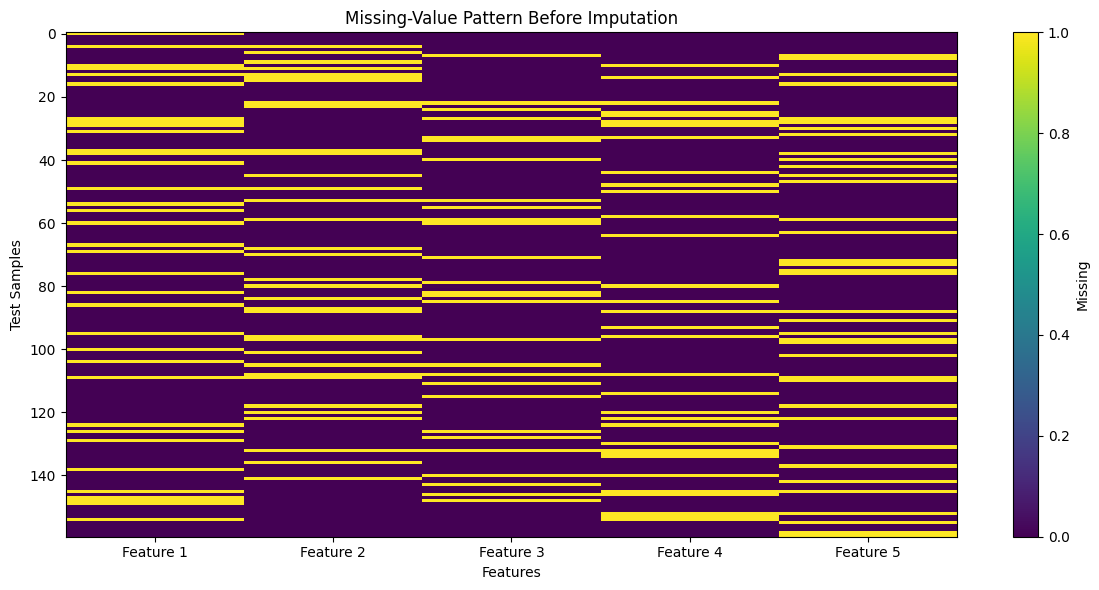

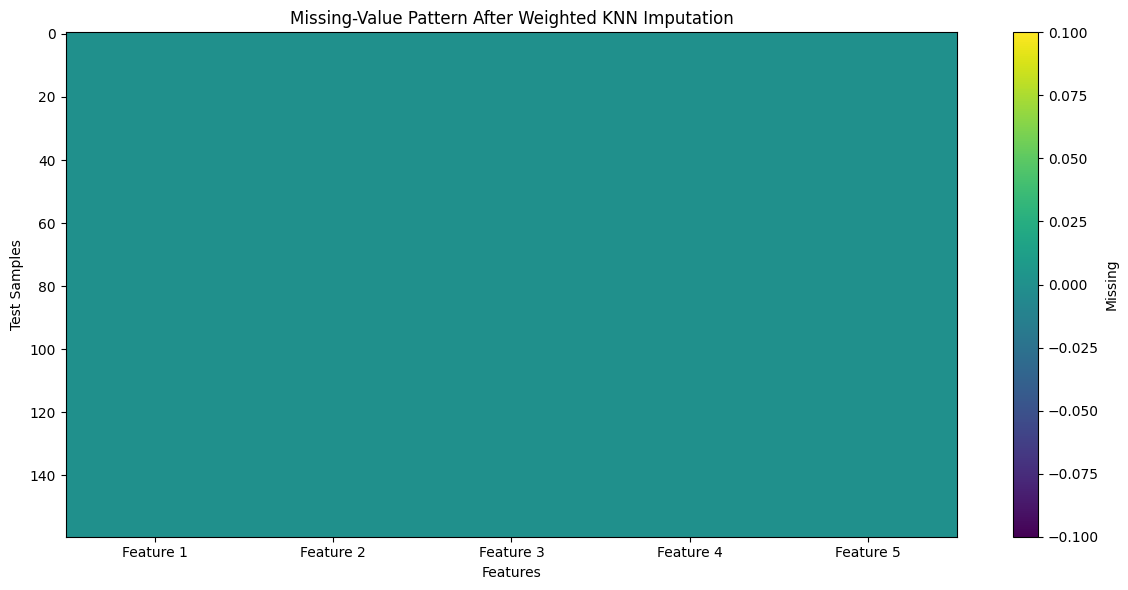

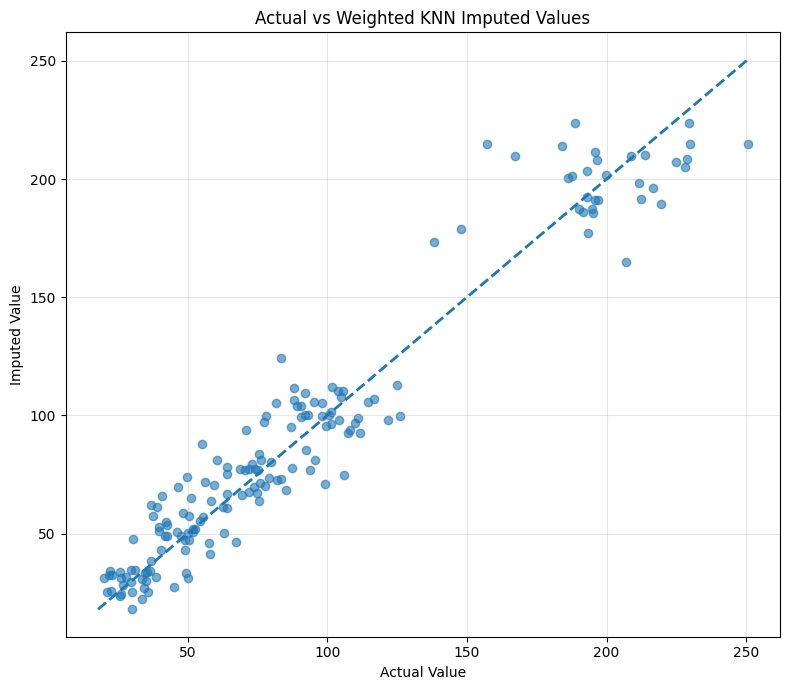

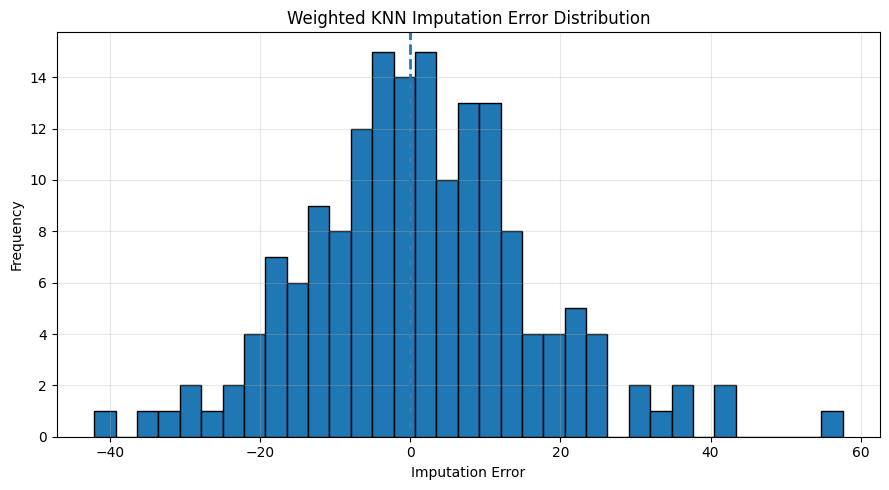

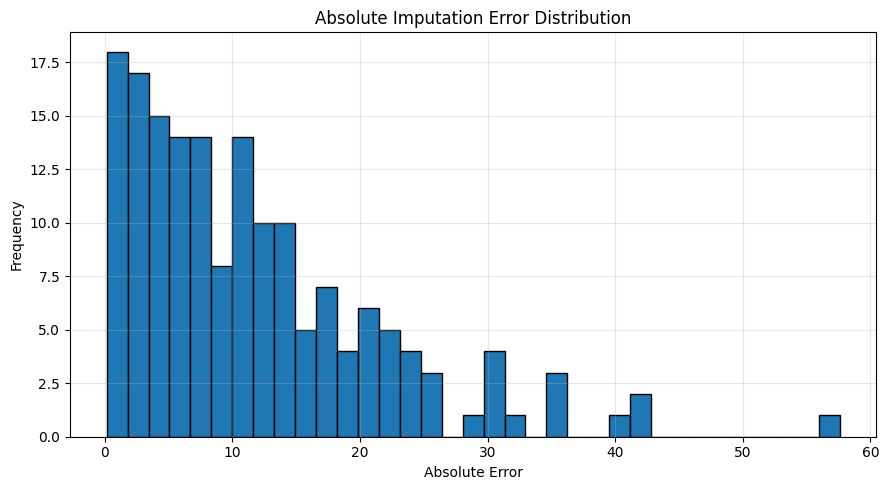

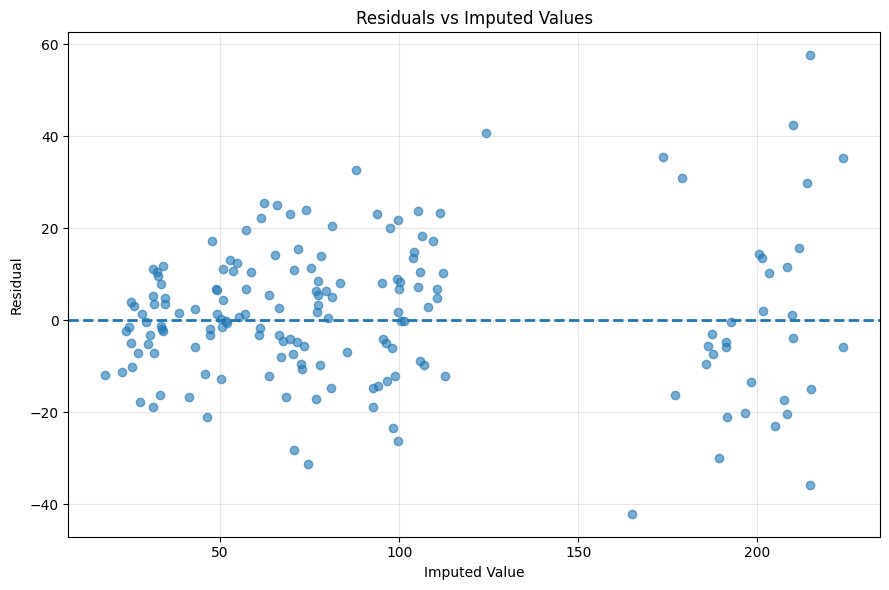

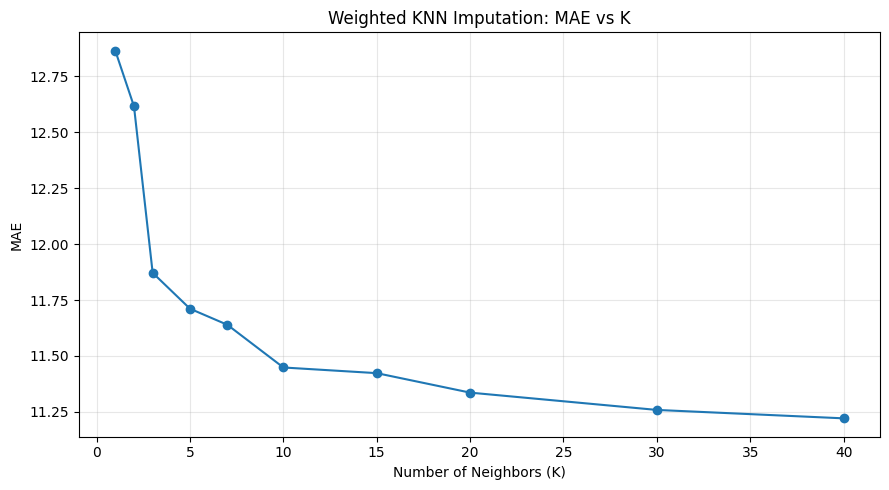

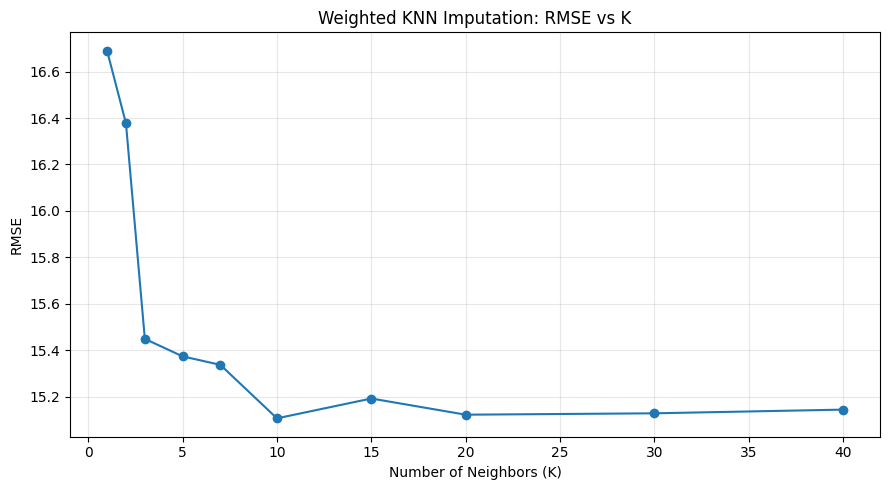

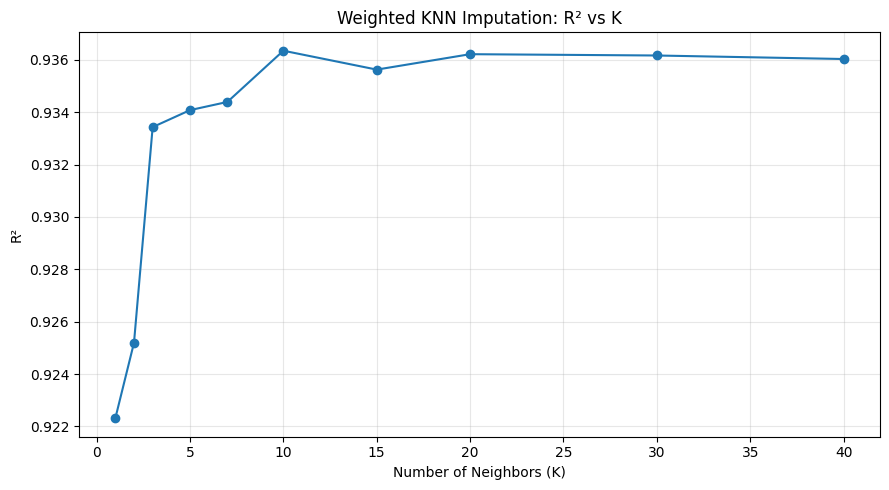

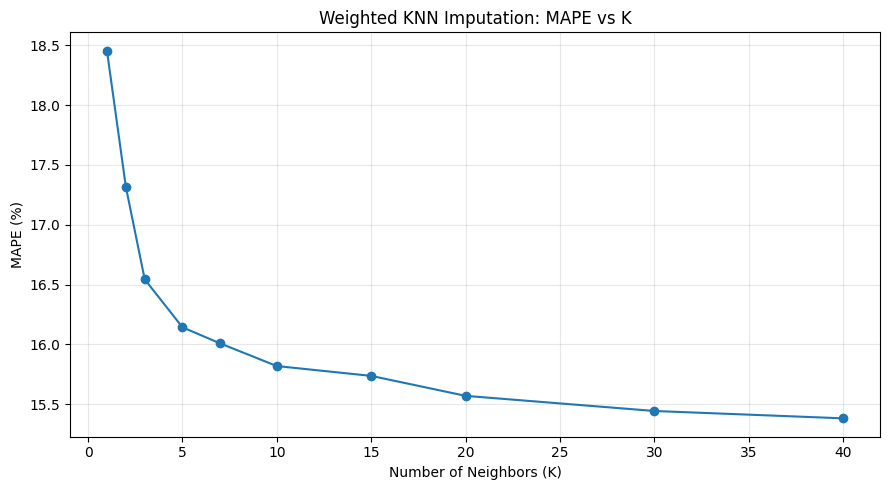



BEST K
Best K according to MAE  : 40
Best K according to RMSE : 10
Best K according to R²   : 10


FEATURE-WISE EVALUATION
Feature 1    | MAE = 9.51538 | RMSE = 12.33105 | R² = -1.07039 | MAPE = 21.338%
Feature 2    | MAE = 12.29632 | RMSE = 14.98857 | R² = -0.46732 | MAPE = 12.733%
Feature 3    | MAE = 6.55758 | RMSE = 8.15668 | R² = -0.31687 | MAPE = 22.010%
Feature 4    | MAE = 18.19064 | RMSE = 22.92769 | R² = 0.05515 | MAPE = 9.621%
Feature 5    | MAE = 11.37094 | RMSE = 14.04675 | R² = -0.27036 | MAPE = 15.740%


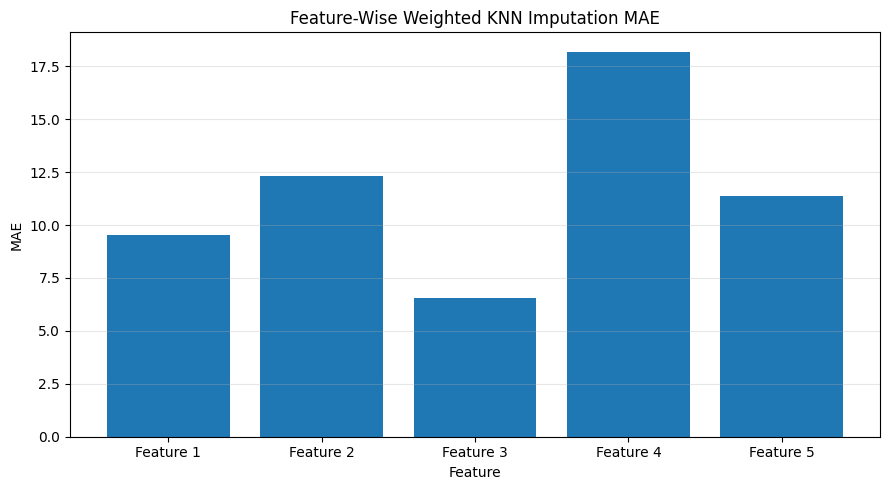

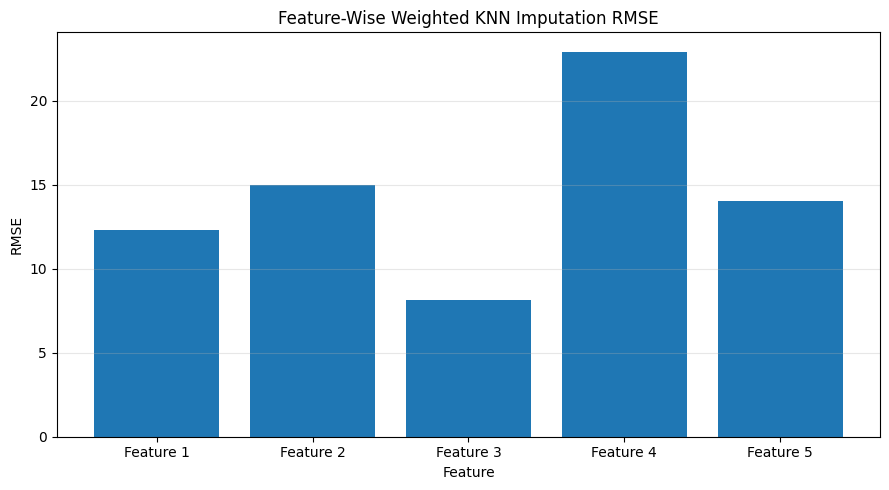

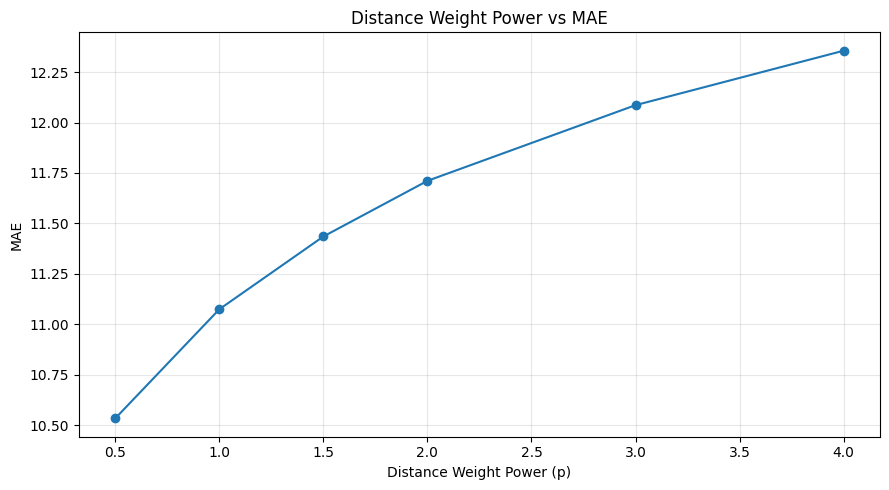

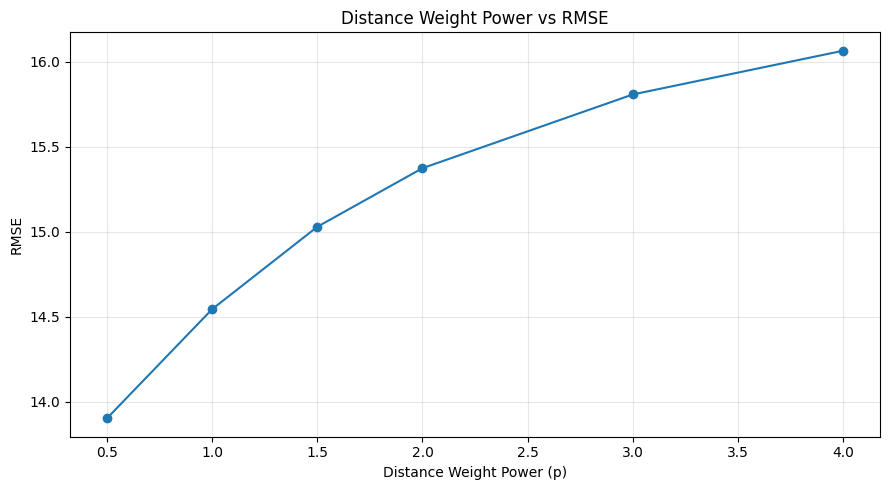

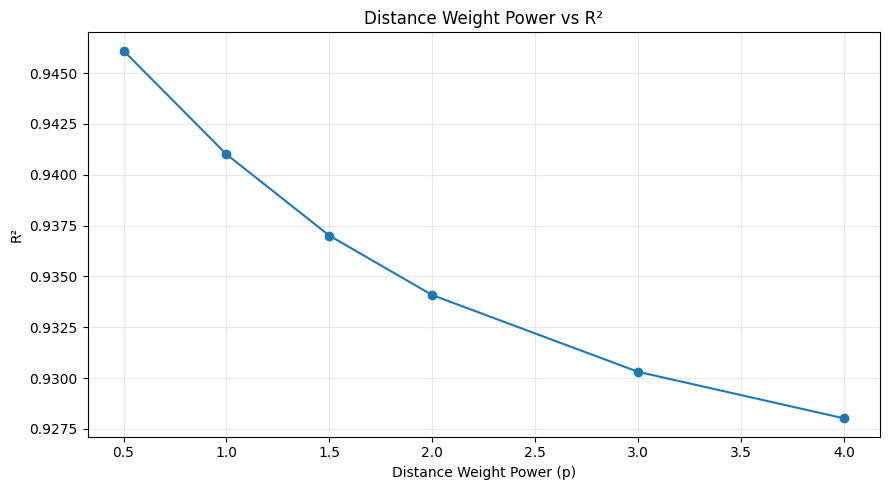



BEST DISTANCE WEIGHT POWER
Best p according to MAE  : 0.5
Best p according to RMSE : 0.5
Best p according to R²   : 0.5


NEIGHBOR WEIGHT ANALYSIS
Query sample       : 0
Missing feature    : Feature 1
K                  : 5
Distance power     : 2.0
---------------------------------------------------------------------------
Neighbor | Distance | Value | Raw Weight | Normalized Weight
---------------------------------------------------------------------------
     122 |   0.3477 |  50.2087 |   8.269296 |   0.339023
      55 |   0.3717 |  63.8559 |   7.237502 |   0.296722
     146 |   0.4929 |  60.7026 |   4.115376 |   0.168721
      36 |   0.6141 |  50.7141 |   2.651442 |   0.108703
      33 |   0.6871 |  42.0573 |   2.117939 |   0.086831


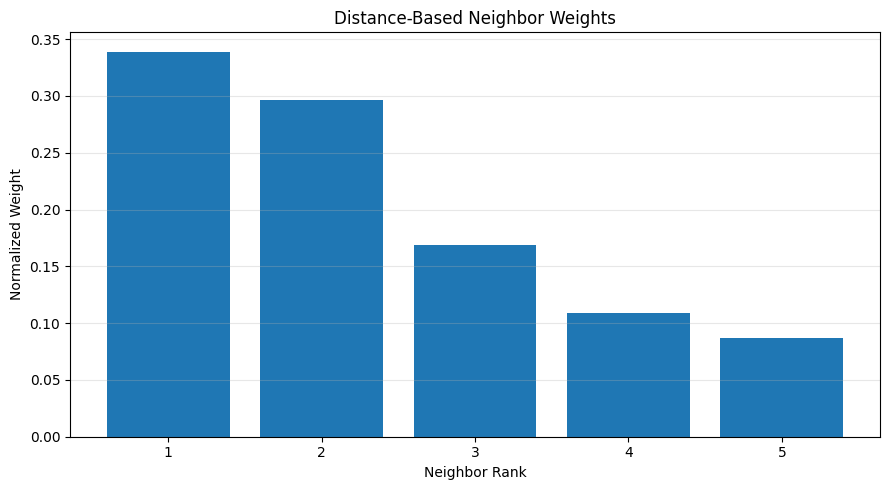

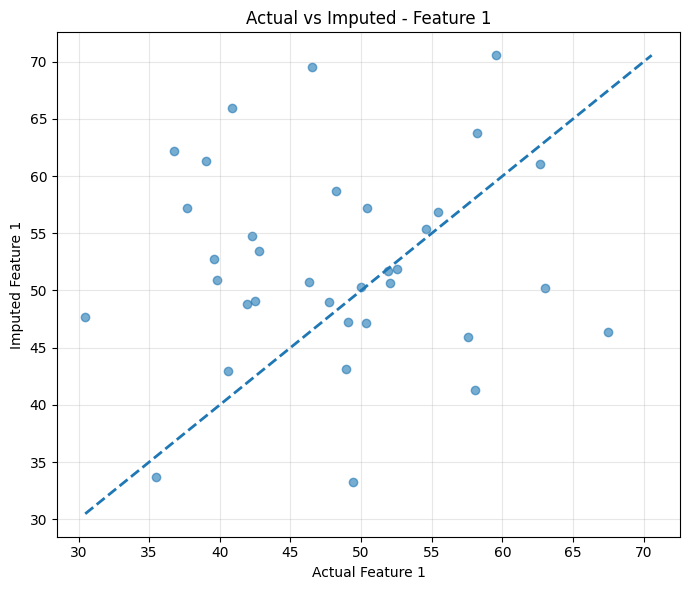

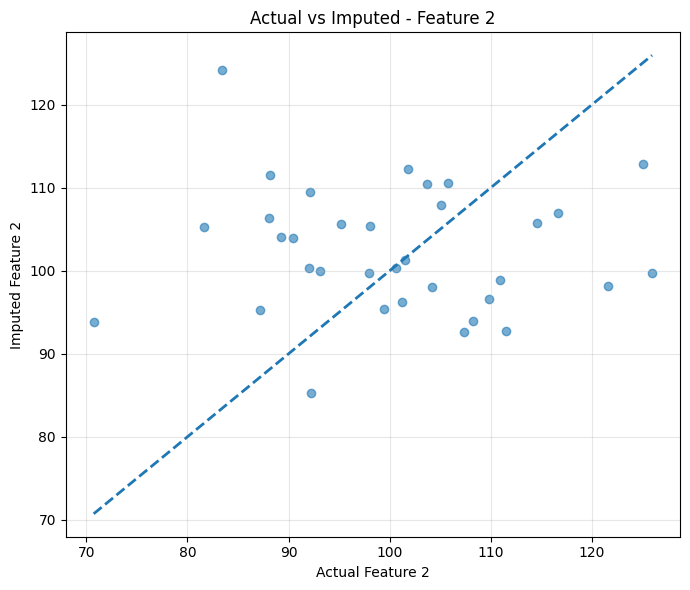

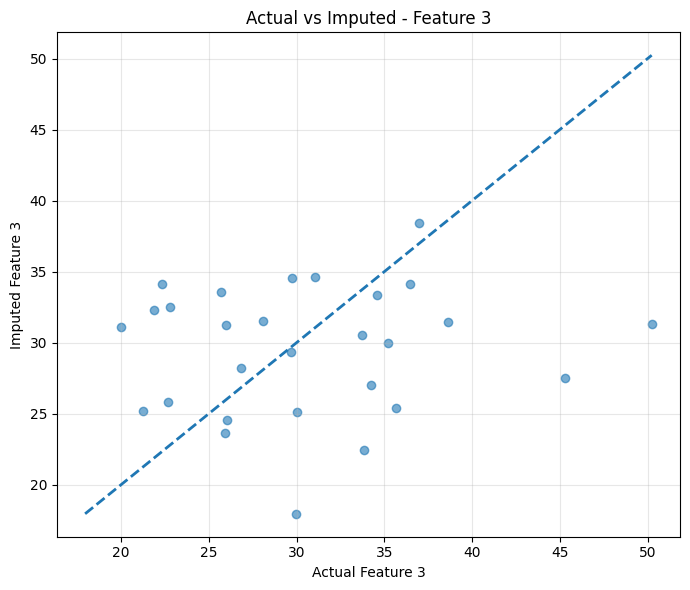

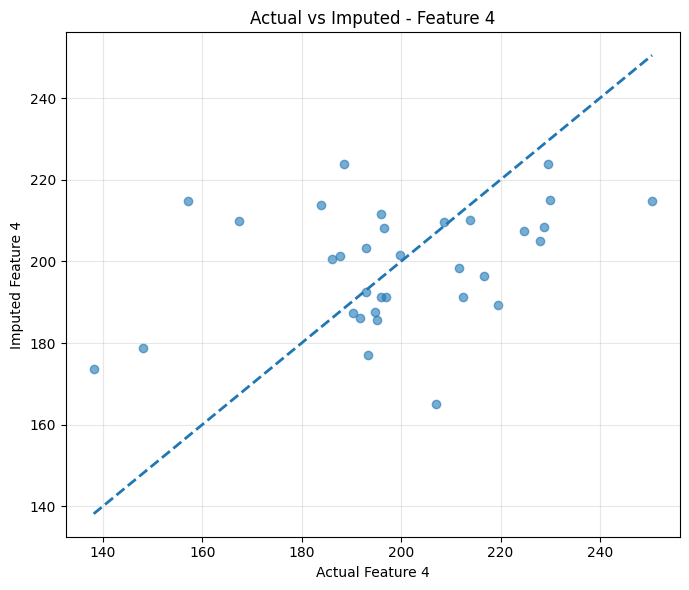

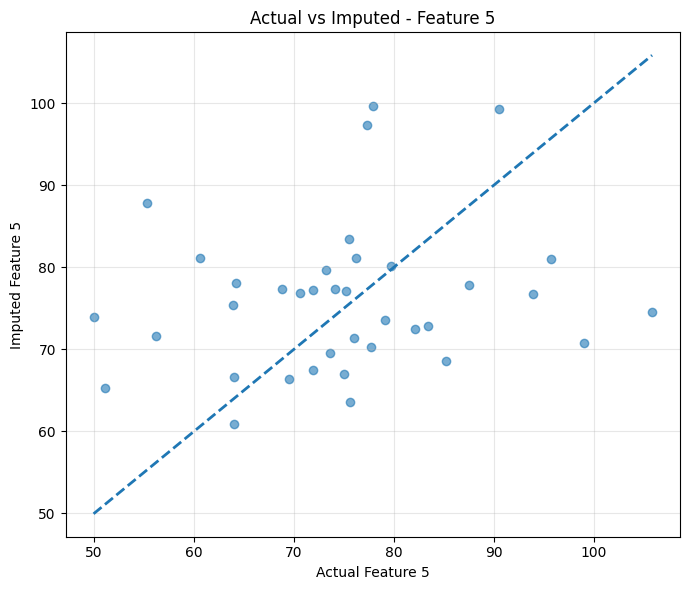



FINAL WEIGHTED KNN IMPUTATION SUMMARY
Training samples       : 640
Testing samples        : 160
Number of features     : 5
Missing test values    : 167
---------------------------------------------------------------------------
K                      : 5
Distance power         : 2.0
Weight function        : 1 / (d^p + epsilon)
Standardization        : True
---------------------------------------------------------------------------
MAE                    : 11.711024
MSE                    : 236.353643
RMSE                   : 15.373797
R²                     : 0.934079
MAPE                   : 16.1430%


In [12]:
# ============================================================
# WEIGHTED KNN IMPUTATION FROM SCRATCH
# Missing-Value Imputation using Distance-Weighted KNN
#
# NO SCIKIT-LEARN
# ONLY NUMPY + MATPLOTLIB
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


# ============================================================
# 1. WEIGHTED KNN IMPUTER FROM SCRATCH
# ============================================================

class WeightedKNNImputer:

    def __init__(
        self,
        n_neighbors=5,
        power=2.0,
        standardize=True,
        epsilon=1e-12
    ):

        self.n_neighbors = n_neighbors
        self.power = power
        self.standardize = standardize
        self.epsilon = epsilon

        self.X_train_ = None
        self.mean_ = None
        self.std_ = None

    # --------------------------------------------------------
    # FIT
    # --------------------------------------------------------

    def fit(self, X):

        X = np.asarray(X, dtype=float)

        self.X_train_ = X.copy()

        # Feature-wise statistics
        # ignoring NaN values
        self.mean_ = np.nanmean(
            X,
            axis=0
        )

        self.std_ = np.nanstd(
            X,
            axis=0
        )

        # Avoid zero standard deviation
        self.std_[self.std_ < self.epsilon] = 1.0

        return self

    # --------------------------------------------------------
    # STANDARDIZE
    # --------------------------------------------------------

    def _standardize(self, X):

        if not self.standardize:

            return X.copy()

        return (
            X - self.mean_
        ) / self.std_

    # --------------------------------------------------------
    # DISTANCE BETWEEN TWO SAMPLES
    #
    # Only features observed in BOTH samples are used.
    # --------------------------------------------------------

    def _distance(self, x1, x2):

        valid = (
            ~np.isnan(x1)
            &
            ~np.isnan(x2)
        )

        # No common observed feature
        if np.sum(valid) == 0:

            return np.inf

        diff = (
            x1[valid]
            -
            x2[valid]
        )

        distance = np.sqrt(
            np.sum(diff ** 2)
        )

        # Correct for number of available features
        total_features = len(x1)

        available_features = np.sum(valid)

        distance *= np.sqrt(
            total_features
            /
            available_features
        )

        return distance

    # --------------------------------------------------------
    # FIND NEIGHBORS
    # --------------------------------------------------------

    def _find_neighbors(
        self,
        X_scaled,
        row_index,
        feature_index
    ):

        target_row = X_scaled[row_index]

        neighbors = []

        for i in range(len(X_scaled)):

            # Do not use itself
            if i == row_index:
                continue

            # Neighbor must contain the feature
            # that needs to be imputed
            if np.isnan(
                X_scaled[i, feature_index]
            ):
                continue

            distance = self._distance(
                target_row,
                X_scaled[i]
            )

            if np.isfinite(distance):

                neighbors.append(
                    (
                        i,
                        distance
                    )
                )

        # Sort according to distance
        neighbors.sort(
            key=lambda x: x[1]
        )

        # Select K nearest neighbors
        return neighbors[
            :self.n_neighbors
        ]

    # --------------------------------------------------------
    # WEIGHT FUNCTION
    #
    # w = 1 / (d^p + epsilon)
    # --------------------------------------------------------

    def _calculate_weights(
        self,
        distances
    ):

        distances = np.asarray(
            distances,
            dtype=float
        )

        weights = 1.0 / (
            distances ** self.power
            +
            self.epsilon
        )

        return weights

    # --------------------------------------------------------
    # TRANSFORM
    # --------------------------------------------------------

    def transform(self, X):

        X = np.asarray(
            X,
            dtype=float
        )

        X_imputed = X.copy()

        # Standardized version used
        # only for distance calculations
        X_scaled = self._standardize(X)

        missing_positions = np.argwhere(
            np.isnan(X)
        )

        # ----------------------------------------------------
        # Process every missing value
        # ----------------------------------------------------

        for row_index, feature_index in missing_positions:

            neighbors = self._find_neighbors(
                X_scaled,
                row_index,
                feature_index
            )

            # ------------------------------------------------
            # No neighbors available
            # ------------------------------------------------

            if len(neighbors) == 0:

                X_imputed[
                    row_index,
                    feature_index
                ] = self.mean_[
                    feature_index
                ]

                continue

            # ------------------------------------------------
            # Neighbor indices
            # ------------------------------------------------

            neighbor_indices = np.array(
                [
                    n[0]
                    for n in neighbors
                ],
                dtype=int
            )

            # ------------------------------------------------
            # Neighbor distances
            # ------------------------------------------------

            distances = np.array(
                [
                    n[1]
                    for n in neighbors
                ],
                dtype=float
            )

            # ------------------------------------------------
            # Neighbor values
            # ------------------------------------------------

            neighbor_values = X[
                neighbor_indices,
                feature_index
            ]

            # ------------------------------------------------
            # Distance weights
            # ------------------------------------------------

            weights = self._calculate_weights(
                distances
            )

            # ------------------------------------------------
            # Weighted average
            # ------------------------------------------------

            weighted_sum = np.sum(
                weights
                *
                neighbor_values
            )

            weight_sum = np.sum(
                weights
            )

            # ------------------------------------------------
            # Final imputed value
            # ------------------------------------------------

            imputed_value = (
                weighted_sum
                /
                weight_sum
            )

            X_imputed[
                row_index,
                feature_index
            ] = imputed_value

        return X_imputed

    # --------------------------------------------------------
    # FIT + TRANSFORM
    # --------------------------------------------------------

    def fit_transform(self, X):

        self.fit(X)

        return self.transform(X)

    # --------------------------------------------------------
    # GET NEIGHBOR INFORMATION
    # --------------------------------------------------------

    def get_neighbors(
        self,
        X,
        row_index,
        feature_index
    ):

        X = np.asarray(
            X,
            dtype=float
        )

        X_scaled = self._standardize(X)

        neighbors = self._find_neighbors(
            X_scaled,
            row_index,
            feature_index
        )

        if len(neighbors) == 0:

            return None

        neighbor_indices = np.array(
            [
                n[0]
                for n in neighbors
            ],
            dtype=int
        )

        distances = np.array(
            [
                n[1]
                for n in neighbors
            ]
        )

        values = X[
            neighbor_indices,
            feature_index
        ]

        weights = self._calculate_weights(
            distances
        )

        normalized_weights = (
            weights
            /
            np.sum(weights)
        )

        return {
            "indices": neighbor_indices,
            "distances": distances,
            "values": values,
            "weights": weights,
            "normalized_weights":
                normalized_weights
        }


# ============================================================
# 2. GENERATE COMPLETE SYNTHETIC DATASET
# ============================================================

n_samples = 800

n_features = 5


# Feature means
mean = np.array([
    50,
    100,
    30,
    200,
    75
])


# Correlated covariance matrix
covariance = np.array([

    [100,  50,  30,  70,  40],

    [50,  225, 60,  90,  55],

    [30,  60,  81,  45,  35],

    [70,  90,  45, 400,  80],

    [40,  55,  35,  80, 144]
])


# Generate complete data
X_complete = np.random.multivariate_normal(
    mean,
    covariance,
    size=n_samples
)


feature_names = [
    "Feature 1",
    "Feature 2",
    "Feature 3",
    "Feature 4",
    "Feature 5"
]


# ============================================================
# 3. CREATE MISSING VALUES
# ============================================================

missing_rate = 0.20

X_missing = X_complete.copy()

missing_mask = (
    np.random.rand(
        n_samples,
        n_features
    )
    <
    missing_rate
)

X_missing[
    missing_mask
] = np.nan


# ============================================================
# 4. MISSING-VALUE STATISTICS
# ============================================================

print("=" * 75)
print("MISSING VALUE STATISTICS")
print("=" * 75)

total_values = X_missing.size

total_missing = np.isnan(
    X_missing
).sum()

print(
    f"Number of samples       : {n_samples}"
)

print(
    f"Number of features      : {n_features}"
)

print(
    f"Total values            : {total_values}"
)

print(
    f"Total missing values    : {total_missing}"
)

print(
    f"Missing percentage      : "
    f"{100 * total_missing / total_values:.2f}%"
)

print("\nMissing values per feature:")
print("-" * 75)

for j in range(n_features):

    count = np.isnan(
        X_missing[:, j]
    ).sum()

    percentage = (
        100
        *
        count
        /
        n_samples
    )

    print(
        f"{feature_names[j]:12s} : "
        f"{count:4d} "
        f"({percentage:6.2f}%)"
    )


# ============================================================
# 5. TRAIN / TEST SPLIT
# ============================================================

indices = np.arange(
    n_samples
)

np.random.shuffle(
    indices
)

train_size = int(
    0.80 * n_samples
)

train_indices = indices[
    :train_size
]

test_indices = indices[
    train_size:
]


X_train_complete = X_complete[
    train_indices
]

X_test_complete = X_complete[
    test_indices
]


# ============================================================
# 6. CREATE MISSING VALUES ONLY IN TEST SET
# ============================================================

X_test_missing = X_test_complete.copy()

test_missing_rate = 0.25

test_missing_mask = (
    np.random.rand(
        len(X_test_missing),
        n_features
    )
    <
    test_missing_rate
)

X_test_missing[
    test_missing_mask
] = np.nan


# ============================================================
# 7. CREATE WEIGHTED KNN MODEL
# ============================================================

K = 5

POWER = 2.0

imputer = WeightedKNNImputer(
    n_neighbors=K,
    power=POWER,
    standardize=True
)


# ============================================================
# 8. FIT MODEL
# ============================================================

imputer.fit(
    X_train_complete
)


# ============================================================
# 9. IMPUTE TEST DATA
# ============================================================

X_test_imputed = imputer.transform(
    X_test_missing
)


# ============================================================
# 10. EXTRACT ONLY ARTIFICIALLY MISSING VALUES
# ============================================================

actual_missing_values = (
    X_test_complete[
        test_missing_mask
    ]
)

predicted_missing_values = (
    X_test_imputed[
        test_missing_mask
    ]
)


# ============================================================
# 11. EVALUATION METRICS
# ============================================================

def mae(y_true, y_pred):

    return np.mean(
        np.abs(
            y_true - y_pred
        )
    )


def mse(y_true, y_pred):

    return np.mean(
        (
            y_true - y_pred
        ) ** 2
    )


def rmse(y_true, y_pred):

    return np.sqrt(
        mse(
            y_true,
            y_pred
        )
    )


def r2_score(y_true, y_pred):

    ss_res = np.sum(
        (
            y_true - y_pred
        ) ** 2
    )

    ss_tot = np.sum(
        (
            y_true
            -
            np.mean(y_true)
        ) ** 2
    )

    if ss_tot < 1e-12:

        return np.nan

    return (
        1
        -
        ss_res / ss_tot
    )


def mape(y_true, y_pred):

    denominator = np.maximum(
        np.abs(y_true),
        1e-8
    )

    return (
        np.mean(
            np.abs(
                (
                    y_true
                    -
                    y_pred
                )
                /
                denominator
            )
        )
        * 100
    )


# ============================================================
# 12. CALCULATE METRICS
# ============================================================

MAE = mae(
    actual_missing_values,
    predicted_missing_values
)

MSE = mse(
    actual_missing_values,
    predicted_missing_values
)

RMSE = rmse(
    actual_missing_values,
    predicted_missing_values
)

R2 = r2_score(
    actual_missing_values,
    predicted_missing_values
)

MAPE = mape(
    actual_missing_values,
    predicted_missing_values
)


# ============================================================
# 13. PRINT EVALUATION
# ============================================================

print("\n")
print("=" * 75)
print("WEIGHTED KNN IMPUTATION EVALUATION")
print("=" * 75)

print(
    f"Number of neighbors K : {K}"
)

print(
    f"Distance power p      : {POWER}"
)

print(
    f"Weight function       : "
    f"1 / (d^p + epsilon)"
)

print(
    f"Test missing values   : "
    f"{len(actual_missing_values)}"
)

print("-" * 75)

print(
    f"MAE                   : {MAE:.6f}"
)

print(
    f"MSE                   : {MSE:.6f}"
)

print(
    f"RMSE                  : {RMSE:.6f}"
)

print(
    f"R²                    : {R2:.6f}"
)

print(
    f"MAPE                  : {MAPE:.4f}%"
)

print("=" * 75)


# ============================================================
# 14. MISSING-VALUE HEATMAP
# ============================================================

plt.figure(
    figsize=(12, 6)
)

plt.imshow(
    np.isnan(
        X_test_missing
    ),
    aspect="auto",
    interpolation="nearest"
)

plt.title(
    "Missing-Value Pattern Before Imputation"
)

plt.xlabel(
    "Features"
)

plt.ylabel(
    "Test Samples"
)

plt.xticks(
    range(n_features),
    feature_names
)

plt.colorbar(
    label="Missing"
)

plt.tight_layout()

plt.show()


# ============================================================
# 15. AFTER IMPUTATION HEATMAP
# ============================================================

plt.figure(
    figsize=(12, 6)
)

plt.imshow(
    np.isnan(
        X_test_imputed
    ),
    aspect="auto",
    interpolation="nearest"
)

plt.title(
    "Missing-Value Pattern After Weighted KNN Imputation"
)

plt.xlabel(
    "Features"
)

plt.ylabel(
    "Test Samples"
)

plt.xticks(
    range(n_features),
    feature_names
)

plt.colorbar(
    label="Missing"
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. ACTUAL vs IMPUTED
# ============================================================

plt.figure(
    figsize=(8, 7)
)

plt.scatter(
    actual_missing_values,
    predicted_missing_values,
    alpha=0.6
)

minimum = min(
    actual_missing_values.min(),
    predicted_missing_values.min()
)

maximum = max(
    actual_missing_values.max(),
    predicted_missing_values.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Actual Value"
)

plt.ylabel(
    "Imputed Value"
)

plt.title(
    "Actual vs Weighted KNN Imputed Values"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 17. IMPUTATION ERROR
# ============================================================

errors = (
    predicted_missing_values
    -
    actual_missing_values
)


# ============================================================
# 18. ERROR DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.hist(
    errors,
    bins=35,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Imputation Error"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Weighted KNN Imputation Error Distribution"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 19. ABSOLUTE ERROR DISTRIBUTION
# ============================================================

absolute_errors = np.abs(
    errors
)

plt.figure(
    figsize=(9, 5)
)

plt.hist(
    absolute_errors,
    bins=35,
    edgecolor="black"
)

plt.xlabel(
    "Absolute Error"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Absolute Imputation Error Distribution"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 20. RESIDUAL vs PREDICTED
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.scatter(
    predicted_missing_values,
    errors,
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Imputed Value"
)

plt.ylabel(
    "Residual"
)

plt.title(
    "Residuals vs Imputed Values"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 21. K-WISE EVALUATION
# ============================================================

k_values = [
    1,
    2,
    3,
    5,
    7,
    10,
    15,
    20,
    30,
    40
]


k_mae = []

k_mse = []

k_rmse = []

k_r2 = []

k_mape = []


for k in k_values:

    model = WeightedKNNImputer(
        n_neighbors=k,
        power=POWER,
        standardize=True
    )

    model.fit(
        X_train_complete
    )

    imputed = model.transform(
        X_test_missing
    )

    actual = X_test_complete[
        test_missing_mask
    ]

    predicted = imputed[
        test_missing_mask
    ]

    k_mae.append(
        mae(
            actual,
            predicted
        )
    )

    k_mse.append(
        mse(
            actual,
            predicted
        )
    )

    k_rmse.append(
        rmse(
            actual,
            predicted
        )
    )

    k_r2.append(
        r2_score(
            actual,
            predicted
        )
    )

    k_mape.append(
        mape(
            actual,
            predicted
        )
    )


# ============================================================
# 22. MAE vs K
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    k_values,
    k_mae,
    marker="o"
)

plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "MAE"
)

plt.title(
    "Weighted KNN Imputation: MAE vs K"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 23. RMSE vs K
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    k_values,
    k_rmse,
    marker="o"
)

plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "RMSE"
)

plt.title(
    "Weighted KNN Imputation: RMSE vs K"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 24. R² vs K
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    k_values,
    k_r2,
    marker="o"
)

plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "R²"
)

plt.title(
    "Weighted KNN Imputation: R² vs K"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 25. MAPE vs K
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    k_values,
    k_mape,
    marker="o"
)

plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "MAPE (%)"
)

plt.title(
    "Weighted KNN Imputation: MAPE vs K"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 26. BEST K
# ============================================================

best_mae_index = np.argmin(
    k_mae
)

best_rmse_index = np.argmin(
    k_rmse
)

best_r2_index = np.argmax(
    k_r2
)

print("\n")
print("=" * 75)
print("BEST K")
print("=" * 75)

print(
    f"Best K according to MAE  : "
    f"{k_values[best_mae_index]}"
)

print(
    f"Best K according to RMSE : "
    f"{k_values[best_rmse_index]}"
)

print(
    f"Best K according to R²   : "
    f"{k_values[best_r2_index]}"
)

print("=" * 75)


# ============================================================
# 27. FEATURE-WISE EVALUATION
# ============================================================

print("\n")
print("=" * 75)
print("FEATURE-WISE EVALUATION")
print("=" * 75)

feature_mae = []

feature_rmse = []

feature_r2 = []

feature_mape = []


for j in range(n_features):

    mask = test_missing_mask[:, j]

    actual = X_test_complete[
        mask,
        j
    ]

    predicted = X_test_imputed[
        mask,
        j
    ]

    feature_mae_value = mae(
        actual,
        predicted
    )

    feature_rmse_value = rmse(
        actual,
        predicted
    )

    feature_r2_value = r2_score(
        actual,
        predicted
    )

    feature_mape_value = mape(
        actual,
        predicted
    )

    feature_mae.append(
        feature_mae_value
    )

    feature_rmse.append(
        feature_rmse_value
    )

    feature_r2.append(
        feature_r2_value
    )

    feature_mape.append(
        feature_mape_value
    )

    print(
        f"{feature_names[j]:12s} | "
        f"MAE = {feature_mae_value:.5f} | "
        f"RMSE = {feature_rmse_value:.5f} | "
        f"R² = {feature_r2_value:.5f} | "
        f"MAPE = {feature_mape_value:.3f}%"
    )

print("=" * 75)


# ============================================================
# 28. FEATURE-WISE MAE
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    feature_names,
    feature_mae
)

plt.xlabel(
    "Feature"
)

plt.ylabel(
    "MAE"
)

plt.title(
    "Feature-Wise Weighted KNN Imputation MAE"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 29. FEATURE-WISE RMSE
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    feature_names,
    feature_rmse
)

plt.xlabel(
    "Feature"
)

plt.ylabel(
    "RMSE"
)

plt.title(
    "Feature-Wise Weighted KNN Imputation RMSE"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 30. DISTANCE POWER COMPARISON
# ============================================================
#
# Weight:
#
#       1
# w = -------
#       d^p
#
# p = 0 -> approximately uniform
# p = 1 -> inverse distance
# p = 2 -> inverse squared distance
# p = 3 -> strongly favors closest neighbors
# ============================================================

power_values = [
    0.5,
    1.0,
    1.5,
    2.0,
    3.0,
    4.0
]

power_mae = []

power_rmse = []

power_r2 = []


for power in power_values:

    model = WeightedKNNImputer(
        n_neighbors=5,
        power=power,
        standardize=True
    )

    model.fit(
        X_train_complete
    )

    imputed = model.transform(
        X_test_missing
    )

    actual = X_test_complete[
        test_missing_mask
    ]

    predicted = imputed[
        test_missing_mask
    ]

    power_mae.append(
        mae(
            actual,
            predicted
        )
    )

    power_rmse.append(
        rmse(
            actual,
            predicted
        )
    )

    power_r2.append(
        r2_score(
            actual,
            predicted
        )
    )


# ============================================================
# 31. POWER vs MAE
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    power_values,
    power_mae,
    marker="o"
)

plt.xlabel(
    "Distance Weight Power (p)"
)

plt.ylabel(
    "MAE"
)

plt.title(
    "Distance Weight Power vs MAE"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 32. POWER vs RMSE
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    power_values,
    power_rmse,
    marker="o"
)

plt.xlabel(
    "Distance Weight Power (p)"
)

plt.ylabel(
    "RMSE"
)

plt.title(
    "Distance Weight Power vs RMSE"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 33. POWER vs R²
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    power_values,
    power_r2,
    marker="o"
)

plt.xlabel(
    "Distance Weight Power (p)"
)

plt.ylabel(
    "R²"
)

plt.title(
    "Distance Weight Power vs R²"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 34. BEST DISTANCE POWER
# ============================================================

best_power_mae_index = np.argmin(
    power_mae
)

best_power_rmse_index = np.argmin(
    power_rmse
)

best_power_r2_index = np.argmax(
    power_r2
)

print("\n")
print("=" * 75)
print("BEST DISTANCE WEIGHT POWER")
print("=" * 75)

print(
    f"Best p according to MAE  : "
    f"{power_values[best_power_mae_index]}"
)

print(
    f"Best p according to RMSE : "
    f"{power_values[best_power_rmse_index]}"
)

print(
    f"Best p according to R²   : "
    f"{power_values[best_power_r2_index]}"
)

print("=" * 75)


# ============================================================
# 35. NEIGHBOR WEIGHT ANALYSIS
# ============================================================

# Find a test sample that has
# at least one missing feature.

candidate_rows = np.where(
    np.any(
        test_missing_mask,
        axis=1
    )
)[0]

query_row = candidate_rows[0]

missing_features = np.where(
    test_missing_mask[
        query_row
    ]
)[0]

query_feature = missing_features[0]


neighbor_info = imputer.get_neighbors(
    X_test_missing,
    query_row,
    query_feature
)


print("\n")
print("=" * 75)
print("NEIGHBOR WEIGHT ANALYSIS")
print("=" * 75)

print(
    f"Query sample       : {query_row}"
)

print(
    f"Missing feature    : "
    f"{feature_names[query_feature]}"
)

print(
    f"K                  : {K}"
)

print(
    f"Distance power     : {POWER}"
)

print("-" * 75)

if neighbor_info is not None:

    print(
        "Neighbor | Distance | Value | "
        "Raw Weight | Normalized Weight"
    )

    print("-" * 75)

    for i in range(
        len(neighbor_info["indices"])
    ):

        print(
            f"{neighbor_info['indices'][i]:8d} | "
            f"{neighbor_info['distances'][i]:8.4f} | "
            f"{neighbor_info['values'][i]:8.4f} | "
            f"{neighbor_info['weights'][i]:10.6f} | "
            f"{neighbor_info['normalized_weights'][i]:10.6f}"
        )

print("=" * 75)


# ============================================================
# 36. NEIGHBOR WEIGHT PLOT
# ============================================================

if neighbor_info is not None:

    neighbor_numbers = np.arange(
        1,
        len(
            neighbor_info["indices"]
        ) + 1
    )

    plt.figure(
        figsize=(9, 5)
    )

    plt.bar(
        neighbor_numbers,
        neighbor_info[
            "normalized_weights"
        ]
    )

    plt.xlabel(
        "Neighbor Rank"
    )

    plt.ylabel(
        "Normalized Weight"
    )

    plt.title(
        "Distance-Based Neighbor Weights"
    )

    plt.xticks(
        neighbor_numbers
    )

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 37. ACTUAL vs IMPUTED FOR EACH FEATURE
# ============================================================

for j in range(n_features):

    mask = test_missing_mask[:, j]

    actual = X_test_complete[
        mask,
        j
    ]

    predicted = X_test_imputed[
        mask,
        j
    ]

    if len(actual) == 0:
        continue

    plt.figure(
        figsize=(7, 6)
    )

    plt.scatter(
        actual,
        predicted,
        alpha=0.6
    )

    minimum = min(
        actual.min(),
        predicted.min()
    )

    maximum = max(
        actual.max(),
        predicted.max()
    )

    plt.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        linewidth=2
    )

    plt.xlabel(
        f"Actual {feature_names[j]}"
    )

    plt.ylabel(
        f"Imputed {feature_names[j]}"
    )

    plt.title(
        f"Actual vs Imputed - "
        f"{feature_names[j]}"
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 38. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 75)
print("FINAL WEIGHTED KNN IMPUTATION SUMMARY")
print("=" * 75)

print(
    f"Training samples       : "
    f"{len(X_train_complete)}"
)

print(
    f"Testing samples        : "
    f"{len(X_test_complete)}"
)

print(
    f"Number of features     : "
    f"{n_features}"
)

print(
    f"Missing test values    : "
    f"{len(actual_missing_values)}"
)

print("-" * 75)

print(
    f"K                      : {K}"
)

print(
    f"Distance power         : {POWER}"
)

print(
    f"Weight function        : "
    f"1 / (d^p + epsilon)"
)

print(
    f"Standardization        : "
    f"{imputer.standardize}"
)

print("-" * 75)

print(
    f"MAE                    : "
    f"{MAE:.6f}"
)

print(
    f"MSE                    : "
    f"{MSE:.6f}"
)

print(
    f"RMSE                   : "
    f"{RMSE:.6f}"
)

print(
    f"R²                     : "
    f"{R2:.6f}"
)

print(
    f"MAPE                   : "
    f"{MAPE:.4f}%"
)

print("=" * 75)

UNIFORM KNN CLASSIFICATION
K                  : 7
Weighting          : Uniform
Voting             : Majority Vote
Training samples   : 560
Testing samples    : 140
---------------------------------------------------------------------------
Accuracy           : 0.971429
Precision          : 0.971219
Recall             : 0.971989
F1 Score           : 0.971405


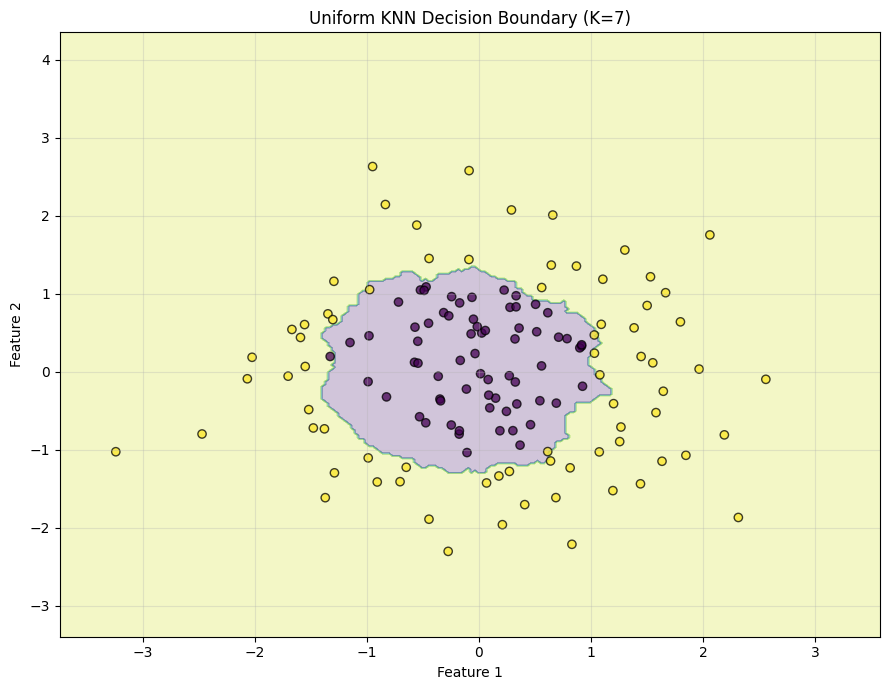

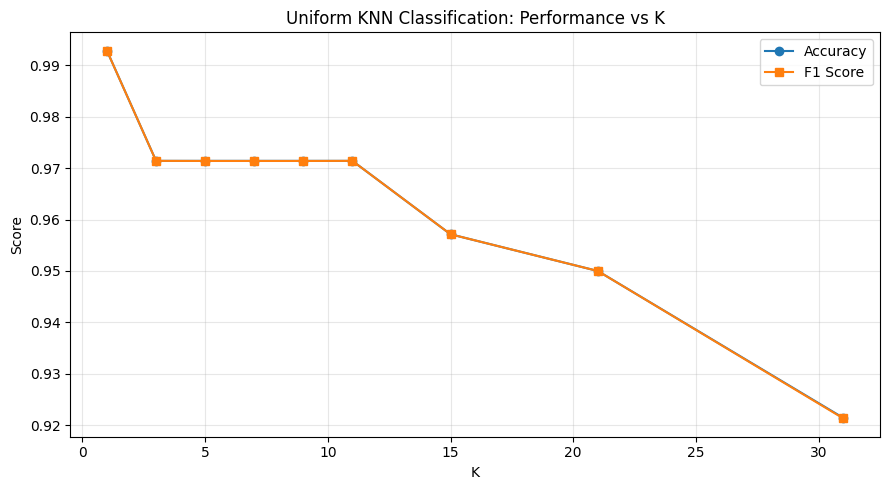

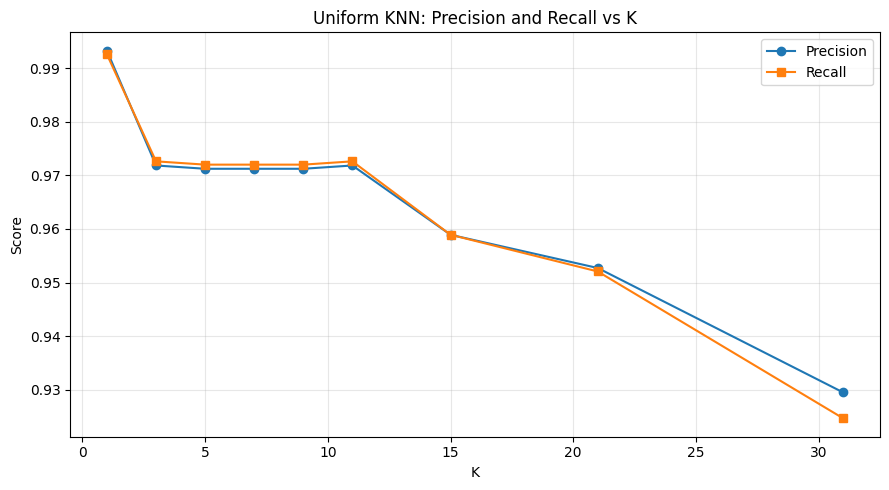



BEST K - CLASSIFICATION
Best K by Accuracy : 1
Best Accuracy      : 0.992857


UNIFORM KNN REGRESSION
K                  : 7
Weighting          : Uniform
Prediction         : Mean of K neighbors
Training samples   : 560
Testing samples    : 140
---------------------------------------------------------------------------
MAE                : 0.604781
MSE                : 0.689743
RMSE               : 0.830507
R²                 : 0.970205


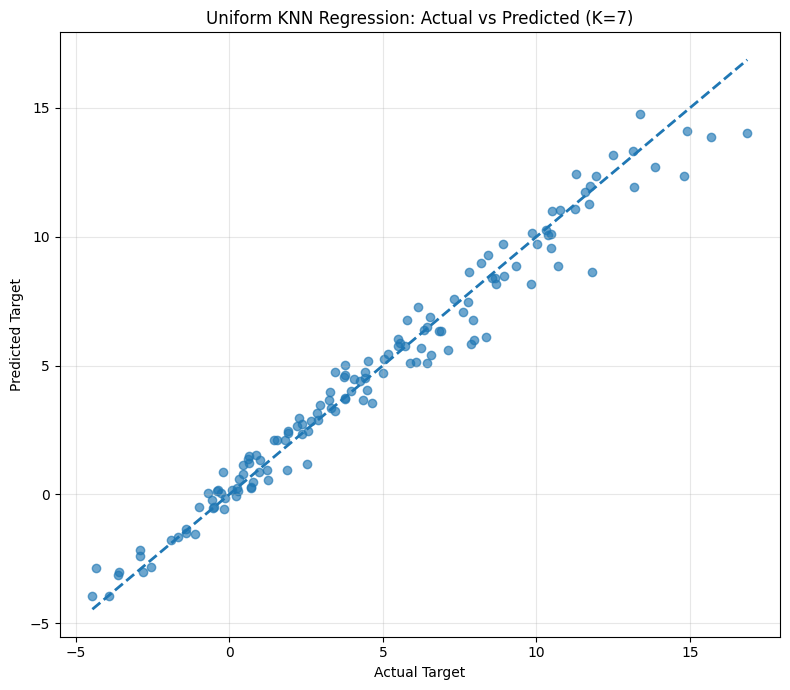

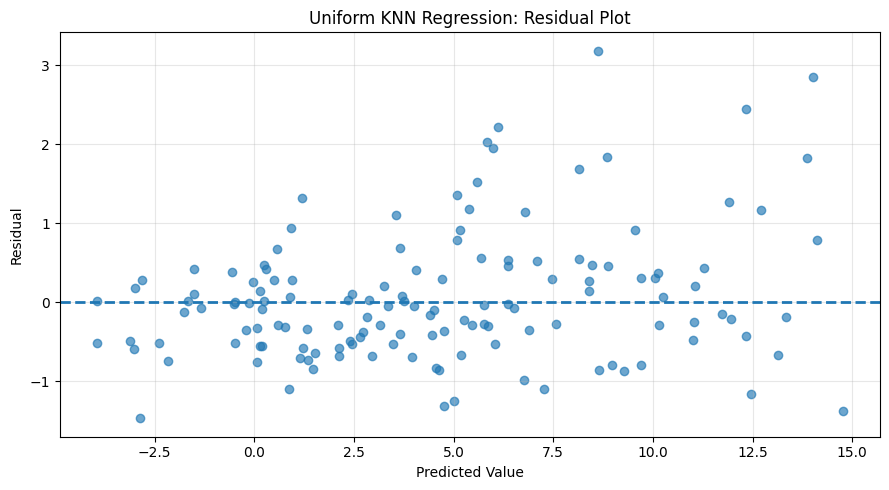

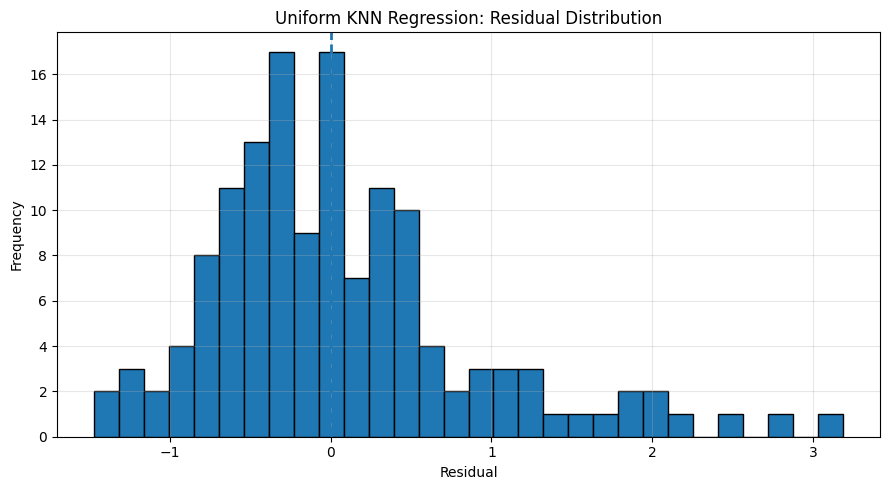

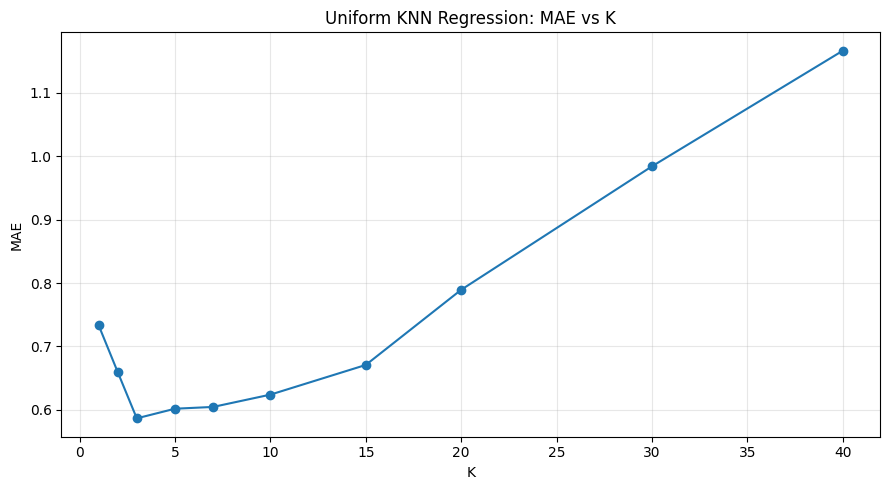

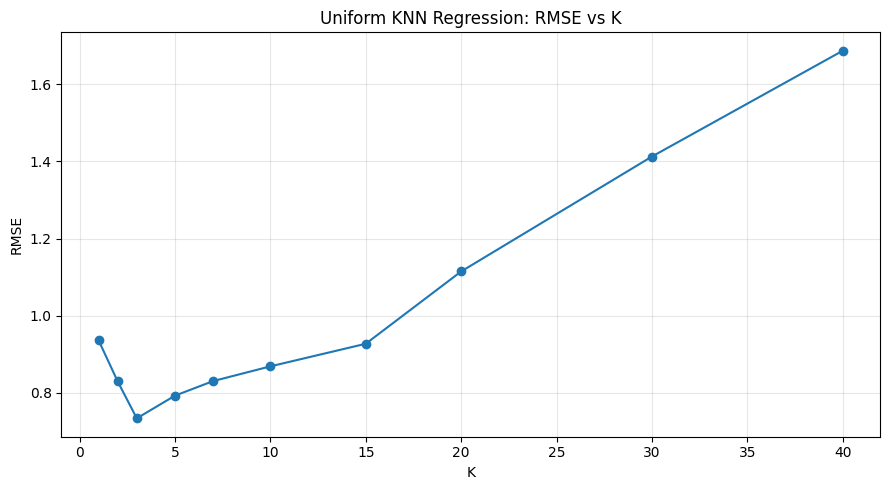

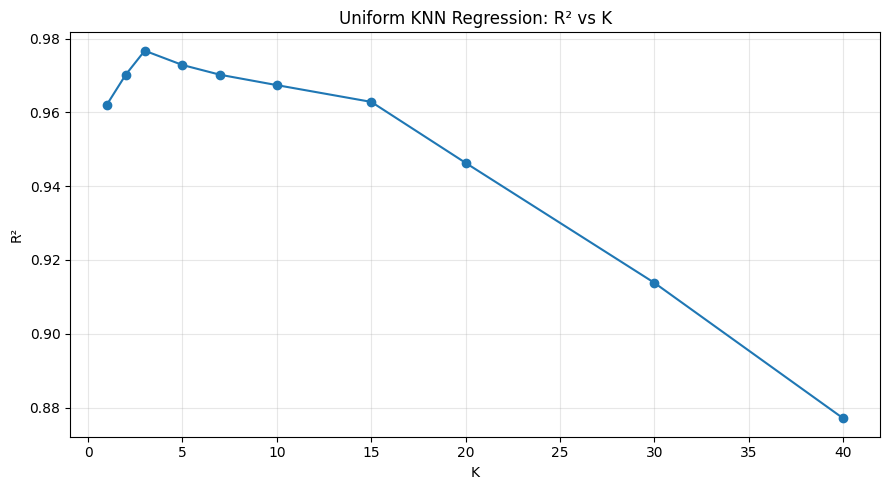



BEST K - REGRESSION
Best K by RMSE : 3
Best RMSE      : 0.733949
Best K by R²   : 3
Best R²        : 0.976730


UNIFORM KNN NEIGHBOR VOTING
Query point       : [-0.24415664  0.96408717]
K                 : 7
---------------------------------------------------------------------------
Neighbor | Distance | Class | Weight | Normalized Weight
---------------------------------------------------------------------------
       1 |   0.0090 |     0 |   1.00 |           0.1429
       2 |   0.1355 |     0 |   1.00 |           0.1429
       3 |   0.1870 |     0 |   1.00 |           0.1429
       4 |   0.2287 |     0 |   1.00 |           0.1429
       5 |   0.2288 |     0 |   1.00 |           0.1429
       6 |   0.2397 |     0 |   1.00 |           0.1429
       7 |   0.2471 |     0 |   1.00 |           0.1429


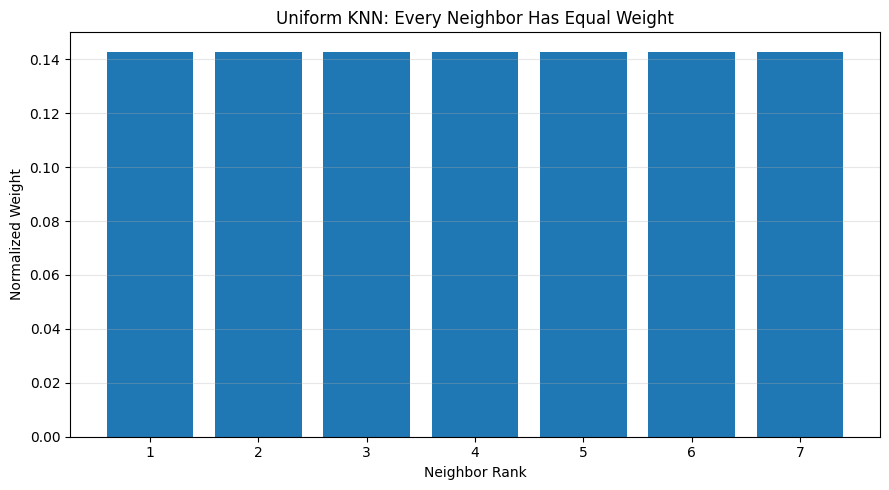



CONFUSION MATRIX
[[66  1]
 [ 3 70]]


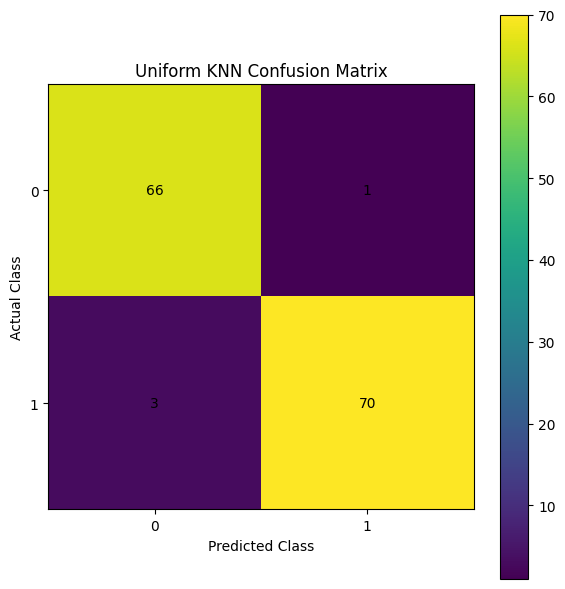



FINAL UNIFORM KNN SUMMARY

CLASSIFICATION
---------------------------------------------------------------------------
K                  : 7
Weighting          : Uniform
Voting             : Majority Vote
Accuracy           : 0.971429
Precision          : 0.971219
Recall             : 0.971989
F1 Score           : 0.971405

REGRESSION
---------------------------------------------------------------------------
K                  : 7
Weighting          : Uniform
Prediction         : Mean
MAE                : 0.604781
MSE                : 0.689743
RMSE               : 0.830507
R²                 : 0.970205


In [13]:
# ============================================================
# UNIFORM KNN
# Uniform Neighbor Weighting / Voting KNN
#
# FROM SCRATCH
# NO SCIKIT-LEARN
# ONLY NUMPY + MATPLOTLIB
#
# Includes:
#   1. Uniform KNN Classification
#   2. Uniform KNN Regression
#   3. Distance calculation
#   4. Majority voting
#   5. Uniform mean prediction
#   6. Classification evaluation
#   7. Regression evaluation
#   8. K comparison
#   9. Multiple plots
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


# ============================================================
# PART A
# UNIFORM KNN CLASSIFIER
# ============================================================

class UniformKNNClassifier:

    def __init__(
        self,
        n_neighbors=5,
        standardize=True
    ):

        self.n_neighbors = n_neighbors
        self.standardize = standardize

        self.X_train_ = None
        self.y_train_ = None

        self.mean_ = None
        self.std_ = None

    # --------------------------------------------------------
    # FIT
    # --------------------------------------------------------

    def fit(self, X, y):

        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        self.X_train_ = X.copy()
        self.y_train_ = y.copy()

        # Feature statistics
        self.mean_ = np.mean(
            X,
            axis=0
        )

        self.std_ = np.std(
            X,
            axis=0
        )

        # Avoid division by zero
        self.std_[self.std_ == 0] = 1.0

        return self

    # --------------------------------------------------------
    # STANDARDIZE
    # --------------------------------------------------------

    def _standardize(self, X):

        if not self.standardize:
            return X.copy()

        return (
            X - self.mean_
        ) / self.std_

    # --------------------------------------------------------
    # EUCLIDEAN DISTANCE
    # --------------------------------------------------------

    def _distance(self, x):

        distances = np.sqrt(
            np.sum(
                (
                    self.X_train_
                    -
                    x
                ) ** 2,
                axis=1
            )
        )

        return distances

    # --------------------------------------------------------
    # FIND K NEAREST NEIGHBORS
    # --------------------------------------------------------

    def _get_neighbors(self, x):

        distances = self._distance(x)

        # Sort distances
        neighbor_indices = np.argsort(
            distances
        )[:self.n_neighbors]

        return (
            neighbor_indices,
            distances[neighbor_indices]
        )

    # --------------------------------------------------------
    # UNIFORM VOTING
    #
    # Every neighbor gets weight = 1
    # --------------------------------------------------------

    def _uniform_vote(self, labels):

        unique_labels, counts = np.unique(
            labels,
            return_counts=True
        )

        # Maximum vote
        max_count = np.max(counts)

        candidates = unique_labels[
            counts == max_count
        ]

        # Deterministic tie-breaking
        prediction = np.min(candidates)

        return prediction

    # --------------------------------------------------------
    # PREDICT
    # --------------------------------------------------------

    def predict(self, X):

        X = np.asarray(
            X,
            dtype=float
        )

        X_scaled = self._standardize(X)

        X_train_scaled = self._standardize(
            self.X_train_
        )

        predictions = []

        for x in X_scaled:

            distances = np.sqrt(
                np.sum(
                    (
                        X_train_scaled
                        -
                        x
                    ) ** 2,
                    axis=1
                )
            )

            neighbor_indices = np.argsort(
                distances
            )[:self.n_neighbors]

            neighbor_labels = self.y_train_[
                neighbor_indices
            ]

            prediction = self._uniform_vote(
                neighbor_labels
            )

            predictions.append(
                prediction
            )

        return np.asarray(
            predictions
        )

    # --------------------------------------------------------
    # PREDICT PROBABILITIES
    # --------------------------------------------------------

    def predict_proba(self, X):

        X = np.asarray(
            X,
            dtype=float
        )

        X_scaled = self._standardize(X)

        X_train_scaled = self._standardize(
            self.X_train_
        )

        classes = np.unique(
            self.y_train_
        )

        probabilities = []

        for x in X_scaled:

            distances = np.sqrt(
                np.sum(
                    (
                        X_train_scaled
                        -
                        x
                    ) ** 2,
                    axis=1
                )
            )

            neighbor_indices = np.argsort(
                distances
            )[:self.n_neighbors]

            neighbor_labels = self.y_train_[
                neighbor_indices
            ]

            row_probability = []

            for c in classes:

                count = np.sum(
                    neighbor_labels == c
                )

                probability = (
                    count
                    /
                    self.n_neighbors
                )

                row_probability.append(
                    probability
                )

            probabilities.append(
                row_probability
            )

        return np.asarray(
            probabilities
        )

    # --------------------------------------------------------
    # SCORE
    # --------------------------------------------------------

    def score(self, X, y):

        predictions = self.predict(X)

        return np.mean(
            predictions == y
        )

    # --------------------------------------------------------
    # NEIGHBOR INFORMATION
    # --------------------------------------------------------

    def get_neighbors(self, x):

        x = np.asarray(
            x,
            dtype=float
        ).reshape(1, -1)

        x_scaled = self._standardize(
            x
        )[0]

        X_train_scaled = self._standardize(
            self.X_train_
        )

        distances = np.sqrt(
            np.sum(
                (
                    X_train_scaled
                    -
                    x_scaled
                ) ** 2,
                axis=1
            )
        )

        indices = np.argsort(
            distances
        )[:self.n_neighbors]

        labels = self.y_train_[
            indices
        ]

        # Uniform weights
        weights = np.ones(
            self.n_neighbors
        )

        normalized_weights = (
            weights
            /
            np.sum(weights)
        )

        return {
            "indices": indices,
            "distances": distances[indices],
            "labels": labels,
            "weights": weights,
            "normalized_weights":
                normalized_weights
        }


# ============================================================
# PART B
# UNIFORM KNN REGRESSOR
# ============================================================

class UniformKNNRegressor:

    def __init__(
        self,
        n_neighbors=5,
        standardize=True
    ):

        self.n_neighbors = n_neighbors
        self.standardize = standardize

        self.X_train_ = None
        self.y_train_ = None

        self.mean_ = None
        self.std_ = None

    # --------------------------------------------------------
    # FIT
    # --------------------------------------------------------

    def fit(self, X, y):

        X = np.asarray(
            X,
            dtype=float
        )

        y = np.asarray(
            y,
            dtype=float
        )

        self.X_train_ = X.copy()
        self.y_train_ = y.copy()

        self.mean_ = np.mean(
            X,
            axis=0
        )

        self.std_ = np.std(
            X,
            axis=0
        )

        self.std_[
            self.std_ == 0
        ] = 1.0

        return self

    # --------------------------------------------------------
    # STANDARDIZE
    # --------------------------------------------------------

    def _standardize(self, X):

        if not self.standardize:

            return X.copy()

        return (
            X - self.mean_
        ) / self.std_

    # --------------------------------------------------------
    # PREDICT
    #
    # Uniform weighting:
    #
    # w1 = w2 = ... = wK = 1
    #
    # y_hat = sum(y_i) / K
    # --------------------------------------------------------

    def predict(self, X):

        X = np.asarray(
            X,
            dtype=float
        )

        X_scaled = self._standardize(
            X
        )

        X_train_scaled = self._standardize(
            self.X_train_
        )

        predictions = []

        for x in X_scaled:

            distances = np.sqrt(
                np.sum(
                    (
                        X_train_scaled
                        -
                        x
                    ) ** 2,
                    axis=1
                )
            )

            neighbor_indices = np.argsort(
                distances
            )[:self.n_neighbors]

            neighbor_targets = self.y_train_[
                neighbor_indices
            ]

            # ------------------------------------------------
            # UNIFORM WEIGHTED MEAN
            # ------------------------------------------------

            prediction = np.mean(
                neighbor_targets
            )

            predictions.append(
                prediction
            )

        return np.asarray(
            predictions
        )

    # --------------------------------------------------------
    # SCORE
    # --------------------------------------------------------

    def score(self, X, y):

        y_pred = self.predict(X)

        ss_res = np.sum(
            (y - y_pred) ** 2
        )

        ss_tot = np.sum(
            (y - np.mean(y)) ** 2
        )

        return (
            1
            -
            ss_res / ss_tot
        )

    # --------------------------------------------------------
    # GET NEIGHBORS
    # --------------------------------------------------------

    def get_neighbors(self, x):

        x = np.asarray(
            x,
            dtype=float
        ).reshape(1, -1)

        x_scaled = self._standardize(
            x
        )[0]

        X_train_scaled = self._standardize(
            self.X_train_
        )

        distances = np.sqrt(
            np.sum(
                (
                    X_train_scaled
                    -
                    x_scaled
                ) ** 2,
                axis=1
            )
        )

        indices = np.argsort(
            distances
        )[:self.n_neighbors]

        values = self.y_train_[
            indices
        ]

        weights = np.ones(
            self.n_neighbors
        )

        normalized_weights = (
            weights
            /
            np.sum(weights)
        )

        return {
            "indices": indices,
            "distances": distances[indices],
            "values": values,
            "weights": weights,
            "normalized_weights":
                normalized_weights
        }


# ============================================================
# PART C
# CLASSIFICATION DATASET
# ============================================================

n_samples = 700

X_class = np.random.randn(
    n_samples,
    2
)

# Non-linear decision boundary
y_class = (
    X_class[:, 0] ** 2
    +
    X_class[:, 1] ** 2
    +
    0.4 * X_class[:, 0]
    >
    1.5
).astype(int)


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

indices = np.arange(
    n_samples
)

np.random.shuffle(
    indices
)

train_size = int(
    0.80 * n_samples
)

train_idx = indices[
    :train_size
]

test_idx = indices[
    train_size:
]

X_train_class = X_class[
    train_idx
]

y_train_class = y_class[
    train_idx
]

X_test_class = X_class[
    test_idx
]

y_test_class = y_class[
    test_idx
]


# ============================================================
# CLASSIFICATION MODEL
# ============================================================

K_CLASS = 7

knn_classifier = UniformKNNClassifier(
    n_neighbors=K_CLASS,
    standardize=True
)

knn_classifier.fit(
    X_train_class,
    y_train_class
)

y_pred_class = knn_classifier.predict(
    X_test_class
)


# ============================================================
# CLASSIFICATION METRICS
# ============================================================

def classification_metrics(
    y_true,
    y_pred
):

    accuracy = np.mean(
        y_true == y_pred
    )

    classes = np.unique(
        y_true
    )

    precision_list = []
    recall_list = []
    f1_list = []

    for c in classes:

        tp = np.sum(
            (y_true == c)
            &
            (y_pred == c)
        )

        fp = np.sum(
            (y_true != c)
            &
            (y_pred == c)
        )

        fn = np.sum(
            (y_true == c)
            &
            (y_pred != c)
        )

        precision = (
            tp /
            (tp + fp)
            if (tp + fp) > 0
            else 0
        )

        recall = (
            tp /
            (tp + fn)
            if (tp + fn) > 0
            else 0
        )

        f1 = (
            2
            *
            precision
            *
            recall
            /
            (precision + recall)
            if (precision + recall) > 0
            else 0
        )

        precision_list.append(
            precision
        )

        recall_list.append(
            recall
        )

        f1_list.append(
            f1
        )

    precision_macro = np.mean(
        precision_list
    )

    recall_macro = np.mean(
        recall_list
    )

    f1_macro = np.mean(
        f1_list
    )

    return (
        accuracy,
        precision_macro,
        recall_macro,
        f1_macro
    )


accuracy, precision, recall, f1 = \
    classification_metrics(
        y_test_class,
        y_pred_class
    )


# ============================================================
# CLASSIFICATION OUTPUT
# ============================================================

print("=" * 75)
print("UNIFORM KNN CLASSIFICATION")
print("=" * 75)

print(
    f"K                  : {K_CLASS}"
)

print(
    "Weighting          : Uniform"
)

print(
    "Voting             : Majority Vote"
)

print(
    f"Training samples   : "
    f"{len(X_train_class)}"
)

print(
    f"Testing samples    : "
    f"{len(X_test_class)}"
)

print("-" * 75)

print(
    f"Accuracy           : "
    f"{accuracy:.6f}"
)

print(
    f"Precision          : "
    f"{precision:.6f}"
)

print(
    f"Recall             : "
    f"{recall:.6f}"
)

print(
    f"F1 Score           : "
    f"{f1:.6f}"
)

print("=" * 75)


# ============================================================
# CLASSIFICATION DECISION BOUNDARY
# ============================================================

x_min = X_class[:, 0].min() - 0.5
x_max = X_class[:, 0].max() + 0.5

y_min = X_class[:, 1].min() - 0.5
y_max = X_class[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(
        x_min,
        x_max,
        250
    ),
    np.linspace(
        y_min,
        y_max,
        250
    )
)

grid = np.c_[
    xx.ravel(),
    yy.ravel()
]

grid_prediction = knn_classifier.predict(
    grid
)

grid_prediction = grid_prediction.reshape(
    xx.shape
)


plt.figure(
    figsize=(9, 7)
)

plt.contourf(
    xx,
    yy,
    grid_prediction,
    alpha=0.25
)

plt.scatter(
    X_test_class[:, 0],
    X_test_class[:, 1],
    c=y_test_class,
    edgecolor="black",
    alpha=0.75
)

plt.xlabel(
    "Feature 1"
)

plt.ylabel(
    "Feature 2"
)

plt.title(
    f"Uniform KNN Decision Boundary (K={K_CLASS})"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# CLASSIFICATION K-WISE EVALUATION
# ============================================================

k_values_class = [
    1,
    3,
    5,
    7,
    9,
    11,
    15,
    21,
    31
]

accuracy_values = []
precision_values = []
recall_values = []
f1_values = []


for k in k_values_class:

    model = UniformKNNClassifier(
        n_neighbors=k,
        standardize=True
    )

    model.fit(
        X_train_class,
        y_train_class
    )

    predictions = model.predict(
        X_test_class
    )

    acc, prec, rec, f1_score = \
        classification_metrics(
            y_test_class,
            predictions
        )

    accuracy_values.append(acc)
    precision_values.append(prec)
    recall_values.append(rec)
    f1_values.append(f1_score)


# ============================================================
# ACCURACY vs K
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    k_values_class,
    accuracy_values,
    marker="o",
    label="Accuracy"
)

plt.plot(
    k_values_class,
    f1_values,
    marker="s",
    label="F1 Score"
)

plt.xlabel(
    "K"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Uniform KNN Classification: Performance vs K"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# PRECISION / RECALL vs K
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    k_values_class,
    precision_values,
    marker="o",
    label="Precision"
)

plt.plot(
    k_values_class,
    recall_values,
    marker="s",
    label="Recall"
)

plt.xlabel(
    "K"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Uniform KNN: Precision and Recall vs K"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# BEST K FOR CLASSIFICATION
# ============================================================

best_class_index = np.argmax(
    accuracy_values
)

best_class_k = k_values_class[
    best_class_index
]

print("\n")
print("=" * 75)
print("BEST K - CLASSIFICATION")
print("=" * 75)

print(
    f"Best K by Accuracy : "
    f"{best_class_k}"
)

print(
    f"Best Accuracy      : "
    f"{accuracy_values[best_class_index]:.6f}"
)

print("=" * 75)


# ============================================================
# PART D
# REGRESSION DATASET
# ============================================================

n_samples_reg = 700

X_reg = np.random.uniform(
    -5,
    5,
    size=(n_samples_reg, 2)
)

# Non-linear target
y_reg = (
    3 * np.sin(X_reg[:, 0])
    +
    0.5 * X_reg[:, 1] ** 2
    +
    0.8 * X_reg[:, 0]
    +
    np.random.normal(
        0,
        0.4,
        n_samples_reg
    )
)


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

indices = np.arange(
    n_samples_reg
)

np.random.shuffle(
    indices
)

train_size_reg = int(
    0.80 * n_samples_reg
)

train_idx_reg = indices[
    :train_size_reg
]

test_idx_reg = indices[
    train_size_reg:
]

X_train_reg = X_reg[
    train_idx_reg
]

y_train_reg = y_reg[
    train_idx_reg
]

X_test_reg = X_reg[
    test_idx_reg
]

y_test_reg = y_reg[
    test_idx_reg
]


# ============================================================
# REGRESSION MODEL
# ============================================================

K_REG = 7

knn_regressor = UniformKNNRegressor(
    n_neighbors=K_REG,
    standardize=True
)

knn_regressor.fit(
    X_train_reg,
    y_train_reg
)

y_pred_reg = knn_regressor.predict(
    X_test_reg
)


# ============================================================
# REGRESSION METRICS
# ============================================================

def regression_metrics(
    y_true,
    y_pred
):

    errors = (
        y_true
        -
        y_pred
    )

    mae_value = np.mean(
        np.abs(errors)
    )

    mse_value = np.mean(
        errors ** 2
    )

    rmse_value = np.sqrt(
        mse_value
    )

    ss_res = np.sum(
        errors ** 2
    )

    ss_tot = np.sum(
        (
            y_true
            -
            np.mean(y_true)
        ) ** 2
    )

    r2_value = (
        1
        -
        ss_res / ss_tot
    )

    return (
        mae_value,
        mse_value,
        rmse_value,
        r2_value
    )


MAE, MSE, RMSE, R2 = \
    regression_metrics(
        y_test_reg,
        y_pred_reg
    )


# ============================================================
# REGRESSION OUTPUT
# ============================================================

print("\n")
print("=" * 75)
print("UNIFORM KNN REGRESSION")
print("=" * 75)

print(
    f"K                  : {K_REG}"
)

print(
    "Weighting          : Uniform"
)

print(
    "Prediction         : Mean of K neighbors"
)

print(
    f"Training samples   : "
    f"{len(X_train_reg)}"
)

print(
    f"Testing samples    : "
    f"{len(X_test_reg)}"
)

print("-" * 75)

print(
    f"MAE                : "
    f"{MAE:.6f}"
)

print(
    f"MSE                : "
    f"{MSE:.6f}"
)

print(
    f"RMSE               : "
    f"{RMSE:.6f}"
)

print(
    f"R²                 : "
    f"{R2:.6f}"
)

print("=" * 75)


# ============================================================
# ACTUAL vs PREDICTED
# ============================================================

plt.figure(
    figsize=(8, 7)
)

plt.scatter(
    y_test_reg,
    y_pred_reg,
    alpha=0.65
)

minimum = min(
    y_test_reg.min(),
    y_pred_reg.min()
)

maximum = max(
    y_test_reg.max(),
    y_pred_reg.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Actual Target"
)

plt.ylabel(
    "Predicted Target"
)

plt.title(
    f"Uniform KNN Regression: Actual vs Predicted (K={K_REG})"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# RESIDUAL PLOT
# ============================================================

residuals = (
    y_test_reg
    -
    y_pred_reg
)

plt.figure(
    figsize=(9, 5)
)

plt.scatter(
    y_pred_reg,
    residuals,
    alpha=0.65
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Predicted Value"
)

plt.ylabel(
    "Residual"
)

plt.title(
    "Uniform KNN Regression: Residual Plot"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.hist(
    residuals,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Residual"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Uniform KNN Regression: Residual Distribution"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# REGRESSION K-WISE EVALUATION
# ============================================================

k_values_reg = [
    1,
    2,
    3,
    5,
    7,
    10,
    15,
    20,
    30,
    40
]

reg_mae = []
reg_mse = []
reg_rmse = []
reg_r2 = []


for k in k_values_reg:

    model = UniformKNNRegressor(
        n_neighbors=k,
        standardize=True
    )

    model.fit(
        X_train_reg,
        y_train_reg
    )

    predictions = model.predict(
        X_test_reg
    )

    mae_value, mse_value, \
    rmse_value, r2_value = \
        regression_metrics(
            y_test_reg,
            predictions
        )

    reg_mae.append(
        mae_value
    )

    reg_mse.append(
        mse_value
    )

    reg_rmse.append(
        rmse_value
    )

    reg_r2.append(
        r2_value
    )


# ============================================================
# MAE vs K
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    k_values_reg,
    reg_mae,
    marker="o"
)

plt.xlabel(
    "K"
)

plt.ylabel(
    "MAE"
)

plt.title(
    "Uniform KNN Regression: MAE vs K"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# RMSE vs K
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    k_values_reg,
    reg_rmse,
    marker="o"
)

plt.xlabel(
    "K"
)

plt.ylabel(
    "RMSE"
)

plt.title(
    "Uniform KNN Regression: RMSE vs K"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# R² vs K
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    k_values_reg,
    reg_r2,
    marker="o"
)

plt.xlabel(
    "K"
)

plt.ylabel(
    "R²"
)

plt.title(
    "Uniform KNN Regression: R² vs K"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# BEST K FOR REGRESSION
# ============================================================

best_reg_rmse_index = np.argmin(
    reg_rmse
)

best_reg_r2_index = np.argmax(
    reg_r2
)

print("\n")
print("=" * 75)
print("BEST K - REGRESSION")
print("=" * 75)

print(
    f"Best K by RMSE : "
    f"{k_values_reg[best_reg_rmse_index]}"
)

print(
    f"Best RMSE      : "
    f"{reg_rmse[best_reg_rmse_index]:.6f}"
)

print(
    f"Best K by R²   : "
    f"{k_values_reg[best_reg_r2_index]}"
)

print(
    f"Best R²        : "
    f"{reg_r2[best_reg_r2_index]:.6f}"
)

print("=" * 75)


# ============================================================
# PART E
# NEIGHBOR WEIGHT ANALYSIS - CLASSIFICATION
# ============================================================

query_index = 0

query_point = X_test_class[
    query_index
]

neighbor_info = \
    knn_classifier.get_neighbors(
        query_point
    )

print("\n")
print("=" * 75)
print("UNIFORM KNN NEIGHBOR VOTING")
print("=" * 75)

print(
    f"Query point       : "
    f"{query_point}"
)

print(
    f"K                 : "
    f"{K_CLASS}"
)

print("-" * 75)

print(
    "Neighbor | Distance | Class | "
    "Weight | Normalized Weight"
)

print("-" * 75)

for i in range(
    len(
        neighbor_info["indices"]
    )
):

    print(
        f"{i+1:8d} | "
        f"{neighbor_info['distances'][i]:8.4f} | "
        f"{neighbor_info['labels'][i]:5d} | "
        f"{neighbor_info['weights'][i]:6.2f} | "
        f"{neighbor_info['normalized_weights'][i]:16.4f}"
    )

print("=" * 75)


# ============================================================
# UNIFORM WEIGHT PLOT
# ============================================================

neighbor_numbers = np.arange(
    1,
    K_CLASS + 1
)

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    neighbor_numbers,
    neighbor_info[
        "normalized_weights"
    ]
)

plt.xlabel(
    "Neighbor Rank"
)

plt.ylabel(
    "Normalized Weight"
)

plt.title(
    "Uniform KNN: Every Neighbor Has Equal Weight"
)

plt.xticks(
    neighbor_numbers
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# PART F
# CLASSIFICATION CONFUSION MATRIX FROM SCRATCH
# ============================================================

classes = np.unique(
    y_test_class
)

confusion_matrix = np.zeros(
    (
        len(classes),
        len(classes)
    ),
    dtype=int
)

for true_value, pred_value in zip(
    y_test_class,
    y_pred_class
):

    true_index = np.where(
        classes == true_value
    )[0][0]

    pred_index = np.where(
        classes == pred_value
    )[0][0]

    confusion_matrix[
        true_index,
        pred_index
    ] += 1


print("\n")
print("=" * 75)
print("CONFUSION MATRIX")
print("=" * 75)

print(
    confusion_matrix
)

print("=" * 75)


# ============================================================
# CONFUSION MATRIX PLOT
# ============================================================

plt.figure(
    figsize=(6, 6)
)

plt.imshow(
    confusion_matrix,
    interpolation="nearest"
)

plt.title(
    "Uniform KNN Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.xticks(
    range(len(classes)),
    classes
)

plt.yticks(
    range(len(classes)),
    classes
)

for i in range(
    len(classes)
):

    for j in range(
        len(classes)
    ):

        plt.text(
            j,
            i,
            confusion_matrix[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

plt.show()


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 75)
print("FINAL UNIFORM KNN SUMMARY")
print("=" * 75)

print("\nCLASSIFICATION")
print("-" * 75)

print(
    f"K                  : "
    f"{K_CLASS}"
)

print(
    "Weighting          : Uniform"
)

print(
    "Voting             : Majority Vote"
)

print(
    f"Accuracy           : "
    f"{accuracy:.6f}"
)

print(
    f"Precision          : "
    f"{precision:.6f}"
)

print(
    f"Recall             : "
    f"{recall:.6f}"
)

print(
    f"F1 Score           : "
    f"{f1:.6f}"
)

print("\nREGRESSION")
print("-" * 75)

print(
    f"K                  : "
    f"{K_REG}"
)

print(
    "Weighting          : Uniform"
)

print(
    "Prediction         : Mean"
)

print(
    f"MAE                : "
    f"{MAE:.6f}"
)

print(
    f"MSE                : "
    f"{MSE:.6f}"
)

print(
    f"RMSE               : "
    f"{RMSE:.6f}"
)

print(
    f"R²                 : "
    f"{R2:.6f}"
)

print("=" * 75)

INVERSE DISTANCE WEIGHTED KNN - CLASSIFICATION
Accuracy    : 0.9812
Precision   : 0.9817
Recall      : 0.9806
F1          : 0.9811

Confusion Matrix:
[[86  1]
 [ 2 71]]


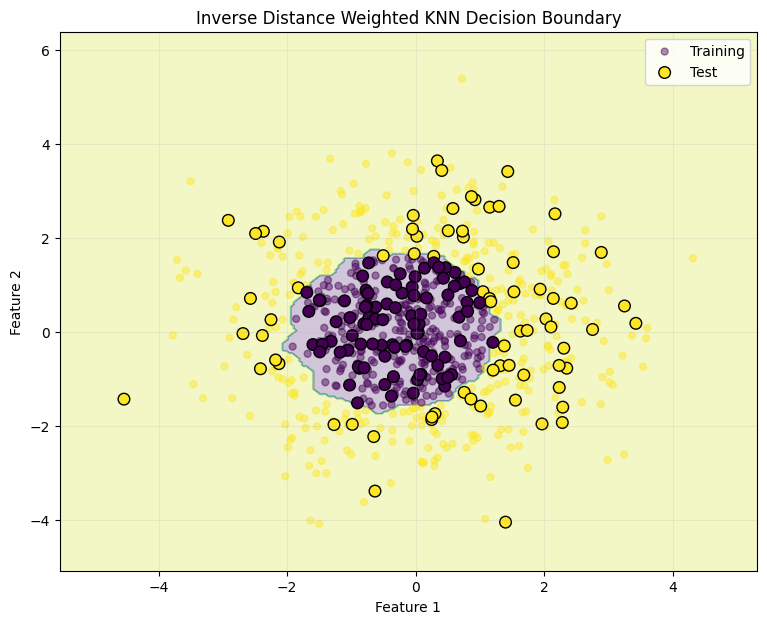

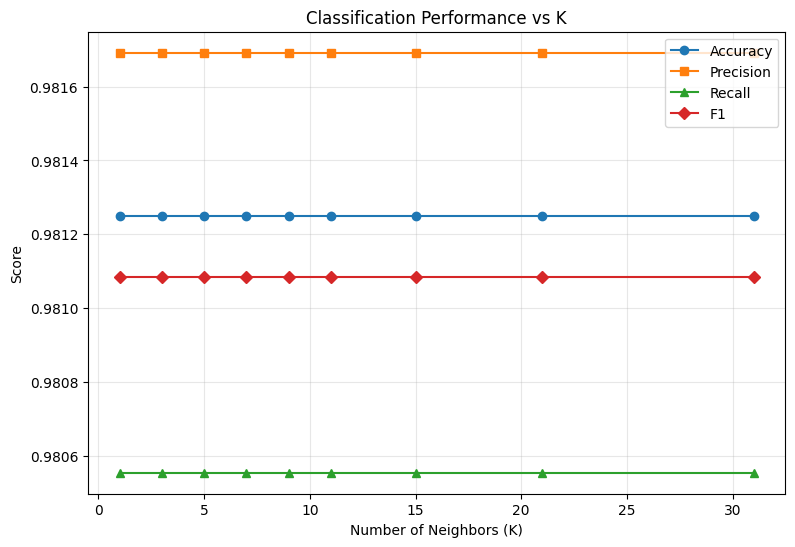

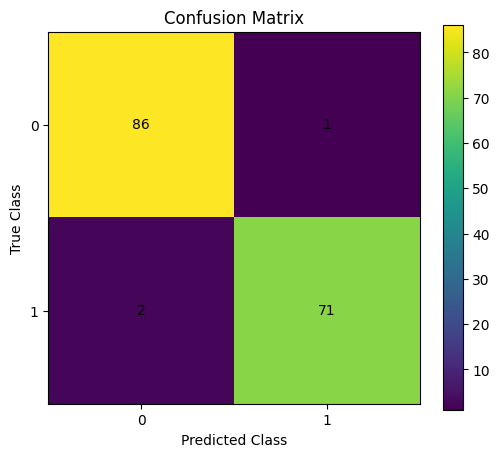


CLASSIFICATION NEIGHBOR ANALYSIS
Query point: [ 0.29973124 -1.74403429]

Neighbor index:
[507 422 249 566 182 227 285]

Neighbor distances:
[0.06673492 0.11658518 0.13400924 0.1345293  0.14115865 0.1470966
 0.1674934 ]

Neighbor labels:
[1 1 1 1 1 1 1]

Raw inverse-distance weights:
[224.53997457  73.57213057  55.68401212  55.25431621  50.18627848
  46.21625267  35.64548971]

Normalized weights:
[0.41497064 0.1359681  0.10290921 0.10211509 0.09274889 0.08541191
 0.06587616]


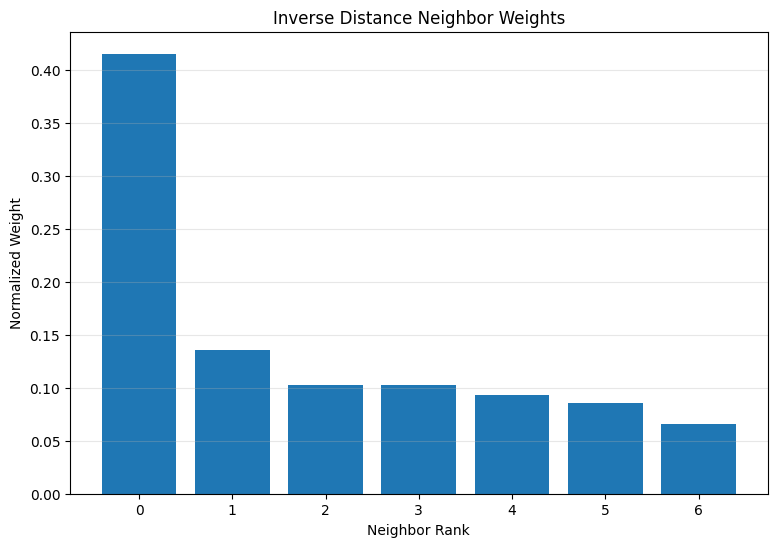

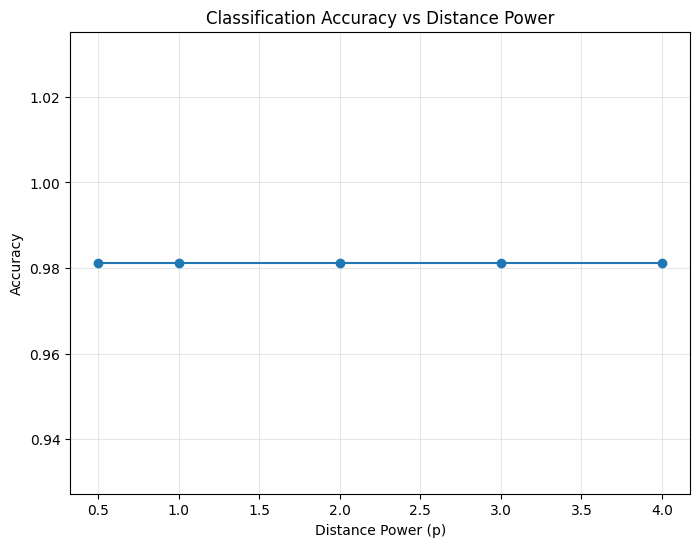


INVERSE DISTANCE WEIGHTED KNN - REGRESSION
MAE         : 0.5263
MSE         : 0.4631
RMSE        : 0.6805
R2          : 0.9816
MAPE        : 82.9420


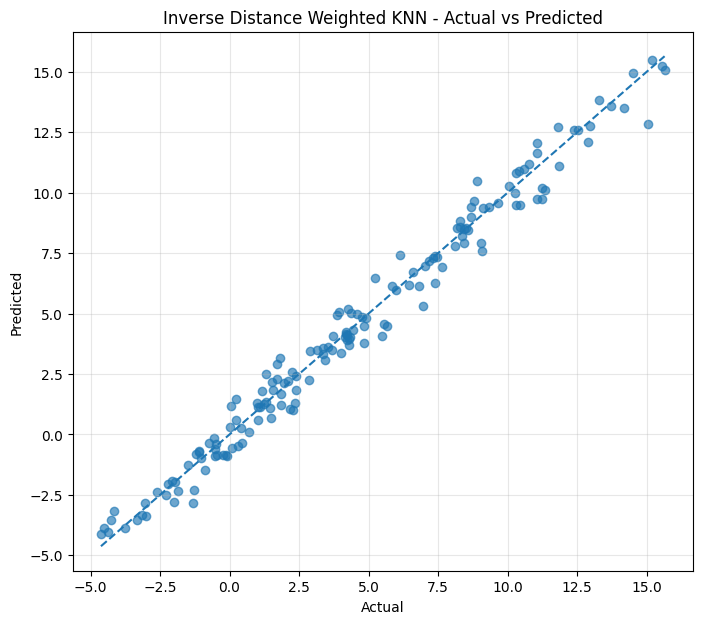

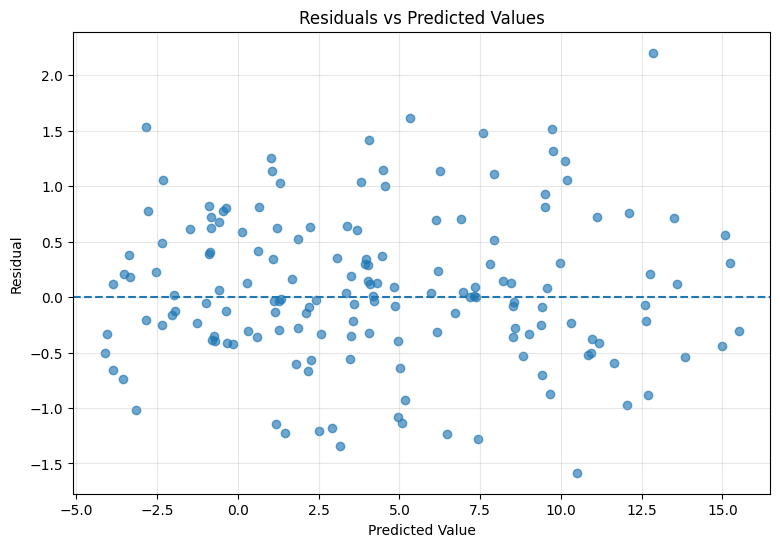

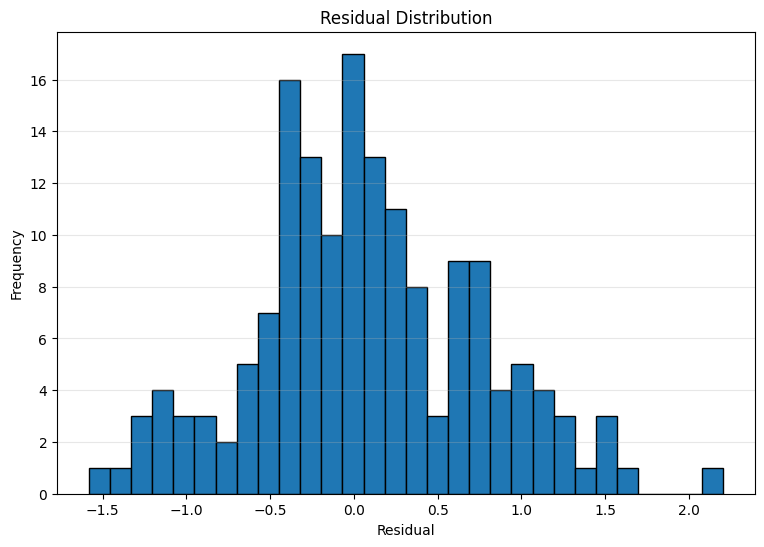

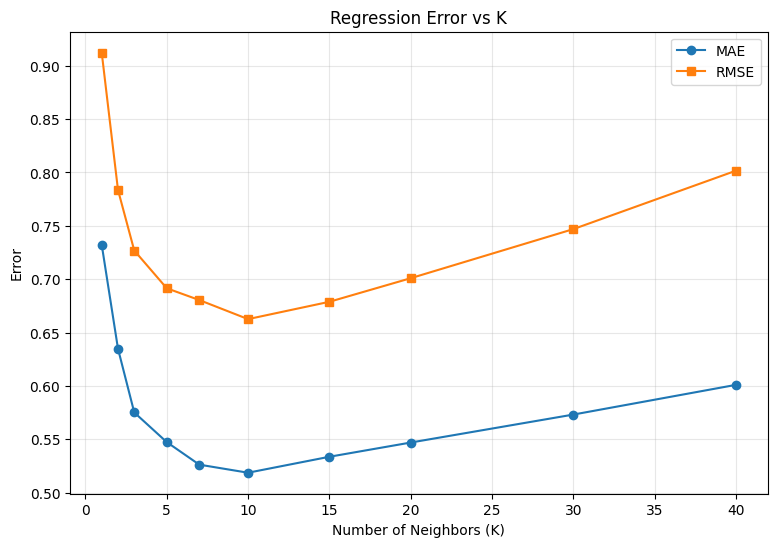

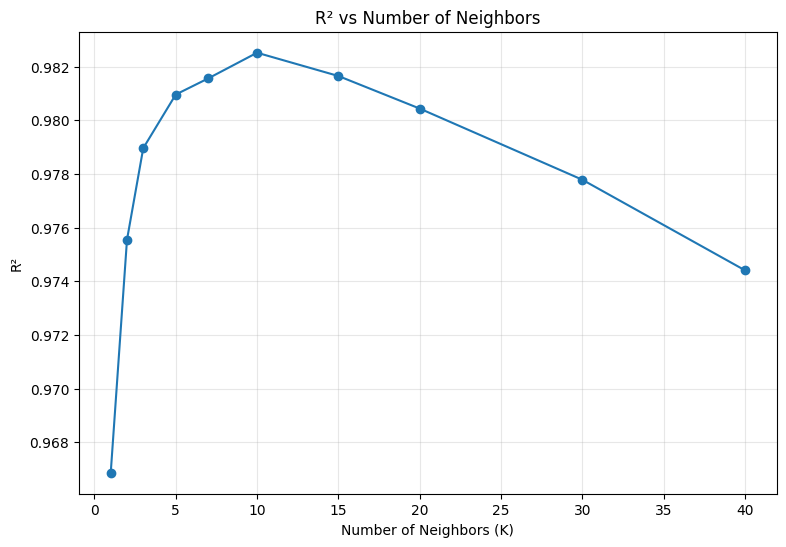

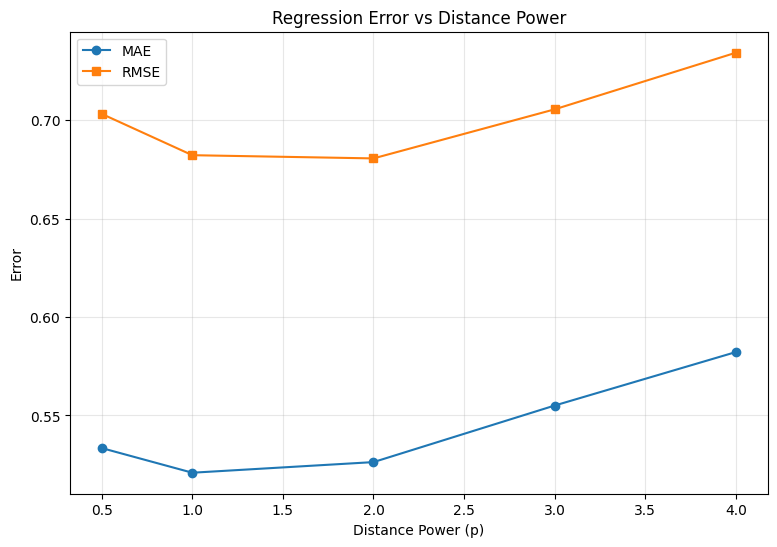

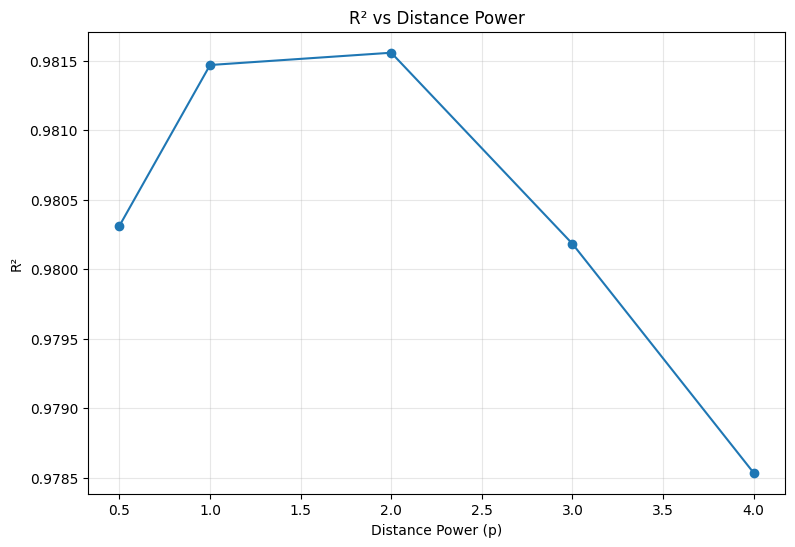


REGRESSION NEIGHBOR ANALYSIS
Query point: [3.789789   0.71772352]

Neighbor distances:
[0.04329182 0.18511766 0.18613833 0.20920402 0.2119958  0.22186019
 0.23685413]

Neighbor targets:
[2.1765416  1.76017944 2.9515167  1.42606889 1.4526423  2.40936658
 3.22498149]

Raw weights:
[533.56619823  29.18127695  28.86213022  22.8486194   22.25079191
  20.31614182  17.82535018]

Normalized weights:
[0.79064354 0.0432411  0.04276818 0.0338573  0.03297144 0.03010466
 0.02641378]


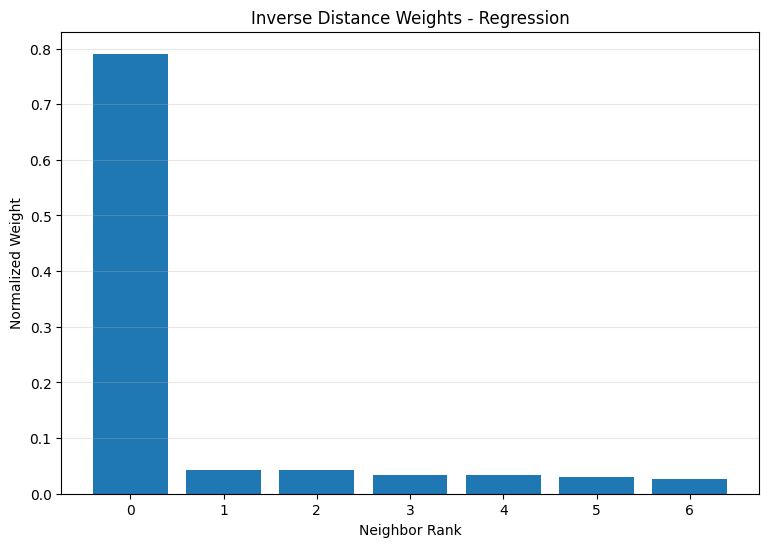


FINAL SUMMARY

Classification:
Accuracy    : 0.9812
Precision   : 0.9817
Recall      : 0.9806
F1          : 0.9811

Regression:
MAE         : 0.5263
MSE         : 0.4631
RMSE        : 0.6805
R2          : 0.9816
MAPE        : 82.9420


In [14]:
# ============================================================
# INVERSE DISTANCE WEIGHTED KNN
# FROM SCRATCH USING NUMPY + MATPLOTLIB ONLY
# NO SCIKIT-LEARN
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


# ============================================================
# 1. HELPER FUNCTIONS
# ============================================================

def train_test_split_scratch(X, y, test_size=0.2, random_state=42):
    """
    Simple train-test split implemented from scratch.
    """

    rng = np.random.default_rng(random_state)

    n_samples = X.shape[0]

    indices = np.arange(n_samples)
    rng.shuffle(indices)

    n_test = int(n_samples * test_size)

    test_idx = indices[:n_test]
    train_idx = indices[n_test:]

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    return X_train, X_test, y_train, y_test


# ============================================================
# 2. STANDARDIZATION
# ============================================================

class StandardScalerScratch:

    def fit(self, X):

        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)

        # Prevent division by zero
        self.std_[self.std_ == 0] = 1.0

        return self

    def transform(self, X):

        return (X - self.mean_) / self.std_

    def fit_transform(self, X):

        self.fit(X)

        return self.transform(X)


# ============================================================
# 3. INVERSE DISTANCE WEIGHTED KNN CLASSIFIER
# ============================================================

class InverseDistanceKNNClassifier:

    def __init__(
        self,
        n_neighbors=5,
        power=2.0,
        standardize=True,
        epsilon=1e-12
    ):

        self.n_neighbors = n_neighbors
        self.power = power
        self.standardize = standardize
        self.epsilon = epsilon

    # --------------------------------------------------------
    # FIT
    # --------------------------------------------------------

    def fit(self, X, y):

        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        if X.ndim != 2:
            raise ValueError("X must be a 2D array.")

        if len(X) != len(y):
            raise ValueError(
                "X and y must contain the same number of samples."
            )

        if self.n_neighbors <= 0:
            raise ValueError("n_neighbors must be greater than 0.")

        if self.power <= 0:
            raise ValueError("power must be greater than 0.")

        self.scaler_ = None

        if self.standardize:

            self.scaler_ = StandardScalerScratch()

            self.X_train_ = self.scaler_.fit_transform(X)

        else:

            self.X_train_ = X.copy()

        self.y_train_ = y.copy()

        self.classes_ = np.unique(y)

        return self

    # --------------------------------------------------------
    # TRANSFORM INPUT
    # --------------------------------------------------------

    def _transform(self, X):

        X = np.asarray(X, dtype=float)

        if self.standardize:

            return self.scaler_.transform(X)

        return X

    # --------------------------------------------------------
    # EUCLIDEAN DISTANCE
    # --------------------------------------------------------

    def _distance(self, x):

        distances = np.sqrt(
            np.sum(
                (self.X_train_ - x) ** 2,
                axis=1
            )
        )

        return distances

    # --------------------------------------------------------
    # INVERSE DISTANCE WEIGHTS
    # --------------------------------------------------------

    def _inverse_distance_weights(self, distances):

        weights = 1.0 / (
            distances ** self.power + self.epsilon
        )

        return weights

    # --------------------------------------------------------
    # GET K NEIGHBORS
    # --------------------------------------------------------

    def _get_neighbors(self, x):

        distances = self._distance(x)

        k = min(self.n_neighbors, len(self.X_train_))

        neighbor_indices = np.argpartition(
            distances,
            k - 1
        )[:k]

        # Sort selected neighbors by distance
        neighbor_indices = neighbor_indices[
            np.argsort(distances[neighbor_indices])
        ]

        neighbor_distances = distances[neighbor_indices]

        neighbor_labels = self.y_train_[neighbor_indices]

        return (
            neighbor_indices,
            neighbor_distances,
            neighbor_labels
        )

    # --------------------------------------------------------
    # WEIGHTED VOTE
    # --------------------------------------------------------

    def _weighted_vote(
        self,
        neighbor_labels,
        neighbor_distances
    ):

        weights = self._inverse_distance_weights(
            neighbor_distances
        )

        scores = {}

        for cls in self.classes_:

            class_mask = (
                neighbor_labels == cls
            )

            scores[cls] = np.sum(
                weights[class_mask]
            )

        # Maximum weighted vote
        best_score = max(scores.values())

        candidates = [
            cls
            for cls, score in scores.items()
            if np.isclose(score, best_score)
        ]

        # Deterministic tie breaking
        prediction = min(candidates)

        return prediction

    # --------------------------------------------------------
    # PREDICT
    # --------------------------------------------------------

    def predict(self, X):

        X = np.asarray(X, dtype=float)

        X_scaled = self._transform(X)

        predictions = []

        for x in X_scaled:

            (
                indices,
                distances,
                labels
            ) = self._get_neighbors(x)

            prediction = self._weighted_vote(
                labels,
                distances
            )

            predictions.append(prediction)

        return np.asarray(predictions)

    # --------------------------------------------------------
    # PREDICT PROBABILITY
    # --------------------------------------------------------

    def predict_proba(self, X):

        X = np.asarray(X, dtype=float)

        X_scaled = self._transform(X)

        probabilities = []

        for x in X_scaled:

            (
                indices,
                distances,
                labels
            ) = self._get_neighbors(x)

            weights = self._inverse_distance_weights(
                distances
            )

            class_scores = []

            for cls in self.classes_:

                score = np.sum(
                    weights[labels == cls]
                )

                class_scores.append(score)

            class_scores = np.asarray(class_scores)

            total = np.sum(class_scores)

            if total == 0:

                class_scores = np.ones(
                    len(self.classes_)
                ) / len(self.classes_)

            else:

                class_scores /= total

            probabilities.append(class_scores)

        return np.asarray(probabilities)

    # --------------------------------------------------------
    # SCORE
    # --------------------------------------------------------

    def score(self, X, y):

        predictions = self.predict(X)

        return np.mean(predictions == y)

    # --------------------------------------------------------
    # NEIGHBOR INFORMATION
    # --------------------------------------------------------

    def get_neighbors(self, x):

        x = np.asarray(x, dtype=float).reshape(1, -1)

        x_scaled = self._transform(x)[0]

        (
            indices,
            distances,
            labels
        ) = self._get_neighbors(x_scaled)

        weights = self._inverse_distance_weights(
            distances
        )

        normalized_weights = (
            weights / np.sum(weights)
        )

        return {
            "indices": indices,
            "distances": distances,
            "labels": labels,
            "weights": weights,
            "normalized_weights": normalized_weights
        }


# ============================================================
# 4. INVERSE DISTANCE WEIGHTED KNN REGRESSOR
# ============================================================

class InverseDistanceKNNRegressor:

    def __init__(
        self,
        n_neighbors=5,
        power=2.0,
        standardize=True,
        epsilon=1e-12
    ):

        self.n_neighbors = n_neighbors
        self.power = power
        self.standardize = standardize
        self.epsilon = epsilon

    # --------------------------------------------------------
    # FIT
    # --------------------------------------------------------

    def fit(self, X, y):

        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        if X.ndim != 2:
            raise ValueError("X must be a 2D array.")

        if len(X) != len(y):
            raise ValueError(
                "X and y must have the same number of samples."
            )

        if self.n_neighbors <= 0:
            raise ValueError(
                "n_neighbors must be greater than 0."
            )

        if self.power <= 0:
            raise ValueError(
                "power must be greater than 0."
            )

        self.scaler_ = None

        if self.standardize:

            self.scaler_ = StandardScalerScratch()

            self.X_train_ = self.scaler_.fit_transform(X)

        else:

            self.X_train_ = X.copy()

        self.y_train_ = y.copy()

        return self

    # --------------------------------------------------------
    # TRANSFORM
    # --------------------------------------------------------

    def _transform(self, X):

        if self.standardize:

            return self.scaler_.transform(X)

        return X

    # --------------------------------------------------------
    # GET NEIGHBORS
    # --------------------------------------------------------

    def _get_neighbors(self, x):

        distances = np.sqrt(
            np.sum(
                (self.X_train_ - x) ** 2,
                axis=1
            )
        )

        k = min(
            self.n_neighbors,
            len(self.X_train_)
        )

        indices = np.argpartition(
            distances,
            k - 1
        )[:k]

        indices = indices[
            np.argsort(distances[indices])
        ]

        return (
            indices,
            distances[indices]
        )

    # --------------------------------------------------------
    # PREDICT
    # --------------------------------------------------------

    def predict(self, X):

        X = np.asarray(X, dtype=float)

        X_scaled = self._transform(X)

        predictions = []

        for x in X_scaled:

            (
                indices,
                distances
            ) = self._get_neighbors(x)

            neighbor_targets = (
                self.y_train_[indices]
            )

            weights = 1.0 / (
                distances ** self.power
                + self.epsilon
            )

            prediction = np.sum(
                weights * neighbor_targets
            ) / np.sum(weights)

            predictions.append(prediction)

        return np.asarray(predictions)

    # --------------------------------------------------------
    # SCORE
    # --------------------------------------------------------

    def score(self, X, y):

        predictions = self.predict(X)

        ss_res = np.sum(
            (y - predictions) ** 2
        )

        ss_tot = np.sum(
            (y - np.mean(y)) ** 2
        )

        if ss_tot == 0:

            return 0.0

        return 1 - ss_res / ss_tot

    # --------------------------------------------------------
    # GET NEIGHBORS
    # --------------------------------------------------------

    def get_neighbors(self, x):

        x = np.asarray(x, dtype=float).reshape(1, -1)

        x_scaled = self._transform(x)[0]

        (
            indices,
            distances
        ) = self._get_neighbors(x_scaled)

        weights = 1.0 / (
            distances ** self.power
            + self.epsilon
        )

        normalized_weights = (
            weights / np.sum(weights)
        )

        return {
            "indices": indices,
            "distances": distances,
            "targets": self.y_train_[indices],
            "weights": weights,
            "normalized_weights": normalized_weights
        }


# ============================================================
# 5. CLASSIFICATION METRICS
# ============================================================

def confusion_matrix_scratch(y_true, y_pred):

    classes = np.unique(
        np.concatenate([y_true, y_pred])
    )

    matrix = np.zeros(
        (len(classes), len(classes)),
        dtype=int
    )

    class_to_index = {
        cls: i
        for i, cls in enumerate(classes)
    }

    for true, pred in zip(y_true, y_pred):

        i = class_to_index[true]
        j = class_to_index[pred]

        matrix[i, j] += 1

    return classes, matrix


def classification_metrics(y_true, y_pred):

    accuracy = np.mean(
        y_true == y_pred
    )

    classes = np.unique(
        np.concatenate([y_true, y_pred])
    )

    precision_values = []
    recall_values = []
    f1_values = []

    for cls in classes:

        tp = np.sum(
            (y_true == cls) &
            (y_pred == cls)
        )

        fp = np.sum(
            (y_true != cls) &
            (y_pred == cls)
        )

        fn = np.sum(
            (y_true == cls) &
            (y_pred != cls)
        )

        precision = (
            tp / (tp + fp)
            if (tp + fp) > 0
            else 0
        )

        recall = (
            tp / (tp + fn)
            if (tp + fn) > 0
            else 0
        )

        f1 = (
            2 * precision * recall /
            (precision + recall)
            if (precision + recall) > 0
            else 0
        )

        precision_values.append(precision)
        recall_values.append(recall)
        f1_values.append(f1)

    precision = np.mean(
        precision_values
    )

    recall = np.mean(
        recall_values
    )

    f1 = np.mean(
        f1_values
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }


# ============================================================
# 6. REGRESSION METRICS
# ============================================================

def regression_metrics(y_true, y_pred):

    error = y_true - y_pred

    mae = np.mean(
        np.abs(error)
    )

    mse = np.mean(
        error ** 2
    )

    rmse = np.sqrt(mse)

    ss_res = np.sum(
        error ** 2
    )

    ss_tot = np.sum(
        (y_true - np.mean(y_true)) ** 2
    )

    r2 = (
        1 - ss_res / ss_tot
        if ss_tot != 0
        else 0
    )

    non_zero = np.abs(y_true) > 1e-12

    if np.any(non_zero):

        mape = np.mean(
            np.abs(
                error[non_zero] /
                y_true[non_zero]
            )
        ) * 100

    else:

        mape = np.nan

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape
    }


# ============================================================
# 7. CLASSIFICATION DATASET
# ============================================================

n_samples = 800

X_class = np.random.normal(
    0,
    1.4,
    size=(n_samples, 2)
)

# Nonlinear decision rule
score = (
    X_class[:, 0] ** 2
    +
    X_class[:, 1] ** 2
    +
    0.7 * X_class[:, 0]
    -
    2.5
)

y_class = (
    score > 0
).astype(int)


# ============================================================
# 8. TRAIN TEST SPLIT
# ============================================================

(
    Xc_train,
    Xc_test,
    yc_train,
    yc_test
) = train_test_split_scratch(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 9. TRAIN INVERSE DISTANCE KNN CLASSIFIER
# ============================================================

classifier = InverseDistanceKNNClassifier(
    n_neighbors=7,
    power=2,
    standardize=True
)

classifier.fit(
    Xc_train,
    yc_train
)

yc_pred = classifier.predict(
    Xc_test
)


# ============================================================
# 10. CLASSIFICATION EVALUATION
# ============================================================

classification_result = classification_metrics(
    yc_test,
    yc_pred
)

print("=" * 60)
print("INVERSE DISTANCE WEIGHTED KNN - CLASSIFICATION")
print("=" * 60)

for metric, value in classification_result.items():

    print(
        f"{metric:<12}: {value:.4f}"
    )


# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

classes, cm = confusion_matrix_scratch(
    yc_test,
    yc_pred
)

print("\nConfusion Matrix:")
print(cm)


# ============================================================
# 12. CLASSIFICATION DECISION BOUNDARY
# ============================================================

x_min = Xc_class = X_class[:, 0].min() - 1
x_max = X_class[:, 0].max() + 1

y_min = X_class[:, 1].min() - 1
y_max = X_class[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 250),
    np.linspace(y_min, y_max, 250)
)

grid = np.c_[
    xx.ravel(),
    yy.ravel()
]

grid_pred = classifier.predict(
    grid
)

grid_pred = grid_pred.reshape(
    xx.shape
)


plt.figure(figsize=(9, 7))

plt.contourf(
    xx,
    yy,
    grid_pred,
    alpha=0.25
)

plt.scatter(
    Xc_train[:, 0],
    Xc_train[:, 1],
    c=yc_train,
    s=25,
    alpha=0.45,
    label="Training"
)

plt.scatter(
    Xc_test[:, 0],
    Xc_test[:, 1],
    c=yc_test,
    s=70,
    edgecolor="black",
    label="Test"
)

plt.title(
    "Inverse Distance Weighted KNN Decision Boundary"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(alpha=0.2)

plt.show()


# ============================================================
# 13. K-WISE CLASSIFICATION EVALUATION
# ============================================================

K_values = [
    1, 3, 5, 7, 9,
    11, 15, 21, 31
]

accuracy_values = []
precision_values = []
recall_values = []
f1_values = []

for k in K_values:

    model = InverseDistanceKNNClassifier(
        n_neighbors=k,
        power=2,
        standardize=True
    )

    model.fit(
        Xc_train,
        yc_train
    )

    predictions = model.predict(
        Xc_test
    )

    metrics = classification_metrics(
        yc_test,
        predictions
    )

    accuracy_values.append(
        metrics["Accuracy"]
    )

    precision_values.append(
        metrics["Precision"]
    )

    recall_values.append(
        metrics["Recall"]
    )

    f1_values.append(
        metrics["F1"]
    )


# ============================================================
# 14. CLASSIFICATION METRICS VS K
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    K_values,
    accuracy_values,
    marker="o",
    label="Accuracy"
)

plt.plot(
    K_values,
    precision_values,
    marker="s",
    label="Precision"
)

plt.plot(
    K_values,
    recall_values,
    marker="^",
    label="Recall"
)

plt.plot(
    K_values,
    f1_values,
    marker="D",
    label="F1"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Score")
plt.title(
    "Classification Performance vs K"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 15. CONFUSION MATRIX PLOT
# ============================================================

plt.figure(figsize=(6, 5))

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(len(classes)),
    classes
)

plt.yticks(
    range(len(classes)),
    classes
)

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()


# ============================================================
# 16. NEIGHBOR WEIGHT ANALYSIS - CLASSIFICATION
# ============================================================

query_point = Xc_test[0]

neighbor_info = classifier.get_neighbors(
    query_point
)

print("\n" + "=" * 60)
print("CLASSIFICATION NEIGHBOR ANALYSIS")
print("=" * 60)

print(
    "Query point:",
    query_point
)

print(
    "\nNeighbor index:"
)

print(
    neighbor_info["indices"]
)

print(
    "\nNeighbor distances:"
)

print(
    neighbor_info["distances"]
)

print(
    "\nNeighbor labels:"
)

print(
    neighbor_info["labels"]
)

print(
    "\nRaw inverse-distance weights:"
)

print(
    neighbor_info["weights"]
)

print(
    "\nNormalized weights:"
)

print(
    neighbor_info["normalized_weights"]
)


# ============================================================
# 17. NEIGHBOR WEIGHT PLOT
# ============================================================

plt.figure(figsize=(9, 6))

plt.bar(
    np.arange(
        len(
            neighbor_info["normalized_weights"]
        )
    ),
    neighbor_info["normalized_weights"]
)

plt.xlabel("Neighbor Rank")
plt.ylabel("Normalized Weight")

plt.title(
    "Inverse Distance Neighbor Weights"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# 18. POWER COMPARISON - CLASSIFICATION
# ============================================================

powers = [
    0.5,
    1,
    2,
    3,
    4
]

power_accuracy = []

for power in powers:

    model = InverseDistanceKNNClassifier(
        n_neighbors=7,
        power=power,
        standardize=True
    )

    model.fit(
        Xc_train,
        yc_train
    )

    predictions = model.predict(
        Xc_test
    )

    metrics = classification_metrics(
        yc_test,
        predictions
    )

    power_accuracy.append(
        metrics["Accuracy"]
    )


plt.figure(figsize=(8, 6))

plt.plot(
    powers,
    power_accuracy,
    marker="o"
)

plt.xlabel("Distance Power (p)")
plt.ylabel("Accuracy")

plt.title(
    "Classification Accuracy vs Distance Power"
)

plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 19. REGRESSION DATASET
# ============================================================

n_samples = 800

X_reg = np.random.uniform(
    -5,
    5,
    size=(n_samples, 2)
)

noise = np.random.normal(
    0,
    0.5,
    n_samples
)

y_reg = (
    3 * np.sin(X_reg[:, 0])
    +
    0.5 * X_reg[:, 1] ** 2
    +
    0.8 * X_reg[:, 0]
    +
    noise
)


# ============================================================
# 20. TRAIN TEST SPLIT
# ============================================================

(
    Xr_train,
    Xr_test,
    yr_train,
    yr_test
) = train_test_split_scratch(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 21. TRAIN IDW KNN REGRESSOR
# ============================================================

regressor = InverseDistanceKNNRegressor(
    n_neighbors=7,
    power=2,
    standardize=True
)

regressor.fit(
    Xr_train,
    yr_train
)

yr_pred = regressor.predict(
    Xr_test
)


# ============================================================
# 22. REGRESSION EVALUATION
# ============================================================

regression_result = regression_metrics(
    yr_test,
    yr_pred
)

print("\n" + "=" * 60)
print("INVERSE DISTANCE WEIGHTED KNN - REGRESSION")
print("=" * 60)

for metric, value in regression_result.items():

    print(
        f"{metric:<12}: {value:.4f}"
    )


# ============================================================
# 23. ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 7))

plt.scatter(
    yr_test,
    yr_pred,
    alpha=0.65
)

minimum = min(
    yr_test.min(),
    yr_pred.min()
)

maximum = max(
    yr_test.max(),
    yr_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title(
    "Inverse Distance Weighted KNN - Actual vs Predicted"
)

plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 24. RESIDUAL PLOT
# ============================================================

residuals = (
    yr_test - yr_pred
)

plt.figure(figsize=(9, 6))

plt.scatter(
    yr_pred,
    residuals,
    alpha=0.65
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Value")
plt.ylabel("Residual")

plt.title(
    "Residuals vs Predicted Values"
)

plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 25. RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 6))

plt.hist(
    residuals,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.title(
    "Residual Distribution"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# 26. K-WISE REGRESSION EVALUATION
# ============================================================

K_values_reg = [
    1, 2, 3, 5, 7,
    10, 15, 20, 30, 40
]

mae_values = []
mse_values = []
rmse_values = []
r2_values = []

for k in K_values_reg:

    model = InverseDistanceKNNRegressor(
        n_neighbors=k,
        power=2,
        standardize=True
    )

    model.fit(
        Xr_train,
        yr_train
    )

    predictions = model.predict(
        Xr_test
    )

    metrics = regression_metrics(
        yr_test,
        predictions
    )

    mae_values.append(
        metrics["MAE"]
    )

    mse_values.append(
        metrics["MSE"]
    )

    rmse_values.append(
        metrics["RMSE"]
    )

    r2_values.append(
        metrics["R2"]
    )


# ============================================================
# 27. REGRESSION PERFORMANCE VS K
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    K_values_reg,
    mae_values,
    marker="o",
    label="MAE"
)

plt.plot(
    K_values_reg,
    rmse_values,
    marker="s",
    label="RMSE"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Error")

plt.title(
    "Regression Error vs K"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 28. R2 VS K
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    K_values_reg,
    r2_values,
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("R²")

plt.title(
    "R² vs Number of Neighbors"
)

plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 29. POWER COMPARISON - REGRESSION
# ============================================================

power_mae = []
power_rmse = []
power_r2 = []

for power in powers:

    model = InverseDistanceKNNRegressor(
        n_neighbors=7,
        power=power,
        standardize=True
    )

    model.fit(
        Xr_train,
        yr_train
    )

    predictions = model.predict(
        Xr_test
    )

    metrics = regression_metrics(
        yr_test,
        predictions
    )

    power_mae.append(
        metrics["MAE"]
    )

    power_rmse.append(
        metrics["RMSE"]
    )

    power_r2.append(
        metrics["R2"]
    )


# ============================================================
# 30. POWER VS REGRESSION PERFORMANCE
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    powers,
    power_mae,
    marker="o",
    label="MAE"
)

plt.plot(
    powers,
    power_rmse,
    marker="s",
    label="RMSE"
)

plt.xlabel("Distance Power (p)")
plt.ylabel("Error")

plt.title(
    "Regression Error vs Distance Power"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 31. R2 VS POWER
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    powers,
    power_r2,
    marker="o"
)

plt.xlabel("Distance Power (p)")
plt.ylabel("R²")

plt.title(
    "R² vs Distance Power"
)

plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 32. REGRESSION NEIGHBOR ANALYSIS
# ============================================================

query_point_reg = Xr_test[0]

neighbor_info_reg = regressor.get_neighbors(
    query_point_reg
)

print("\n" + "=" * 60)
print("REGRESSION NEIGHBOR ANALYSIS")
print("=" * 60)

print(
    "Query point:",
    query_point_reg
)

print(
    "\nNeighbor distances:"
)

print(
    neighbor_info_reg["distances"]
)

print(
    "\nNeighbor targets:"
)

print(
    neighbor_info_reg["targets"]
)

print(
    "\nRaw weights:"
)

print(
    neighbor_info_reg["weights"]
)

print(
    "\nNormalized weights:"
)

print(
    neighbor_info_reg["normalized_weights"]
)


# ============================================================
# 33. REGRESSION NEIGHBOR WEIGHT PLOT
# ============================================================

plt.figure(figsize=(9, 6))

plt.bar(
    np.arange(
        len(
            neighbor_info_reg["normalized_weights"]
        )
    ),
    neighbor_info_reg["normalized_weights"]
)

plt.xlabel("Neighbor Rank")
plt.ylabel("Normalized Weight")

plt.title(
    "Inverse Distance Weights - Regression"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# 34. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print("\nClassification:")
for metric, value in classification_result.items():
    print(
        f"{metric:<12}: {value:.4f}"
    )

print("\nRegression:")
for metric, value in regression_result.items():
    print(
        f"{metric:<12}: {value:.4f}"
    )

EXPONENTIAL DISTANCE-WEIGHTED KNN
CLASSIFICATION EVALUATION
Accuracy       : 0.9750
Precision      : 0.9761
Recall         : 0.9737
F1             : 0.9747

Confusion Matrix:
[[86  1]
 [ 3 70]]


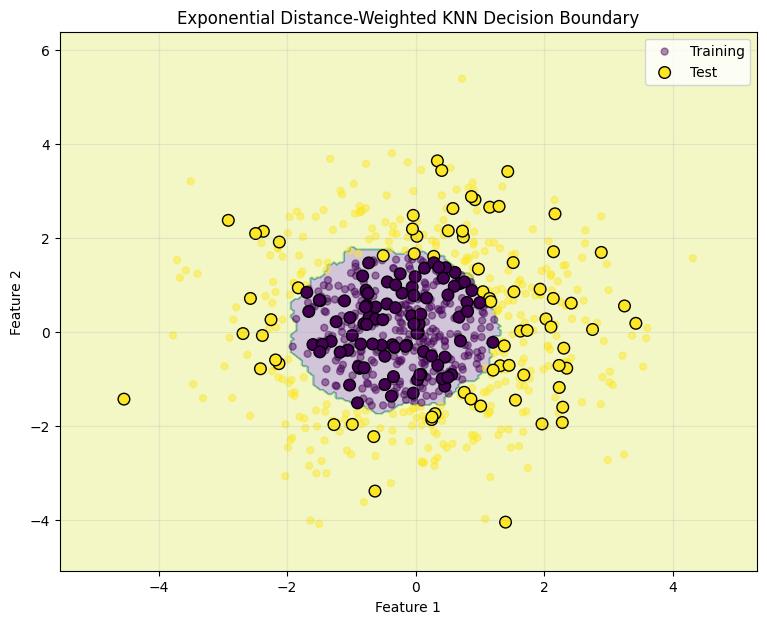

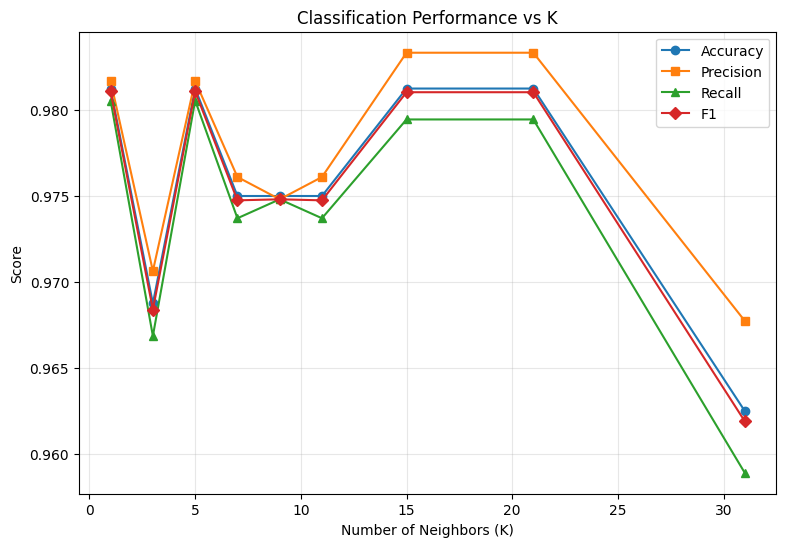

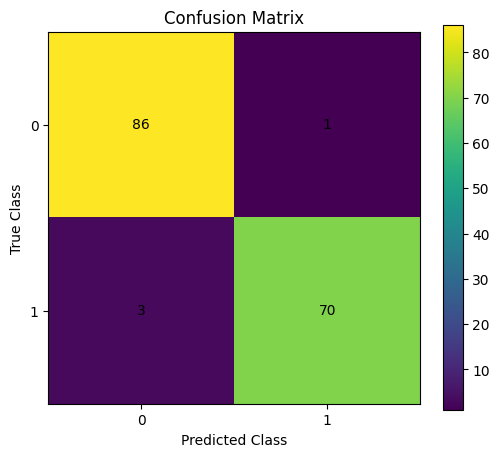


CLASSIFICATION NEIGHBOR ANALYSIS

Query point:
[ 0.29973124 -1.74403429]

Neighbor indices:
[507 422 249 566 182 227 285]

Neighbor distances:
[0.06673492 0.11658518 0.13400924 0.1345293  0.14115865 0.1470966
 0.1674934 ]

Neighbor labels:
[1 1 1 1 1 1 1]

Exponential weights:
[0.93544313 0.88995429 0.87458198 0.87412726 0.86835153 0.86321059
 0.8457822 ]

Normalized weights:
[0.1520687  0.14467388 0.14217491 0.14210099 0.14116207 0.14032634
 0.13749312]


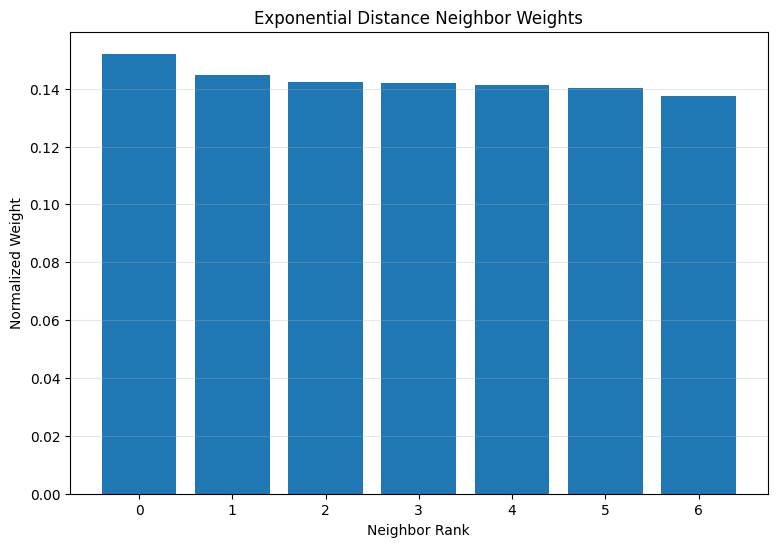

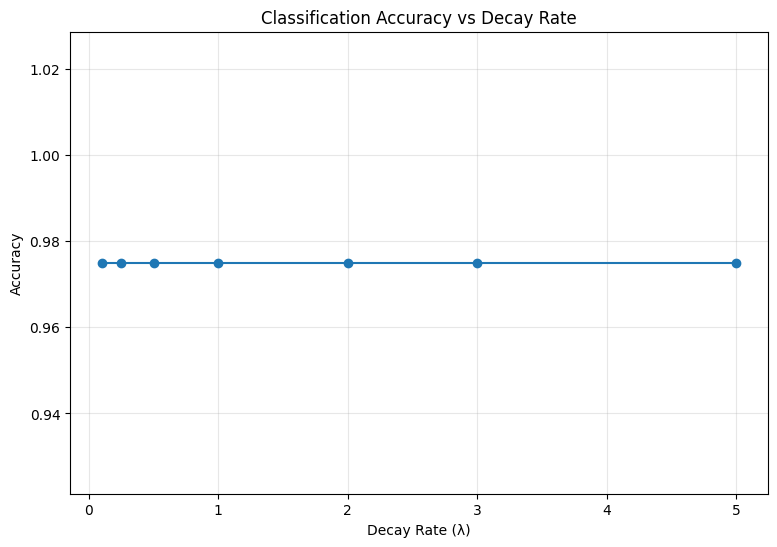


EXPONENTIAL DISTANCE-WEIGHTED KNN
REGRESSION EVALUATION
MAE            : 0.5456
MSE            : 0.5281
RMSE           : 0.7267
R2             : 0.9790
MAPE           : 66.1963


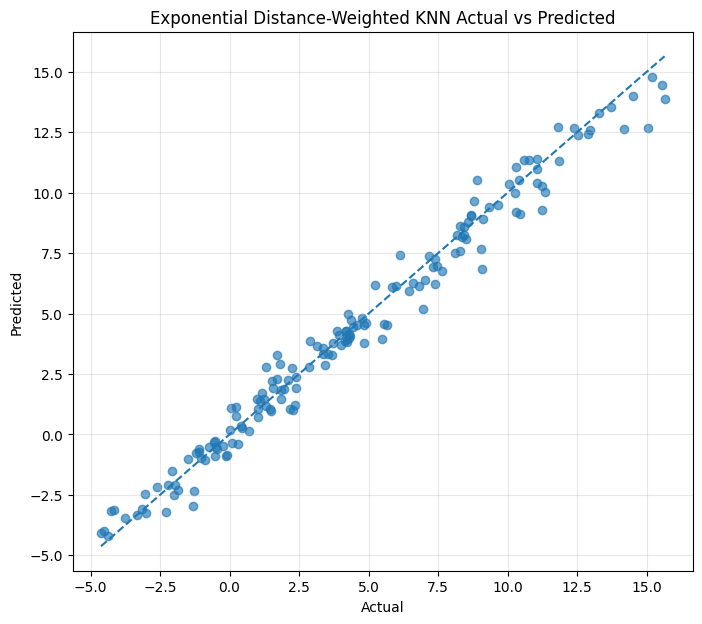

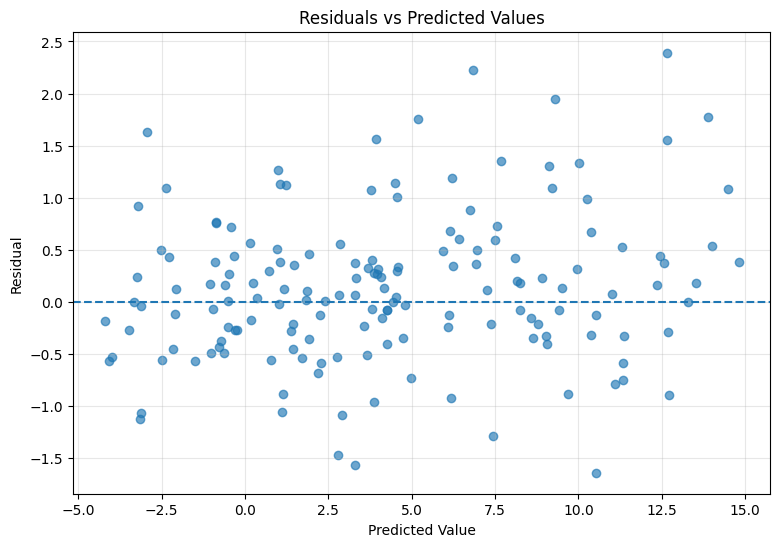

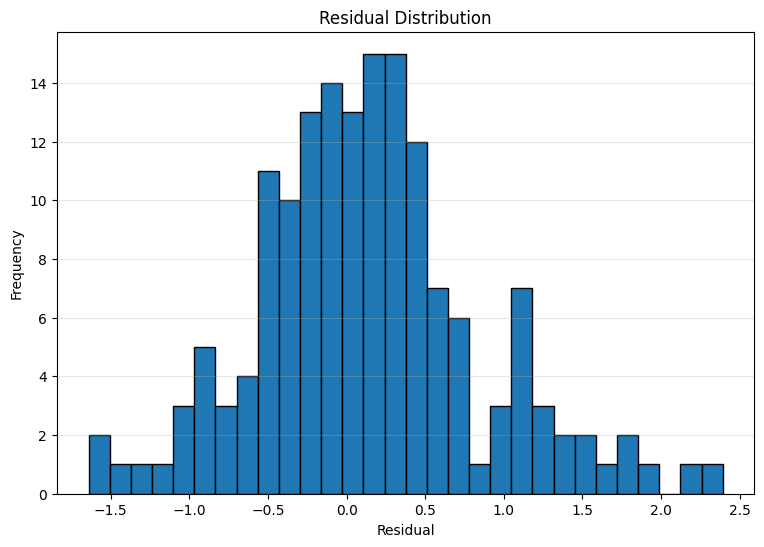

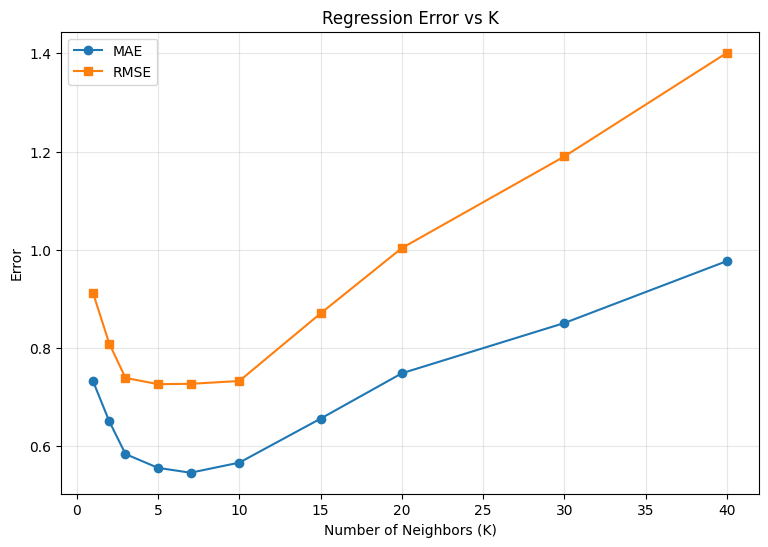

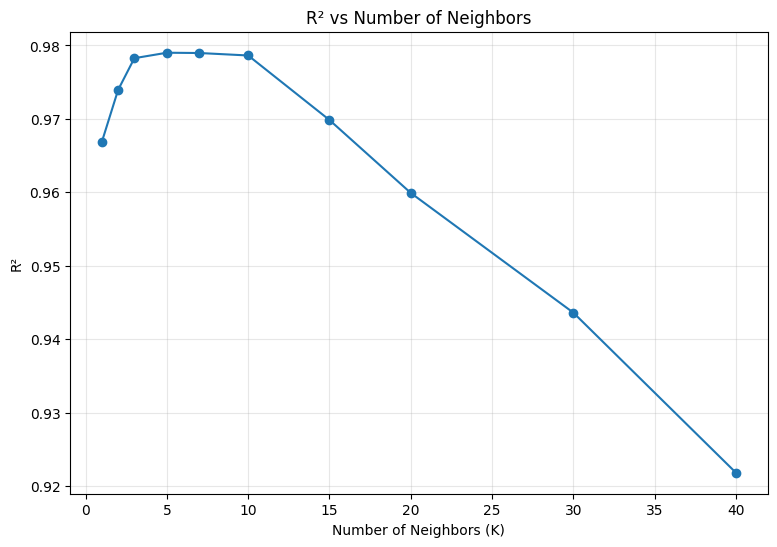

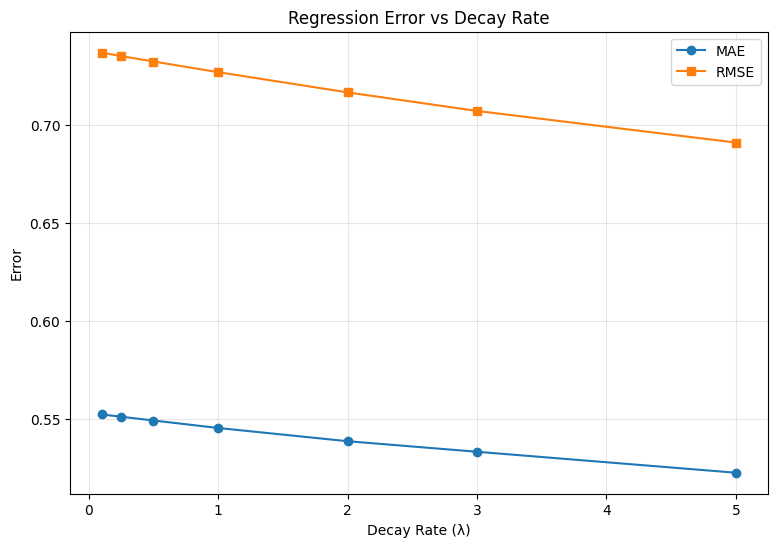

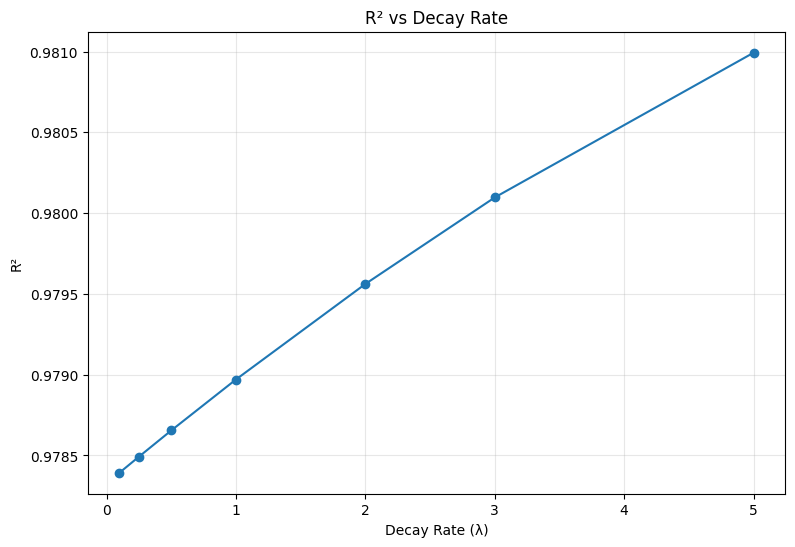


REGRESSION NEIGHBOR ANALYSIS

Query point:
[3.789789   0.71772352]

Neighbor indices:
[ 59 343 438 349 597 313 517]

Neighbor distances:
[0.04329182 0.18511766 0.18613833 0.20920402 0.2119958  0.22186019
 0.23685413]

Neighbor target values:
[2.1765416  1.76017944 2.9515167  1.42606889 1.4526423  2.40936658
 3.22498149]

Exponential weights:
[0.95763189 0.8310065  0.83015875 0.81122971 0.80896809 0.80102735
 0.78910639]

Normalized weights:
[0.16428388 0.14256101 0.14241558 0.13916826 0.13878028 0.13741802
 0.13537296]


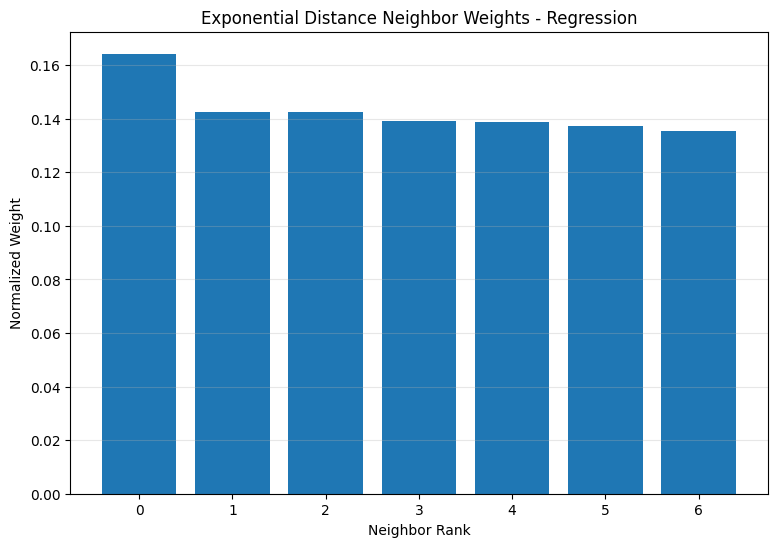


FINAL EVALUATION SUMMARY

Classification:
Accuracy       : 0.9750
Precision      : 0.9761
Recall         : 0.9737
F1             : 0.9747

Regression:
MAE            : 0.5456
MSE            : 0.5281
RMSE           : 0.7267
R2             : 0.9790
MAPE           : 66.1963


In [15]:
# ============================================================
# EXPONENTIAL DISTANCE-WEIGHTED KNN
# ============================================================
# FROM SCRATCH
# NO SCIKIT-LEARN
# NUMPY + MATPLOTLIB ONLY
#
# Weight:
#       w_i = exp(-lambda * d_i)
#
# Classification:
#       Exponential weighted voting
#
# Regression:
#       Exponential weighted average
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


# ============================================================
# 1. TRAIN-TEST SPLIT FROM SCRATCH
# ============================================================

def train_test_split_scratch(
    X,
    y,
    test_size=0.20,
    random_state=42
):

    rng = np.random.default_rng(random_state)

    n_samples = len(X)

    indices = np.arange(n_samples)

    rng.shuffle(indices)

    n_test = int(n_samples * test_size)

    test_indices = indices[:n_test]

    train_indices = indices[n_test:]

    X_train = X[train_indices]
    X_test = X[test_indices]

    y_train = y[train_indices]
    y_test = y[test_indices]

    return (
        X_train,
        X_test,
        y_train,
        y_test
    )


# ============================================================
# 2. STANDARD SCALER FROM SCRATCH
# ============================================================

class StandardScalerScratch:

    def fit(self, X):

        self.mean_ = np.mean(
            X,
            axis=0
        )

        self.std_ = np.std(
            X,
            axis=0
        )

        # Prevent division by zero
        self.std_[
            self.std_ == 0
        ] = 1.0

        return self

    def transform(self, X):

        return (
            X - self.mean_
        ) / self.std_

    def fit_transform(self, X):

        self.fit(X)

        return self.transform(X)


# ============================================================
# 3. EXPONENTIAL DISTANCE KNN CLASSIFIER
# ============================================================

class ExponentialDistanceKNNClassifier:

    def __init__(
        self,
        n_neighbors=5,
        decay_rate=1.0,
        standardize=True,
        epsilon=1e-12
    ):

        self.n_neighbors = n_neighbors

        self.decay_rate = decay_rate

        self.standardize = standardize

        self.epsilon = epsilon

    # --------------------------------------------------------
    # FIT
    # --------------------------------------------------------

    def fit(self, X, y):

        X = np.asarray(
            X,
            dtype=float
        )

        y = np.asarray(y)

        if X.ndim != 2:

            raise ValueError(
                "X must be a 2D array."
            )

        if len(X) != len(y):

            raise ValueError(
                "X and y must have the same number of samples."
            )

        if self.n_neighbors <= 0:

            raise ValueError(
                "n_neighbors must be greater than 0."
            )

        if self.decay_rate <= 0:

            raise ValueError(
                "decay_rate must be greater than 0."
            )

        if self.standardize:

            self.scaler_ = (
                StandardScalerScratch()
            )

            self.X_train_ = (
                self.scaler_.fit_transform(X)
            )

        else:

            self.scaler_ = None

            self.X_train_ = X.copy()

        self.y_train_ = y.copy()

        self.classes_ = np.unique(y)

        return self

    # --------------------------------------------------------
    # TRANSFORM
    # --------------------------------------------------------

    def _transform(self, X):

        X = np.asarray(
            X,
            dtype=float
        )

        if self.standardize:

            return self.scaler_.transform(X)

        return X

    # --------------------------------------------------------
    # EUCLIDEAN DISTANCE
    # --------------------------------------------------------

    def _calculate_distances(self, x):

        distances = np.sqrt(
            np.sum(
                (
                    self.X_train_ - x
                ) ** 2,
                axis=1
            )
        )

        return distances

    # --------------------------------------------------------
    # EXPONENTIAL WEIGHT
    # --------------------------------------------------------

    def _calculate_weights(self, distances):

        weights = np.exp(
            -self.decay_rate
            * distances
        )

        return weights

    # --------------------------------------------------------
    # GET K NEIGHBORS
    # --------------------------------------------------------

    def _get_neighbors(self, x):

        distances = (
            self._calculate_distances(x)
        )

        k = min(
            self.n_neighbors,
            len(self.X_train_)
        )

        indices = np.argpartition(
            distances,
            k - 1
        )[:k]

        # Sort neighbors
        indices = indices[
            np.argsort(
                distances[indices]
            )
        ]

        neighbor_distances = (
            distances[indices]
        )

        neighbor_labels = (
            self.y_train_[indices]
        )

        return (
            indices,
            neighbor_distances,
            neighbor_labels
        )

    # --------------------------------------------------------
    # EXPONENTIAL WEIGHTED VOTE
    # --------------------------------------------------------

    def _weighted_vote(
        self,
        labels,
        distances
    ):

        weights = (
            self._calculate_weights(
                distances
            )
        )

        class_scores = {}

        for cls in self.classes_:

            mask = (
                labels == cls
            )

            class_scores[cls] = np.sum(
                weights[mask]
            )

        maximum_score = max(
            class_scores.values()
        )

        candidates = [
            cls
            for cls, score
            in class_scores.items()
            if np.isclose(
                score,
                maximum_score
            )
        ]

        # Deterministic tie breaking
        prediction = min(candidates)

        return prediction

    # --------------------------------------------------------
    # PREDICT
    # --------------------------------------------------------

    def predict(self, X):

        X = np.asarray(
            X,
            dtype=float
        )

        X_scaled = (
            self._transform(X)
        )

        predictions = []

        for x in X_scaled:

            (
                indices,
                distances,
                labels
            ) = self._get_neighbors(x)

            prediction = (
                self._weighted_vote(
                    labels,
                    distances
                )
            )

            predictions.append(
                prediction
            )

        return np.asarray(
            predictions
        )

    # --------------------------------------------------------
    # PREDICT PROBABILITY
    # --------------------------------------------------------

    def predict_proba(self, X):

        X = np.asarray(
            X,
            dtype=float
        )

        X_scaled = (
            self._transform(X)
        )

        probabilities = []

        for x in X_scaled:

            (
                indices,
                distances,
                labels
            ) = self._get_neighbors(x)

            weights = (
                self._calculate_weights(
                    distances
                )
            )

            class_scores = []

            for cls in self.classes_:

                score = np.sum(
                    weights[
                        labels == cls
                    ]
                )

                class_scores.append(
                    score
                )

            class_scores = np.asarray(
                class_scores
            )

            total = np.sum(
                class_scores
            )

            if total > self.epsilon:

                class_scores /= total

            else:

                class_scores = (
                    np.ones(
                        len(self.classes_)
                    )
                    /
                    len(self.classes_)
                )

            probabilities.append(
                class_scores
            )

        return np.asarray(
            probabilities
        )

    # --------------------------------------------------------
    # SCORE
    # --------------------------------------------------------

    def score(self, X, y):

        predictions = self.predict(X)

        return np.mean(
            predictions == y
        )

    # --------------------------------------------------------
    # NEIGHBOR INFORMATION
    # --------------------------------------------------------

    def get_neighbors(self, x):

        x = np.asarray(
            x,
            dtype=float
        ).reshape(1, -1)

        x_scaled = (
            self._transform(x)[0]
        )

        (
            indices,
            distances,
            labels
        ) = self._get_neighbors(
            x_scaled
        )

        weights = (
            self._calculate_weights(
                distances
            )
        )

        normalized_weights = (
            weights
            /
            np.sum(weights)
        )

        return {

            "indices": indices,

            "distances": distances,

            "labels": labels,

            "weights": weights,

            "normalized_weights":
                normalized_weights
        }


# ============================================================
# 4. EXPONENTIAL DISTANCE KNN REGRESSOR
# ============================================================

class ExponentialDistanceKNNRegressor:

    def __init__(
        self,
        n_neighbors=5,
        decay_rate=1.0,
        standardize=True,
        epsilon=1e-12
    ):

        self.n_neighbors = n_neighbors

        self.decay_rate = decay_rate

        self.standardize = standardize

        self.epsilon = epsilon

    # --------------------------------------------------------
    # FIT
    # --------------------------------------------------------

    def fit(self, X, y):

        X = np.asarray(
            X,
            dtype=float
        )

        y = np.asarray(
            y,
            dtype=float
        )

        if X.ndim != 2:

            raise ValueError(
                "X must be a 2D array."
            )

        if len(X) != len(y):

            raise ValueError(
                "X and y must have the same number of samples."
            )

        if self.n_neighbors <= 0:

            raise ValueError(
                "n_neighbors must be greater than 0."
            )

        if self.decay_rate <= 0:

            raise ValueError(
                "decay_rate must be greater than 0."
            )

        if self.standardize:

            self.scaler_ = (
                StandardScalerScratch()
            )

            self.X_train_ = (
                self.scaler_.fit_transform(X)
            )

        else:

            self.scaler_ = None

            self.X_train_ = X.copy()

        self.y_train_ = y.copy()

        return self

    # --------------------------------------------------------
    # TRANSFORM
    # --------------------------------------------------------

    def _transform(self, X):

        X = np.asarray(
            X,
            dtype=float
        )

        if self.standardize:

            return self.scaler_.transform(X)

        return X

    # --------------------------------------------------------
    # DISTANCE
    # --------------------------------------------------------

    def _calculate_distances(self, x):

        distances = np.sqrt(
            np.sum(
                (
                    self.X_train_ - x
                ) ** 2,
                axis=1
            )
        )

        return distances

    # --------------------------------------------------------
    # GET NEIGHBORS
    # --------------------------------------------------------

    def _get_neighbors(self, x):

        distances = (
            self._calculate_distances(x)
        )

        k = min(
            self.n_neighbors,
            len(self.X_train_)
        )

        indices = np.argpartition(
            distances,
            k - 1
        )[:k]

        indices = indices[
            np.argsort(
                distances[indices]
            )
        ]

        return (
            indices,
            distances[indices]
        )

    # --------------------------------------------------------
    # PREDICT
    # --------------------------------------------------------

    def predict(self, X):

        X = np.asarray(
            X,
            dtype=float
        )

        X_scaled = (
            self._transform(X)
        )

        predictions = []

        for x in X_scaled:

            (
                indices,
                distances
            ) = self._get_neighbors(x)

            neighbor_targets = (
                self.y_train_[indices]
            )

            # ------------------------------------------------
            # EXPONENTIAL WEIGHT
            # ------------------------------------------------

            weights = np.exp(
                -self.decay_rate
                * distances
            )

            weighted_prediction = (
                np.sum(
                    weights
                    *
                    neighbor_targets
                )
                /
                np.sum(weights)
            )

            predictions.append(
                weighted_prediction
            )

        return np.asarray(
            predictions
        )

    # --------------------------------------------------------
    # R2 SCORE
    # --------------------------------------------------------

    def score(self, X, y):

        predictions = self.predict(X)

        ss_res = np.sum(
            (y - predictions) ** 2
        )

        ss_tot = np.sum(
            (
                y -
                np.mean(y)
            ) ** 2
        )

        if ss_tot == 0:

            return 0.0

        return (
            1 -
            ss_res / ss_tot
        )

    # --------------------------------------------------------
    # NEIGHBOR INFORMATION
    # --------------------------------------------------------

    def get_neighbors(self, x):

        x = np.asarray(
            x,
            dtype=float
        ).reshape(1, -1)

        x_scaled = (
            self._transform(x)[0]
        )

        (
            indices,
            distances
        ) = self._get_neighbors(
            x_scaled
        )

        weights = np.exp(
            -self.decay_rate
            * distances
        )

        normalized_weights = (
            weights
            /
            np.sum(weights)
        )

        return {

            "indices": indices,

            "distances": distances,

            "targets":
                self.y_train_[indices],

            "weights": weights,

            "normalized_weights":
                normalized_weights
        }


# ============================================================
# 5. CLASSIFICATION METRICS
# ============================================================

def confusion_matrix_scratch(
    y_true,
    y_pred
):

    classes = np.unique(
        np.concatenate(
            [
                y_true,
                y_pred
            ]
        )
    )

    matrix = np.zeros(
        (
            len(classes),
            len(classes)
        ),
        dtype=int
    )

    class_to_index = {
        cls: i
        for i, cls
        in enumerate(classes)
    }

    for true, pred in zip(
        y_true,
        y_pred
    ):

        i = class_to_index[true]

        j = class_to_index[pred]

        matrix[i, j] += 1

    return (
        classes,
        matrix
    )


def classification_metrics(
    y_true,
    y_pred
):

    accuracy = np.mean(
        y_true == y_pred
    )

    classes = np.unique(
        np.concatenate(
            [
                y_true,
                y_pred
            ]
        )
    )

    precision_values = []
    recall_values = []
    f1_values = []

    for cls in classes:

        tp = np.sum(
            (y_true == cls)
            &
            (y_pred == cls)
        )

        fp = np.sum(
            (y_true != cls)
            &
            (y_pred == cls)
        )

        fn = np.sum(
            (y_true == cls)
            &
            (y_pred != cls)
        )

        precision = (
            tp / (tp + fp)
            if tp + fp > 0
            else 0.0
        )

        recall = (
            tp / (tp + fn)
            if tp + fn > 0
            else 0.0
        )

        f1 = (
            2
            * precision
            * recall
            /
            (precision + recall)
            if precision + recall > 0
            else 0.0
        )

        precision_values.append(
            precision
        )

        recall_values.append(
            recall
        )

        f1_values.append(
            f1
        )

    return {

        "Accuracy":
            accuracy,

        "Precision":
            np.mean(
                precision_values
            ),

        "Recall":
            np.mean(
                recall_values
            ),

        "F1":
            np.mean(
                f1_values
            )
    }


# ============================================================
# 6. REGRESSION METRICS
# ============================================================

def regression_metrics(
    y_true,
    y_pred
):

    errors = (
        y_true - y_pred
    )

    mae = np.mean(
        np.abs(errors)
    )

    mse = np.mean(
        errors ** 2
    )

    rmse = np.sqrt(
        mse
    )

    ss_res = np.sum(
        errors ** 2
    )

    ss_tot = np.sum(
        (
            y_true -
            np.mean(y_true)
        ) ** 2
    )

    if ss_tot != 0:

        r2 = (
            1 -
            ss_res / ss_tot
        )

    else:

        r2 = 0.0

    non_zero = (
        np.abs(y_true)
        > 1e-12
    )

    if np.any(non_zero):

        mape = (
            np.mean(
                np.abs(
                    errors[non_zero]
                    /
                    y_true[non_zero]
                )
            )
            * 100
        )

    else:

        mape = np.nan

    return {

        "MAE": mae,

        "MSE": mse,

        "RMSE": rmse,

        "R2": r2,

        "MAPE": mape
    }


# ============================================================
# 7. CLASSIFICATION DATASET
# ============================================================

n_samples = 800

X_class = np.random.normal(
    0,
    1.4,
    size=(
        n_samples,
        2
    )
)

decision_score = (
    X_class[:, 0] ** 2
    +
    X_class[:, 1] ** 2
    +
    0.7 * X_class[:, 0]
    -
    2.5
)

y_class = (
    decision_score > 0
).astype(int)


# ============================================================
# 8. CLASSIFICATION TRAIN-TEST SPLIT
# ============================================================

(
    Xc_train,
    Xc_test,
    yc_train,
    yc_test
) = train_test_split_scratch(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 9. TRAIN EXPONENTIAL KNN CLASSIFIER
# ============================================================

classifier = (
    ExponentialDistanceKNNClassifier(
        n_neighbors=7,
        decay_rate=1.0,
        standardize=True
    )
)

classifier.fit(
    Xc_train,
    yc_train
)


# ============================================================
# 10. CLASSIFICATION PREDICTION
# ============================================================

yc_pred = classifier.predict(
    Xc_test
)


# ============================================================
# 11. CLASSIFICATION EVALUATION
# ============================================================

classification_result = (
    classification_metrics(
        yc_test,
        yc_pred
    )
)

print("=" * 65)

print(
    "EXPONENTIAL DISTANCE-WEIGHTED KNN"
)

print(
    "CLASSIFICATION EVALUATION"
)

print("=" * 65)

for metric, value in (
    classification_result.items()
):

    print(
        f"{metric:<15}: {value:.4f}"
    )


# ============================================================
# 12. CONFUSION MATRIX
# ============================================================

classes, cm = (
    confusion_matrix_scratch(
        yc_test,
        yc_pred
    )
)

print("\nConfusion Matrix:")

print(cm)


# ============================================================
# 13. DECISION BOUNDARY
# ============================================================

x_min = (
    X_class[:, 0].min()
    - 1
)

x_max = (
    X_class[:, 0].max()
    + 1
)

y_min = (
    X_class[:, 1].min()
    - 1
)

y_max = (
    X_class[:, 1].max()
    + 1
)

xx, yy = np.meshgrid(
    np.linspace(
        x_min,
        x_max,
        250
    ),
    np.linspace(
        y_min,
        y_max,
        250
    )
)

grid = np.c_[
    xx.ravel(),
    yy.ravel()
]

grid_prediction = (
    classifier.predict(
        grid
    )
)

grid_prediction = (
    grid_prediction.reshape(
        xx.shape
    )
)


plt.figure(
    figsize=(9, 7)
)

plt.contourf(
    xx,
    yy,
    grid_prediction,
    alpha=0.25
)

plt.scatter(
    Xc_train[:, 0],
    Xc_train[:, 1],
    c=yc_train,
    s=25,
    alpha=0.45,
    label="Training"
)

plt.scatter(
    Xc_test[:, 0],
    Xc_test[:, 1],
    c=yc_test,
    s=70,
    edgecolor="black",
    label="Test"
)

plt.xlabel(
    "Feature 1"
)

plt.ylabel(
    "Feature 2"
)

plt.title(
    "Exponential Distance-Weighted "
    "KNN Decision Boundary"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.show()


# ============================================================
# 14. CLASSIFICATION PERFORMANCE VS K
# ============================================================

K_values = [
    1,
    3,
    5,
    7,
    9,
    11,
    15,
    21,
    31
]

accuracy_values = []
precision_values = []
recall_values = []
f1_values = []

for k in K_values:

    model = (
        ExponentialDistanceKNNClassifier(
            n_neighbors=k,
            decay_rate=1.0,
            standardize=True
        )
    )

    model.fit(
        Xc_train,
        yc_train
    )

    predictions = model.predict(
        Xc_test
    )

    metrics = classification_metrics(
        yc_test,
        predictions
    )

    accuracy_values.append(
        metrics["Accuracy"]
    )

    precision_values.append(
        metrics["Precision"]
    )

    recall_values.append(
        metrics["Recall"]
    )

    f1_values.append(
        metrics["F1"]
    )


# ============================================================
# 15. CLASSIFICATION METRICS VS K
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    K_values,
    accuracy_values,
    marker="o",
    label="Accuracy"
)

plt.plot(
    K_values,
    precision_values,
    marker="s",
    label="Precision"
)

plt.plot(
    K_values,
    recall_values,
    marker="^",
    label="Recall"
)

plt.plot(
    K_values,
    f1_values,
    marker="D",
    label="F1"
)

plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Classification Performance vs K"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 16. CONFUSION MATRIX PLOT
# ============================================================

plt.figure(
    figsize=(6, 5)
)

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.xticks(
    range(len(classes)),
    classes
)

plt.yticks(
    range(len(classes)),
    classes
)

for i in range(
    cm.shape[0]
):

    for j in range(
        cm.shape[1]
    ):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()


# ============================================================
# 17. CLASSIFICATION NEIGHBOR ANALYSIS
# ============================================================

query_class = Xc_test[0]

neighbor_class = (
    classifier.get_neighbors(
        query_class
    )
)

print("\n" + "=" * 65)

print(
    "CLASSIFICATION NEIGHBOR ANALYSIS"
)

print("=" * 65)

print(
    "\nQuery point:"
)

print(
    query_class
)

print(
    "\nNeighbor indices:"
)

print(
    neighbor_class["indices"]
)

print(
    "\nNeighbor distances:"
)

print(
    neighbor_class["distances"]
)

print(
    "\nNeighbor labels:"
)

print(
    neighbor_class["labels"]
)

print(
    "\nExponential weights:"
)

print(
    neighbor_class["weights"]
)

print(
    "\nNormalized weights:"
)

print(
    neighbor_class[
        "normalized_weights"
    ]
)


# ============================================================
# 18. NEIGHBOR WEIGHT PLOT
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.bar(
    np.arange(
        len(
            neighbor_class[
                "normalized_weights"
            ]
        )
    ),
    neighbor_class[
        "normalized_weights"
    ]
)

plt.xlabel(
    "Neighbor Rank"
)

plt.ylabel(
    "Normalized Weight"
)

plt.title(
    "Exponential Distance Neighbor Weights"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# 19. DECAY RATE COMPARISON - CLASSIFICATION
# ============================================================

decay_rates = [
    0.1,
    0.25,
    0.5,
    1.0,
    2.0,
    3.0,
    5.0
]

decay_accuracy = []

for decay in decay_rates:

    model = (
        ExponentialDistanceKNNClassifier(
            n_neighbors=7,
            decay_rate=decay,
            standardize=True
        )
    )

    model.fit(
        Xc_train,
        yc_train
    )

    predictions = (
        model.predict(
            Xc_test
        )
    )

    metrics = classification_metrics(
        yc_test,
        predictions
    )

    decay_accuracy.append(
        metrics["Accuracy"]
    )


plt.figure(
    figsize=(9, 6)
)

plt.plot(
    decay_rates,
    decay_accuracy,
    marker="o"
)

plt.xlabel(
    "Decay Rate (λ)"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Classification Accuracy vs Decay Rate"
)

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 20. REGRESSION DATASET
# ============================================================

n_samples = 800

X_reg = np.random.uniform(
    -5,
    5,
    size=(
        n_samples,
        2
    )
)

noise = np.random.normal(
    0,
    0.5,
    size=n_samples
)

y_reg = (
    3 * np.sin(
        X_reg[:, 0]
    )
    +
    0.5 * X_reg[:, 1] ** 2
    +
    0.8 * X_reg[:, 0]
    +
    noise
)


# ============================================================
# 21. REGRESSION TRAIN-TEST SPLIT
# ============================================================

(
    Xr_train,
    Xr_test,
    yr_train,
    yr_test
) = train_test_split_scratch(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 22. TRAIN EXPONENTIAL KNN REGRESSOR
# ============================================================

regressor = (
    ExponentialDistanceKNNRegressor(
        n_neighbors=7,
        decay_rate=1.0,
        standardize=True
    )
)

regressor.fit(
    Xr_train,
    yr_train
)


# ============================================================
# 23. REGRESSION PREDICTION
# ============================================================

yr_pred = (
    regressor.predict(
        Xr_test
    )
)


# ============================================================
# 24. REGRESSION EVALUATION
# ============================================================

regression_result = (
    regression_metrics(
        yr_test,
        yr_pred
    )
)

print("\n" + "=" * 65)

print(
    "EXPONENTIAL DISTANCE-WEIGHTED KNN"
)

print(
    "REGRESSION EVALUATION"
)

print("=" * 65)

for metric, value in (
    regression_result.items()
):

    print(
        f"{metric:<15}: {value:.4f}"
    )


# ============================================================
# 25. ACTUAL VS PREDICTED
# ============================================================

plt.figure(
    figsize=(8, 7)
)

plt.scatter(
    yr_test,
    yr_pred,
    alpha=0.65
)

minimum = min(
    yr_test.min(),
    yr_pred.min()
)

maximum = max(
    yr_test.max(),
    yr_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel(
    "Actual"
)

plt.ylabel(
    "Predicted"
)

plt.title(
    "Exponential Distance-Weighted KNN "
    "Actual vs Predicted"
)

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 26. RESIDUAL PLOT
# ============================================================

residuals = (
    yr_test - yr_pred
)

plt.figure(
    figsize=(9, 6)
)

plt.scatter(
    yr_pred,
    residuals,
    alpha=0.65
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Predicted Value"
)

plt.ylabel(
    "Residual"
)

plt.title(
    "Residuals vs Predicted Values"
)

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 27. RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.hist(
    residuals,
    bins=30,
    edgecolor="black"
)

plt.xlabel(
    "Residual"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Residual Distribution"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# 28. REGRESSION PERFORMANCE VS K
# ============================================================

K_values_reg = [
    1,
    2,
    3,
    5,
    7,
    10,
    15,
    20,
    30,
    40
]

mae_values = []
mse_values = []
rmse_values = []
r2_values = []

for k in K_values_reg:

    model = (
        ExponentialDistanceKNNRegressor(
            n_neighbors=k,
            decay_rate=1.0,
            standardize=True
        )
    )

    model.fit(
        Xr_train,
        yr_train
    )

    predictions = (
        model.predict(
            Xr_test
        )
    )

    metrics = regression_metrics(
        yr_test,
        predictions
    )

    mae_values.append(
        metrics["MAE"]
    )

    mse_values.append(
        metrics["MSE"]
    )

    rmse_values.append(
        metrics["RMSE"]
    )

    r2_values.append(
        metrics["R2"]
    )


# ============================================================
# 29. REGRESSION ERROR VS K
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    K_values_reg,
    mae_values,
    marker="o",
    label="MAE"
)

plt.plot(
    K_values_reg,
    rmse_values,
    marker="s",
    label="RMSE"
)

plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "Error"
)

plt.title(
    "Regression Error vs K"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 30. R2 VS K
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    K_values_reg,
    r2_values,
    marker="o"
)

plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "R²"
)

plt.title(
    "R² vs Number of Neighbors"
)

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 31. REGRESSION DECAY RATE COMPARISON
# ============================================================

decay_mae = []
decay_rmse = []
decay_r2 = []

for decay in decay_rates:

    model = (
        ExponentialDistanceKNNRegressor(
            n_neighbors=7,
            decay_rate=decay,
            standardize=True
        )
    )

    model.fit(
        Xr_train,
        yr_train
    )

    predictions = (
        model.predict(
            Xr_test
        )
    )

    metrics = regression_metrics(
        yr_test,
        predictions
    )

    decay_mae.append(
        metrics["MAE"]
    )

    decay_rmse.append(
        metrics["RMSE"]
    )

    decay_r2.append(
        metrics["R2"]
    )


# ============================================================
# 32. DECAY RATE VS ERROR
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    decay_rates,
    decay_mae,
    marker="o",
    label="MAE"
)

plt.plot(
    decay_rates,
    decay_rmse,
    marker="s",
    label="RMSE"
)

plt.xlabel(
    "Decay Rate (λ)"
)

plt.ylabel(
    "Error"
)

plt.title(
    "Regression Error vs Decay Rate"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 33. DECAY RATE VS R2
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    decay_rates,
    decay_r2,
    marker="o"
)

plt.xlabel(
    "Decay Rate (λ)"
)

plt.ylabel(
    "R²"
)

plt.title(
    "R² vs Decay Rate"
)

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 34. REGRESSION NEIGHBOR ANALYSIS
# ============================================================

query_reg = Xr_test[0]

neighbor_reg = (
    regressor.get_neighbors(
        query_reg
    )
)

print("\n" + "=" * 65)

print(
    "REGRESSION NEIGHBOR ANALYSIS"
)

print("=" * 65)

print(
    "\nQuery point:"
)

print(
    query_reg
)

print(
    "\nNeighbor indices:"
)

print(
    neighbor_reg["indices"]
)

print(
    "\nNeighbor distances:"
)

print(
    neighbor_reg["distances"]
)

print(
    "\nNeighbor target values:"
)

print(
    neighbor_reg["targets"]
)

print(
    "\nExponential weights:"
)

print(
    neighbor_reg["weights"]
)

print(
    "\nNormalized weights:"
)

print(
    neighbor_reg[
        "normalized_weights"
    ]
)


# ============================================================
# 35. REGRESSION NEIGHBOR WEIGHT PLOT
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.bar(
    np.arange(
        len(
            neighbor_reg[
                "normalized_weights"
            ]
        )
    ),
    neighbor_reg[
        "normalized_weights"
    ]
)

plt.xlabel(
    "Neighbor Rank"
)

plt.ylabel(
    "Normalized Weight"
)

plt.title(
    "Exponential Distance Neighbor Weights - Regression"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# 36. FINAL EVALUATION SUMMARY
# ============================================================

print("\n" + "=" * 65)

print(
    "FINAL EVALUATION SUMMARY"
)

print("=" * 65)

print("\nClassification:")

for metric, value in (
    classification_result.items()
):

    print(
        f"{metric:<15}: {value:.4f}"
    )


print("\nRegression:")

for metric, value in (
    regression_result.items()
):

    print(
        f"{metric:<15}: {value:.4f}"
    )